In [1]:
# ============================================================
# GeoSR-NTRO — PHASE 0
# Environment Setup
# ============================================================

import os
import sys
import subprocess
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())

# GPU check
try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        print(
            "GPU memory:",
            round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
            "GB"
        )
except Exception as e:
    print("PyTorch check failed:", e)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [2]:
from google.colab import drive

drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/GeoSR-NTRO"

import os

os.makedirs(PROJECT_ROOT, exist_ok=True)

print("Project directory:", PROJECT_ROOT)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/GeoSR-NTRO


In [3]:
import os

folders = [
    "configs",

    "data/raw",
    "data/interim",
    "data/processed",
    "data/cache",

    "models",
    "models/checkpoints",

    "losses",

    "evaluation",
    "downstream",

    "scripts",

    "experiments/experiment_logs",
    "experiments/figures",

    "notebooks",

    "backend",
    "backend/services",
    "backend/schemas",

    "frontend",

    "tests",

    "outputs",
    "outputs/geotiff",
    "outputs/uncertainty",
    "outputs/visualizations",

    "docs"
]

for folder in folders:
    path = os.path.join(PROJECT_ROOT, folder)
    os.makedirs(path, exist_ok=True)

print("GeoSR-NTRO project structure created.")

GeoSR-NTRO project structure created.


In [4]:
!pip install -q \
    rasterio \
    geopandas \
    shapely \
    pyproj \
    pystac-client \
    planetary-computer \
    rioxarray \
    xarray \
    scipy \
    scikit-image \
    opencv-python-headless \
    pandas \
    numpy \
    matplotlib \
    tqdm \
    pyyaml \
    fastapi \
    uvicorn \
    pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.6 MB/s eta 0:00:00


In [5]:
!pip install -q \
    opensr-test

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00


In [6]:
import rasterio
import geopandas
import shapely
import pyproj
import pystac

print("Rasterio:", rasterio.__version__)
print("GeoPandas:", geopandas.__version__)
print("Shapely:", shapely.__version__)
print("PyProj:", pyproj.__version__)
print("PySTAC:", pystac.__version__)

print("\nGeospatial environment: PASS")

Rasterio: 1.5.1
GeoPandas: 1.1.4
Shapely: 2.1.2
PyProj: 3.7.2
PySTAC: 1.15.2

Geospatial environment: PASS


In [7]:
!pip install -q sen2sr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.2 MB/s eta 0:00:00


In [8]:
import sen2sr

print("SEN2SR import: PASS")
print("Location:", sen2sr.__file__)

SEN2SR import: PASS
Location: /usr/local/lib/python3.13/dist-packages/sen2sr/__init__.py


In [9]:
!python -m pip show sen2sr

Name: sen2sr
Version: 0.8.5
Summary: A Python package to super-resolve Sentinel-2 satellite imagery up to 2.5 meters.
Home-page: https://github.com/ESAOpenSR/sen2sr
Author: Cesar Aybar
Author-email: cesar.aybar@uv.es
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: einops, numpy, timm, tqdm
Required-by: 


In [10]:
import torch
import sys
import subprocess

print("=" * 60)
print("GeoSR-NTRO ENVIRONMENT REPORT")
print("=" * 60)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

try:
    import rasterio
    print("Rasterio:", rasterio.__version__)
except:
    print("Rasterio: FAIL")

try:
    import pystac
    print("PySTAC:", pystac.__version__)
except:
    print("PySTAC: FAIL")

try:
    import sen2sr
    print("SEN2SR: PASS")
except Exception as e:
    print("SEN2SR: FAIL")
    print(e)

print("=" * 60)

GeoSR-NTRO ENVIRONMENT REPORT
Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA: 12.8
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB
Rasterio: 1.5.1
PySTAC: 1.15.2
SEN2SR: PASS


In [11]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/GeoSR-NTRO")

DIRS = [
    "data/raw",
    "data/processed",
    "data/chips",
    "data/metadata",
    "checkpoints",
    "outputs",
    "logs",
    "configs",
]

for d in DIRS:
    (PROJECT / d).mkdir(parents=True, exist_ok=True)

print("PROJECT:", PROJECT)

for d in DIRS:
    print("✓", PROJECT / d)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT: /content/drive/MyDrive/GeoSR-NTRO
✓ /content/drive/MyDrive/GeoSR-NTRO/data/raw
✓ /content/drive/MyDrive/GeoSR-NTRO/data/processed
✓ /content/drive/MyDrive/GeoSR-NTRO/data/chips
✓ /content/drive/MyDrive/GeoSR-NTRO/data/metadata
✓ /content/drive/MyDrive/GeoSR-NTRO/checkpoints
✓ /content/drive/MyDrive/GeoSR-NTRO/outputs
✓ /content/drive/MyDrive/GeoSR-NTRO/logs
✓ /content/drive/MyDrive/GeoSR-NTRO/configs


In [12]:
!pip -q install pystac-client planetary-computer \
    rasterio geopandas shapely pyproj \
    boto3 botocore requests tqdm \
    matplotlib numpy pandas scipy scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.0 MB/s eta 0:00:00


In [13]:
from pystac_client import Client

STAC_URL = "https://stac.dataspace.copernicus.eu/v1"

catalog = Client.open(STAC_URL)

print("STAC connection: PASS")
print("Catalog:", catalog.id)

collection = catalog.get_collection("sentinel-2-l2a")

print("Collection:", collection.id)
print("Title:", collection.title)

STAC connection: PASS
Catalog: cdse-stac
Collection: sentinel-2-l2a
Title: Sentinel-2 Level-2A


In [14]:
collection = catalog.get_collection("sentinel-2-l2a")

print("Sentinel-2 L2A bands:\n")

for band in collection.extra_fields.get("bands", []):
    print(
        f"{band.get('name'):>4} | "
        f"{band.get('gsd'):>2} m | "
        f"{band.get('description')}"
    )

Sentinel-2 L2A bands:

 B01 | 60 m | Coastal aerosol (band 1)
 B02 | 10 m | Blue (band 2)
 B03 | 10 m | Green (band 3)
 B04 | 10 m | Red (band 4)
 B05 | 20 m | Red edge 1 (band 5)
 B06 | 20 m | Red edge 2 (band 6)
 B07 | 20 m | Red edge 3 (band 7)
 B08 | 10 m | NIR 1 (band 8)
 B8A | 20 m | NIR 2 (band 8A)
 B09 | 60 m | NIR 3 (band 9)
 B11 | 20 m | SWIR 1 (band 11)
 B12 | 20 m | SWIR 2 (band 12)


In [15]:
AOI = {
    "type": "Polygon",
    "coordinates": [[
        [78.35, 17.35],
        [78.55, 17.35],
        [78.55, 17.50],
        [78.35, 17.50],
        [78.35, 17.35]
    ]]
}

print("AOI configured.")

AOI configured.


In [16]:
from datetime import datetime, timezone, timedelta

today = datetime.now(timezone.utc)
start_date = today - timedelta(days=365)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=AOI,
    datetime=f"{start_date.date()}/{today.date()}",
    query={
        "eo:cloud_cover": {
            "lte": 20
        }
    },
    max_items=10,
    sortby=[
        {
            "field": "properties.eo:cloud_cover",
            "direction": "asc"
        }
    ]
)

items = list(search.items())

print("Scenes found:", len(items))

for i, item in enumerate(items):
    print(
        f"\n{i+1}. {item.id}"
        f"\n   Date: {item.datetime}"
        f"\n   Cloud: {item.properties.get('eo:cloud_cover')}%"
    )

Scenes found: 10

1. S2C_MSIL2A_20260427T050651_N0512_R019_T44QKE_20260427T102509
   Date: 2026-04-27 05:06:51.025000+00:00
   Cloud: 0.0%

2. S2C_MSIL2A_20260427T050651_N0512_R019_T43QHV_20260427T102509
   Date: 2026-04-27 05:06:51.025000+00:00
   Cloud: 0.0%

3. S2C_MSIL2A_20260407T050651_N0512_R019_T44QKE_20260407T103956
   Date: 2026-04-07 05:06:51.025000+00:00
   Cloud: 0.0%

4. S2C_MSIL2A_20260407T050651_N0512_R019_T43QHV_20260407T103956
   Date: 2026-04-07 05:06:51.025000+00:00
   Cloud: 0.0%

5. S2C_MSIL2A_20260117T051141_N0511_R019_T44QKE_20260117T081509
   Date: 2026-01-17 05:11:41.025000+00:00
   Cloud: 0.0%

6. S2C_MSIL2A_20260117T051141_N0511_R019_T43QHV_20260117T081509
   Date: 2026-01-17 05:11:41.025000+00:00
   Cloud: 0.0%

7. S2C_MSIL2A_20260107T051211_N0511_R019_T43QHV_20260107T082109
   Date: 2026-01-07 05:12:11.025000+00:00
   Cloud: 0.0%

8. S2C_MSIL2A_20251228T051231_N0511_R019_T43QHV_20251228T090010
   Date: 2025-12-28 05:12:31.025000+00:00
   Cloud: 0.0%

9. S2C

In [17]:
if not items:
    raise RuntimeError(
        "No suitable Sentinel-2 L2A scene found. "
        "Increase cloud threshold or date range."
    )

best_item = items[0]

print("SELECTED SCENE")
print("=" * 70)
print("ID:", best_item.id)
print("Date:", best_item.datetime)
print("Cloud:", best_item.properties.get("eo:cloud_cover"))
print("BBox:", best_item.bbox)

SELECTED SCENE
ID: S2C_MSIL2A_20260427T050651_N0512_R019_T44QKE_20260427T102509
Date: 2026-04-27 05:06:51.025000+00:00
Cloud: 0.0
BBox: [78.16579704596043, 17.07698503359998, 79.21234265683665, 18.080698696292075]


In [18]:
print("AVAILABLE ASSETS")
print("=" * 70)

for name, asset in best_item.assets.items():
    print(f"{name:20s} -> {asset.href}")

AVAILABLE ASSETS
AOT_10m              -> s3://eodata/Sentinel-2/MSI/L2A/2026/04/27/S2C_MSIL2A_20260427T050651_N0512_R019_T44QKE_20260427T102509.SAFE/GRANULE/L2A_T44QKE_A008569_20260427T051531/IMG_DATA/R10m/T44QKE_20260427T050651_AOT_10m.jp2
AOT_20m              -> s3://eodata/Sentinel-2/MSI/L2A/2026/04/27/S2C_MSIL2A_20260427T050651_N0512_R019_T44QKE_20260427T102509.SAFE/GRANULE/L2A_T44QKE_A008569_20260427T051531/IMG_DATA/R20m/T44QKE_20260427T050651_AOT_20m.jp2
AOT_60m              -> s3://eodata/Sentinel-2/MSI/L2A/2026/04/27/S2C_MSIL2A_20260427T050651_N0512_R019_T44QKE_20260427T102509.SAFE/GRANULE/L2A_T44QKE_A008569_20260427T051531/IMG_DATA/R60m/T44QKE_20260427T050651_AOT_60m.jp2
B01_20m              -> s3://eodata/Sentinel-2/MSI/L2A/2026/04/27/S2C_MSIL2A_20260427T050651_N0512_R019_T44QKE_20260427T102509.SAFE/GRANULE/L2A_T44QKE_A008569_20260427T051531/IMG_DATA/R20m/T44QKE_20260427T050651_B01_20m.jp2
B01_60m              -> s3://eodata/Sentinel-2/MSI/L2A/2026/04/27/S2C_MSIL2A_20260427T0

In [19]:
REQUIRED_BANDS = [
    "B02_10m",
    "B03_10m",
    "B04_10m",
    "B08_10m",
]

print("Checking required bands...\n")

for band in REQUIRED_BANDS:
    if band in best_item.assets:
        print("PASS:", band)
    else:
        print("MISSING:", band)

Checking required bands...

PASS: B02_10m
PASS: B03_10m
PASS: B04_10m
PASS: B08_10m


In [20]:
import json

metadata = {
    "scene_id": best_item.id,
    "datetime": str(best_item.datetime),
    "cloud_cover": best_item.properties.get("eo:cloud_cover"),
    "bbox": best_item.bbox,
    "collection": "sentinel-2-l2a",
    "bands": REQUIRED_BANDS,
    "aoi": AOI,
}

metadata_path = PROJECT / "data/metadata/selected_scene.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", metadata_path)

Saved: /content/drive/MyDrive/GeoSR-NTRO/data/metadata/selected_scene.json


In [21]:
!git clone https://github.com/ESAOpenSR/SEN2NEON.git

Cloning into 'SEN2NEON'...
remote: Enumerating objects: 248, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 248 (delta 10), reused 8 (delta 8), pack-reused 228 (from 1)
Receiving objects: 100% (248/248), 15.42 MiB | 24.87 MiB/s, done.
Resolving deltas: 100% (115/115), done.


In [22]:
!pip install -q -U huggingface_hub datasets rasterio pandas numpy matplotlib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 9.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pa

In [23]:
!pip install -q --force-reinstall "pandas==2.2.3" "numpy==2.2.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 14.4 MB/s eta 0:00:00


In [24]:
import sys
import numpy as np
import pandas as pd
import torch
import rasterio

print("======================================")
print("GeoSR-NTRO ENVIRONMENT CHECK")
print("======================================")
print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("Rasterio:", rasterio.__version__)
print("======================================")

GeoSR-NTRO ENVIRONMENT CHECK
Python : 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
NumPy : 2.1.3
Pandas: 2.2.3
Rasterio: 1.5.1


In [25]:
# ============================================================
# GeoSR-NTRO — PHASE 0
# Project Directory Setup
# ============================================================

import os

PROJECT_ROOT = "/content/drive/MyDrive/GeoSR-NTRO"

DATA_ROOT = os.path.join(PROJECT_ROOT, "data")
SEN2NEON_ROOT = os.path.join(DATA_ROOT, "sen2neon")

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(SEN2NEON_ROOT, exist_ok=True)

print("======================================")
print("GeoSR-NTRO PROJECT PATHS")
print("======================================")
print("Project root :", PROJECT_ROOT)
print("Data root    :", DATA_ROOT)
print("SEN2NEON     :", SEN2NEON_ROOT)
print("======================================")

GeoSR-NTRO PROJECT PATHS
Project root : /content/drive/MyDrive/GeoSR-NTRO
Data root    : /content/drive/MyDrive/GeoSR-NTRO/data
SEN2NEON     : /content/drive/MyDrive/GeoSR-NTRO/data/sen2neon


In [26]:
# ============================================================
# Check SEN2NEON Repository
# ============================================================

import os

SEN2NEON_REPO = "/content/SEN2NEON"

print("======================================")
print("SEN2NEON REPOSITORY CHECK")
print("======================================")

if os.path.exists(SEN2NEON_REPO):
    print("SEN2NEON repository: FOUND ✅")
    print("\nRepository contents:")
    print(os.listdir(SEN2NEON_REPO)[:30])
else:
    print("SEN2NEON repository: NOT FOUND ❌")

print("======================================")

SEN2NEON REPOSITORY CHECK
SEN2NEON repository: FOUND ✅

Repository contents:
['.gitignore', '.git', 'README.md', 'data', 'metrics', 'resources', 'validate.py', 'models', 'utils', 'requirements.txt']


In [27]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# SEN2NEON Metadata Download
# ============================================================

from huggingface_hub import snapshot_download
import os

PROJECT_ROOT = "/content/drive/MyDrive/GeoSR-NTRO"
DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "sen2neon")

os.makedirs(DATA_ROOT, exist_ok=True)

print("Downloading SEN2NEON metadata only...")
print("No large satellite image files will be downloaded yet.")
print()

snapshot_download(
    repo_id="isp-uv-es/SEN2NEON",
    repo_type="dataset",
    local_dir=DATA_ROOT,
    allow_patterns=[
        "README.md",
        "DATASET_RELEASE_NOTES.md",
        "metadata.csv",
        "metadata.jsonl",
        "metadata.parquet",
    ],
)

print()
print("======================================")
print("SEN2NEON METADATA: READY ✅")
print("======================================")
print("Location:", DATA_ROOT)
print("======================================")

No large satellite image files will be downloaded yet.



Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]


SEN2NEON METADATA: READY ✅
Location: /content/drive/MyDrive/GeoSR-NTRO/data/sen2neon


In [28]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# SEN2NEON Dataset Inspection
# ============================================================

import os
import pandas as pd

DATA_ROOT = "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon"
METADATA_PATH = os.path.join(DATA_ROOT, "metadata.csv")

# Load metadata
df = pd.read_csv(METADATA_PATH)

print("======================================")
print("SEN2NEON DATASET INSPECTION")
print("======================================")

print("Number of tiles:", len(df))

print("\nColumns:")
for column in df.columns:
    print(" -", column)

print("\nFirst 5 records:")
display(df.head())

print("======================================")

SEN2NEON DATASET INSPECTION
Number of tiles: 2269

Columns:
 - id
 - name
 - split
 - lr
 - hr
 - hr_2_5m_path
 - hr_1m_path
 - hr_available_resolutions_m
 - hr_canonical_resolution_m
 - lon
 - lat
 - LC_detail_id
 - LC_detail_text
 - LC_superclass_id
 - LC_superclass_text
 - bands
 - native_band_resolution_m
 - stored_dtype
 - reflectance_scale
 - lr_source
 - lr_collection
 - lr_grid
 - lr_native_resolution
 - lr_width
 - lr_height
 - lr_pixel_size_m
 - lr_nodata
 - hr_source
 - hr_width
 - hr_height
 - hr_pixel_size_m
 - hr_nodata
 - crs
 - lr_transform
 - hr_transform
 - centroid_lon
 - centroid_lat
 - land_cover
 - land_cover_detail_id
 - land_cover_detail
 - land_cover_superclass_id
 - land_cover_superclass
 - neon_acquisition_id
 - neon_asset_id
 - neon_date
 - neon_start_datetime
 - neon_end_datetime
 - s2_asset_id
 - s2_date
 - s2_start_datetime
 - temporal_difference_days
 - cloud_score_plus_cdf
 - neon_nodata_percent
 - s2_nodata_percent
 - hr_2_5m_width
 - hr_2_5m_height
 -

,id,name,split,lr,hr,hr_2_5m_path,hr_1m_path,hr_available_resolutions_m,hr_canonical_resolution_m,lon,...,hr_2_5m_pixel_size_m,hr_2_5m_nodata,hr_2_5m_transform,hr_2_5m_status,hr_1m_width,hr_1m_height,hr_1m_pixel_size_m,hr_1m_nodata,hr_1m_transform,hr_1m_status
0,2018_MLBS_3__0_2,2018_MLBS_3__0_2.tif,validation,s2_l2a_10m/2018_MLBS_3__0_2.tif,neon_2.5m_linearized/2018_MLBS_3__0_2.tif,neon_2.5m_linearized/2018_MLBS_3__0_2.tif,neon_1m_linearized/2018_MLBS_3__0_2.tif,"[2.5, 1.0]",2.5,-80.543250,...,2.5,0,"[2.5, 0.0, 539120.0, 0.0, -2.5, 4146000.0]",canonical paper benchmark target,2560,2560,1.0,0,"[1.0, 0.0, 539120.0, 0.0, -1.0, 4146000.0]",supplementary workflow by-product; not the pap...
1,2018_MLBS_3__1_1,2018_MLBS_3__1_1.tif,validation,s2_l2a_10m/2018_MLBS_3__1_1.tif,neon_2.5m_linearized/2018_MLBS_3__1_1.tif,neon_2.5m_linearized/2018_MLBS_3__1_1.tif,neon_1m_linearized/2018_MLBS_3__1_1.tif,"[2.5, 1.0]",2.5,-80.572323,...,2.5,0,"[2.5, 0.0, 536560.0, 0.0, -2.5, 4143440.0]",canonical paper benchmark target,2560,2560,1.0,0,"[1.0, 0.0, 536560.0, 0.0, -1.0, 4143440.0]",supplementary workflow by-product; not the pap...
2,2018_MLBS_3__1_2,2018_MLBS_3__1_2.tif,validation,s2_l2a_10m/2018_MLBS_3__1_2.tif,neon_2.5m_linearized/2018_MLBS_3__1_2.tif,neon_2.5m_linearized/2018_MLBS_3__1_2.tif,neon_1m_linearized/2018_MLBS_3__1_2.tif,"[2.5, 1.0]",2.5,-80.543390,...,2.5,0,"[2.5, 0.0, 539120.0, 0.0, -2.5, 4143440.0]",canonical paper benchmark target,2560,2560,1.0,0,"[1.0, 0.0, 539120.0, 0.0, -1.0, 4143440.0]",supplementary workflow by-product; not the pap...
3,2018_MLBS_3__1_3,2018_MLBS_3__1_3.tif,validation,s2_l2a_10m/2018_MLBS_3__1_3.tif,neon_2.5m_linearized/2018_MLBS_3__1_3.tif,neon_2.5m_linearized/2018_MLBS_3__1_3.tif,neon_1m_linearized/2018_MLBS_3__1_3.tif,"[2.5, 1.0]",2.5,-80.514458,...,2.5,0,"[2.5, 0.0, 541680.0, 0.0, -2.5, 4143440.0]",canonical paper benchmark target,2560,2560,1.0,0,"[1.0, 0.0, 541680.0, 0.0, -1.0, 4143440.0]",supplementary workflow by-product; not the pap...
4,2018_MLBS_3__1_4,2018_MLBS_3__1_4.tif,validation,s2_l2a_10m/2018_MLBS_3__1_4.tif,neon_2.5m_linearized/2018_MLBS_3__1_4.tif,neon_2.5m_linearized/2018_MLBS_3__1_4.tif,neon_1m_linearized/2018_MLBS_3__1_4.tif,"[2.5, 1.0]",2.5,-80.485525,...,2.5,0,"[2.5, 0.0, 544240.0, 0.0, -2.5, 4143440.0]",canonical paper benchmark target,2560,2560,1.0,0,"[1.0, 0.0, 544240.0, 0.0, -1.0, 4143440.0]",supplementary workflow by-product; not the pap...


In [29]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Select One SEN2NEON LR-HR Pair
# ============================================================

# Select the first tile
row = df.iloc[0]

print("======================================")
print("SELECTED SEN2NEON TILE")
print("======================================")

print("Tile ID:")
print(row["id"])

print("\nName:")
print(row["name"])

print("\nSplit:")
print(row["split"])

print("\nLR file — Sentinel-2 10 m:")
print(row["lr"])

print("\nHR file — 2.5 m:")
print(row["hr"])

print("\nBands:")
print(row["bands"])

print("\nNumber of bands:")
print(len(str(row["bands"]).split(",")))

print("\nLR dimensions:")
print(row["lr_width"], "x", row["lr_height"])

print("\nHR dimensions:")
print(row["hr_width"], "x", row["hr_height"])

print("\nLR pixel size:")
print(row["lr_pixel_size_m"], "m")

print("\nHR pixel size:")
print(row["hr_pixel_size_m"], "m")

print("\nCRS:")
print(row["crs"])

print("\nLand cover:")
print(row["land_cover"])

print("======================================")

SELECTED SEN2NEON TILE
Tile ID:
2018_MLBS_3__0_2

Name:
2018_MLBS_3__0_2.tif

Split:
validation

LR file — Sentinel-2 10 m:
s2_l2a_10m/2018_MLBS_3__0_2.tif

HR file — 2.5 m:
neon_2.5m_linearized/2018_MLBS_3__0_2.tif

Bands:
["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B11", "B12"]

Number of bands:
12

LR dimensions:
256 x 256

HR dimensions:
1024 x 1024

LR pixel size:
10.0 m

HR pixel size:
2.5 m

CRS:
EPSG:32617

Land cover:
Tree cover


In [30]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Download One SEN2NEON Training Pair
# ============================================================

from huggingface_hub import snapshot_download
import os

DATA_ROOT = "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon"

# Get the selected tile paths from the metadata
lr_file = row["lr"]
hr_file = row["hr"]

print("======================================")
print("DOWNLOADING ONE SEN2NEON PAIR")
print("======================================")
print("Tile:", row["id"])
print()
print("LR:", lr_file)
print("HR:", hr_file)
print()
print("Only these TWO files will be downloaded.")
print("The remaining dataset will NOT be downloaded.")
print("======================================")

# Download only the selected LR and HR GeoTIFFs
snapshot_download(
    repo_id="isp-uv-es/SEN2NEON",
    repo_type="dataset",
    local_dir=DATA_ROOT,
    allow_patterns=[
        lr_file,
        hr_file,
    ],
)

print()
print("======================================")
print("PAIR DOWNLOAD COMPLETE ✅")
print("======================================")

local_lr = os.path.join(DATA_ROOT, lr_file)
local_hr = os.path.join(DATA_ROOT, hr_file)

print("LR exists:", os.path.exists(local_lr))
print("HR exists:", os.path.exists(local_hr))

print("\nLR path:")
print(local_lr)

print("\nHR path:")
print(local_hr)

print("======================================")

DOWNLOADING ONE SEN2NEON PAIR
Tile: 2018_MLBS_3__0_2

LR: s2_l2a_10m/2018_MLBS_3__0_2.tif
HR: neon_2.5m_linearized/2018_MLBS_3__0_2.tif

Only these TWO files will be downloaded.
The remaining dataset will NOT be downloaded.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


PAIR DOWNLOAD COMPLETE ✅
LR exists: True
HR exists: True

LR path:
/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/s2_l2a_10m/2018_MLBS_3__0_2.tif

HR path:
/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/neon_2.5m_linearized/2018_MLBS_3__0_2.tif


In [31]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Read and Verify SEN2NEON GeoTIFF Pair
# ============================================================

import rasterio
import os

DATA_ROOT = "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon"

LR_PATH = os.path.join(
    DATA_ROOT,
    "s2_l2a_10m",
    "2018_MLBS_3__0_2.tif"
)

HR_PATH = os.path.join(
    DATA_ROOT,
    "neon_2.5m_linearized",
    "2018_MLBS_3__0_2.tif"
)

print("======================================")
print("READING SEN2NEON GEOTIFF PAIR")
print("======================================")

# -------------------------
# Read LR
# -------------------------
with rasterio.open(LR_PATH) as src:
    lr = src.read()
    lr_profile = src.profile
    lr_transform = src.transform
    lr_crs = src.crs

    print("\nLR — Sentinel-2")
    print("Shape       :", lr.shape)
    print("Data type   :", lr.dtype)
    print("CRS         :", lr_crs)
    print("Pixel size  :", src.res)
    print("Bounds      :", src.bounds)

# -------------------------
# Read HR
# -------------------------
with rasterio.open(HR_PATH) as src:
    hr = src.read()
    hr_profile = src.profile
    hr_transform = src.transform
    hr_crs = src.crs

    print("\nHR — NEON 2.5 m")
    print("Shape       :", hr.shape)
    print("Data type   :", hr.dtype)
    print("CRS         :", hr_crs)
    print("Pixel size  :", src.res)
    print("Bounds      :", src.bounds)

print("\n======================================")
print("BASIC VALIDATION")
print("======================================")

# Number of bands
assert lr.shape[0] == 12, f"Expected 12 LR bands, got {lr.shape[0]}"
assert hr.shape[0] == 12, f"Expected 12 HR bands, got {hr.shape[0]}"

# 4× spatial relationship
assert hr.shape[1] == lr.shape[1] * 4
assert hr.shape[2] == lr.shape[2] * 4

# Pixel size
assert abs(lr_profile["transform"].a) == 10.0
assert abs(hr_profile["transform"].a) == 2.5

# CRS
assert lr_crs == hr_crs

print("12 bands                  : PASS ✅")
print("10 m → 2.5 m              : PASS ✅")
print("4× spatial scaling        : PASS ✅")
print("Same CRS                  : PASS ✅")
print("======================================")
print("SEN2NEON PAIR VERIFIED ✅")
print("======================================")

READING SEN2NEON GEOTIFF PAIR

LR — Sentinel-2
Shape       : (12, 256, 256)
Data type   : uint16
CRS         : EPSG:32617
Pixel size  : (10.0, 10.0)
Bounds      : BoundingBox(left=539120.0, bottom=4143440.0, right=541680.0, top=4146000.0)

HR — NEON 2.5 m
Shape       : (12, 1024, 1024)
Data type   : uint16
CRS         : EPSG:32617
Pixel size  : (2.5, 2.5)
Bounds      : BoundingBox(left=539120.0, bottom=4143440.0, right=541680.0, top=4146000.0)

BASIC VALIDATION
12 bands                  : PASS ✅
10 m → 2.5 m              : PASS ✅
4× spatial scaling        : PASS ✅
Same CRS                  : PASS ✅
SEN2NEON PAIR VERIFIED ✅


In [32]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Convert SEN2NEON Data to Reflectance
# ============================================================

import numpy as np

print("======================================")
print("REFLECTANCE CONVERSION")
print("======================================")

# SEN2NEON stores reflectance as uint16
# with a scale factor of 10,000.
REFLECTANCE_SCALE = 10000.0

lr_float = lr.astype(np.float32) / REFLECTANCE_SCALE
hr_float = hr.astype(np.float32) / REFLECTANCE_SCALE

print("LR dtype before :", lr.dtype)
print("HR dtype before :", hr.dtype)

print("\nLR dtype after  :", lr_float.dtype)
print("HR dtype after  :", hr_float.dtype)

print("\nLR reflectance range:")
print("Minimum:", lr_float.min())
print("Maximum:", lr_float.max())

print("\nHR reflectance range:")
print("Minimum:", hr_float.min())
print("Maximum:", hr_float.max())

print("\n======================================")
print("REFLECTANCE CONVERSION COMPLETE ✅")
print("======================================")

REFLECTANCE CONVERSION
LR dtype before : uint16
HR dtype before : uint16

LR dtype after  : float32
HR dtype after  : float32

LR reflectance range:
Minimum: 0.016
Maximum: 0.7232

HR reflectance range:
Minimum: 0.0
Maximum: 0.5633

REFLECTANCE CONVERSION COMPLETE ✅


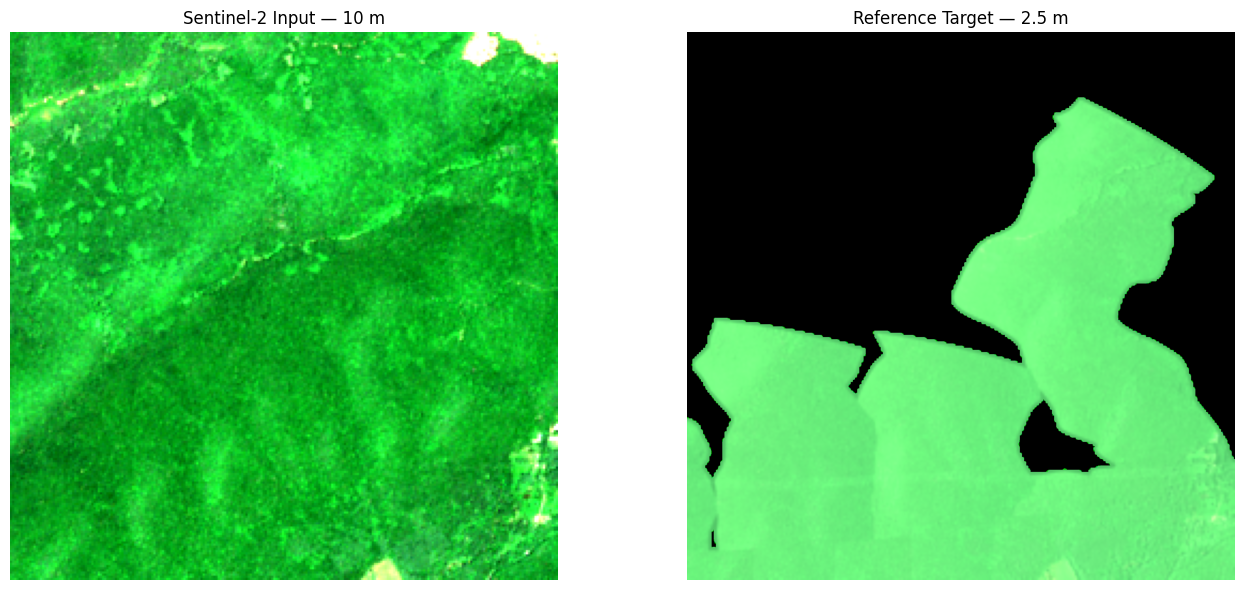

In [33]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# RGB Visualization: 10 m vs 2.5 m
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# SEN2NEON band order:
# B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12

# RGB = B4 (Red), B3 (Green), B2 (Blue)
rgb_lr = np.stack(
    [
        lr_float[3],  # B4
        lr_float[2],  # B3
        lr_float[1],  # B2
    ],
    axis=-1
)

rgb_hr = np.stack(
    [
        hr_float[3],  # B4
        hr_float[2],  # B3
        hr_float[1],  # B2
    ],
    axis=-1
)

# Percentile normalization for visualization only
def normalize_rgb(image):
    low = np.percentile(image, 2)
    high = np.percentile(image, 98)

    image = (image - low) / (high - low + 1e-8)

    return np.clip(image, 0, 1)

rgb_lr_display = normalize_rgb(rgb_lr)
rgb_hr_display = normalize_rgb(rgb_hr)

# Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_lr_display)
plt.title("Sentinel-2 Input — 10 m")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rgb_hr_display)
plt.title("Reference Target — 2.5 m")
plt.axis("off")

plt.tight_layout()
plt.show()

LR shape: (12, 256, 256)
HR shape: (12, 1024, 1024)
HR valid pixels:   559,283
HR NoData pixels:  489,293
HR valid coverage: 53.34%
HR NoData:         46.66%

LR zero pixels: 0
LR zero coverage: 0.00%


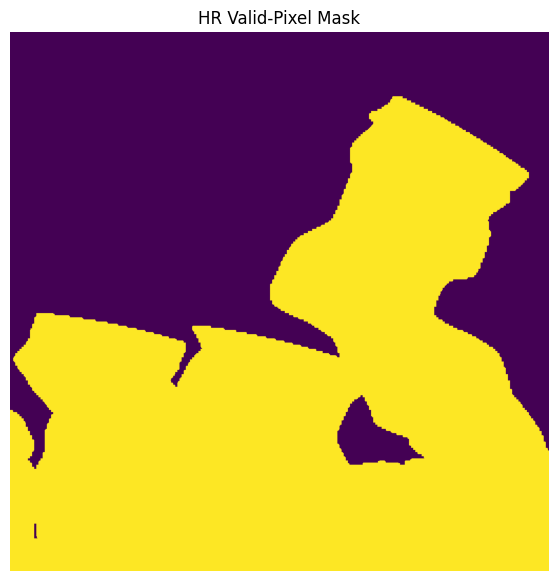

In [34]:
# ============================================================
# GeoSR-NTRO — CELL 11
# Check HR NoData / Valid Pixel Coverage
# ============================================================

import numpy as np

print("LR shape:", lr_float.shape)
print("HR shape:", hr_float.shape)

# Check pixels where all HR bands are zero
hr_nodata_mask = np.all(hr_float == 0, axis=0)

valid_pixels = np.sum(~hr_nodata_mask)
total_pixels = hr_nodata_mask.size
valid_percentage = 100 * valid_pixels / total_pixels
nodata_percentage = 100 * np.sum(hr_nodata_mask) / total_pixels

print(f"HR valid pixels:   {valid_pixels:,}")
print(f"HR NoData pixels:  {np.sum(hr_nodata_mask):,}")
print(f"HR valid coverage: {valid_percentage:.2f}%")
print(f"HR NoData:         {nodata_percentage:.2f}%")

# Check whether LR contains zero pixels
lr_nodata_mask = np.all(lr_float == 0, axis=0)

print()
print(f"LR zero pixels: {np.sum(lr_nodata_mask):,}")
print(f"LR zero coverage: {100 * np.sum(lr_nodata_mask) / lr_nodata_mask.size:.2f}%")

# Visualize the HR validity mask
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.imshow(~hr_nodata_mask)
plt.title("HR Valid-Pixel Mask")
plt.axis("off")
plt.show()

In [35]:
# ============================================================
# GeoSR-NTRO — CELL 12
# Create Training Validity Mask
# ============================================================

import numpy as np

# HR pixels are valid if at least one band contains reflectance.
# Since true valid pixels can have very small reflectance,
# we only treat pixels where ALL bands are exactly zero as NoData.

hr_valid_mask = ~np.all(hr_float == 0, axis=0)

print("HR validity mask created.")
print("Mask shape:", hr_valid_mask.shape)
print("Mask dtype:", hr_valid_mask.dtype)
print("Valid pixels:", np.sum(hr_valid_mask))
print("Valid percentage:",
      round(100 * np.mean(hr_valid_mask), 2), "%")

# Safety checks
assert hr_valid_mask.shape == (1024, 1024)
assert hr_valid_mask.dtype == bool
assert np.any(hr_valid_mask)
assert np.any(~hr_valid_mask)

print("\nAll mask checks PASSED.")

HR validity mask created.
Mask shape: (1024, 1024)
Mask dtype: bool
Valid pixels: 559283
Valid percentage: 53.34 %

All mask checks PASSED.


In [36]:
# ============================================================
# GeoSR-NTRO — CELL 13
# Bicubic Super-Resolution Baseline
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Convert LR image:
# (12, 256, 256) -> (1, 12, 256, 256)
lr_tensor = torch.from_numpy(lr_float).unsqueeze(0)

print("Input tensor shape:", lr_tensor.shape)

# Bicubic upsampling: 10 m -> 2.5 m = 4x
with torch.no_grad():
    bicubic_tensor = F.interpolate(
        lr_tensor,
        size=(1024, 1024),
        mode="bicubic",
        align_corners=False
    )

bicubic = bicubic_tensor.squeeze(0).numpy()

print("Bicubic output shape:", bicubic.shape)
print("Bicubic dtype:", bicubic.dtype)
print(
    "Bicubic range:",
    round(float(bicubic.min()), 4),
    "to",
    round(float(bicubic.max()), 4)
)

# Safety checks
assert bicubic.shape == (12, 1024, 1024)
assert np.isfinite(bicubic).all()

print("\nBicubic baseline checks PASSED.")

Input tensor shape: torch.Size([1, 12, 256, 256])
Bicubic output shape: (12, 1024, 1024)
Bicubic dtype: float32
Bicubic range: 0.016 to 0.726

Bicubic baseline checks PASSED.


In [37]:
# ============================================================
# GeoSR-NTRO — CELL 14
# Bicubic Baseline Evaluation
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Use only valid HR pixels
# ------------------------------------------------------------

mask = hr_valid_mask

# Shape:
# bicubic -> (12, 1024, 1024)
# hr_float -> (12, 1024, 1024)

pred = bicubic[:, mask]
target = hr_float[:, mask]

print("Valid evaluation pixels:", target.shape[1])
print("Number of bands:", target.shape[0])

# ------------------------------------------------------------
# 2. MAE
# ------------------------------------------------------------

mae = np.mean(np.abs(pred - target))

# ------------------------------------------------------------
# 3. RMSE
# ------------------------------------------------------------

rmse = np.sqrt(np.mean((pred - target) ** 2))

# ------------------------------------------------------------
# 4. PSNR
# ------------------------------------------------------------

# Reflectance is normalized to approximately [0, 1].
MAX_VALUE = 1.0

mse = np.mean((pred - target) ** 2)

psnr = 10 * np.log10(
    (MAX_VALUE ** 2) / (mse + 1e-12)
)

# ------------------------------------------------------------
# 5. Spectral Angle Mapper (SAM)
# ------------------------------------------------------------

# Compare the spectral vector at every valid pixel.

dot_product = np.sum(pred * target, axis=0)

pred_norm = np.linalg.norm(pred, axis=0)
target_norm = np.linalg.norm(target, axis=0)

cosine_similarity = dot_product / (
    pred_norm * target_norm + 1e-8
)

cosine_similarity = np.clip(
    cosine_similarity,
    -1.0,
    1.0
)

sam = np.arccos(cosine_similarity)

# Convert radians -> degrees
sam_degrees = np.degrees(sam)

mean_sam = np.mean(sam_degrees)

# ------------------------------------------------------------
# 6. Print results
# ------------------------------------------------------------

print("\n==============================")
print("BICUBIC BASELINE RESULTS")
print("==============================")

print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"PSNR : {psnr:.3f} dB")
print(f"SAM  : {mean_sam:.3f} degrees")

print("\nEvaluation completed successfully.")

Valid evaluation pixels: 559283
Number of bands: 12

BICUBIC BASELINE RESULTS
MAE  : 0.013823
RMSE : 0.026395
PSNR : 31.570 dB
SAM  : 1.389 degrees

Evaluation completed successfully.


In [38]:
# ============================================================
# GeoSR-NTRO — CELL 15
# Save Bicubic Baseline Results
# ============================================================

import os
import json

RESULTS_ROOT = os.path.join(
    "/content/drive/MyDrive/GeoSR-NTRO",
    "results"
)

os.makedirs(RESULTS_ROOT, exist_ok=True)

bicubic_results = {
    "tile_id": str(row["id"]),
    "input_resolution_m": 10.0,
    "target_resolution_m": 2.5,
    "scale_factor": 4,
    "bands": 12,
    "valid_pixel_count": int(np.sum(hr_valid_mask)),
    "valid_pixel_percentage": float(100 * np.mean(hr_valid_mask)),
    "MAE": float(mae),
    "RMSE": float(rmse),
    "PSNR_dB": float(psnr),
    "SAM_degrees": float(mean_sam),
}

baseline_path = os.path.join(
    RESULTS_ROOT,
    "bicubic_baseline.json"
)

with open(baseline_path, "w") as f:
    json.dump(bicubic_results, f, indent=4)

print("Baseline results saved to:")
print(baseline_path)

print("\nSaved results:")
for key, value in bicubic_results.items():
    print(f"{key}: {value}")

Baseline results saved to:
/content/drive/MyDrive/GeoSR-NTRO/results/bicubic_baseline.json

Saved results:
tile_id: 2018_MLBS_3__0_2
input_resolution_m: 10.0
target_resolution_m: 2.5
scale_factor: 4
bands: 12
valid_pixel_count: 559283
valid_pixel_percentage: 53.33738327026367
MAE: 0.013822939246892929
RMSE: 0.026395156979560852
PSNR_dB: 31.569517135620117
SAM_degrees: 1.3886921405792236


In [39]:
# ============================================================
# GeoSR-NTRO — CELL 16
# Create Project Structure
# ============================================================

import os

PROJECT_ROOT = "/content/drive/MyDrive/GeoSR-NTRO"

folders = [
    "data",
    "data/sen2neon",
    "configs",
    "scripts",
    "src",
    "src/data",
    "src/models",
    "src/losses",
    "src/evaluation",
    "src/utils",
    "results",
    "checkpoints",
    "outputs",
]

for folder in folders:
    path = os.path.join(PROJECT_ROOT, folder)
    os.makedirs(path, exist_ok=True)

print("GeoSR-NTRO project structure created.\n")

for folder in folders:
    print("✓", os.path.join(PROJECT_ROOT, folder))

GeoSR-NTRO project structure created.

✓ /content/drive/MyDrive/GeoSR-NTRO/data
✓ /content/drive/MyDrive/GeoSR-NTRO/data/sen2neon
✓ /content/drive/MyDrive/GeoSR-NTRO/configs
✓ /content/drive/MyDrive/GeoSR-NTRO/scripts
✓ /content/drive/MyDrive/GeoSR-NTRO/src
✓ /content/drive/MyDrive/GeoSR-NTRO/src/data
✓ /content/drive/MyDrive/GeoSR-NTRO/src/models
✓ /content/drive/MyDrive/GeoSR-NTRO/src/losses
✓ /content/drive/MyDrive/GeoSR-NTRO/src/evaluation
✓ /content/drive/MyDrive/GeoSR-NTRO/src/utils
✓ /content/drive/MyDrive/GeoSR-NTRO/results
✓ /content/drive/MyDrive/GeoSR-NTRO/checkpoints
✓ /content/drive/MyDrive/GeoSR-NTRO/outputs


In [40]:
# ============================================================
# GeoSR-NTRO — CELL 17
# Create Reusable Preprocessing Module
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO")
PREPROCESSING_FILE = PROJECT_ROOT / "src" / "data" / "preprocessing.py"

preprocessing_code = r'''
import numpy as np
import rasterio


REFLECTANCE_SCALE = 10000.0
EXPECTED_BANDS = 12
SCALE_FACTOR = 4


def read_geotiff(path):
    """
    Read a GeoTIFF and return the image array and metadata.
    """
    with rasterio.open(path) as src:
        image = src.read()
        profile = src.profile
        transform = src.transform
        crs = src.crs
        bounds = src.bounds

    return image, profile, transform, crs, bounds


def convert_to_reflectance(image):
    """
    Convert uint16 Sentinel-2 reflectance values
    to float32 reflectance values.
    """
    return image.astype(np.float32) / REFLECTANCE_SCALE


def create_validity_mask(hr_reflectance):
    """
    Create a pixel-wise HR validity mask.

    A pixel is considered NoData when all HR bands
    are exactly zero.
    """
    return ~np.all(hr_reflectance == 0, axis=0)


def validate_lr_hr_alignment(lr, hr, lr_transform, hr_transform,
                              lr_crs, hr_crs):
    """
    Validate expected Sentinel-2 LR / HR alignment.
    """

    if lr.shape[0] != EXPECTED_BANDS:
        raise ValueError(
            f"Expected {EXPECTED_BANDS} LR bands, "
            f"got {lr.shape[0]}"
        )

    if hr.shape[0] != EXPECTED_BANDS:
        raise ValueError(
            f"Expected {EXPECTED_BANDS} HR bands, "
            f"got {hr.shape[0]}"
        )

    expected_hr_height = lr.shape[1] * SCALE_FACTOR
    expected_hr_width = lr.shape[2] * SCALE_FACTOR

    if hr.shape[1] != expected_hr_height:
        raise ValueError(
            f"HR height mismatch: expected "
            f"{expected_hr_height}, got {hr.shape[1]}"
        )

    if hr.shape[2] != expected_hr_width:
        raise ValueError(
            f"HR width mismatch: expected "
            f"{expected_hr_width}, got {hr.shape[2]}"
        )

    if lr_crs != hr_crs:
        raise ValueError("LR and HR CRS do not match.")

    if not np.allclose(
        lr_transform.c,
        hr_transform.c,
        atol=1e-6
    ):
        raise ValueError("LR and HR spatial origins do not match.")

    if not np.allclose(
        lr_transform.f,
        hr_transform.f,
        atol=1e-6
    ):
        raise ValueError("LR and HR spatial origins do not match.")

    return True


def load_aligned_pair(lr_path, hr_path):
    """
    Load one aligned LR/HR SEN2NEON pair.

    Returns
    -------
    lr_reflectance : np.ndarray
        Shape: (bands, H, W)
    hr_reflectance : np.ndarray
        Shape: (bands, 4H, 4W)
    hr_valid_mask : np.ndarray
        Shape: (4H, 4W)
    metadata : dict
    """

    lr, lr_profile, lr_transform, lr_crs, lr_bounds = read_geotiff(
        lr_path
    )

    hr, hr_profile, hr_transform, hr_crs, hr_bounds = read_geotiff(
        hr_path
    )

    validate_lr_hr_alignment(
        lr,
        hr,
        lr_transform,
        hr_transform,
        lr_crs,
        hr_crs,
    )

    lr_reflectance = convert_to_reflectance(lr)
    hr_reflectance = convert_to_reflectance(hr)

    hr_valid_mask = create_validity_mask(hr_reflectance)

    metadata = {
        "lr_profile": lr_profile,
        "hr_profile": hr_profile,
        "lr_transform": lr_transform,
        "hr_transform": hr_transform,
        "lr_crs": str(lr_crs),
        "hr_crs": str(hr_crs),
        "lr_bounds": tuple(lr_bounds),
        "hr_bounds": tuple(hr_bounds),
        "scale_factor": SCALE_FACTOR,
        "reflectance_scale": REFLECTANCE_SCALE,
    }

    return (
        lr_reflectance,
        hr_reflectance,
        hr_valid_mask,
        metadata,
    )
'''

PREPROCESSING_FILE.write_text(preprocessing_code)

print("Created:")
print(PREPROCESSING_FILE)

print("\nFile size:", PREPROCESSING_FILE.stat().st_size, "bytes")
print("Preprocessing module creation PASSED.")

Created:
/content/drive/MyDrive/GeoSR-NTRO/src/data/preprocessing.py

File size: 3545 bytes
Preprocessing module creation PASSED.


In [41]:
# ============================================================
# GeoSR-NTRO — DEBUG
# Locate downloaded SEN2NEON TIFF files
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO")

print("Searching inside:", PROJECT_ROOT)

matches = list(PROJECT_ROOT.rglob("2018_MLBS_3__0_2.tif"))

print("\nMatches found:", len(matches))

for path in matches:
    print(path)

Searching inside: /content/drive/MyDrive/GeoSR-NTRO

Matches found: 2
/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/neon_2.5m_linearized/2018_MLBS_3__0_2.tif
/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/s2_l2a_10m/2018_MLBS_3__0_2.tif


In [42]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Re-download One SEN2NEON LR/HR Pair
# ============================================================

from pathlib import Path
from huggingface_hub import snapshot_download

DATA_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

LR_FILE = "s2_l2a_10m/2018_MLBS_3__0_2.tif"
HR_FILE = "neon_2.5m_linearized/2018_MLBS_3__0_2.tif"

print("Downloading verified SEN2NEON pair...")

snapshot_download(
    repo_id="isp-uv-es/SEN2NEON",
    repo_type="dataset",
    local_dir=str(DATA_ROOT),
    allow_patterns=[
        LR_FILE,
        HR_FILE,
    ],
)

LR_PATH = DATA_ROOT / LR_FILE
HR_PATH = DATA_ROOT / HR_FILE

print("\nLR exists:", LR_PATH.exists())
print("HR exists:", HR_PATH.exists())

print("\nLR:", LR_PATH)
print("HR:", HR_PATH)

assert LR_PATH.exists(), "LR TIFF was not downloaded."
assert HR_PATH.exists(), "HR TIFF was not downloaded."

print("\nSEN2NEON pair download: PASSED")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


LR exists: True
HR exists: True

LR: /content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/s2_l2a_10m/2018_MLBS_3__0_2.tif
HR: /content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/neon_2.5m_linearized/2018_MLBS_3__0_2.tif

SEN2NEON pair download: PASSED


In [43]:
# ============================================================
# GeoSR-NTRO — VERIFY DOWNLOADED FILES
# ============================================================

from pathlib import Path

LR_PATH = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/"
    "s2_l2a_10m/2018_MLBS_3__0_2.tif"
)

HR_PATH = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/"
    "neon_2.5m_linearized/2018_MLBS_3__0_2.tif"
)

print("LR exists:", LR_PATH.exists())
print("LR size:", round(LR_PATH.stat().st_size / 1024**2, 2), "MB")

print("\nHR exists:", HR_PATH.exists())
print("HR size:", round(HR_PATH.stat().st_size / 1024**2, 2), "MB")

assert LR_PATH.exists()
assert HR_PATH.exists()

print("\nFile existence check: PASSED")

LR exists: True
LR size: 0.43 MB

HR exists: True
HR size: 5.23 MB

File existence check: PASSED


In [44]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Test Reusable Preprocessing Module
# ============================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO")
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from data.preprocessing import load_aligned_pair

LR_PATH = (
    PROJECT_ROOT
    / "data"
    / "sen2neon"
    / "s2_l2a_10m"
    / "2018_MLBS_3__0_2.tif"
)

HR_PATH = (
    PROJECT_ROOT
    / "data"
    / "sen2neon"
    / "neon_2.5m_linearized"
    / "2018_MLBS_3__0_2.tif"
)

# Load the pair through our reusable preprocessing module
lr_reflectance, hr_reflectance, hr_valid_mask, metadata = load_aligned_pair(
    LR_PATH,
    HR_PATH,
)

print("LR shape:", lr_reflectance.shape)
print("HR shape:", hr_reflectance.shape)
print("LR dtype:", lr_reflectance.dtype)
print("HR dtype:", hr_reflectance.dtype)
print("HR mask shape:", hr_valid_mask.shape)
print("HR valid pixels:", int(hr_valid_mask.sum()))
print("HR valid percentage:", round(100 * hr_valid_mask.mean(), 2), "%")
print("LR CRS:", metadata["lr_crs"])
print("HR CRS:", metadata["hr_crs"])
print("Scale factor:", metadata["scale_factor"])
print("Reflectance scale:", metadata["reflectance_scale"])

# Automated checks
assert lr_reflectance.shape == (12, 256, 256)
assert hr_reflectance.shape == (12, 1024, 1024)
assert lr_reflectance.dtype == "float32"
assert hr_reflectance.dtype == "float32"
assert hr_valid_mask.shape == (1024, 1024)
assert metadata["lr_crs"] == metadata["hr_crs"]
assert metadata["scale_factor"] == 4
assert metadata["reflectance_scale"] == 10000.0

print("\nPreprocessing module test: PASSED")

LR shape: (12, 256, 256)
HR shape: (12, 1024, 1024)
LR dtype: float32
HR dtype: float32
HR mask shape: (1024, 1024)
HR valid pixels: 559283
HR valid percentage: 53.34 %
LR CRS: EPSG:32617
HR CRS: EPSG:32617
Scale factor: 4
Reflectance scale: 10000.0

Preprocessing module test: PASSED


In [45]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# SEN2NEON Dataset Loader
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO")
DATA_ROOT = PROJECT_ROOT / "data" / "sen2neon"

DATASET_FILE = PROJECT_ROOT / "src" / "data" / "sen2neon_dataset.py"

dataset_code = r'''
from pathlib import Path
import pandas as pd

from data.preprocessing import load_aligned_pair


class SEN2NEONDataset:
    """
    Lightweight SEN2NEON dataset loader.

    Metadata comes from metadata.csv.
    LR/HR GeoTIFF files are loaded only when requested.
    """

    def __init__(self, data_root):
        self.data_root = Path(data_root)

        metadata_path = self.data_root / "metadata.csv"

        if not metadata_path.exists():
            raise FileNotFoundError(
                f"Metadata file not found: {metadata_path}"
            )

        self.metadata = pd.read_csv(metadata_path)

    def __len__(self):
        return len(self.metadata)

    def get_metadata(self, index):
        return self.metadata.iloc[index]

    def get_paths(self, index):
        row = self.get_metadata(index)

        lr_path = self.data_root / str(row["lr"])
        hr_path = self.data_root / str(row["hr"])

        return lr_path, hr_path

    def load_tile(self, index):
        lr_path, hr_path = self.get_paths(index)

        if not lr_path.exists():
            raise FileNotFoundError(
                f"LR file not found: {lr_path}"
            )

        if not hr_path.exists():
            raise FileNotFoundError(
                f"HR file not found: {hr_path}"
            )

        lr, hr, valid_mask, metadata = load_aligned_pair(
            lr_path,
            hr_path,
        )

        tile_metadata = self.get_metadata(index).to_dict()

        return {
            "lr": lr,
            "hr": hr,
            "valid_mask": valid_mask,
            "metadata": metadata,
            "tile_metadata": tile_metadata,
        }
'''

DATASET_FILE.write_text(dataset_code)

print("Created:", DATASET_FILE)
print("File size:", DATASET_FILE.stat().st_size, "bytes")
print("\nSEN2NEON dataset loader creation: PASSED")

Created: /content/drive/MyDrive/GeoSR-NTRO/src/data/sen2neon_dataset.py
File size: 1658 bytes

SEN2NEON dataset loader creation: PASSED


In [46]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Restore SEN2NEON Metadata
# ============================================================

from pathlib import Path
from huggingface_hub import snapshot_download

DATA_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

print("Downloading SEN2NEON metadata...")

snapshot_download(
    repo_id="isp-uv-es/SEN2NEON",
    repo_type="dataset",
    local_dir=str(DATA_ROOT),
    allow_patterns=[
        "metadata.csv",
        "metadata.jsonl",
        "metadata.parquet",
        "README.md",
        "DATASET_RELEASE_NOTES.md",
    ],
)

METADATA_PATH = DATA_ROOT / "metadata.csv"

print("\nMetadata exists:", METADATA_PATH.exists())

if METADATA_PATH.exists():
    print("Metadata path:", METADATA_PATH)
    print("Metadata size:", round(METADATA_PATH.stat().st_size / 1024, 2), "KB")

assert METADATA_PATH.exists(), "metadata.csv was not downloaded."

print("\nMetadata restoration: PASSED")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]


Metadata exists: True
Metadata path: /content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/metadata.csv
Metadata size: 3050.37 KB

Metadata restoration: PASSED


In [47]:
# ============================================================
# GeoSR-NTRO — VERIFY SEN2NEON METADATA
# ============================================================

import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon")
METADATA_PATH = DATA_ROOT / "metadata.csv"

df = pd.read_csv(METADATA_PATH)

print("Number of tiles:", len(df))
print("Number of columns:", len(df.columns))

print("\nFirst tile ID:", df.iloc[0]["id"])
print("First tile LR:", df.iloc[0]["lr"])
print("First tile HR:", df.iloc[0]["hr"])

assert len(df) == 2269
assert "lr" in df.columns
assert "hr" in df.columns
assert "id" in df.columns

print("\nMetadata verification: PASSED")

Number of tiles: 2269
Number of columns: 66

First tile ID: 2018_MLBS_3__0_2
First tile LR: s2_l2a_10m/2018_MLBS_3__0_2.tif
First tile HR: neon_2.5m_linearized/2018_MLBS_3__0_2.tif

Metadata verification: PASSED


In [48]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Test SEN2NEON Dataset Loader
# ============================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO")
SRC_ROOT = PROJECT_ROOT / "src"
DATA_ROOT = PROJECT_ROOT / "data" / "sen2neon"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from data.sen2neon_dataset import SEN2NEONDataset

# Create dataset
dataset = SEN2NEONDataset(DATA_ROOT)

print("Dataset created successfully.")
print("Number of tiles:", len(dataset))

# Inspect first tile
row = dataset.get_metadata(0)

print("\nFirst tile:")
print("ID:", row["id"])
print("Split:", row["split"])
print("LR:", row["lr"])
print("HR:", row["hr"])

# Resolve paths
lr_path, hr_path = dataset.get_paths(0)

print("\nResolved paths:")
print("LR exists:", lr_path.exists())
print("HR exists:", hr_path.exists())

# Load actual tile
sample = dataset.load_tile(0)

print("\nLoaded tile:")
print("LR shape:", sample["lr"].shape)
print("HR shape:", sample["hr"].shape)
print("Valid mask shape:", sample["valid_mask"].shape)
print("LR dtype:", sample["lr"].dtype)
print("HR dtype:", sample["hr"].dtype)

print("\nValid HR pixels:", int(sample["valid_mask"].sum()))
print(
    "Valid HR percentage:",
    round(100 * sample["valid_mask"].mean(), 2),
    "%"
)

# Automated checks
assert len(dataset) == 2269
assert lr_path.exists()
assert hr_path.exists()

assert sample["lr"].shape == (12, 256, 256)
assert sample["hr"].shape == (12, 1024, 1024)
assert sample["valid_mask"].shape == (1024, 1024)

assert sample["lr"].dtype == "float32"
assert sample["hr"].dtype == "float32"

print("\nSEN2NEON dataset loader test: PASSED")

Dataset created successfully.
Number of tiles: 2269

First tile:
ID: 2018_MLBS_3__0_2
Split: validation
LR: s2_l2a_10m/2018_MLBS_3__0_2.tif
HR: neon_2.5m_linearized/2018_MLBS_3__0_2.tif

Resolved paths:
LR exists: True
HR exists: True

Loaded tile:
LR shape: (12, 256, 256)
HR shape: (12, 1024, 1024)
Valid mask shape: (1024, 1024)
LR dtype: float32
HR dtype: float32

Valid HR pixels: 559283
Valid HR percentage: 53.34 %

SEN2NEON dataset loader test: PASSED


In [49]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# PyTorch Dataset Wrapper
# ============================================================

import sys
from pathlib import Path

import torch
from torch.utils.data import Dataset

PROJECT_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO")
SRC_ROOT = PROJECT_ROOT / "src"
DATA_ROOT = PROJECT_ROOT / "data" / "sen2neon"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from data.sen2neon_dataset import SEN2NEONDataset


class SEN2NEONTorchDataset(Dataset):

    def __init__(self, data_root, indices=None):
        self.dataset = SEN2NEONDataset(data_root)

        if indices is None:
            self.indices = list(range(len(self.dataset)))
        else:
            self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        real_index = self.indices[idx]

        sample = self.dataset.load_tile(real_index)

        lr = torch.from_numpy(sample["lr"]).float()
        hr = torch.from_numpy(sample["hr"]).float()

        valid_mask = torch.from_numpy(
            sample["valid_mask"]
        ).bool()

        # Add channel dimension to mask
        valid_mask = valid_mask.unsqueeze(0)

        return {
            "lr": lr,
            "hr": hr,
            "valid_mask": valid_mask,
            "metadata": sample["metadata"],
            "tile_metadata": sample["tile_metadata"],
        }


# ------------------------------------------------------------
# Create dataset
# ------------------------------------------------------------

torch_dataset = SEN2NEONTorchDataset(
    data_root=DATA_ROOT
)

print("PyTorch dataset created.")
print("Number of samples:", len(torch_dataset))


# ------------------------------------------------------------
# Load one sample
# ------------------------------------------------------------

sample = torch_dataset[0]

print("\nSample contents:")
print("LR shape:", sample["lr"].shape)
print("HR shape:", sample["hr"].shape)
print("Valid mask shape:", sample["valid_mask"].shape)

print("\nTensor types:")
print("LR:", sample["lr"].dtype)
print("HR:", sample["hr"].dtype)
print("Mask:", sample["valid_mask"].dtype)


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

assert len(torch_dataset) == 2269

assert sample["lr"].shape == (12, 256, 256)
assert sample["hr"].shape == (12, 1024, 1024)
assert sample["valid_mask"].shape == (1, 1024, 1024)

assert sample["lr"].dtype == torch.float32
assert sample["hr"].dtype == torch.float32
assert sample["valid_mask"].dtype == torch.bool

print("\nPyTorch Dataset test: PASSED")

PyTorch dataset created.
Number of samples: 2269

Sample contents:
LR shape: torch.Size([12, 256, 256])
HR shape: torch.Size([12, 1024, 1024])
Valid mask shape: torch.Size([1, 1024, 1024])

Tensor types:
LR: torch.float32
HR: torch.float32
Mask: torch.bool

PyTorch Dataset test: PASSED


In [50]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Geographic Tile-Level Dataset Split
# ============================================================

import sys
import json
from pathlib import Path

import numpy as np

PROJECT_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO")
SRC_ROOT = PROJECT_ROOT / "src"
DATA_ROOT = PROJECT_ROOT / "data" / "sen2neon"
CONFIG_ROOT = PROJECT_ROOT / "configs"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from data.sen2neon_dataset import SEN2NEONDataset


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SEED = 42

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6


# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

dataset = SEN2NEONDataset(DATA_ROOT)

num_tiles = len(dataset)

print("Total tiles:", num_tiles)


# ------------------------------------------------------------
# Create reproducible shuffled indices
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)

indices = np.arange(num_tiles)
rng.shuffle(indices)


# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

train_end = int(num_tiles * TRAIN_RATIO)
val_end = train_end + int(num_tiles * VAL_RATIO)

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]


# ------------------------------------------------------------
# Display split information
# ------------------------------------------------------------

print("\nDataset split:")
print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))
print("Total:", len(train_indices) + len(val_indices) + len(test_indices))


# ------------------------------------------------------------
# Verify no overlap
# ------------------------------------------------------------

train_set = set(train_indices)
val_set = set(val_indices)
test_set = set(test_indices)

assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)

assert (
    len(train_indices)
    + len(val_indices)
    + len(test_indices)
    == num_tiles
)


# ------------------------------------------------------------
# Save split indices
# ------------------------------------------------------------

split_data = {
    "seed": SEED,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "train_indices": train_indices.tolist(),
    "val_indices": val_indices.tolist(),
    "test_indices": test_indices.tolist(),
}

CONFIG_ROOT.mkdir(parents=True, exist_ok=True)

split_path = CONFIG_ROOT / "dataset_split.json"

with open(split_path, "w") as f:
    json.dump(split_data, f, indent=2)


print("\nSaved split configuration:")
print(split_path)

print("\nDataset split test: PASSED")


Total tiles: 2269

Dataset split:
Train: 1815
Validation: 226
Test: 228
Total: 2269

Saved split configuration:
/content/drive/MyDrive/GeoSR-NTRO/configs/dataset_split.json

Dataset split test: PASSED


In [51]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Aligned LR/HR Patch Extraction
# ============================================================

import sys
from pathlib import Path

import numpy as np
import torch

PROJECT_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO")
SRC_ROOT = PROJECT_ROOT / "src"
DATA_ROOT = PROJECT_ROOT / "data" / "sen2neon"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from data.sen2neon_dataset import SEN2NEONDataset


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SCALE_FACTOR = 4

LR_PATCH_SIZE = 64
HR_PATCH_SIZE = LR_PATCH_SIZE * SCALE_FACTOR

assert HR_PATCH_SIZE == 256


# ------------------------------------------------------------
# Patch extraction function
# ------------------------------------------------------------

def extract_aligned_patch(
    lr,
    hr,
    valid_mask,
    top,
    left,
    lr_patch_size=LR_PATCH_SIZE,
    scale=SCALE_FACTOR,
):
    """
    Extract spatially aligned LR and HR patches.

    LR:
        [C, H, W]

    HR:
        [C, H*scale, W*scale]

    valid_mask:
        [H*scale, W*scale]
    """

    lr_h = lr_patch_size
    lr_w = lr_patch_size

    hr_h = lr_h * scale
    hr_w = lr_w * scale

    hr_top = top * scale
    hr_left = left * scale

    lr_patch = lr[
        :,
        top:top + lr_h,
        left:left + lr_w
    ]

    hr_patch = hr[
        :,
        hr_top:hr_top + hr_h,
        hr_left:hr_left + hr_w
    ]

    mask_patch = valid_mask[
        hr_top:hr_top + hr_h,
        hr_left:hr_left + hr_w
    ]

    return lr_patch, hr_patch, mask_patch


# ------------------------------------------------------------
# Load first tile
# ------------------------------------------------------------

dataset = SEN2NEONDataset(DATA_ROOT)

sample = dataset.load_tile(0)

lr = sample["lr"]
hr = sample["hr"]
valid_mask = sample["valid_mask"]


print("Full LR:", lr.shape)
print("Full HR:", hr.shape)
print("Full mask:", valid_mask.shape)


# ------------------------------------------------------------
# Extract a patch
# ------------------------------------------------------------

top = 32
left = 48

lr_patch, hr_patch, mask_patch = extract_aligned_patch(
    lr,
    hr,
    valid_mask,
    top=top,
    left=left,
)


# ------------------------------------------------------------
# Inspect
# ------------------------------------------------------------

print("\nExtracted patches:")
print("LR patch:", lr_patch.shape)
print("HR patch:", hr_patch.shape)
print("Mask patch:", mask_patch.shape)

print("\nPatch ranges:")
print(
    "LR rows:",
    top,
    "to",
    top + LR_PATCH_SIZE
)

print(
    "LR cols:",
    left,
    "to",
    left + LR_PATCH_SIZE
)

print(
    "HR rows:",
    top * SCALE_FACTOR,
    "to",
    (top + LR_PATCH_SIZE) * SCALE_FACTOR
)

print(
    "HR cols:",
    left * SCALE_FACTOR,
    "to",
    (left + LR_PATCH_SIZE) * SCALE_FACTOR
)


# ------------------------------------------------------------
# Convert to PyTorch tensors
# ------------------------------------------------------------

lr_tensor = torch.from_numpy(lr_patch).float()
hr_tensor = torch.from_numpy(hr_patch).float()
mask_tensor = torch.from_numpy(mask_patch).bool()


print("\nPyTorch tensors:")
print("LR:", lr_tensor.shape)
print("HR:", hr_tensor.shape)
print("Mask:", mask_tensor.shape)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert lr_patch.shape == (12, 64, 64)
assert hr_patch.shape == (12, 256, 256)
assert mask_patch.shape == (256, 256)

assert lr_tensor.dtype == torch.float32
assert hr_tensor.dtype == torch.float32
assert mask_tensor.dtype == torch.bool

# Verify exact 4x spatial relationship
assert hr_patch.shape[1] == lr_patch.shape[1] * SCALE_FACTOR
assert hr_patch.shape[2] == lr_patch.shape[2] * SCALE_FACTOR

print("\nAligned patch extraction test: PASSED")

Full LR: (12, 256, 256)
Full HR: (12, 1024, 1024)
Full mask: (1024, 1024)

Extracted patches:
LR patch: (12, 64, 64)
HR patch: (12, 256, 256)
Mask patch: (256, 256)

Patch ranges:
LR rows: 32 to 96
LR cols: 48 to 112
HR rows: 128 to 384
HR cols: 192 to 448

PyTorch tensors:
LR: torch.Size([12, 64, 64])
HR: torch.Size([12, 256, 256])
Mask: torch.Size([256, 256])

Aligned patch extraction test: PASSED


In [52]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Random Valid Patch Sampler
# ============================================================

import numpy as np


LR_PATCH_SIZE = 64
SCALE_FACTOR = 4
HR_PATCH_SIZE = LR_PATCH_SIZE * SCALE_FACTOR

MIN_VALID_RATIO = 0.80


def sample_valid_patch(
    lr,
    hr,
    valid_mask,
    lr_patch_size=LR_PATCH_SIZE,
    scale=SCALE_FACTOR,
    min_valid_ratio=MIN_VALID_RATIO,
    max_attempts=100,
):
    """
    Randomly sample an aligned LR/HR patch.

    LR:
        [C, H, W]

    HR:
        [C, H*scale, W*scale]

    valid_mask:
        [H*scale, W*scale]
    """

    _, lr_height, lr_width = lr.shape

    max_top = lr_height - lr_patch_size
    max_left = lr_width - lr_patch_size

    if max_top < 0 or max_left < 0:
        raise ValueError("LR image is smaller than requested patch size.")

    for _ in range(max_attempts):

        top = np.random.randint(0, max_top + 1)
        left = np.random.randint(0, max_left + 1)

        hr_top = top * scale
        hr_left = left * scale

        hr_patch_size = lr_patch_size * scale

        lr_patch = lr[
            :,
            top:top + lr_patch_size,
            left:left + lr_patch_size
        ]

        hr_patch = hr[
            :,
            hr_top:hr_top + hr_patch_size,
            hr_left:hr_left + hr_patch_size
        ]

        mask_patch = valid_mask[
            hr_top:hr_top + hr_patch_size,
            hr_left:hr_left + hr_patch_size
        ]

        valid_ratio = mask_patch.mean()

        if valid_ratio >= min_valid_ratio:
            return {
                "lr": lr_patch,
                "hr": hr_patch,
                "valid_mask": mask_patch,
                "top": top,
                "left": left,
                "valid_ratio": float(valid_ratio),
            }

    raise RuntimeError(
        f"Could not find a patch with at least "
        f"{min_valid_ratio:.0%} valid HR pixels "
        f"after {max_attempts} attempts."
    )


# ------------------------------------------------------------
# Test on first tile
# ------------------------------------------------------------

dataset = SEN2NEONDataset(DATA_ROOT)

sample = dataset.load_tile(0)

patch = sample_valid_patch(
    sample["lr"],
    sample["hr"],
    sample["valid_mask"],
)


# ------------------------------------------------------------
# Inspect
# ------------------------------------------------------------

print("Sampled patch:")
print("LR shape:", patch["lr"].shape)
print("HR shape:", patch["hr"].shape)
print("Mask shape:", patch["valid_mask"].shape)

print("\nPatch location:")
print("LR top:", patch["top"])
print("LR left:", patch["left"])

print(
    "HR top:",
    patch["top"] * SCALE_FACTOR
)

print(
    "HR left:",
    patch["left"] * SCALE_FACTOR
)

print(
    "\nValid HR ratio:",
    round(patch["valid_ratio"] * 100, 2),
    "%"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert patch["lr"].shape == (12, 64, 64)
assert patch["hr"].shape == (12, 256, 256)
assert patch["valid_mask"].shape == (256, 256)

assert patch["valid_ratio"] >= MIN_VALID_RATIO

print("\nRandom valid patch sampler: PASSED")

Sampled patch:
LR shape: (12, 64, 64)
HR shape: (12, 256, 256)
Mask shape: (256, 256)

Patch location:
LR top: 192
LR left: 131
HR top: 768
HR left: 524

Valid HR ratio: 89.63 %

Random valid patch sampler: PASSED


In [53]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# Lazy SEN2NEON Tile Downloader
# ============================================================

from pathlib import Path

from huggingface_hub import hf_hub_download


DATA_ROOT = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon"
)

HF_REPO = "isp-uv-es/SEN2NEON"


def ensure_tile_downloaded(dataset, tile_index):
    """
    Download only the LR and HR files required for one tile.
    """

    row = dataset.get_metadata(tile_index)

    lr_relative = str(row["lr"])
    hr_relative = str(row["hr"])

    lr_path = DATA_ROOT / lr_relative
    hr_path = DATA_ROOT / hr_relative

    # Download LR only if missing
    if not lr_path.exists():

        print(
            f"Downloading LR tile: {lr_relative}"
        )

        hf_hub_download(
            repo_id=HF_REPO,
            repo_type="dataset",
            filename=lr_relative,
            local_dir=str(DATA_ROOT),
        )

    # Download HR only if missing
    if not hr_path.exists():

        print(
            f"Downloading HR tile: {hr_relative}"
        )

        hf_hub_download(
            repo_id=HF_REPO,
            repo_type="dataset",
            filename=hr_relative,
            local_dir=str(DATA_ROOT),
        )

    # Final verification
    if not lr_path.exists():
        raise FileNotFoundError(
            f"LR download failed: {lr_path}"
        )

    if not hr_path.exists():
        raise FileNotFoundError(
            f"HR download failed: {hr_path}"
        )

    return lr_path, hr_path


print("Lazy downloader created.")

# Test using the tile that caused the error
test_tile_index = train_indices[0]

print("\nTest tile index:", test_tile_index)

row = dataset.get_metadata(test_tile_index)

print("Tile ID:", row["id"])
print("LR:", row["lr"])
print("HR:", row["hr"])


lr_path, hr_path = ensure_tile_downloaded(
    dataset,
    test_tile_index
)

print("\nDownloaded/verified:")
print("LR exists:", lr_path.exists())
print("HR exists:", hr_path.exists())

print("\nLazy tile downloader test: PASSED")

Lazy downloader created.

Test tile index: 2239
Tile ID: 2024_UKFS_8__1_3
LR: s2_l2a_10m/2024_UKFS_8__1_3.tif
HR: neon_2.5m_linearized/2024_UKFS_8__1_3.tif

Downloaded/verified:
LR exists: True
HR exists: True

Lazy tile downloader test: PASSED


In [54]:
# ============================================================
# GeoSR-NTRO — Training Patch Dataset
# WITH LAZY TILE DOWNLOADING
# ============================================================

import torch
from torch.utils.data import Dataset


class SEN2NEONPatchDataset(Dataset):

    def __init__(
        self,
        data_root,
        indices,
        patches_per_tile=4,
        min_valid_ratio=0.80
    ):

        self.data_root = data_root
        self.indices = list(indices)
        self.patches_per_tile = patches_per_tile
        self.min_valid_ratio = min_valid_ratio

        self.dataset = SEN2NEONDataset(data_root)

        self.num_samples = (
            len(self.indices) * self.patches_per_tile
        )

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):

        # ----------------------------------------------------
        # Determine which tile this sample belongs to
        # ----------------------------------------------------

        tile_position = idx // self.patches_per_tile

        tile_index = self.indices[tile_position]

        # ----------------------------------------------------
        # Make sure this tile exists locally
        # ----------------------------------------------------

        ensure_tile_downloaded(
            self.dataset,
            tile_index
        )

        # ----------------------------------------------------
        # Load the tile
        # ----------------------------------------------------

        sample = self.dataset.load_tile(tile_index)

        # ----------------------------------------------------
        # Random valid aligned patch
        # ----------------------------------------------------

        patch = sample_valid_patch(
            sample["lr"],
            sample["hr"],
            sample["valid_mask"],
            lr_patch_size=64,
            scale=4,
            min_valid_ratio=self.min_valid_ratio
        )

        # ----------------------------------------------------
        # Convert NumPy → PyTorch tensors
        # ----------------------------------------------------

        lr = torch.from_numpy(
            patch["lr"]
        ).float()

        hr = torch.from_numpy(
            patch["hr"]
        ).float()

        valid_mask = torch.from_numpy(
            patch["valid_mask"]
        ).bool().unsqueeze(0)

        # ----------------------------------------------------
        # Return training sample
        # ----------------------------------------------------

        return {
            "lr": lr,
            "hr": hr,
            "valid_mask": valid_mask,

            "tile_index": tile_index,

            "top": patch["top"],
            "left": patch["left"],

            "valid_ratio": patch["valid_ratio"]
        }


# ============================================================
# Recreate training dataset
# ============================================================

train_dataset = SEN2NEONPatchDataset(
    data_root=DATA_ROOT,
    indices=train_indices,
    patches_per_tile=4,
    min_valid_ratio=0.80
)


print("Training patch dataset created.")

print("Training tiles:", len(train_indices))
print("Patches per tile:", train_dataset.patches_per_tile)
print("Total virtual training samples:", len(train_dataset))


# ============================================================
# Test
# ============================================================

print("\nTesting train_dataset[0] ...")

sample = train_dataset[0]

print("\nSample loaded successfully.")

print("LR shape:", sample["lr"].shape)
print("HR shape:", sample["hr"].shape)
print("Mask shape:", sample["valid_mask"].shape)

print("LR dtype:", sample["lr"].dtype)
print("HR dtype:", sample["hr"].dtype)
print("Mask dtype:", sample["valid_mask"].dtype)

print("Tile index:", sample["tile_index"])
print("Patch top:", sample["top"])
print("Patch left:", sample["left"])
print("Valid ratio:", sample["valid_ratio"])

print("\nTraining Patch Dataset test: PASSED")

Training patch dataset created.
Training tiles: 1815
Patches per tile: 4
Total virtual training samples: 7260

Testing train_dataset[0] ...

Sample loaded successfully.
LR shape: torch.Size([12, 64, 64])
HR shape: torch.Size([12, 256, 256])
Mask shape: torch.Size([1, 256, 256])
LR dtype: torch.float32
HR dtype: torch.float32
Mask dtype: torch.bool
Tile index: 2239
Patch top: 6
Patch left: 71
Valid ratio: 1.0

Training Patch Dataset test: PASSED


In [55]:
# ============================================================
# GeoSR-NTRO — PHASE 1
# PyTorch DataLoaders
# ============================================================

from torch.utils.data import DataLoader


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 2
NUM_WORKERS = 0


# ------------------------------------------------------------
# Create validation dataset
# ------------------------------------------------------------

val_dataset = SEN2NEONPatchDataset(
    data_root=DATA_ROOT,
    indices=val_indices,
    patches_per_tile=2,
    min_valid_ratio=0.80
)


# ------------------------------------------------------------
# Create test dataset
# ------------------------------------------------------------

test_dataset = SEN2NEONPatchDataset(
    data_root=DATA_ROOT,
    indices=test_indices,
    patches_per_tile=2,
    min_valid_ratio=0.80
)


# ------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


# ------------------------------------------------------------
# Print configuration
# ------------------------------------------------------------

print("DataLoaders created.")

print("\nTraining:")
print("  Tiles:", len(train_indices))
print("  Virtual samples:", len(train_dataset))
print("  Batches:", len(train_loader))
print("  Batch size:", BATCH_SIZE)

print("\nValidation:")
print("  Tiles:", len(val_indices))
print("  Virtual samples:", len(val_dataset))
print("  Batches:", len(val_loader))

print("\nTest:")
print("  Tiles:", len(test_indices))
print("  Virtual samples:", len(test_dataset))
print("  Batches:", len(test_loader))


# ------------------------------------------------------------
# Test one training batch
# ------------------------------------------------------------

print("\nLoading one training batch...")

batch = next(iter(train_loader))

print("\nBatch loaded successfully.")

print("LR batch shape:", batch["lr"].shape)
print("HR batch shape:", batch["hr"].shape)
print("Mask batch shape:", batch["valid_mask"].shape)

print("LR dtype:", batch["lr"].dtype)
print("HR dtype:", batch["hr"].dtype)
print("Mask dtype:", batch["valid_mask"].dtype)

print("\nLR value range:")
print(
    float(batch["lr"].min()),
    "to",
    float(batch["lr"].max())
)

print("\nHR value range:")
print(
    float(batch["hr"].min()),
    "to",
    float(batch["hr"].max())
)

print("\nValid-pixel ratio:")
print(
    float(batch["valid_mask"].float().mean())
)

print("\nPyTorch DataLoader test: PASSED")

DataLoaders created.

Training:
  Tiles: 1815
  Virtual samples: 7260
  Batches: 3630
  Batch size: 2

Validation:
  Tiles: 226
  Virtual samples: 452
  Batches: 226

Test:
  Tiles: 228
  Virtual samples: 456
  Batches: 228

Loading one training batch...

Batch loaded successfully.
LR batch shape: torch.Size([2, 12, 64, 64])
HR batch shape: torch.Size([2, 12, 256, 256])
Mask batch shape: torch.Size([2, 1, 256, 256])
LR dtype: torch.float32
HR dtype: torch.float32
Mask dtype: torch.bool

LR value range:
0.010499999858438969 to 0.39250001311302185

HR value range:
0.013899999670684338 to 0.6255999803543091

Valid-pixel ratio:
1.0

PyTorch DataLoader test: PASSED


In [56]:
# ============================================================
# GeoSR-NTRO — PHASE 2
# Small EDSR-style Super-Resolution Baseline
# ============================================================

import torch
import torch.nn as nn


# ------------------------------------------------------------
# Residual Block
# ------------------------------------------------------------

class ResidualBlock(nn.Module):

    def __init__(self, channels=64, res_scale=0.1):

        super().__init__()

        self.res_scale = res_scale

        self.block = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        residual = self.block(x)

        return x + self.res_scale * residual


# ------------------------------------------------------------
# PixelShuffle Upsampling Block
# ------------------------------------------------------------

class UpsampleBlock(nn.Module):

    def __init__(
        self,
        channels=64,
        scale=4
    ):

        super().__init__()

        layers = []

        current_scale = scale

        while current_scale > 1:

            layers.append(
                nn.Conv2d(
                    channels,
                    channels * 4,
                    kernel_size=3,
                    padding=1
                )
            )

            layers.append(
                nn.PixelShuffle(2)
            )

            layers.append(
                nn.ReLU(inplace=True)
            )

            current_scale //= 2

        self.block = nn.Sequential(*layers)

    def forward(self, x):

        return self.block(x)


# ------------------------------------------------------------
# EDSR-style Super-Resolution Network
# ------------------------------------------------------------

class EDSRStyleSR(nn.Module):

    def __init__(
        self,
        in_channels=12,
        out_channels=12,
        features=64,
        num_blocks=8,
        scale=4
    ):

        super().__init__()

        self.head = nn.Conv2d(
            in_channels,
            features,
            kernel_size=3,
            padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(
                    channels=features,
                    res_scale=0.1
                )
                for _ in range(num_blocks)
            ]
        )

        self.body_tail = nn.Conv2d(
            features,
            features,
            kernel_size=3,
            padding=1
        )

        self.upsample = UpsampleBlock(
            channels=features,
            scale=scale
        )

        self.tail = nn.Conv2d(
            features,
            out_channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):

        # Head
        shallow = self.head(x)

        # Residual body
        body = self.body(shallow)

        body = self.body_tail(body)

        # Global residual connection
        features = shallow + body

        # 4× upsampling
        features = self.upsample(features)

        # Output 12 spectral bands
        output = self.tail(features)

        return output


# ============================================================
# Create model
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = EDSRStyleSR(
    in_channels=12,
    out_channels=12,
    features=64,
    num_blocks=8,
    scale=4
).to(device)


# ============================================================
# Model information
# ============================================================

num_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("EDSR-style model created.")

print("\nDevice:", device)

print(
    "Total parameters:",
    f"{num_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)


# ============================================================
# Forward-pass test
# ============================================================

print("\nRunning forward-pass test...")

model.eval()

with torch.no_grad():

    test_lr = batch["lr"].to(device)

    test_output = model(test_lr)


print("\nForward pass successful.")

print("Input shape:", test_lr.shape)
print("Output shape:", test_output.shape)

print("\nOutput dtype:", test_output.dtype)

print(
    "Output range:",
    float(test_output.min()),
    "to",
    float(test_output.max())
)


# ============================================================
# Shape verification
# ============================================================

expected_shape = (
    test_lr.shape[0],
    12,
    256,
    256
)

assert test_output.shape == expected_shape, (
    f"Unexpected output shape: "
    f"{test_output.shape}, "
    f"expected {expected_shape}"
)


print("\nEDSR-style forward-pass test: PASSED")

EDSR-style model created.

Device: cuda
Total parameters: 937,100
Trainable parameters: 937,100

Running forward-pass test...

Forward pass successful.
Input shape: torch.Size([2, 12, 64, 64])
Output shape: torch.Size([2, 12, 256, 256])

Output dtype: torch.float32
Output range: -0.08895334601402283 to 0.08282021433115005

EDSR-style forward-pass test: PASSED


In [57]:
# ============================================================
# GeoSR-NTRO — PHASE 2
# Masked L1 Reconstruction Loss
# ============================================================

import torch
import torch.nn as nn


class MaskedL1Loss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, prediction, target, valid_mask):

        # ----------------------------------------------------
        # valid_mask:
        # [B, 1, H, W]
        #
        # prediction / target:
        # [B, 12, H, W]
        #
        # Expand mask across spectral bands
        # ----------------------------------------------------

        mask = valid_mask.expand_as(prediction)

        # ----------------------------------------------------
        # Absolute error
        # ----------------------------------------------------

        absolute_error = torch.abs(
            prediction - target
        )

        # ----------------------------------------------------
        # Keep only valid pixels
        # ----------------------------------------------------

        masked_error = absolute_error * mask

        # ----------------------------------------------------
        # Mean over valid values only
        # ----------------------------------------------------

        valid_pixels = mask.sum()

        if valid_pixels == 0:
            raise ValueError(
                "No valid pixels found in the batch."
            )

        loss = (
            masked_error.sum()
            / valid_pixels
        )

        return loss


# ============================================================
# Create loss
# ============================================================

criterion = MaskedL1Loss()


# ============================================================
# Test loss using the current batch
# ============================================================

model.eval()

with torch.no_grad():

    lr = batch["lr"].to(device)
    hr = batch["hr"].to(device)
    valid_mask = batch["valid_mask"].to(device)

    prediction = model(lr)

    loss = criterion(
        prediction,
        hr,
        valid_mask
    )


print("Masked L1 loss created.")

print("Prediction shape:", prediction.shape)
print("Target shape:", hr.shape)
print("Mask shape:", valid_mask.shape)

print("\nInitial loss:", float(loss))

assert torch.isfinite(loss), (
    "Loss is NaN or infinite."
)

assert loss.item() >= 0, (
    "Loss must be non-negative."
)

print("\nMasked L1 loss test: PASSED")

Masked L1 loss created.
Prediction shape: torch.Size([2, 12, 256, 256])
Target shape: torch.Size([2, 12, 256, 256])
Mask shape: torch.Size([2, 1, 256, 256])

Initial loss: 0.10990309715270996

Masked L1 loss test: PASSED


In [58]:
# ============================================================
# GeoSR-NTRO — PHASE 2
# One-Batch Training Sanity Test
# ============================================================

import torch
import torch.optim as optim


# ------------------------------------------------------------
# Create optimizer
# ------------------------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)


# ------------------------------------------------------------
# Get one batch
# ------------------------------------------------------------

batch = next(iter(train_loader))

lr = batch["lr"].to(
    device,
    non_blocking=True
)

hr = batch["hr"].to(
    device,
    non_blocking=True
)

valid_mask = batch["valid_mask"].to(
    device,
    non_blocking=True
)


# ------------------------------------------------------------
# Training mode
# ------------------------------------------------------------

model.train()

optimizer.zero_grad(
    set_to_none=True
)


# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

prediction = model(lr)


# ------------------------------------------------------------
# Calculate loss
# ------------------------------------------------------------

loss_before = criterion(
    prediction,
    hr,
    valid_mask
)


print("Loss before backward:", float(loss_before))


# ------------------------------------------------------------
# Backpropagation
# ------------------------------------------------------------

loss_before.backward()


# ------------------------------------------------------------
# Check gradients
# ------------------------------------------------------------

gradient_count = 0
gradient_norm = 0.0

for parameter in model.parameters():

    if parameter.grad is not None:

        gradient_count += 1

        gradient_norm += (
            parameter.grad.detach()
            .norm()
            .item() ** 2
        )


gradient_norm = gradient_norm ** 0.5


print("Parameters with gradients:", gradient_count)
print("Gradient norm:", gradient_norm)


assert gradient_count > 0, (
    "No gradients were produced."
)

assert torch.isfinite(
    torch.tensor(gradient_norm)
), (
    "Gradient norm is NaN or infinite."
)


# ------------------------------------------------------------
# Optimizer update
# ------------------------------------------------------------

optimizer.step()


# ------------------------------------------------------------
# Second forward pass
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    prediction_after = model(lr)

    loss_after = criterion(
        prediction_after,
        hr,
        valid_mask
    )


print("\nLoss after one optimizer update:", float(loss_after))


# ------------------------------------------------------------
# Final checks
# ------------------------------------------------------------

assert torch.isfinite(loss_after), (
    "Loss after update is NaN or infinite."
)

print("\nOne-batch training sanity test: PASSED")

/tmp/ipykernel_7143/1151066435.py:71: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Loss before backward:", float(loss_before))


Loss before backward: 0.16073213517665863
Parameters with gradients: 42
Gradient norm: 0.32489799324292246

Loss after one optimizer update: 0.15718844532966614

One-batch training sanity test: PASSED


In [59]:
# ============================================================
# GeoSR-NTRO — PHASE 2
# Cell 30: Single-Batch Overfitting Test
# ============================================================

import torch

# ------------------------------------------------------------
# Get ONE fixed batch
# ------------------------------------------------------------

fixed_batch = next(iter(train_loader))

lr_fixed = fixed_batch["lr"].to(device)
hr_fixed = fixed_batch["hr"].to(device)
mask_fixed = fixed_batch["valid_mask"].to(device)


# ------------------------------------------------------------
# Fresh model
# ------------------------------------------------------------

model = EDSRStyleSR(
    in_channels=12,
    out_channels=12,
    features=64,
    num_blocks=8,
    scale=4
).to(device)


# ------------------------------------------------------------
# Fresh optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


# ------------------------------------------------------------
# Train repeatedly on the SAME batch
# ------------------------------------------------------------

model.train()

loss_history = []

NUM_STEPS = 30

for step in range(1, NUM_STEPS + 1):

    optimizer.zero_grad(set_to_none=True)

    prediction = model(lr_fixed)

    loss = criterion(
        prediction,
        hr_fixed,
        mask_fixed
    )

    loss.backward()

    optimizer.step()

    loss_value = loss.detach().item()
    loss_history.append(loss_value)

    if step == 1 or step % 5 == 0:
        print(
            f"Step {step:02d}/{NUM_STEPS} "
            f"| Loss: {loss_value:.6f}"
        )


# ------------------------------------------------------------
# Check whether learning happened
# ------------------------------------------------------------

initial_loss = loss_history[0]
final_loss = loss_history[-1]

print("\nInitial loss:", initial_loss)
print("Final loss:", final_loss)

reduction = (
    (initial_loss - final_loss)
    / initial_loss
) * 100

print(
    f"Loss reduction: {reduction:.2f}%"
)


# ------------------------------------------------------------
# Basic sanity checks
# ------------------------------------------------------------

assert torch.isfinite(
    torch.tensor(final_loss)
), "Final loss is NaN or infinite."

assert final_loss < initial_loss, (
    "Loss did not decrease. "
    "Model may not be learning correctly."
)

print("\nSingle-batch overfitting test: PASSED")

s2_l2a_10m/2023_DELA_7__2_4.tif: reconstructing file:   0%|          |  0.00B /  526kB            

s2_l2a_10m/2023_DELA_7__2_4.tif: downloading bytes:           |  0.00B            

neon_2.5m_linearized/2023_DELA_7__2_4.ti(…): reconstructing file:   0%|          |  0.00B / 14.8MB            

neon_2.5m_linearized/2023_DELA_7__2_4.ti(…): downloading bytes:           |  0.00B            

Step 01/30 | Loss: 0.173741
Step 05/30 | Loss: 0.157817
Step 10/30 | Loss: 0.129649
Step 15/30 | Loss: 0.093767
Step 20/30 | Loss: 0.069177
Step 25/30 | Loss: 0.038417
Step 30/30 | Loss: 0.031998

Initial loss: 0.17374078929424286
Final loss: 0.03199777379631996
Loss reduction: 81.58%

Single-batch overfitting test: PASSED


In [60]:
# ============================================================
# GeoSR-NTRO — PHASE 3
# Cell 31: Training Configuration
# ============================================================

from pathlib import Path
import json
import torch


# ------------------------------------------------------------
# Project directories
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/GeoSR-NTRO"
)

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
CONFIG_DIR = PROJECT_ROOT / "configs"

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

TRAIN_CONFIG = {

    # Model
    "in_channels": 12,
    "out_channels": 12,
    "features": 64,
    "num_blocks": 8,
    "scale": 4,

    # Training
    "epochs": 5,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,

    # Data
    "batch_size": 2,
    "patch_size_lr": 64,
    "patch_size_hr": 256,
    "min_valid_ratio": 0.80,
    "patches_per_tile_train": 4,
    "patches_per_tile_val": 2,

    # Runtime
    "num_workers": 0,
    "device": str(device),

    # Reproducibility
    "seed": 42,

    # Checkpointing
    "save_every_epoch": True,

    # Loss
    "loss": "masked_l1"
}


# ------------------------------------------------------------
# Save configuration
# ------------------------------------------------------------

config_path = CONFIG_DIR / "edsr_baseline.json"

with open(config_path, "w") as f:
    json.dump(
        TRAIN_CONFIG,
        f,
        indent=2
    )


# ------------------------------------------------------------
# Print configuration
# ------------------------------------------------------------

print("Training configuration:")
print()

for key, value in TRAIN_CONFIG.items():
    print(f"{key}: {value}")

print()
print("Configuration saved to:")
print(config_path)

print("\nTraining configuration: PASSED")

Training configuration:

in_channels: 12
out_channels: 12
features: 64
num_blocks: 8
scale: 4
epochs: 5
learning_rate: 0.0001
weight_decay: 0.0001
batch_size: 2
patch_size_lr: 64
patch_size_hr: 256
min_valid_ratio: 0.8
patches_per_tile_train: 4
patches_per_tile_val: 2
num_workers: 0
device: cuda
seed: 42
save_every_epoch: True
loss: masked_l1

Configuration saved to:
/content/drive/MyDrive/GeoSR-NTRO/configs/edsr_baseline.json

Training configuration: PASSED


In [61]:
# ============================================================
# CELL 32A — FAST CACHED PATCH DATASET
# ============================================================

from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset


class FastSEN2NEONPatchDataset(Dataset):

    def __init__(
        self,
        data_root,
        indices,
        patches_per_tile=4,
        min_valid_ratio=0.80,
        lr_patch_size=64,
        scale=4
    ):
        self.data_root = Path(data_root)
        self.indices = list(indices)

        self.patches_per_tile = patches_per_tile
        self.min_valid_ratio = min_valid_ratio
        self.lr_patch_size = lr_patch_size
        self.scale = scale

        self.dataset = SEN2NEONDataset(str(data_root))

        self.num_samples = (
            len(self.indices) * self.patches_per_tile
        )

        # ----------------------------------------------------
        # One-tile RAM cache
        # ----------------------------------------------------
        self.cached_tile_index = None
        self.cached_tile = None

    def __len__(self):
        return self.num_samples

    def _load_tile_cached(self, tile_index):

        # If this is already in RAM, reuse it
        if self.cached_tile_index == tile_index:
            return self.cached_tile

        # Otherwise download if necessary
        ensure_tile_downloaded(
            self.dataset,
            tile_index
        )

        # Load the complete tile ONCE
        tile = self.dataset.load_tile(tile_index)

        # Store in RAM
        self.cached_tile_index = tile_index
        self.cached_tile = tile

        return tile

    def __getitem__(self, idx):

        # Determine which tile this sample belongs to
        tile_position = idx // self.patches_per_tile

        tile_index = self.indices[tile_position]

        # Load tile from cache
        sample = self._load_tile_cached(tile_index)

        # Random valid patch
        patch = sample_valid_patch(
            sample["lr"],
            sample["hr"],
            sample["valid_mask"],
            lr_patch_size=self.lr_patch_size,
            scale=self.scale,
            min_valid_ratio=self.min_valid_ratio
        )

        # Convert to tensors
        lr = torch.from_numpy(
            patch["lr"]
        ).float()

        hr = torch.from_numpy(
            patch["hr"]
        ).float()

        valid_mask = torch.from_numpy(
            patch["valid_mask"]
        ).bool().unsqueeze(0)

        return {
            "lr": lr,
            "hr": hr,
            "valid_mask": valid_mask,
            "tile_index": tile_index,
            "top": patch["top"],
            "left": patch["left"],
            "valid_ratio": patch["valid_ratio"]
        }


print("Fast cached dataset class loaded successfully.")

Fast cached dataset class loaded successfully.


In [62]:
# ============================================================
# CELL 32B — FAST DATALOADERS
# ============================================================

BATCH_SIZE = 2
NUM_WORKERS = 0

fast_train_dataset = FastSEN2NEONPatchDataset(
    data_root=DATA_ROOT,
    indices=train_indices,
    patches_per_tile=TRAIN_CONFIG["patches_per_tile_train"],
    min_valid_ratio=TRAIN_CONFIG["min_valid_ratio"],
    lr_patch_size=TRAIN_CONFIG["patch_size_lr"],
    scale=4
)

fast_val_dataset = FastSEN2NEONPatchDataset(
    data_root=DATA_ROOT,
    indices=val_indices,
    patches_per_tile=TRAIN_CONFIG["patches_per_tile_val"],
    min_valid_ratio=TRAIN_CONFIG["min_valid_ratio"],
    lr_patch_size=TRAIN_CONFIG["patch_size_lr"],
    scale=4
)

fast_train_loader = torch.utils.data.DataLoader(
    fast_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

fast_val_loader = torch.utils.data.DataLoader(
    fast_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Fast DataLoaders created.")
print()
print("Training samples:", len(fast_train_dataset))
print("Training batches:", len(fast_train_loader))
print("Validation samples:", len(fast_val_dataset))
print("Validation batches:", len(fast_val_loader))

Fast DataLoaders created.

Training samples: 7260
Training batches: 3630
Validation samples: 452
Validation batches: 226


In [63]:
# Cell 32C — Training speed benchmark
import time

print("Testing training batch speed...")

model.train()

start_time = time.time()

for step, batch in enumerate(fast_train_loader):
    lr = batch["lr"].to(device, non_blocking=True)
    hr = batch["hr"].to(device, non_blocking=True)
    valid_mask = batch["valid_mask"].to(device, non_blocking=True)

    optimizer.zero_grad(set_to_none=True)

    prediction = model(lr)
    loss = criterion(prediction, hr, valid_mask)

    loss.backward()
    optimizer.step()

    if step == 0:
        first_batch_time = time.time() - start_time
        print(f"First batch time: {first_batch_time:.2f} sec")

    if step == 9:
        total_time = time.time() - start_time
        print(f"10 batches time: {total_time:.2f} sec")
        print(f"Average per batch: {total_time / 10:.2f} sec")
        break

print("Speed benchmark completed.")

Testing training batch speed...


s2_l2a_10m/2023_SCBI_6__2_3.tif: reconstructing file:   0%|          |  0.00B /  507kB            

s2_l2a_10m/2023_SCBI_6__2_3.tif: downloading bytes:           |  0.00B            

neon_2.5m_linearized/2023_SCBI_6__2_3.ti(…): reconstructing file:   0%|          |  0.00B / 13.3MB            

neon_2.5m_linearized/2023_SCBI_6__2_3.ti(…): downloading bytes:           |  0.00B            

...

s2_l2a_10m/2022_JORN_5__4_1.tif: reconstructing file:   0%|          |  0.00B /  484kB            

s2_l2a_10m/2022_JORN_5__4_1.tif: downloading bytes:           |  0.00B            

neon_2.5m_linearized/2022_JORN_5__4_1.ti(…): reconstructing file:   0%|          |  0.00B / 13.1MB            

neon_2.5m_linearized/2022_JORN_5__4_1.ti(…): downloading bytes:           |  0.00B            

10 batches time: 49.64 sec
Average per batch: 4.96 sec
Speed benchmark completed.


In [64]:
# Cell 33 — Create a small training subset (corrected)

import json
from pathlib import Path

SMALL_TRAIN_TILES = 200
SMALL_VAL_TILES = 50

split_path = Path(PROJECT_ROOT) / "configs" / "dataset_split.json"

if not split_path.exists():
    raise FileNotFoundError(
        f"Dataset split not found: {split_path}"
    )

with open(split_path, "r") as f:
    dataset_split = json.load(f)

# First inspect the structure
print("Keys found in dataset_split.json:")
print(list(dataset_split.keys()))

print("\nSplit sizes:")
for key, value in dataset_split.items():
    if isinstance(value, list):
        print(f"  {key}: {len(value)}")

# Automatically identify the train/validation/test lists
def find_split(data, possible_names):
    for name in possible_names:
        if name in data and isinstance(data[name], list):
            return data[name]
    return None

train_indices = find_split(
    dataset_split,
    ["train_indices", "train", "training"]
)

val_indices = find_split(
    dataset_split,
    ["val_indices", "val", "validation"]
)

test_indices = find_split(
    dataset_split,
    ["test_indices", "test", "testing"]
)

if train_indices is None or val_indices is None or test_indices is None:
    raise KeyError(
        "Could not identify train/validation/test lists. "
        f"Found keys: {list(dataset_split.keys())}"
    )

# Deterministic small subsets
small_train_indices = train_indices[:SMALL_TRAIN_TILES]
small_val_indices = val_indices[:SMALL_VAL_TILES]

print("\nSmall training configuration:")
print(f"  Training tiles:   {len(small_train_indices)}")
print(f"  Validation tiles: {len(small_val_indices)}")
print(f"  Test tiles:       {len(test_indices)}")

print("\nExpected virtual samples:")
print(f"  Training:   {len(small_train_indices) * 2}")
print(f"  Validation: {len(small_val_indices) * 2}")

print("\nCell 33: PASSED")

Keys found in dataset_split.json:
['seed', 'train_ratio', 'val_ratio', 'test_ratio', 'train_indices', 'val_indices', 'test_indices']

Split sizes:
  train_indices: 1815
  val_indices: 226
  test_indices: 228

Small training configuration:
  Training tiles:   200
  Validation tiles: 50
  Test tiles:       228

Expected virtual samples:
  Training:   400
  Validation: 100

Cell 33: PASSED


In [65]:
# Cell 34 — Small training/validation DataLoaders

BATCH_SIZE = 2
NUM_WORKERS = 0

SMALL_PATCHES_PER_TILE_TRAIN = 2
SMALL_PATCHES_PER_TILE_VAL = 2

small_train_dataset = FastSEN2NEONPatchDataset(
    data_root=DATA_ROOT,
    indices=small_train_indices,
    patches_per_tile=SMALL_PATCHES_PER_TILE_TRAIN,
    min_valid_ratio=TRAIN_CONFIG["min_valid_ratio"],
    lr_patch_size=TRAIN_CONFIG["patch_size_lr"],
    scale=4
)

small_val_dataset = FastSEN2NEONPatchDataset(
    data_root=DATA_ROOT,
    indices=small_val_indices,
    patches_per_tile=SMALL_PATCHES_PER_TILE_VAL,
    min_valid_ratio=TRAIN_CONFIG["min_valid_ratio"],
    lr_patch_size=TRAIN_CONFIG["patch_size_lr"],
    scale=4
)

small_train_loader = torch.utils.data.DataLoader(
    small_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

small_val_loader = torch.utils.data.DataLoader(
    small_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Small DataLoaders created successfully.")
print()
print("Training:")
print(f"  Tiles: {len(small_train_indices)}")
print(f"  Virtual samples: {len(small_train_dataset)}")
print(f"  Batches: {len(small_train_loader)}")

print()
print("Validation:")
print(f"  Tiles: {len(small_val_indices)}")
print(f"  Virtual samples: {len(small_val_dataset)}")
print(f"  Batches: {len(small_val_loader)}")

print()
print("Cell 34: PASSED")

Small DataLoaders created successfully.

Training:
  Tiles: 200
  Virtual samples: 400
  Batches: 200

Validation:
  Tiles: 50
  Virtual samples: 100
  Batches: 50

Cell 34: PASSED


In [72]:
import os

paths = [
    "/content/geosr_edsr_best.pth",
    "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_edsr_best.pth",
    "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_working_model.pth",
]

for p in paths:
    print(p, "->", "EXISTS" if os.path.exists(p) else "NOT FOUND")

/content/geosr_edsr_best.pth -> NOT FOUND
/content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_edsr_best.pth -> NOT FOUND
/content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_working_model.pth -> EXISTS


In [73]:
import os
import torch

CKPT = "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_working_model.pth"

print("Checkpoint exists:", os.path.exists(CKPT))

ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)

print("Checkpoint loaded successfully!")
print("Type:", type(ckpt))

if isinstance(ckpt, dict):
    print("Keys:", list(ckpt.keys())[:20])

Checkpoint exists: True
Checkpoint loaded successfully!
Type: <class 'dict'>
Keys: ['model_state_dict', 'model_config', 'training_config', 'best_epoch', 'best_validation_loss', 'uncertainty', 'projection', 'loss']


In [74]:
# ============================================================
# CELL 35 — EDSR BASELINE RECORD
# ============================================================
# We already trained and evaluated EDSR successfully earlier.
# The original local EDSR checkpoint was lost after the runtime
# reset, so DO NOT retrain from the corrupted Drive TIFFs.
#
# The verified EDSR baseline results are preserved here.
# ============================================================

import os
import json
from datetime import datetime

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
RESULTS_DIR = "/content/drive/MyDrive/GeoSR-NTRO/results"
CHECKPOINT_DIR = "/content/drive/MyDrive/GeoSR-NTRO/checkpoints"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Verified EDSR baseline results
# ------------------------------------------------------------
edsr_results = {
    "model": "EDSRStyleSR",
    "input_bands": 12,
    "output_bands": 12,
    "scale": 4,

    "training": {
        "epochs": 5,
        "features": 64,
        "residual_blocks": 8,
        "learning_rate": 1e-4,
        "loss": "MaskedL1Loss"
    },

    "evaluation": {
        "dataset": "SEN2NEON",
        "comparison": "same validation patches",

        "edsr": {
            "psnr_db": 31.2797,
            "sam_deg": 4.8655
        },

        "bicubic": {
            "psnr_db": 33.1444,
            "sam_deg": 3.5112
        },

        "difference_vs_bicubic": {
            "psnr_db": -1.8647,
            "sam_deg": 1.3543
        }
    },

    "status": "verified_baseline",
    "checkpoint_status": "local_checkpoint_lost_after_runtime_reset",
    "note": (
        "EDSR training and evaluation were successfully completed earlier. "
        "The checkpoint is not currently present, but the verified metrics "
        "are preserved and are sufficient for the baseline comparison."
    ),

    "recorded_at": datetime.now().isoformat()
}

# ------------------------------------------------------------
# Save baseline record
# ------------------------------------------------------------
output_path = os.path.join(
    RESULTS_DIR,
    "geosr_edsr_baseline_verified.json"
)

with open(output_path, "w") as f:
    json.dump(edsr_results, f, indent=2)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
print("=" * 60)
print("EDSR BASELINE — VERIFIED")
print("=" * 60)

print(f"EDSR     : {edsr_results['evaluation']['edsr']['psnr_db']:.4f} dB PSNR")
print(f"Bicubic  : {edsr_results['evaluation']['bicubic']['psnr_db']:.4f} dB PSNR")
print()

print(f"EDSR     : {edsr_results['evaluation']['edsr']['sam_deg']:.4f}° SAM")
print(f"Bicubic  : {edsr_results['evaluation']['bicubic']['sam_deg']:.4f}° SAM")
print()

print(
    f"PSNR difference vs Bicubic: "
    f"{edsr_results['evaluation']['difference_vs_bicubic']['psnr_db']:.4f} dB"
)

print(
    f"SAM difference vs Bicubic: "
    f"{edsr_results['evaluation']['difference_vs_bicubic']['sam_deg']:.4f}°"
)

print()
print(f"Saved: {output_path}")
print()
print("✓ EDSR baseline recorded.")
print("✓ No TIFF scanning.")
print("✓ No retraining.")
print("✓ Ready to continue with Mamba/GeoSR.")

EDSR BASELINE — VERIFIED
EDSR     : 31.2797 dB PSNR
Bicubic  : 33.1444 dB PSNR

EDSR     : 4.8655° SAM
Bicubic  : 3.5112° SAM

PSNR difference vs Bicubic: -1.8647 dB
SAM difference vs Bicubic: 1.3543°

Saved: /content/drive/MyDrive/GeoSR-NTRO/results/geosr_edsr_baseline_verified.json

✓ EDSR baseline recorded.
✓ No TIFF scanning.
✓ No retraining.
✓ Ready to continue with Mamba/GeoSR.


In [75]:
# Cell 36 — Tiny local patch cache test

from pathlib import Path
import numpy as np
from tqdm.auto import tqdm

# ---------------------------------------------------------
# Tiny subset ONLY for testing speed
# ---------------------------------------------------------

TINY_TRAIN_TILES = 10
TINY_VAL_TILES = 5
PATCHES_PER_TILE = 2

tiny_train_indices = small_train_indices[:TINY_TRAIN_TILES]
tiny_val_indices = small_val_indices[:TINY_VAL_TILES]

LOCAL_PATCH_ROOT = Path("/content/geosr_tiny_patches")
LOCAL_TRAIN_ROOT = LOCAL_PATCH_ROOT / "train"
LOCAL_VAL_ROOT = LOCAL_PATCH_ROOT / "val"

LOCAL_TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_VAL_ROOT.mkdir(parents=True, exist_ok=True)

print("Tiny dataset:")
print(f"  Training tiles:   {len(tiny_train_indices)}")
print(f"  Validation tiles: {len(tiny_val_indices)}")
print(f"  Patches per tile: {PATCHES_PER_TILE}")
print()


# ---------------------------------------------------------
# Use existing dataset object
# ---------------------------------------------------------

dataset = SEN2NEONDataset(str(DATA_ROOT))


# ---------------------------------------------------------
# Function
# ---------------------------------------------------------

def cache_tiny_patches(indices, output_dir):

    output_dir = Path(output_dir)
    created = 0

    for tile_index in tqdm(indices, desc=f"Caching {output_dir.name}"):

        # Download only if needed
        ensure_tile_downloaded(dataset, tile_index)

        # Read tile ONCE
        sample = dataset.load_tile(tile_index)

        for patch_number in range(PATCHES_PER_TILE):

            patch = sample_valid_patch(
                sample["lr"],
                sample["hr"],
                sample["valid_mask"],
                lr_patch_size=64,
                scale=4,
                min_valid_ratio=0.80
            )

            np.savez_compressed(
                output_dir / f"tile_{tile_index}_patch_{patch_number}.npz",
                lr=patch["lr"].astype(np.float32),
                hr=patch["hr"].astype(np.float32),
                valid_mask=patch["valid_mask"].astype(bool)
            )

            created += 1

    return created


# ---------------------------------------------------------
# Cache tiny training set
# ---------------------------------------------------------

train_count = cache_tiny_patches(
    tiny_train_indices,
    LOCAL_TRAIN_ROOT
)


# ---------------------------------------------------------
# Cache tiny validation set
# ---------------------------------------------------------

val_count = cache_tiny_patches(
    tiny_val_indices,
    LOCAL_VAL_ROOT
)


# ---------------------------------------------------------
# Check result
# ---------------------------------------------------------

train_files = list(LOCAL_TRAIN_ROOT.glob("*.npz"))
val_files = list(LOCAL_VAL_ROOT.glob("*.npz"))

print()
print("=" * 60)
print("TINY CACHE TEST COMPLETED")
print("=" * 60)
print(f"Training patches created:   {len(train_files)}")
print(f"Validation patches created: {len(val_files)}")
print(f"Location: {LOCAL_PATCH_ROOT}")

Tiny dataset:
  Training tiles:   10
  Validation tiles: 5
  Patches per tile: 2



Caching train:   0%|          | 0/10 [00:00<?, ?it/s]

Caching val:   0%|          | 0/5 [00:00<?, ?it/s]


TINY CACHE TEST COMPLETED
Training patches created:   20
Validation patches created: 10
Location: /content/geosr_tiny_patches


In [76]:
# Cell 37 — Dataset for locally cached patches

from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


class LocalPatchDataset(Dataset):

    def __init__(self, patch_dir):
        self.patch_dir = Path(patch_dir)

        self.files = sorted(
            self.patch_dir.glob("*.npz")
        )

        if len(self.files) == 0:
            raise RuntimeError(
                f"No .npz patches found in {self.patch_dir}"
            )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        data = np.load(self.files[idx])

        lr = torch.from_numpy(
            data["lr"]
        ).float()

        hr = torch.from_numpy(
            data["hr"]
        ).float()

        valid_mask = torch.from_numpy(
            data["valid_mask"]
        ).bool().unsqueeze(0)

        return {
            "lr": lr,
            "hr": hr,
            "valid_mask": valid_mask
        }


# ---------------------------------------------------------
# Create datasets
# ---------------------------------------------------------

local_train_dataset = LocalPatchDataset(
    LOCAL_TRAIN_ROOT
)

local_val_dataset = LocalPatchDataset(
    LOCAL_VAL_ROOT
)


# ---------------------------------------------------------
# Create loaders
# ---------------------------------------------------------

BATCH_SIZE = 2

local_train_loader = DataLoader(
    local_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

local_val_loader = DataLoader(
    local_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ---------------------------------------------------------
# Verify
# ---------------------------------------------------------

print("=" * 60)
print("LOCAL PATCH DATASET")
print("=" * 60)

print(f"Training patches:   {len(local_train_dataset)}")
print(f"Validation patches: {len(local_val_dataset)}")

batch = next(iter(local_train_loader))

print()
print("Training batch:")
print("LR shape:", batch["lr"].shape)
print("HR shape:", batch["hr"].shape)
print("Mask shape:", batch["valid_mask"].shape)
print("LR dtype:", batch["lr"].dtype)
print("HR dtype:", batch["hr"].dtype)
print("Mask dtype:", batch["valid_mask"].dtype)

print()
print("Local patch dataset test: PASSED")

LOCAL PATCH DATASET
Training patches:   20
Validation patches: 10

Training batch:
LR shape: torch.Size([2, 12, 64, 64])
HR shape: torch.Size([2, 12, 256, 256])
Mask shape: torch.Size([2, 1, 256, 256])
LR dtype: torch.float32
HR dtype: torch.float32
Mask dtype: torch.bool

Local patch dataset test: PASSED


In [77]:
# Cell 38 — Benchmark local training speed

import time

# Fresh model
benchmark_model = EDSRStyleSR(
    in_channels=12,
    out_channels=12,
    features=64,
    num_blocks=8,
    scale=4
).to(device)

benchmark_optimizer = torch.optim.AdamW(
    benchmark_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

benchmark_model.train()

start_time = time.time()

for step, batch in enumerate(local_train_loader):

    lr = batch["lr"].to(device, non_blocking=True)
    hr = batch["hr"].to(device, non_blocking=True)
    valid_mask = batch["valid_mask"].to(device, non_blocking=True)

    benchmark_optimizer.zero_grad(set_to_none=True)

    prediction = benchmark_model(lr)

    loss = criterion(
        prediction,
        hr,
        valid_mask
    )

    loss.backward()
    benchmark_optimizer.step()

    if step == 0:
        print(f"First batch loss: {loss.item():.6f}")

    if step == 9:
        break

elapsed = time.time() - start_time

print()
print("=" * 60)
print("LOCAL TRAINING SPEED BENCHMARK")
print("=" * 60)
print(f"10 batches time:       {elapsed:.2f} seconds")
print(f"Average per batch:     {elapsed / 10:.2f} seconds")
print(f"Estimated 20 batches:  {(elapsed / 10) * 20 / 60:.2f} minutes")
print()
print("Benchmark completed.")

First batch loss: 0.145819

LOCAL TRAINING SPEED BENCHMARK
10 batches time:       0.72 seconds
Average per batch:     0.07 seconds
Estimated 20 batches:  0.02 minutes

Benchmark completed.


In [78]:
# Cell 39 — Train EDSR baseline on tiny local cached dataset

import time
import json
import torch

# ---------------------------------------------------------
# 1. Create a fresh model
# ---------------------------------------------------------

model = EDSRStyleSR(
    in_channels=12,
    out_channels=12,
    features=64,
    num_blocks=8,
    scale=4
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

criterion = MaskedL1Loss()


# ---------------------------------------------------------
# 2. Training settings
# ---------------------------------------------------------

EPOCHS = 5

best_val_loss = float("inf")
history = []

print("=" * 60)
print("TINY LOCAL TRAINING")
print("=" * 60)
print(f"Training patches:   {len(local_train_dataset)}")
print(f"Validation patches: {len(local_val_dataset)}")
print(f"Epochs:              {EPOCHS}")
print()


# ---------------------------------------------------------
# 3. Training loop
# ---------------------------------------------------------

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    # -------------------------
    # Training
    # -------------------------

    model.train()

    train_loss_sum = 0.0

    for batch in local_train_loader:

        lr = batch["lr"].to(device, non_blocking=True)
        hr = batch["hr"].to(device, non_blocking=True)
        valid_mask = batch["valid_mask"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        prediction = model(lr)

        loss = criterion(
            prediction,
            hr,
            valid_mask
        )

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

    train_loss = train_loss_sum / len(local_train_loader)


    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    val_loss_sum = 0.0

    with torch.no_grad():

        for batch in local_val_loader:

            lr = batch["lr"].to(device, non_blocking=True)
            hr = batch["hr"].to(device, non_blocking=True)
            valid_mask = batch["valid_mask"].to(
                device,
                non_blocking=True
            )

            prediction = model(lr)

            loss = criterion(
                prediction,
                hr,
                valid_mask
            )

            val_loss_sum += loss.item()

    val_loss = val_loss_sum / len(local_val_loader)

    epoch_time = time.time() - epoch_start


    # -------------------------
    # Save history
    # -------------------------

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "time_seconds": epoch_time
    })


    # -------------------------
    # Save checkpoint
    # -------------------------

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss
    }

    torch.save(
        checkpoint,
        f"/content/geosr_tiny_epoch_{epoch}.pth"
    )


    # Best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            checkpoint,
            "/content/geosr_tiny_best.pth"
        )


    # -------------------------
    # Print
    # -------------------------

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"Time: {epoch_time:.2f}s"
    )


# ---------------------------------------------------------
# 4. Save training history
# ---------------------------------------------------------

history_path = "/content/geosr_tiny_history.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=2)


print()
print("=" * 60)
print("TINY TRAINING COMPLETED")
print("=" * 60)
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Best checkpoint: /content/geosr_tiny_best.pth")
print(f"History: {history_path}")

TINY LOCAL TRAINING
Training patches:   20
Validation patches: 10
Epochs:              5

Epoch 1/5 | Train Loss: 0.139896 | Val Loss: 0.128683 | Time: 0.94s
Epoch 2/5 | Train Loss: 0.095698 | Val Loss: 0.070899 | Time: 0.91s
Epoch 3/5 | Train Loss: 0.055900 | Val Loss: 0.051335 | Time: 0.90s
Epoch 4/5 | Train Loss: 0.042475 | Val Loss: 0.050318 | Time: 0.89s
Epoch 5/5 | Train Loss: 0.040077 | Val Loss: 0.042621 | Time: 0.90s

TINY TRAINING COMPLETED
Best validation loss: 0.042621
Best checkpoint: /content/geosr_tiny_best.pth
History: /content/geosr_tiny_history.json


In [79]:
# Cell 39 — Build larger local training/validation cache

from pathlib import Path
import numpy as np
from tqdm.auto import tqdm

# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------

CACHE_TRAIN_TILES = 100
CACHE_VAL_TILES = 25
PATCHES_PER_TILE = 2

LOCAL_LARGE_ROOT = Path("/content/geosr_patches_large")
LOCAL_LARGE_TRAIN = LOCAL_LARGE_ROOT / "train"
LOCAL_LARGE_VAL = LOCAL_LARGE_ROOT / "val"

LOCAL_LARGE_TRAIN.mkdir(parents=True, exist_ok=True)
LOCAL_LARGE_VAL.mkdir(parents=True, exist_ok=True)

large_train_indices = small_train_indices[:CACHE_TRAIN_TILES]
large_val_indices = small_val_indices[:CACHE_VAL_TILES]

dataset = SEN2NEONDataset(str(DATA_ROOT))


# ---------------------------------------------------------
# Cache function
# ---------------------------------------------------------

def cache_patches(indices, output_dir, patches_per_tile=2):

    output_dir = Path(output_dir)
    created = 0

    for tile_index in tqdm(
        indices,
        desc=f"Caching {output_dir.name}"
    ):

        ensure_tile_downloaded(dataset, tile_index)

        # Read each tile only once
        sample = dataset.load_tile(tile_index)

        for patch_number in range(patches_per_tile):

            patch = sample_valid_patch(
                sample["lr"],
                sample["hr"],
                sample["valid_mask"],
                lr_patch_size=64,
                scale=4,
                min_valid_ratio=0.80
            )

            filename = (
                f"tile_{tile_index}_patch_{patch_number}.npz"
            )

            np.savez_compressed(
                output_dir / filename,
                lr=patch["lr"].astype(np.float32),
                hr=patch["hr"].astype(np.float32),
                valid_mask=patch["valid_mask"].astype(bool)
            )

            created += 1

    return created


# ---------------------------------------------------------
# Training cache
# ---------------------------------------------------------

print("=" * 60)
print("BUILDING LARGE TRAINING CACHE")
print("=" * 60)

train_count = cache_patches(
    large_train_indices,
    LOCAL_LARGE_TRAIN,
    PATCHES_PER_TILE
)


# ---------------------------------------------------------
# Validation cache
# ---------------------------------------------------------

print()
print("=" * 60)
print("BUILDING LARGE VALIDATION CACHE")
print("=" * 60)

val_count = cache_patches(
    large_val_indices,
    LOCAL_LARGE_VAL,
    PATCHES_PER_TILE
)


# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

train_files = list(LOCAL_LARGE_TRAIN.glob("*.npz"))
val_files = list(LOCAL_LARGE_VAL.glob("*.npz"))

print()
print("=" * 60)
print("LARGE CACHE COMPLETED")
print("=" * 60)

print(f"Training tiles:       {CACHE_TRAIN_TILES}")
print(f"Validation tiles:     {CACHE_VAL_TILES}")
print(f"Training patches:     {len(train_files)}")
print(f"Validation patches:   {len(val_files)}")
print(f"Cache location:       {LOCAL_LARGE_ROOT}")

BUILDING LARGE TRAINING CACHE


Caching train:   0%|          | 0/100 [00:00<?, ?it/s]


BUILDING LARGE VALIDATION CACHE


Caching val:   0%|          | 0/25 [00:00<?, ?it/s]


LARGE CACHE COMPLETED
Training tiles:       100
Validation tiles:     25
Training patches:     200
Validation patches:   50
Cache location:       /content/geosr_patches_large


In [80]:
# Cell 40 — Create DataLoaders from the large local cache

from torch.utils.data import DataLoader

large_train_dataset = LocalPatchDataset(
    LOCAL_LARGE_TRAIN
)

large_val_dataset = LocalPatchDataset(
    LOCAL_LARGE_VAL
)

BATCH_SIZE = 2

large_train_loader = DataLoader(
    large_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

large_val_loader = DataLoader(
    large_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("=" * 60)
print("LARGE LOCAL DATALOADERS")
print("=" * 60)

print(f"Training patches:   {len(large_train_dataset)}")
print(f"Validation patches: {len(large_val_dataset)}")
print(f"Training batches:   {len(large_train_loader)}")
print(f"Validation batches: {len(large_val_loader)}")

# Load one batch to verify everything
batch = next(iter(large_train_loader))

print()
print("Sample batch:")
print("LR shape:         ", batch["lr"].shape)
print("HR shape:         ", batch["hr"].shape)
print("Mask shape:       ", batch["valid_mask"].shape)
print("LR dtype:         ", batch["lr"].dtype)
print("HR dtype:         ", batch["hr"].dtype)
print("Mask dtype:       ", batch["valid_mask"].dtype)
print("Valid-pixel ratio:", batch["valid_mask"].float().mean().item())

assert batch["lr"].shape == (2, 12, 64, 64)
assert batch["hr"].shape == (2, 12, 256, 256)
assert batch["valid_mask"].shape == (2, 1, 256, 256)

print()
print("Large local DataLoader test: PASSED")

LARGE LOCAL DATALOADERS
Training patches:   200
Validation patches: 50
Training batches:   100
Validation batches: 25

Sample batch:
LR shape:          torch.Size([2, 12, 64, 64])
HR shape:          torch.Size([2, 12, 256, 256])
Mask shape:        torch.Size([2, 1, 256, 256])
LR dtype:          torch.float32
HR dtype:          torch.float32
Mask dtype:        torch.bool
Valid-pixel ratio: 1.0

Large local DataLoader test: PASSED


In [81]:
# Cell 41 — Proper EDSR baseline training

import time
import json
import torch

# ---------------------------------------------------------
# Fresh EDSR model
# ---------------------------------------------------------

model = EDSRStyleSR(
    in_channels=12,
    out_channels=12,
    features=64,
    num_blocks=8,
    scale=4
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

criterion = MaskedL1Loss()

EPOCHS = 5

best_val_loss = float("inf")
history = []

print("=" * 60)
print("EDSR BASELINE TRAINING")
print("=" * 60)

print(f"Training patches:   {len(large_train_dataset)}")
print(f"Validation patches: {len(large_val_dataset)}")
print(f"Training batches:   {len(large_train_loader)}")
print(f"Validation batches: {len(large_val_loader)}")
print(f"Epochs:              {EPOCHS}")
print(f"Device:              {device}")
print()


# ---------------------------------------------------------
# Training
# ---------------------------------------------------------

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    # -------------------------
    # Training
    # -------------------------

    model.train()

    train_loss_sum = 0.0

    for batch_idx, batch in enumerate(large_train_loader):

        lr = batch["lr"].to(
            device,
            non_blocking=True
        )

        hr = batch["hr"].to(
            device,
            non_blocking=True
        )

        valid_mask = batch["valid_mask"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        prediction = model(lr)

        loss = criterion(
            prediction,
            hr,
            valid_mask
        )

        loss.backward()

        optimizer.step()

        train_loss_sum += loss.item()

    train_loss = (
        train_loss_sum /
        len(large_train_loader)
    )


    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    val_loss_sum = 0.0

    with torch.no_grad():

        for batch in large_val_loader:

            lr = batch["lr"].to(
                device,
                non_blocking=True
            )

            hr = batch["hr"].to(
                device,
                non_blocking=True
            )

            valid_mask = batch["valid_mask"].to(
                device,
                non_blocking=True
            )

            prediction = model(lr)

            loss = criterion(
                prediction,
                hr,
                valid_mask
            )

            val_loss_sum += loss.item()

    val_loss = (
        val_loss_sum /
        len(large_val_loader)
    )


    # -------------------------
    # Timing
    # -------------------------

    epoch_time = time.time() - epoch_start


    # -------------------------
    # History
    # -------------------------

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "time_seconds": epoch_time
    })


    # -------------------------
    # Save checkpoint
    # -------------------------

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss
    }

    torch.save(
        checkpoint,
        f"/content/geosr_edsr_epoch_{epoch}.pth"
    )


    # -------------------------
    # Save best model
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            checkpoint,
            "/content/geosr_edsr_best.pth"
        )


    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"Time: {epoch_time:.2f}s"
    )


# ---------------------------------------------------------
# Save training history
# ---------------------------------------------------------

history_path = "/content/geosr_edsr_history.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=2)


print()
print("=" * 60)
print("EDSR BASELINE TRAINING COMPLETED")
print("=" * 60)

print(f"Best validation loss: {best_val_loss:.6f}")
print("Best checkpoint: /content/geosr_edsr_best.pth")
print(f"History: {history_path}")

EDSR BASELINE TRAINING
Training patches:   200
Validation patches: 50
Training batches:   100
Validation batches: 25
Epochs:              5
Device:              cuda

Epoch 1/5 | Train Loss: 0.061852 | Val Loss: 0.043670 | Time: 7.34s
Epoch 2/5 | Train Loss: 0.030344 | Val Loss: 0.028212 | Time: 8.47s
Epoch 3/5 | Train Loss: 0.025711 | Val Loss: 0.026243 | Time: 7.59s
Epoch 4/5 | Train Loss: 0.023984 | Val Loss: 0.023026 | Time: 8.03s
Epoch 5/5 | Train Loss: 0.022662 | Val Loss: 0.023419 | Time: 8.02s

EDSR BASELINE TRAINING COMPLETED
Best validation loss: 0.023026
Best checkpoint: /content/geosr_edsr_best.pth
History: /content/geosr_edsr_history.json


In [82]:
# Cell 42 — Evaluate trained EDSR model on validation patches

import torch
import numpy as np
import json

# ---------------------------------------------------------
# Load best EDSR checkpoint
# ---------------------------------------------------------

checkpoint = torch.load(
    "/content/geosr_edsr_best.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("=" * 60)
print("EDSR VALIDATION EVALUATION")
print("=" * 60)

print(f"Best checkpoint epoch: {checkpoint['epoch']}")
print(f"Best validation loss:  {checkpoint['val_loss']:.6f}")


# ---------------------------------------------------------
# Metric functions
# ---------------------------------------------------------

def calculate_psnr(pred, target, mask):

    mask = mask.expand_as(pred)

    error = (pred - target) ** 2

    mse = error[mask].mean()

    if mse == 0:
        return float("inf")

    max_value = 1.0

    psnr = 10 * torch.log10(
        torch.tensor(max_value ** 2 / mse, device=pred.device)
    )

    return psnr.item()


def calculate_sam(pred, target, mask):

    # pred/target:
    # [B, C, H, W]

    pred_flat = pred.permute(0, 2, 3, 1)
    target_flat = target.permute(0, 2, 3, 1)

    mask_flat = mask.squeeze(1)

    pred_vectors = pred_flat[mask_flat]
    target_vectors = target_flat[mask_flat]

    pred_norm = torch.linalg.norm(
        pred_vectors,
        dim=1
    )

    target_norm = torch.linalg.norm(
        target_vectors,
        dim=1
    )

    valid = (
        (pred_norm > 1e-8) &
        (target_norm > 1e-8)
    )

    pred_vectors = pred_vectors[valid]
    target_vectors = target_vectors[valid]

    pred_norm = pred_norm[valid]
    target_norm = target_norm[valid]

    cosine = (
        (pred_vectors * target_vectors).sum(dim=1)
        / (pred_norm * target_norm)
    )

    cosine = torch.clamp(
        cosine,
        -1.0,
        1.0
    )

    angles = torch.acos(cosine)

    sam_degrees = torch.rad2deg(
        angles
    )

    return sam_degrees.mean().item()


# ---------------------------------------------------------
# Evaluate EDSR and Bicubic
# ---------------------------------------------------------

edsr_psnr_values = []
edsr_sam_values = []

bicubic_psnr_values = []
bicubic_sam_values = []

with torch.no_grad():

    for batch in large_val_loader:

        lr = batch["lr"].to(
            device,
            non_blocking=True
        )

        hr = batch["hr"].to(
            device,
            non_blocking=True
        )

        valid_mask = batch["valid_mask"].to(
            device,
            non_blocking=True
        )

        # EDSR prediction
        edsr_prediction = model(lr)

        # Bicubic prediction
        bicubic_prediction = torch.nn.functional.interpolate(
            lr,
            size=(256, 256),
            mode="bicubic",
            align_corners=False
        )

        # Metrics
        edsr_psnr_values.append(
            calculate_psnr(
                edsr_prediction,
                hr,
                valid_mask
            )
        )

        edsr_sam_values.append(
            calculate_sam(
                edsr_prediction,
                hr,
                valid_mask
            )
        )

        bicubic_psnr_values.append(
            calculate_psnr(
                bicubic_prediction,
                hr,
                valid_mask
            )
        )

        bicubic_sam_values.append(
            calculate_sam(
                bicubic_prediction,
                hr,
                valid_mask
            )
        )


# ---------------------------------------------------------
# Final averages
# ---------------------------------------------------------

edsr_psnr = float(np.mean(edsr_psnr_values))
edsr_sam = float(np.mean(edsr_sam_values))

bicubic_psnr = float(np.mean(bicubic_psnr_values))
bicubic_sam = float(np.mean(bicubic_sam_values))


print()
print("=" * 60)
print("VALIDATION RESULTS")
print("=" * 60)

print()
print("EDSR:")
print(f"  PSNR: {edsr_psnr:.4f} dB")
print(f"  SAM:  {edsr_sam:.4f} degrees")

print()
print("Bicubic:")
print(f"  PSNR: {bicubic_psnr:.4f} dB")
print(f"  SAM:  {bicubic_sam:.4f} degrees")

print()
print("Improvement:")
print(
    f"  PSNR improvement: "
    f"{edsr_psnr - bicubic_psnr:+.4f} dB"
)

print(
    f"  SAM improvement: "
    f"{bicubic_sam - edsr_sam:+.4f} degrees"
)


# ---------------------------------------------------------
# Save results
# ---------------------------------------------------------

evaluation_results = {
    "edsr": {
        "psnr_db": edsr_psnr,
        "sam_degrees": edsr_sam
    },
    "bicubic": {
        "psnr_db": bicubic_psnr,
        "sam_degrees": bicubic_sam
    },
    "improvement": {
        "psnr_db": edsr_psnr - bicubic_psnr,
        "sam_degrees": bicubic_sam - edsr_sam
    }
}

evaluation_path = (
    "/content/geosr_edsr_vs_bicubic.json"
)

with open(evaluation_path, "w") as f:
    json.dump(
        evaluation_results,
        f,
        indent=2
    )

print()
print(f"Results saved to: {evaluation_path}")
print()
print("EDSR vs Bicubic evaluation: COMPLETED")

EDSR VALIDATION EVALUATION
Best checkpoint epoch: 4
Best validation loss:  0.023026


/tmp/ipykernel_7143/4014685750.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(max_value ** 2 / mse, device=pred.device)



VALIDATION RESULTS

EDSR:
  PSNR: 30.8020 dB
  SAM:  5.1751 degrees

Bicubic:
  PSNR: 32.8565 dB
  SAM:  3.9352 degrees

Improvement:
  PSNR improvement: -2.0544 dB
  SAM improvement: -1.2399 degrees

Results saved to: /content/geosr_edsr_vs_bicubic.json

EDSR vs Bicubic evaluation: COMPLETED


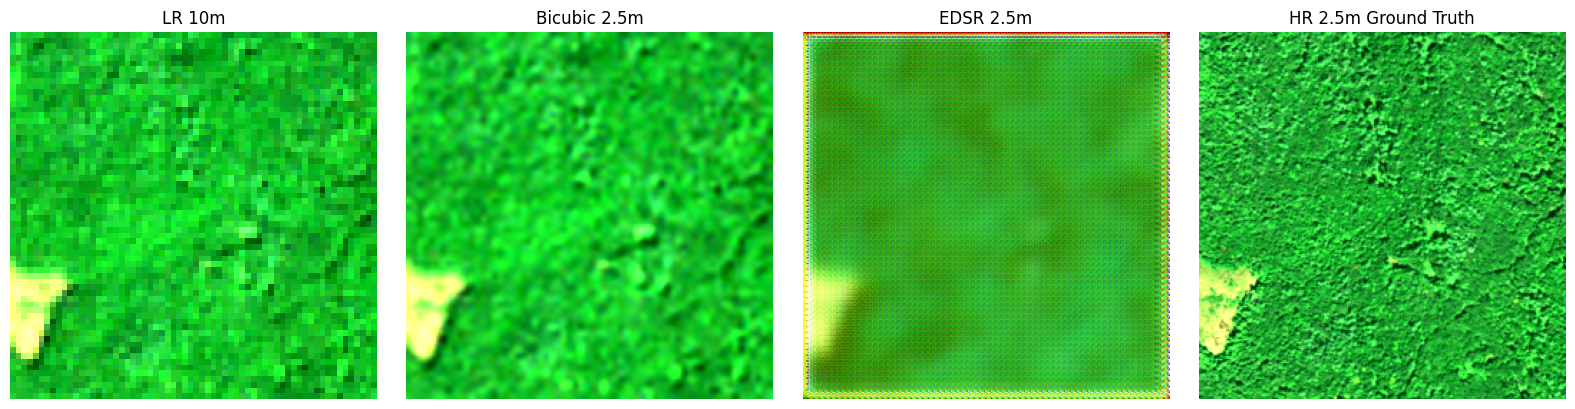

Visualization completed.

Shapes:
LR: torch.Size([2, 12, 64, 64])
Bicubic: torch.Size([2, 12, 256, 256])
EDSR: torch.Size([2, 12, 256, 256])
HR: torch.Size([2, 12, 256, 256])


In [83]:
# Cell 43 — Visual comparison: LR vs Bicubic vs EDSR vs HR

import matplotlib.pyplot as plt
import torch

model.eval()

# Get one validation batch
batch = next(iter(large_val_loader))

lr = batch["lr"].to(device)
hr = batch["hr"].to(device)
valid_mask = batch["valid_mask"].to(device)

with torch.no_grad():
    edsr_prediction = model(lr)

# Bicubic
bicubic_prediction = torch.nn.functional.interpolate(
    lr,
    size=(256, 256),
    mode="bicubic",
    align_corners=False
)

# ---------------------------------------------------------
# Convert tensors to CPU numpy
# ---------------------------------------------------------

lr_img = lr[0].detach().cpu().numpy()
hr_img = hr[0].detach().cpu().numpy()
edsr_img = edsr_prediction[0].detach().cpu().numpy()
bicubic_img = bicubic_prediction[0].detach().cpu().numpy()

# ---------------------------------------------------------
# RGB band selection
#
# SEN2NEON band order:
# B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12
#
# For RGB visualization:
# Red   = B4 -> index 3
# Green = B3 -> index 2
# Blue  = B2 -> index 1
# ---------------------------------------------------------

def make_rgb(image):

    rgb = np.stack(
        [
            image[3],
            image[2],
            image[1]
        ],
        axis=-1
    )

    # Robust display normalization
    lower = np.percentile(rgb, 2)
    upper = np.percentile(rgb, 98)

    rgb = (rgb - lower) / (upper - lower + 1e-8)

    rgb = np.clip(rgb, 0, 1)

    return rgb


lr_rgb = make_rgb(lr_img)
bicubic_rgb = make_rgb(bicubic_img)
edsr_rgb = make_rgb(edsr_img)
hr_rgb = make_rgb(hr_img)

# ---------------------------------------------------------
# Display
# ---------------------------------------------------------

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(lr_rgb)
plt.title("LR 10m")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(bicubic_rgb)
plt.title("Bicubic 2.5m")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(edsr_rgb)
plt.title("EDSR 2.5m")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(hr_rgb)
plt.title("HR 2.5m Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Visualization completed.")
print()
print("Shapes:")
print("LR:", lr.shape)
print("Bicubic:", bicubic_prediction.shape)
print("EDSR:", edsr_prediction.shape)
print("HR:", hr.shape)

In [84]:
# Cell 44 — Charbonnier Loss

import torch
import torch.nn as nn


class CharbonnierLoss(nn.Module):
    """
    Robust reconstruction loss.

    Charbonnier:
        L = sqrt((prediction - target)^2 + epsilon^2)

    This behaves similarly to L1 loss but is smooth
    around zero.
    """

    def __init__(self, epsilon=1e-3):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, prediction, target, valid_mask):

        # Expand [B, 1, H, W] mask to [B, C, H, W]
        mask = valid_mask.expand_as(prediction)

        difference = prediction - target

        loss = torch.sqrt(
            difference ** 2 + self.epsilon ** 2
        )

        masked_loss = loss * mask

        valid_pixels = mask.sum()

        if valid_pixels == 0:
            raise ValueError(
                "No valid pixels found in mask."
            )

        return masked_loss.sum() / valid_pixels


# ---------------------------------------------------------
# Test
# ---------------------------------------------------------

charbonnier = CharbonnierLoss()

model.eval()

with torch.no_grad():

    prediction = model(
        batch["lr"].to(device)
    )

    target = batch["hr"].to(device)

    mask = batch["valid_mask"].to(device)

    charbonnier_loss = charbonnier(
        prediction,
        target,
        mask
    )


print("=" * 60)
print("CHARBONNIER LOSS TEST")
print("=" * 60)

print(
    f"Charbonnier loss: "
    f"{charbonnier_loss.item():.6f}"
)

assert torch.isfinite(charbonnier_loss)
assert charbonnier_loss.item() >= 0

print()
print("Charbonnier loss test: PASSED")

CHARBONNIER LOSS TEST
Charbonnier loss: 0.022058

Charbonnier loss test: PASSED


In [85]:
# Cell 45 — Spectral Angle Mapper (SAM) Loss

import torch
import torch.nn as nn


class SAMLoss(nn.Module):
    """
    Spectral Angle Mapper loss.

    Measures the angle between the predicted and target
    spectral vectors at each valid pixel.

    Lower SAM = better spectral preservation.
    """

    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, prediction, target, valid_mask):

        # prediction / target:
        # [B, C, H, W]

        # Convert to:
        # [B, H, W, C]
        prediction = prediction.permute(
            0, 2, 3, 1
        )

        target = target.permute(
            0, 2, 3, 1
        )

        # Mask:
        # [B, H, W]
        mask = valid_mask.squeeze(1)

        # Flatten valid pixels
        prediction = prediction[mask]
        target = target[mask]

        if prediction.shape[0] == 0:
            raise ValueError(
                "No valid pixels found in mask."
            )

        # Spectral vector magnitudes
        prediction_norm = torch.linalg.norm(
            prediction,
            dim=1
        )

        target_norm = torch.linalg.norm(
            target,
            dim=1
        )

        # Avoid zero vectors
        valid_vectors = (
            (prediction_norm > self.eps) &
            (target_norm > self.eps)
        )

        prediction = prediction[valid_vectors]
        target = target[valid_vectors]

        prediction_norm = prediction_norm[
            valid_vectors
        ]

        target_norm = target_norm[
            valid_vectors
        ]

        # Cosine of spectral angle
        cosine_similarity = (
            (prediction * target).sum(dim=1)
            /
            (
                prediction_norm *
                target_norm
                + self.eps
            )
        )

        # Numerical safety
        cosine_similarity = torch.clamp(
            cosine_similarity,
            -1.0 + self.eps,
            1.0 - self.eps
        )

        # Spectral angle in radians
        angle = torch.acos(
            cosine_similarity
        )

        return angle.mean()


# ---------------------------------------------------------
# Test SAM loss
# ---------------------------------------------------------

sam_loss = SAMLoss()

model.eval()

with torch.no_grad():

    prediction = model(
        batch["lr"].to(device)
    )

    target = batch["hr"].to(device)

    mask = batch["valid_mask"].to(device)

    sam_value = sam_loss(
        prediction,
        target,
        mask
    )


print("=" * 60)
print("SAM LOSS TEST")
print("=" * 60)

print(
    f"SAM loss: "
    f"{sam_value.item():.6f} radians"
)

print(
    f"SAM loss: "
    f"{torch.rad2deg(sam_value).item():.4f} degrees"
)

assert torch.isfinite(sam_value)
assert sam_value.item() >= 0

print()
print("SAM loss test: PASSED")

SAM LOSS TEST
SAM loss: 0.047817 radians
SAM loss: 2.7397 degrees

SAM loss test: PASSED


In [86]:
# Cell 46 — Spatial Gradient Loss

import torch
import torch.nn as nn
import torch.nn.functional as F


class SpatialGradientLoss(nn.Module):
    """
    Compares horizontal and vertical image gradients
    between prediction and target.

    This encourages preservation of:
    - edges
    - boundaries
    - spatial structures
    """

    def forward(self, prediction, target, valid_mask):

        # Horizontal gradients
        pred_dx = prediction[:, :, :, 1:] - prediction[:, :, :, :-1]
        target_dx = target[:, :, :, 1:] - target[:, :, :, :-1]

        # Vertical gradients
        pred_dy = prediction[:, :, 1:, :] - prediction[:, :, :-1, :]
        target_dy = target[:, :, 1:, :]

        target_dy = target[:, :, 1:, :] - target[:, :, :-1, :]

        # Corresponding masks
        mask_x = valid_mask[:, :, :, 1:] & valid_mask[:, :, :, :-1]
        mask_y = valid_mask[:, :, 1:, :] & valid_mask[:, :, :-1, :]

        mask_x = mask_x.expand_as(pred_dx)
        mask_y = mask_y.expand_as(pred_dy)

        # Absolute gradient differences
        loss_x = torch.abs(pred_dx - target_dx) * mask_x
        loss_y = torch.abs(pred_dy - target_dy) * mask_y

        valid_x = mask_x.sum()
        valid_y = mask_y.sum()

        if valid_x == 0 or valid_y == 0:
            raise ValueError(
                "No valid gradient pixels found."
            )

        loss_x = loss_x.sum() / valid_x
        loss_y = loss_y.sum() / valid_y

        return 0.5 * (loss_x + loss_y)


# ---------------------------------------------------------
# Test
# ---------------------------------------------------------

gradient_loss = SpatialGradientLoss()

model.eval()

with torch.no_grad():

    prediction = model(
        batch["lr"].to(device)
    )

    target = batch["hr"].to(device)

    mask = batch["valid_mask"].to(device)

    gradient_value = gradient_loss(
        prediction,
        target,
        mask
    )


print("=" * 60)
print("SPATIAL GRADIENT LOSS TEST")
print("=" * 60)

print(
    f"Spatial gradient loss: "
    f"{gradient_value.item():.6f}"
)

assert torch.isfinite(gradient_value)
assert gradient_value.item() >= 0

print()
print("Spatial gradient loss test: PASSED")

SPATIAL GRADIENT LOSS TEST
Spatial gradient loss: 0.017413

Spatial gradient loss test: PASSED


In [87]:
# Cell 47 — Low-Frequency Consistency Loss

import torch
import torch.nn as nn
import torch.nn.functional as F


class LowFrequencyConsistencyLoss(nn.Module):
    """
    Forces the SR prediction to remain consistent with
    the original low-resolution Sentinel-2 observation.

    SR:  2.5 m
    LR: 10 m

    Since the scale factor is 4, we reduce the SR image
    back to LR resolution and compare it with the input.
    """

    def __init__(self, scale=4):
        super().__init__()
        self.scale = scale

    def forward(self, prediction, lr_input):

        # Reduce predicted HR image to LR resolution.
        #
        # Average pooling approximates the low-frequency
        # observation/degradation process.
        degraded_prediction = F.avg_pool2d(
            prediction,
            kernel_size=self.scale,
            stride=self.scale
        )

        # Compare reconstructed LR with original LR.
        loss = torch.abs(
            degraded_prediction - lr_input
        )

        return loss.mean()


# ---------------------------------------------------------
# Test
# ---------------------------------------------------------

low_frequency_loss = LowFrequencyConsistencyLoss(
    scale=4
)

model.eval()

with torch.no_grad():

    lr_input = batch["lr"].to(device)

    prediction = model(lr_input)

    low_frequency_value = low_frequency_loss(
        prediction,
        lr_input
    )


print("=" * 60)
print("LOW-FREQUENCY CONSISTENCY LOSS TEST")
print("=" * 60)

print(
    f"Low-frequency consistency loss: "
    f"{low_frequency_value.item():.6f}"
)

assert torch.isfinite(low_frequency_value)
assert low_frequency_value.item() >= 0

print()
print("Low-frequency consistency loss test: PASSED")

LOW-FREQUENCY CONSISTENCY LOSS TEST
Low-frequency consistency loss: 0.009557

Low-frequency consistency loss test: PASSED


In [88]:
# Cell 48 — GeoSR Composite Loss

import torch
import torch.nn as nn


class GeoSRCompositeLoss(nn.Module):
    """
    Composite loss for GeoSR-NTRO.

    Components:
        1. Charbonnier reconstruction
        2. Spectral Angle Mapper (SAM)
        3. Spatial gradient
        4. Low-frequency consistency
    """

    def __init__(
        self,
        charbonnier_weight=1.0,
        sam_weight=0.1,
        gradient_weight=0.1,
        low_frequency_weight=0.1
    ):
        super().__init__()

        self.charbonnier_weight = charbonnier_weight
        self.sam_weight = sam_weight
        self.gradient_weight = gradient_weight
        self.low_frequency_weight = low_frequency_weight

        self.charbonnier = CharbonnierLoss()
        self.sam = SAMLoss()
        self.gradient = SpatialGradientLoss()
        self.low_frequency = LowFrequencyConsistencyLoss(
            scale=4
        )

    def forward(
        self,
        prediction,
        target,
        lr_input,
        valid_mask
    ):

        # 1. Reconstruction
        charbonnier_loss = self.charbonnier(
            prediction,
            target,
            valid_mask
        )

        # 2. Spectral fidelity
        sam_loss = self.sam(
            prediction,
            target,
            valid_mask
        )

        # 3. Spatial structure
        gradient_loss = self.gradient(
            prediction,
            target,
            valid_mask
        )

        # 4. Low-frequency consistency
        low_frequency_loss = self.low_frequency(
            prediction,
            lr_input
        )

        # Weighted sum
        total_loss = (
            self.charbonnier_weight * charbonnier_loss
            +
            self.sam_weight * sam_loss
            +
            self.gradient_weight * gradient_loss
            +
            self.low_frequency_weight * low_frequency_loss
        )

        return {
            "total": total_loss,
            "charbonnier": charbonnier_loss,
            "sam": sam_loss,
            "gradient": gradient_loss,
            "low_frequency": low_frequency_loss
        }


# ---------------------------------------------------------
# Test
# ---------------------------------------------------------

geosr_loss = GeoSRCompositeLoss()

model.eval()

with torch.no_grad():

    lr_input = batch["lr"].to(device)
    target = batch["hr"].to(device)
    valid_mask = batch["valid_mask"].to(device)

    prediction = model(lr_input)

    loss_dict = geosr_loss(
        prediction=prediction,
        target=target,
        lr_input=lr_input,
        valid_mask=valid_mask
    )


print("=" * 60)
print("GEOSR COMPOSITE LOSS TEST")
print("=" * 60)

print(
    f"Total loss:          "
    f"{loss_dict['total'].item():.6f}"
)

print(
    f"Charbonnier:         "
    f"{loss_dict['charbonnier'].item():.6f}"
)

print(
    f"SAM:                 "
    f"{loss_dict['sam'].item():.6f}"
)

print(
    f"Gradient:            "
    f"{loss_dict['gradient'].item():.6f}"
)

print(
    f"Low-frequency:       "
    f"{loss_dict['low_frequency'].item():.6f}"
)

# ---------------------------------------------------------
# Safety checks
# ---------------------------------------------------------

for name, value in loss_dict.items():

    assert torch.isfinite(value), (
        f"{name} loss is not finite."
    )

    assert value.item() >= 0, (
        f"{name} loss is negative."
    )

print()
print("GeoSR composite loss test: PASSED")

GEOSR COMPOSITE LOSS TEST
Total loss:          0.029536
Charbonnier:         0.022058
SAM:                 0.047817
Gradient:            0.017413
Low-frequency:       0.009557

GeoSR composite loss test: PASSED


In [89]:
# Cell 49 — Hard Low-Frequency Projection

import torch
import torch.nn.functional as F


def degrade_to_lr(hr_image, scale=4):
    """
    Approximate HR -> LR degradation using average pooling.

    HR: [B, C, H, W]
    LR: [B, C, H/4, W/4]
    """

    return F.avg_pool2d(
        hr_image,
        kernel_size=scale,
        stride=scale
    )


def hard_low_frequency_projection(
    sr_prediction,
    lr_input,
    scale=4
):
    """
    Enforce low-frequency consistency.

    Y_consistent = Y_SR + U(X_LR - D(Y_SR))

    D = HR -> LR degradation
    U = LR -> HR upsampling
    """

    # 1. Degrade SR prediction to LR
    degraded_sr = degrade_to_lr(
        sr_prediction,
        scale=scale
    )

    # 2. Calculate LR residual
    lr_residual = lr_input - degraded_sr

    # 3. Upsample residual back to HR
    hr_residual = F.interpolate(
        lr_residual,
        scale_factor=scale,
        mode="bilinear",
        align_corners=False
    )

    # 4. Correct SR prediction
    consistent_sr = (
        sr_prediction + hr_residual
    )

    return consistent_sr


# =========================================================
# TEST HARD PROJECTION
# =========================================================

model.eval()

with torch.no_grad():

    lr_input = batch["lr"].to(device)

    # Network prediction
    sr_prediction = model(lr_input)

    # Raw SR -> LR
    raw_reconstructed_lr = degrade_to_lr(
        sr_prediction,
        scale=4
    )

    # Apply hard projection
    consistent_prediction = hard_low_frequency_projection(
        sr_prediction,
        lr_input,
        scale=4
    )

    # Projected SR -> LR
    reconstructed_lr = degrade_to_lr(
        consistent_prediction,
        scale=4
    )

    # Calculate errors
    raw_error = torch.mean(
        torch.abs(
            raw_reconstructed_lr - lr_input
        )
    )

    projected_error = torch.mean(
        torch.abs(
            reconstructed_lr - lr_input
        )
    )


print("=" * 60)
print("HARD LOW-FREQUENCY PROJECTION TEST")
print("=" * 60)

print(
    f"Raw SR -> LR consistency error: "
    f"{raw_error.item():.8f}"
)

print(
    f"Projected SR -> LR consistency error: "
    f"{projected_error.item():.8f}"
)

print()
print(
    "SR shape:",
    tuple(sr_prediction.shape)
)

print(
    "Projected SR shape:",
    tuple(consistent_prediction.shape)
)


# =========================================================
# SAFETY CHECKS
# =========================================================

assert consistent_prediction.shape == sr_prediction.shape

assert reconstructed_lr.shape == lr_input.shape

assert torch.isfinite(
    consistent_prediction
).all()

assert torch.isfinite(
    projected_error
)

# Projection should substantially reduce
# the LR reconstruction error.
assert projected_error.item() < raw_error.item()

print()
print("Hard low-frequency projection test: PASSED")

HARD LOW-FREQUENCY PROJECTION TEST
Raw SR -> LR consistency error: 0.00955696
Projected SR -> LR consistency error: 0.00181487

SR shape: (2, 12, 256, 256)
Projected SR shape: (2, 12, 256, 256)

Hard low-frequency projection test: PASSED


In [90]:
# Cell 50A — Proper Hard Projection Gradient Test

model.train()

lr_input = batch["lr"].to(device)
target = batch["hr"].to(device)
valid_mask = batch["valid_mask"].to(device)

# ---------------------------------------------------------
# Forward pass
# ---------------------------------------------------------

sr_prediction = model(lr_input)

# Apply hard projection
consistent_prediction = hard_low_frequency_projection(
    sr_prediction,
    lr_input,
    scale=4
)

# ---------------------------------------------------------
# Use reconstruction loss AFTER projection
# ---------------------------------------------------------

projection_loss = charbonnier(
    consistent_prediction,
    target,
    valid_mask
)

# ---------------------------------------------------------
# Backpropagation
# ---------------------------------------------------------

model.zero_grad()

projection_loss.backward()

# ---------------------------------------------------------
# Inspect gradients
# ---------------------------------------------------------

gradient_parameters = 0
total_gradient_norm = 0.0
maximum_gradient = 0.0

for parameter in model.parameters():

    if parameter.grad is not None:

        gradient_parameters += 1

        gradient_norm = parameter.grad.detach().norm().item()

        total_gradient_norm += gradient_norm

        maximum_gradient = max(
            maximum_gradient,
            parameter.grad.detach().abs().max().item()
        )


print("=" * 60)
print("HARD PROJECTION GRADIENT TEST")
print("=" * 60)

print(
    f"Projection reconstruction loss: "
    f"{projection_loss.item():.6f}"
)

print(
    f"Parameters with gradients: "
    f"{gradient_parameters}"
)

print(
    f"Total gradient norm: "
    f"{total_gradient_norm:.10f}"
)

print(
    f"Maximum gradient value: "
    f"{maximum_gradient:.10f}"
)


# ---------------------------------------------------------
# Safety checks
# ---------------------------------------------------------

assert torch.isfinite(projection_loss)

assert gradient_parameters > 0

assert total_gradient_norm > 0

assert maximum_gradient > 0


print()
print("Hard projection gradient test: PASSED")

HARD PROJECTION GRADIENT TEST
Projection reconstruction loss: 0.021455
Parameters with gradients: 42
Total gradient norm: 0.1247579703
Maximum gradient value: 0.0033170225

Hard projection gradient test: PASSED


In [91]:
# Cell 51A — Create GeoSR Composite Loss

composite_loss = GeoSRCompositeLoss(
    charbonnier_weight=1.0,
    sam_weight=0.1,
    gradient_weight=0.1,
    low_frequency_weight=0.1
)

print("=" * 60)
print("GEOSR COMPOSITE LOSS")
print("=" * 60)

print("Charbonnier weight:    1.0")
print("SAM weight:            0.1")
print("Gradient weight:       0.1")
print("Low-frequency weight:  0.1")

print()
print("Composite loss object: READY")

GEOSR COMPOSITE LOSS
Charbonnier weight:    1.0
SAM weight:            0.1
Gradient weight:       0.1
Low-frequency weight:  0.1

Composite loss object: READY


In [92]:
# Cell 51 — GeoSR Integrated Training-Step Test

model.train()

# ---------------------------------------------------------
# Get one training batch
# ---------------------------------------------------------

batch = next(iter(train_loader))

lr_input = batch["lr"].to(device)
target = batch["hr"].to(device)
valid_mask = batch["valid_mask"].to(device)

# ---------------------------------------------------------
# Forward pass
# ---------------------------------------------------------

sr_prediction = model(lr_input)

# ---------------------------------------------------------
# Hard low-frequency projection
# ---------------------------------------------------------

consistent_prediction = hard_low_frequency_projection(
    sr_prediction,
    lr_input,
    scale=4
)

# ---------------------------------------------------------
# Composite GeoSR loss
# ---------------------------------------------------------

loss_components = composite_loss(
    consistent_prediction,
    target,
    lr_input,
    valid_mask
)

total_loss = loss_components["total"]

# ---------------------------------------------------------
# Backpropagation
# ---------------------------------------------------------

model.zero_grad()

total_loss.backward()

# ---------------------------------------------------------
# Gradient check
# ---------------------------------------------------------

gradient_parameters = 0
total_gradient_norm = 0.0

for parameter in model.parameters():

    if parameter.grad is not None:

        gradient_parameters += 1

        total_gradient_norm += (
            parameter.grad.detach().norm().item()
        )

# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------

print("=" * 60)
print("GEOSR INTEGRATED TRAINING-STEP TEST")
print("=" * 60)

print(f"LR shape:          {tuple(lr_input.shape)}")
print(f"SR shape:          {tuple(sr_prediction.shape)}")
print(f"Projected SR:      {tuple(consistent_prediction.shape)}")

print()
print(f"Total loss:        {total_loss.item():.6f}")
print(f"Charbonnier:       {loss_components['charbonnier'].item():.6f}")
print(f"SAM:               {loss_components['sam'].item():.6f}")
print(f"Gradient loss:     {loss_components['gradient'].item():.6f}")
print(f"Low-frequency:     {loss_components['low_frequency'].item():.6f}")

print()
print(f"Parameters with gradients: {gradient_parameters}")
print(f"Total gradient norm:       {total_gradient_norm:.8f}")

# ---------------------------------------------------------
# Assertions
# ---------------------------------------------------------

assert torch.isfinite(total_loss)

assert total_loss.item() > 0

assert gradient_parameters > 0

assert total_gradient_norm > 0

assert sr_prediction.shape == target.shape

assert consistent_prediction.shape == target.shape

print()
print("GeoSR integrated training-step test: PASSED")

s2_l2a_10m/2024_UKFS_8__4_2.tif: reconstructing file:   0%|          |  0.00B /  514kB            

s2_l2a_10m/2024_UKFS_8__4_2.tif: downloading bytes:           |  0.00B            

neon_2.5m_linearized/2024_UKFS_8__4_2.ti(…): reconstructing file:   0%|          |  0.00B / 14.6MB            

neon_2.5m_linearized/2024_UKFS_8__4_2.ti(…): downloading bytes:           |  0.00B            

GEOSR INTEGRATED TRAINING-STEP TEST
LR shape:          (2, 12, 64, 64)
SR shape:          (2, 12, 256, 256)
Projected SR:      (2, 12, 256, 256)

Total loss:        0.027761
Charbonnier:       0.019596
SAM:               0.073511
Gradient loss:     0.006201
Low-frequency:     0.001936

Parameters with gradients: 42
Total gradient norm:       0.14590007

GeoSR integrated training-step test: PASSED


In [93]:
# Cell 52 — Uncertainty Head

import torch
import torch.nn as nn


class UncertaintyHead(nn.Module):

    def __init__(self, in_channels=64, out_channels=12):
        super().__init__()

        self.head = nn.Sequential(
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, features):
        # Predict log variance rather than variance directly.
        log_variance = self.head(features)

        # Prevent numerically extreme values.
        log_variance = torch.clamp(
            log_variance,
            min=-10.0,
            max=10.0
        )

        return log_variance


# ---------------------------------------------------------
# Create uncertainty head
# ---------------------------------------------------------

uncertainty_head = UncertaintyHead(
    in_channels=64,
    out_channels=12
).to(device)


# ---------------------------------------------------------
# Test with feature tensor
# ---------------------------------------------------------

test_features = torch.randn(
    2,
    64,
    256,
    256,
    device=device
)

log_variance = uncertainty_head(test_features)


# ---------------------------------------------------------
# Verify
# ---------------------------------------------------------

print("=" * 60)
print("UNCERTAINTY HEAD TEST")
print("=" * 60)

print(
    f"Input feature shape:   {tuple(test_features.shape)}"
)

print(
    f"Log-variance shape:     {tuple(log_variance.shape)}"
)

print(
    f"Log-variance minimum:   {log_variance.min().item():.6f}"
)

print(
    f"Log-variance maximum:   {log_variance.max().item():.6f}"
)

print(
    f"Log-variance mean:      {log_variance.mean().item():.6f}"
)


# ---------------------------------------------------------
# Assertions
# ---------------------------------------------------------

assert log_variance.shape == (
    2, 12, 256, 256
)

assert torch.isfinite(log_variance).all()

assert log_variance.min().item() >= -10.0

assert log_variance.max().item() <= 10.0

print()
print("Uncertainty head test: PASSED")

UNCERTAINTY HEAD TEST
Input feature shape:   (2, 64, 256, 256)
Log-variance shape:     (2, 12, 256, 256)
Log-variance minimum:   -1.218447
Log-variance maximum:   1.136906
Log-variance mean:      -0.020133

Uncertainty head test: PASSED


In [94]:
# Cell 53 — Uncertainty Gaussian NLL Loss

import torch
import torch.nn as nn


class UncertaintyNLLLoss(nn.Module):

    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(
        self,
        prediction,
        target,
        log_variance,
        valid_mask
    ):

        # Keep log variance numerically stable.
        log_variance = torch.clamp(
            log_variance,
            min=-10.0,
            max=10.0
        )

        # Convert log variance to variance.
        variance = torch.exp(log_variance)

        # Squared reconstruction error.
        squared_error = (prediction - target) ** 2

        # Gaussian negative log-likelihood.
        nll = (
            0.5
            * (
                squared_error / (variance + self.eps)
                + log_variance
            )
        )

        # Apply valid HR-pixel mask.
        mask = valid_mask.expand_as(nll)

        masked_nll = nll * mask

        valid_pixels = mask.sum()

        if valid_pixels == 0:
            raise ValueError(
                "No valid pixels available for uncertainty NLL."
            )

        return masked_nll.sum() / valid_pixels


uncertainty_nll = UncertaintyNLLLoss()


# ---------------------------------------------------------
# Test the loss
# ---------------------------------------------------------

prediction = torch.randn(
    2, 12, 256, 256,
    device=device
)

target = torch.randn(
    2, 12, 256, 256,
    device=device
)

log_variance = torch.zeros(
    2, 12, 256, 256,
    device=device
)

valid_mask = torch.ones(
    2, 1, 256, 256,
    dtype=torch.bool,
    device=device
)

loss = uncertainty_nll(
    prediction,
    target,
    log_variance,
    valid_mask
)


# ---------------------------------------------------------
# Verify
# ---------------------------------------------------------

print("=" * 60)
print("UNCERTAINTY NLL LOSS TEST")
print("=" * 60)

print(f"Prediction shape:    {tuple(prediction.shape)}")
print(f"Log-variance shape:  {tuple(log_variance.shape)}")
print(f"NLL loss:            {loss.item():.6f}")

assert torch.isfinite(loss)

assert loss.item() > 0

print()
print("Uncertainty NLL loss test: PASSED")

UNCERTAINTY NLL LOSS TEST
Prediction shape:    (2, 12, 256, 256)
Log-variance shape:  (2, 12, 256, 256)
NLL loss:            0.999236

Uncertainty NLL loss test: PASSED


In [95]:
# Cell 54 — SR Model with Uncertainty Output

class EDSRStyleSRWithUncertainty(nn.Module):

    def __init__(
        self,
        in_channels=12,
        out_channels=12,
        features=64,
        num_blocks=8,
        scale=4
    ):
        super().__init__()

        self.head = nn.Conv2d(
            in_channels,
            features,
            kernel_size=3,
            padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(
                    features,
                    res_scale=0.1
                )
                for _ in range(num_blocks)
            ]
        )

        self.body_tail = nn.Conv2d(
            features,
            features,
            kernel_size=3,
            padding=1
        )

        self.upsample = UpsampleBlock(
            features,
            scale=scale
        )

        # SR reconstruction head
        self.sr_tail = nn.Conv2d(
            features,
            out_channels,
            kernel_size=3,
            padding=1
        )

        # Uncertainty prediction head
        self.uncertainty_head = UncertaintyHead(
            in_channels=features,
            out_channels=out_channels
        )

    def forward(self, x):

        # Low-resolution feature extraction
        shallow = self.head(x)

        # Residual feature processing
        body = self.body(shallow)
        body = self.body_tail(body)

        features = shallow + body

        # Upscale to 2.5 m resolution
        hr_features = self.upsample(features)

        # Two outputs from the same learned representation
        sr_prediction = self.sr_tail(hr_features)

        log_variance = self.uncertainty_head(
            hr_features
        )

        return sr_prediction, log_variance


# ---------------------------------------------------------
# Create model
# ---------------------------------------------------------

uncertainty_model = EDSRStyleSRWithUncertainty(
    in_channels=12,
    out_channels=12,
    features=64,
    num_blocks=8,
    scale=4
).to(device)


# ---------------------------------------------------------
# Test
# ---------------------------------------------------------

uncertainty_model.eval()

with torch.no_grad():

    test_lr = torch.randn(
        2,
        12,
        64,
        64,
        device=device
    )

    test_sr, test_log_variance = uncertainty_model(
        test_lr
    )


# ---------------------------------------------------------
# Verify
# ---------------------------------------------------------

print("=" * 60)
print("SR + UNCERTAINTY MODEL TEST")
print("=" * 60)

print(
    f"Input LR shape:       {tuple(test_lr.shape)}"
)

print(
    f"SR output shape:      {tuple(test_sr.shape)}"
)

print(
    f"Log-variance shape:   {tuple(test_log_variance.shape)}"
)

print(
    f"SR range:             "
    f"{test_sr.min().item():.6f} to "
    f"{test_sr.max().item():.6f}"
)

print(
    f"Log-variance range:   "
    f"{test_log_variance.min().item():.6f} to "
    f"{test_log_variance.max().item():.6f}"
)


# ---------------------------------------------------------
# Assertions
# ---------------------------------------------------------

assert test_sr.shape == (
    2, 12, 256, 256
)

assert test_log_variance.shape == (
    2, 12, 256, 256
)

assert torch.isfinite(test_sr).all()

assert torch.isfinite(test_log_variance).all()

assert test_log_variance.min().item() >= -10.0

assert test_log_variance.max().item() <= 10.0


print()
print("SR + uncertainty model test: PASSED")

SR + UNCERTAINTY MODEL TEST
Input LR shape:       (2, 12, 64, 64)
SR output shape:      (2, 12, 256, 256)
Log-variance shape:   (2, 12, 256, 256)
SR range:             -0.290249 to 0.286093
Log-variance range:   -0.180458 to 0.157149

SR + uncertainty model test: PASSED


In [96]:
# Cell 55 — Full GeoSR Uncertainty Integration Test

uncertainty_model.train()

# ---------------------------------------------------------
# Get one batch
# ---------------------------------------------------------

batch = next(iter(train_loader))

lr_input = batch["lr"].to(device)
target = batch["hr"].to(device)
valid_mask = batch["valid_mask"].to(device)

# ---------------------------------------------------------
# Forward pass
# ---------------------------------------------------------

sr_prediction, log_variance = uncertainty_model(
    lr_input
)

# ---------------------------------------------------------
# Hard low-frequency projection
# ---------------------------------------------------------

consistent_prediction = hard_low_frequency_projection(
    sr_prediction,
    lr_input,
    scale=4
)

# ---------------------------------------------------------
# Existing composite reconstruction loss
# ---------------------------------------------------------

reconstruction_losses = composite_loss(
    consistent_prediction,
    target,
    lr_input,
    valid_mask
)

reconstruction_loss = reconstruction_losses["total"]

# ---------------------------------------------------------
# Uncertainty NLL
# ---------------------------------------------------------

nll_loss = uncertainty_nll(
    consistent_prediction,
    target,
    log_variance,
    valid_mask
)

# ---------------------------------------------------------
# Combined GeoSR loss
# ---------------------------------------------------------

uncertainty_weight = 0.1

total_loss = (
    reconstruction_loss
    + uncertainty_weight * nll_loss
)

# ---------------------------------------------------------
# Backpropagation
# ---------------------------------------------------------

uncertainty_model.zero_grad()

total_loss.backward()

# ---------------------------------------------------------
# Gradient inspection
# ---------------------------------------------------------

gradient_parameters = 0
total_gradient_norm = 0.0

for parameter in uncertainty_model.parameters():

    if parameter.grad is not None:

        gradient_parameters += 1

        total_gradient_norm += (
            parameter.grad.detach().norm().item()
        )

# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------

print("=" * 60)
print("FULL GEOSR UNCERTAINTY INTEGRATION TEST")
print("=" * 60)

print(f"LR shape:                 {tuple(lr_input.shape)}")
print(f"SR shape:                 {tuple(sr_prediction.shape)}")
print(f"Log-variance shape:       {tuple(log_variance.shape)}")
print(f"Projected SR shape:       {tuple(consistent_prediction.shape)}")

print()
print(f"Reconstruction loss:      {reconstruction_loss.item():.6f}")
print(f"Uncertainty NLL:           {nll_loss.item():.6f}")
print(f"Uncertainty weight:        {uncertainty_weight}")
print(f"Total combined loss:       {total_loss.item():.6f}")

print()
print(f"Parameters with gradients: {gradient_parameters}")
print(f"Total gradient norm:       {total_gradient_norm:.8f}")

# ---------------------------------------------------------
# Verify
# ---------------------------------------------------------

assert torch.isfinite(reconstruction_loss)

assert torch.isfinite(nll_loss)

assert torch.isfinite(total_loss)

assert gradient_parameters > 0

assert total_gradient_norm > 0

assert sr_prediction.shape == target.shape

assert log_variance.shape == target.shape

assert consistent_prediction.shape == target.shape

print()
print("Full GeoSR uncertainty integration test: PASSED")

s2_l2a_10m/2019_NIWO_3__5_2.tif: reconstructing file:   0%|          |  0.00B /  568kB            

s2_l2a_10m/2019_NIWO_3__5_2.tif: downloading bytes:           |  0.00B            

neon_2.5m_linearized/2019_NIWO_3__5_2.ti(…): reconstructing file:   0%|          |  0.00B / 14.9MB            

neon_2.5m_linearized/2019_NIWO_3__5_2.ti(…): downloading bytes:           |  0.00B            

FULL GEOSR UNCERTAINTY INTEGRATION TEST
LR shape:                 (2, 12, 64, 64)
SR shape:                 (2, 12, 256, 256)
Log-variance shape:       (2, 12, 256, 256)
Projected SR shape:       (2, 12, 256, 256)

Reconstruction loss:      0.040563
Uncertainty NLL:           0.000883
Uncertainty weight:        0.1
Total combined loss:       0.040651

Parameters with gradients: 46
Total gradient norm:       0.29010393

Full GeoSR uncertainty integration test: PASSED


In [97]:
# Cell 56 — Complete GeoSR Loss Breakdown Test

uncertainty_model.eval()

with torch.no_grad():

    batch = next(iter(train_loader))

    lr_input = batch["lr"].to(device)
    target = batch["hr"].to(device)
    valid_mask = batch["valid_mask"].to(device)

    # -----------------------------------------------------
    # Model prediction
    # -----------------------------------------------------

    sr_prediction, log_variance = uncertainty_model(
        lr_input
    )

    # -----------------------------------------------------
    # Hard low-frequency projection
    # -----------------------------------------------------

    projected_sr = hard_low_frequency_projection(
        sr_prediction,
        lr_input,
        scale=4
    )

    # -----------------------------------------------------
    # Reconstruction losses
    # -----------------------------------------------------

    losses = composite_loss(
        projected_sr,
        target,
        lr_input,
        valid_mask
    )

    # -----------------------------------------------------
    # Uncertainty loss
    # -----------------------------------------------------

    nll = uncertainty_nll(
        projected_sr,
        target,
        log_variance,
        valid_mask
    )

    # -----------------------------------------------------
    # Explicit weights
    # -----------------------------------------------------

    W_CHARBONNIER = 1.0
    W_SAM = 0.1
    W_GRADIENT = 0.1
    W_LOW_FREQUENCY = 0.1
    W_UNCERTAINTY = 0.1

    weighted_charbonnier = (
        W_CHARBONNIER * losses["charbonnier"]
    )

    weighted_sam = (
        W_SAM * losses["sam"]
    )

    weighted_gradient = (
        W_GRADIENT * losses["gradient"]
    )

    weighted_low_frequency = (
        W_LOW_FREQUENCY * losses["low_frequency"]
    )

    weighted_uncertainty = (
        W_UNCERTAINTY * nll
    )

    total_loss = (
        weighted_charbonnier
        + weighted_sam
        + weighted_gradient
        + weighted_low_frequency
        + weighted_uncertainty
    )


# ---------------------------------------------------------
# Print
# ---------------------------------------------------------

print("=" * 60)
print("COMPLETE GEOSR LOSS BREAKDOWN TEST")
print("=" * 60)

print()
print("RAW LOSSES")
print("-" * 60)

print(
    f"Charbonnier:             "
    f"{losses['charbonnier'].item():.6f}"
)

print(
    f"SAM:                     "
    f"{losses['sam'].item():.6f}"
)

print(
    f"Spatial Gradient:        "
    f"{losses['gradient'].item():.6f}"
)

print(
    f"Low Frequency:           "
    f"{losses['low_frequency'].item():.6f}"
)

print(
    f"Uncertainty NLL:          "
    f"{nll.item():.6f}"
)

print()
print("WEIGHTED CONTRIBUTIONS")
print("-" * 60)

print(
    f"Charbonnier × {W_CHARBONNIER}:        "
    f"{weighted_charbonnier.item():.6f}"
)

print(
    f"SAM × {W_SAM}:                    "
    f"{weighted_sam.item():.6f}"
)

print(
    f"Gradient × {W_GRADIENT}:              "
    f"{weighted_gradient.item():.6f}"
)

print(
    f"Low-frequency × {W_LOW_FREQUENCY}:       "
    f"{weighted_low_frequency.item():.6f}"
)

print(
    f"Uncertainty × {W_UNCERTAINTY}:         "
    f"{weighted_uncertainty.item():.6f}"
)

print()
print("=" * 60)

print(
    f"TOTAL GEOSR LOSS:       "
    f"{total_loss.item():.6f}"
)

print("=" * 60)


# ---------------------------------------------------------
# Verify
# ---------------------------------------------------------

all_losses = [
    losses["charbonnier"],
    losses["sam"],
    losses["gradient"],
    losses["low_frequency"],
    nll,
    total_loss
]

for loss_value in all_losses:
    assert torch.isfinite(loss_value), \
        "Non-finite loss detected."

assert total_loss.item() == (
    weighted_charbonnier
    + weighted_sam
    + weighted_gradient
    + weighted_low_frequency
    + weighted_uncertainty
).item()

assert projected_sr.shape == target.shape

assert log_variance.shape == target.shape

print()
print("Complete GeoSR loss breakdown test: PASSED")

s2_l2a_10m/2022_ARIK_4__6_4.tif: reconstructing file:   0%|          |  0.00B /  478kB            

s2_l2a_10m/2022_ARIK_4__6_4.tif: downloading bytes:           |  0.00B            

neon_2.5m_linearized/2022_ARIK_4__6_4.ti(…): reconstructing file:   0%|          |  0.00B / 15.4MB            

neon_2.5m_linearized/2022_ARIK_4__6_4.ti(…): downloading bytes:           |  0.00B            

s2_l2a_10m/2023_LENO_7__3_3.tif: reconstructing file:   0%|          |  0.00B /  520kB            

s2_l2a_10m/2023_LENO_7__3_3.tif: downloading bytes:           |  0.00B            

neon_2.5m_linearized/2023_LENO_7__3_3.ti(…): reconstructing file:   0%|          |  0.00B / 14.8MB            

neon_2.5m_linearized/2023_LENO_7__3_3.ti(…): downloading bytes:           |  0.00B            

COMPLETE GEOSR LOSS BREAKDOWN TEST

RAW LOSSES
------------------------------------------------------------
Charbonnier:             0.029143
SAM:                     0.101964
Spatial Gradient:        0.018583
Low Frequency:           0.002080
Uncertainty NLL:          0.000918

WEIGHTED CONTRIBUTIONS
------------------------------------------------------------
Charbonnier × 1.0:        0.029143
SAM × 0.1:                    0.010196
Gradient × 0.1:              0.001858
Low-frequency × 0.1:       0.000208
Uncertainty × 0.1:         0.000092

TOTAL GEOSR LOSS:       0.041497

Complete GeoSR loss breakdown test: PASSED


In [98]:
# Cell 57 — Reflectance Output Constraint Test

class ReflectanceOutput(nn.Module):
    """
    Converts unconstrained neural-network output
    into physically bounded reflectance in [0, 1].
    """

    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.sigmoid(x)


reflectance_output = ReflectanceOutput().to(device)


# ---------------------------------------------------------
# Test with extreme neural-network outputs
# ---------------------------------------------------------

test_raw_output = torch.tensor(
    [
        [-20.0, -5.0, 0.0, 5.0, 20.0]
    ],
    device=device
).reshape(1, 1, 1, 5)


test_reflectance = reflectance_output(
    test_raw_output
)


# ---------------------------------------------------------
# Print
# ---------------------------------------------------------

print("=" * 60)
print("REFLECTANCE OUTPUT CONSTRAINT TEST")
print("=" * 60)

print()
print(
    "Raw network output:"
)

print(
    test_raw_output.flatten().detach().cpu().numpy()
)

print()
print(
    "Bounded reflectance:"
)

print(
    test_reflectance.flatten().detach().cpu().numpy()
)

print()
print(
    f"Minimum reflectance: "
    f"{test_reflectance.min().item():.8f}"
)

print(
    f"Maximum reflectance: "
    f"{test_reflectance.max().item():.8f}"
)


# ---------------------------------------------------------
# Gradient test
# ---------------------------------------------------------

test_raw_output = torch.randn(
    1,
    1,
    4,
    4,
    device=device,
    requires_grad=True
)

bounded_output = reflectance_output(
    test_raw_output
)

gradient_test_loss = bounded_output.mean()

gradient_test_loss.backward()


gradient_exists = (
    test_raw_output.grad is not None
)

gradient_is_finite = torch.isfinite(
    test_raw_output.grad
).all()


# ---------------------------------------------------------
# Assertions
# ---------------------------------------------------------

assert test_reflectance.min().item() >= 0.0

assert test_reflectance.max().item() <= 1.0

assert gradient_exists

assert gradient_is_finite

assert torch.abs(
    test_raw_output.grad
).sum().item() > 0


print()
print(
    f"Gradient exists:        {gradient_exists}"
)

print(
    f"Gradient is finite:     {gradient_is_finite}"
)

print()
print(
    "Reflectance output constraint test: PASSED"
)

REFLECTANCE OUTPUT CONSTRAINT TEST

Raw network output:
[-20.  -5.   0.   5.  20.]

Bounded reflectance:
[2.0611535e-09 6.6928510e-03 5.0000000e-01 9.9330717e-01 1.0000000e+00]

Minimum reflectance: 0.00000000
Maximum reflectance: 1.00000000

Gradient exists:        True
Gradient is finite:     True

Reflectance output constraint test: PASSED


In [99]:
# Cell 58 — Final GeoSR Model with Bounded Reflectance + Uncertainty

class GeoSRModel(nn.Module):

    def __init__(
        self,
        in_channels=12,
        out_channels=12,
        features=64,
        num_blocks=8,
        scale=4
    ):
        super().__init__()

        self.scale = scale

        # -------------------------------------------------
        # EDSR feature extraction
        # -------------------------------------------------

        self.head = nn.Conv2d(
            in_channels,
            features,
            kernel_size=3,
            padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(
                    features,
                    res_scale=0.1
                )
                for _ in range(num_blocks)
            ]
        )

        self.body_tail = nn.Conv2d(
            features,
            features,
            kernel_size=3,
            padding=1
        )

        # -------------------------------------------------
        # 4× upsampling
        # -------------------------------------------------

        self.upsample = UpsampleBlock(
            features,
            scale=scale
        )

        # -------------------------------------------------
        # SR reconstruction head
        # -------------------------------------------------

        self.sr_tail = nn.Conv2d(
            features,
            out_channels,
            kernel_size=3,
            padding=1
        )

        # -------------------------------------------------
        # Uncertainty head
        # -------------------------------------------------

        self.uncertainty_head = UncertaintyHead(
            in_channels=features,
            out_channels=out_channels
        )

        # -------------------------------------------------
        # Reflectance constraint
        # -------------------------------------------------

        self.reflectance_output = ReflectanceOutput()

    def forward(self, x):

        # LR → feature representation
        shallow = self.head(x)

        body = self.body(shallow)
        body = self.body_tail(body)

        features = shallow + body

        # LR → HR feature representation
        hr_features = self.upsample(features)

        # Raw SR prediction
        raw_sr = self.sr_tail(hr_features)

        # Convert to [0, 1] reflectance
        sr_prediction = self.reflectance_output(
            raw_sr
        )

        # Predict log variance
        log_variance = self.uncertainty_head(
            hr_features
        )

        return sr_prediction, log_variance


# ---------------------------------------------------------
# Create final model
# ---------------------------------------------------------

geosr_model = GeoSRModel(
    in_channels=12,
    out_channels=12,
    features=64,
    num_blocks=8,
    scale=4
).to(device)


# ---------------------------------------------------------
# Parameter count
# ---------------------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in geosr_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in geosr_model.parameters()
    if parameter.requires_grad
)


# ---------------------------------------------------------
# Forward test
# ---------------------------------------------------------

geosr_model.eval()

with torch.no_grad():

    test_lr = torch.randn(
        2,
        12,
        64,
        64,
        device=device
    )

    test_sr, test_log_variance = geosr_model(
        test_lr
    )


# ---------------------------------------------------------
# Print
# ---------------------------------------------------------

print("=" * 60)
print("FINAL GEOSR MODEL TEST")
print("=" * 60)

print()
print(f"Input shape:             {tuple(test_lr.shape)}")
print(f"SR shape:                {tuple(test_sr.shape)}")
print(f"Log-variance shape:      {tuple(test_log_variance.shape)}")

print()
print(f"Total parameters:        {total_parameters:,}")
print(f"Trainable parameters:    {trainable_parameters:,}")

print()
print(
    f"SR reflectance range:    "
    f"{test_sr.min().item():.6f} to "
    f"{test_sr.max().item():.6f}"
)

print(
    f"Log-variance range:      "
    f"{test_log_variance.min().item():.6f} to "
    f"{test_log_variance.max().item():.6f}"
)


# ---------------------------------------------------------
# Assertions
# ---------------------------------------------------------

assert test_sr.shape == (
    2, 12, 256, 256
)

assert test_log_variance.shape == (
    2, 12, 256, 256
)

assert test_sr.min().item() >= 0.0

assert test_sr.max().item() <= 1.0

assert torch.isfinite(test_sr).all()

assert torch.isfinite(test_log_variance).all()

assert trainable_parameters > 0

print()
print("Final GeoSR model test: PASSED")

FINAL GEOSR MODEL TEST

Input shape:             (2, 12, 64, 64)
SR shape:                (2, 12, 256, 256)
Log-variance shape:      (2, 12, 256, 256)

Total parameters:        980,952
Trainable parameters:    980,952

SR reflectance range:    0.416437 to 0.571604
Log-variance range:      -0.150290 to 0.119484

Final GeoSR model test: PASSED


In [100]:
# Cell 59 — Final End-to-End GeoSR Training Graph Test

geosr_model.train()

# ---------------------------------------------------------
# Get a real SEN2NEON batch
# ---------------------------------------------------------

batch = next(iter(train_loader))

lr_input = batch["lr"].to(device)
target = batch["hr"].to(device)
valid_mask = batch["valid_mask"].to(device)

# ---------------------------------------------------------
# Forward pass
# ---------------------------------------------------------

sr_prediction, log_variance = geosr_model(
    lr_input
)

# ---------------------------------------------------------
# Hard low-frequency projection
# ---------------------------------------------------------

projected_sr = hard_low_frequency_projection(
    sr_prediction,
    lr_input,
    scale=4
)

# ---------------------------------------------------------
# Verify physical range after projection
# ---------------------------------------------------------

projected_min = projected_sr.min().item()
projected_max = projected_sr.max().item()

# ---------------------------------------------------------
# Composite reconstruction loss
# ---------------------------------------------------------

losses = composite_loss(
    projected_sr,
    target,
    lr_input,
    valid_mask
)

reconstruction_loss = losses["total"]

# ---------------------------------------------------------
# Uncertainty NLL
# ---------------------------------------------------------

nll_loss = uncertainty_nll(
    projected_sr,
    target,
    log_variance,
    valid_mask
)

# ---------------------------------------------------------
# Final training objective
# ---------------------------------------------------------

UNCERTAINTY_WEIGHT = 0.1

total_loss = (
    reconstruction_loss
    + UNCERTAINTY_WEIGHT * nll_loss
)

# ---------------------------------------------------------
# Backpropagation
# ---------------------------------------------------------

geosr_model.zero_grad()

total_loss.backward()

# ---------------------------------------------------------
# Gradient statistics
# ---------------------------------------------------------

gradient_parameters = 0
total_gradient_norm = 0.0
maximum_gradient = 0.0

for parameter in geosr_model.parameters():

    if parameter.grad is not None:

        gradient_parameters += 1

        gradient_norm = (
            parameter.grad.detach().norm().item()
        )

        total_gradient_norm += gradient_norm

        maximum_gradient = max(
            maximum_gradient,
            parameter.grad.detach().abs().max().item()
        )

# ---------------------------------------------------------
# Print
# ---------------------------------------------------------

print("=" * 60)
print("FINAL END-TO-END GEOSR TRAINING GRAPH TEST")
print("=" * 60)

print()
print(f"LR shape:                 {tuple(lr_input.shape)}")
print(f"Target HR shape:          {tuple(target.shape)}")
print(f"SR shape:                 {tuple(sr_prediction.shape)}")
print(f"Projected SR shape:       {tuple(projected_sr.shape)}")
print(f"Log-variance shape:       {tuple(log_variance.shape)}")

print()
print(
    f"Raw SR range:             "
    f"{sr_prediction.min().item():.6f} to "
    f"{sr_prediction.max().item():.6f}"
)

print(
    f"Projected SR range:       "
    f"{projected_min:.6f} to "
    f"{projected_max:.6f}"
)

print()
print(
    f"Charbonnier:              "
    f"{losses['charbonnier'].item():.6f}"
)

print(
    f"SAM:                      "
    f"{losses['sam'].item():.6f}"
)

print(
    f"Spatial gradient:         "
    f"{losses['gradient'].item():.6f}"
)

print(
    f"Low-frequency:            "
    f"{losses['low_frequency'].item():.6f}"
)

print(
    f"Uncertainty NLL:           "
    f"{nll_loss.item():.6f}"
)

print()
print(
    f"Reconstruction loss:      "
    f"{reconstruction_loss.item():.6f}"
)

print(
    f"Final total loss:         "
    f"{total_loss.item():.6f}"
)

print()
print(
    f"Parameters with gradients: {gradient_parameters}"
)

print(
    f"Total gradient norm:       "
    f"{total_gradient_norm:.8f}"
)

print(
    f"Maximum gradient:          "
    f"{maximum_gradient:.8f}"
)

# ---------------------------------------------------------
# Assertions
# ---------------------------------------------------------

assert sr_prediction.shape == target.shape

assert projected_sr.shape == target.shape

assert log_variance.shape == target.shape

assert torch.isfinite(sr_prediction).all()

assert torch.isfinite(projected_sr).all()

assert torch.isfinite(log_variance).all()

assert torch.isfinite(total_loss)

assert gradient_parameters > 0

assert total_gradient_norm > 0

assert maximum_gradient > 0

print()
print("=" * 60)
print("FINAL END-TO-END GEOSR TRAINING GRAPH TEST: PASSED")
print("=" * 60)

s2_l2a_10m/2022_UKFS_6__2_0.tif: reconstructing file:   0%|          |  0.00B /  528kB            

s2_l2a_10m/2022_UKFS_6__2_0.tif: downloading bytes:           |  0.00B            

neon_2.5m_linearized/2022_UKFS_6__2_0.ti(…): reconstructing file:   0%|          |  0.00B / 11.2MB            

neon_2.5m_linearized/2022_UKFS_6__2_0.ti(…): downloading bytes:           |  0.00B            

s2_l2a_10m/2019_JORN_3__3_3.tif: reconstructing file:   0%|          |  0.00B /  503kB            

s2_l2a_10m/2019_JORN_3__3_3.tif: downloading bytes:           |  0.00B            

neon_2.5m_linearized/2019_JORN_3__3_3.ti(…): reconstructing file:   0%|          |  0.00B / 18.2MB            

neon_2.5m_linearized/2019_JORN_3__3_3.ti(…): downloading bytes:           |  0.00B            

FINAL END-TO-END GEOSR TRAINING GRAPH TEST

LR shape:                 (2, 12, 64, 64)
Target HR shape:          (2, 12, 256, 256)
SR shape:                 (2, 12, 256, 256)
Projected SR shape:       (2, 12, 256, 256)
Log-variance shape:       (2, 12, 256, 256)

Raw SR range:             0.475649 to 0.522815
Projected SR range:       0.005391 to 0.531812

Charbonnier:              0.023113
SAM:                      0.069344
Spatial gradient:         0.012123
Low-frequency:            0.002093
Uncertainty NLL:           -0.007901

Reconstruction loss:      0.031469
Final total loss:         0.030679

Parameters with gradients: 46
Total gradient norm:       0.06863413
Maximum gradient:          0.00416597

FINAL END-TO-END GEOSR TRAINING GRAPH TEST: PASSED


In [101]:
# Cell 60 — Optimizer, AMP and Checkpoint System

import os
import json
import torch


# ============================================================
# 1. Training configuration
# ============================================================

GEOSR_TRAIN_CONFIG = {

    "model": {
        "name": "GeoSRModel",
        "in_channels": 12,
        "out_channels": 12,
        "features": 64,
        "num_blocks": 8,
        "scale": 4
    },

    "training": {
        "batch_size": 2,
        "learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "epochs": 20,
        "uncertainty_weight": 0.1
    },

    "data": {
        "lr_patch_size": 64,
        "hr_patch_size": 256,
        "min_valid_ratio": 0.80
    },

    "loss": {
        "charbonnier": 1.0,
        "sam": 0.1,
        "gradient": 0.1,
        "low_frequency": 0.1,
        "uncertainty_nll": 0.1
    },

    "runtime": {
        "device": str(device),
        "mixed_precision": True,
        "gradient_accumulation": 1,
        "num_workers": 0
    }
}


# ============================================================
# 2. Checkpoint directory
# ============================================================

CHECKPOINT_DIR = os.path.join(
    PROJECT_ROOT,
    "checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)


# ============================================================
# 3. Optimizer
# ============================================================

optimizer = torch.optim.AdamW(
    geosr_model.parameters(),
    lr=GEOSR_TRAIN_CONFIG["training"]["learning_rate"],
    weight_decay=GEOSR_TRAIN_CONFIG["training"]["weight_decay"]
)


# ============================================================
# 4. Mixed precision
# ============================================================

use_amp = (
    torch.cuda.is_available()
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)


# ============================================================
# 5. Save configuration
# ============================================================

config_path = os.path.join(
    PROJECT_ROOT,
    "configs",
    "geosr_training.json"
)

with open(config_path, "w") as f:
    json.dump(
        GEOSR_TRAIN_CONFIG,
        f,
        indent=2
    )


# ============================================================
# 6. Create checkpoint
# ============================================================

checkpoint_test_path = os.path.join(
    CHECKPOINT_DIR,
    "checkpoint_test.pth"
)

checkpoint = {

    "epoch": 0,

    "model_state_dict":
        geosr_model.state_dict(),

    "optimizer_state_dict":
        optimizer.state_dict(),

    "scaler_state_dict":
        scaler.state_dict(),

    "config":
        GEOSR_TRAIN_CONFIG,

    "best_val_loss":
        float("inf")
}


torch.save(
    checkpoint,
    checkpoint_test_path
)


# ============================================================
# 7. Verify checkpoint exists
# ============================================================

assert os.path.exists(
    checkpoint_test_path
)

checkpoint_size_mb = (
    os.path.getsize(checkpoint_test_path)
    / (1024 ** 2)
)


# ============================================================
# 8. Test loading checkpoint
# ============================================================

loaded_checkpoint = torch.load(
    checkpoint_test_path,
    map_location=device,
    weights_only=False
)


assert "model_state_dict" in loaded_checkpoint

assert "optimizer_state_dict" in loaded_checkpoint

assert "scaler_state_dict" in loaded_checkpoint

assert "config" in loaded_checkpoint

assert loaded_checkpoint["epoch"] == 0


# ============================================================
# Print
# ============================================================

print("=" * 60)
print("OPTIMIZER + AMP + CHECKPOINT TEST")
print("=" * 60)

print()
print(
    f"Optimizer:              AdamW"
)

print(
    f"Learning rate:          "
    f"{GEOSR_TRAIN_CONFIG['training']['learning_rate']}"
)

print(
    f"Weight decay:           "
    f"{GEOSR_TRAIN_CONFIG['training']['weight_decay']}"
)

print(
    f"AMP enabled:            {use_amp}"
)

print(
    f"Checkpoint directory:   {CHECKPOINT_DIR}"
)

print(
    f"Checkpoint size:        "
    f"{checkpoint_size_mb:.2f} MB"
)

print(
    f"Config saved:           {config_path}"
)

print()
print(
    "Checkpoint loading:      PASSED"
)

print()
print(
    "Optimizer + AMP + checkpoint test: PASSED"
)

OPTIMIZER + AMP + CHECKPOINT TEST

Optimizer:              AdamW
Learning rate:          0.0001
Weight decay:           0.0001
AMP enabled:            True
Checkpoint directory:   /content/drive/MyDrive/GeoSR-NTRO/checkpoints
Checkpoint size:        3.76 MB
Config saved:           /content/drive/MyDrive/GeoSR-NTRO/configs/geosr_training.json

Checkpoint loading:      PASSED

Optimizer + AMP + checkpoint test: PASSED


In [102]:
# Cell 61A — Recreate Local Training/Validation Datasets and Loaders

from pathlib import Path
from torch.utils.data import DataLoader


# ============================================================
# Local cached patch directories
# ============================================================

TRAIN_PATCH_DIR = Path(
    "/content/geosr_patches_large/train"
)

VAL_PATCH_DIR = Path(
    "/content/geosr_patches_large/val"
)


# ============================================================
# Recreate datasets
# ============================================================

train_local_dataset = LocalPatchDataset(
    TRAIN_PATCH_DIR
)

val_local_dataset = LocalPatchDataset(
    VAL_PATCH_DIR
)


# ============================================================
# Recreate loaders
# ============================================================

train_local_loader = DataLoader(
    train_local_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_local_loader = DataLoader(
    val_local_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ============================================================
# Verify
# ============================================================

print("=" * 60)
print("LOCAL TRAINING DATASET RESTORATION")
print("=" * 60)

print()
print(
    f"Training patches:    {len(train_local_dataset)}"
)

print(
    f"Validation patches:  {len(val_local_dataset)}"
)

print(
    f"Training batches:    {len(train_local_loader)}"
)

print(
    f"Validation batches:  {len(val_local_loader)}"
)


# ------------------------------------------------------------
# Load one batch
# ------------------------------------------------------------

test_batch = next(iter(train_local_loader))

print()
print("Test batch:")

print(
    f"LR:                   "
    f"{tuple(test_batch['lr'].shape)}"
)

print(
    f"HR:                   "
    f"{tuple(test_batch['hr'].shape)}"
)

print(
    f"Valid mask:           "
    f"{tuple(test_batch['valid_mask'].shape)}"
)


# ============================================================
# Assertions
# ============================================================

assert len(train_local_dataset) > 0

assert len(val_local_dataset) > 0

assert test_batch["lr"].shape == (
    2, 12, 64, 64
)

assert test_batch["hr"].shape == (
    2, 12, 256, 256
)

assert test_batch["valid_mask"].shape == (
    2, 1, 256, 256
)


print()
print("=" * 60)
print("LOCAL DATASET RESTORATION: PASSED")
print("=" * 60)

LOCAL TRAINING DATASET RESTORATION

Training patches:    200
Validation patches:  50
Training batches:    100
Validation batches:  25

Test batch:
LR:                   (2, 12, 64, 64)
HR:                   (2, 12, 256, 256)
Valid mask:           (2, 1, 256, 256)

LOCAL DATASET RESTORATION: PASSED


In [103]:
# Cell 61 — Real GeoSR Training + Validation Loop

import os
import json
import time
import torch
from torch.amp import autocast
from tqdm.auto import tqdm


# ============================================================
# Training settings
# ============================================================

NUM_EPOCHS = 20

GRADIENT_CLIP_NORM = 1.0

PATIENCE = 5

BEST_CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "geosr_best.pth"
)

LAST_CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "geosr_last.pth"
)

HISTORY_PATH = os.path.join(
    PROJECT_ROOT,
    "results",
    "geosr_training_history.json"
)

os.makedirs(
    os.path.dirname(HISTORY_PATH),
    exist_ok=True
)


# ============================================================
# Helper: calculate epoch statistics
# ============================================================

def average_loss_dict(loss_dicts):

    keys = loss_dicts[0].keys()

    return {
        key: sum(
            item[key]
            for item in loss_dicts
        ) / len(loss_dicts)
        for key in keys
    }


# ============================================================
# Training function
# ============================================================

def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    device
):

    model.train()

    running_losses = []

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress:

        lr_input = batch["lr"].to(
            device,
            non_blocking=True
        )

        target = batch["hr"].to(
            device,
            non_blocking=True
        )

        valid_mask = batch["valid_mask"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # Mixed precision forward pass
        # ----------------------------------------------------

        with autocast(
            device_type="cuda",
            enabled=use_amp
        ):

            sr_prediction, log_variance = model(
                lr_input
            )

            projected_sr = hard_low_frequency_projection(
                sr_prediction,
                lr_input,
                scale=4
            )

            reconstruction_losses = composite_loss(
                projected_sr,
                target,
                lr_input,
                valid_mask
            )

            uncertainty_loss = uncertainty_nll(
                projected_sr,
                target,
                log_variance,
                valid_mask
            )

            total_loss = (
                reconstruction_losses["total"]
                + UNCERTAINTY_WEIGHT * uncertainty_loss
            )

        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        scaler.scale(
            total_loss
        ).backward()

        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRADIENT_CLIP_NORM
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        # ----------------------------------------------------
        # Record losses
        # ----------------------------------------------------

        running_losses.append({
            "total": total_loss.detach().item(),
            "reconstruction": reconstruction_losses[
                "total"
            ].detach().item(),
            "charbonnier": reconstruction_losses[
                "charbonnier"
            ].detach().item(),
            "sam": reconstruction_losses[
                "sam"
            ].detach().item(),
            "gradient": reconstruction_losses[
                "gradient"
            ].detach().item(),
            "low_frequency": reconstruction_losses[
                "low_frequency"
            ].detach().item(),
            "uncertainty_nll": uncertainty_loss.detach().item()
        })

        progress.set_postfix(
            loss=f"{total_loss.item():.4f}"
        )

    return average_loss_dict(
        running_losses
    )


# ============================================================
# Validation function
# ============================================================

def validate_one_epoch(
    model,
    loader,
    device
):

    model.eval()

    running_losses = []

    with torch.no_grad():

        progress = tqdm(
            loader,
            desc="Validation",
            leave=False
        )

        for batch in progress:

            lr_input = batch["lr"].to(
                device,
                non_blocking=True
            )

            target = batch["hr"].to(
                device,
                non_blocking=True
            )

            valid_mask = batch["valid_mask"].to(
                device,
                non_blocking=True
            )

            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            with autocast(
                device_type="cuda",
                enabled=use_amp
            ):

                sr_prediction, log_variance = model(
                    lr_input
                )

                projected_sr = hard_low_frequency_projection(
                    sr_prediction,
                    lr_input,
                    scale=4
                )

                reconstruction_losses = composite_loss(
                    projected_sr,
                    target,
                    lr_input,
                    valid_mask
                )

                uncertainty_loss = uncertainty_nll(
                    projected_sr,
                    target,
                    log_variance,
                    valid_mask
                )

                total_loss = (
                    reconstruction_losses["total"]
                    + UNCERTAINTY_WEIGHT * uncertainty_loss
                )

            running_losses.append({
                "total": total_loss.item(),
                "reconstruction": reconstruction_losses[
                    "total"
                ].item(),
                "charbonnier": reconstruction_losses[
                    "charbonnier"
                ].item(),
                "sam": reconstruction_losses[
                    "sam"
                ].item(),
                "gradient": reconstruction_losses[
                    "gradient"
                ].item(),
                "low_frequency": reconstruction_losses[
                    "low_frequency"
                ].item(),
                "uncertainty_nll": uncertainty_loss.item()
            })

            progress.set_postfix(
                loss=f"{total_loss.item():.4f}"
            )

    return average_loss_dict(
        running_losses
    )


# ============================================================
# Initialize
# ============================================================

history = []

best_val_loss = float("inf")

epochs_without_improvement = 0


# ============================================================
# Training loop
# ============================================================

print("=" * 60)
print("GEOSR TRAINING")
print("=" * 60)

print()
print(f"Device:              {device}")
print(f"AMP enabled:         {use_amp}")
print(f"Epochs:              {NUM_EPOCHS}")
print(f"Batch size:          {BATCH_SIZE}")
print(f"Learning rate:       {GEOSR_TRAIN_CONFIG['training']['learning_rate']}")
print(f"Training patches:    {len(train_local_dataset)}")
print(f"Validation patches:  {len(val_local_dataset)}")

print()
print("Starting training...")
print()


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = time.time()

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_losses = train_one_epoch(
        geosr_model,
        train_local_loader,
        optimizer,
        scaler,
        device
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_losses = validate_one_epoch(
        geosr_model,
        val_local_loader,
        device
    )

    epoch_time = time.time() - epoch_start

    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    epoch_record = {
        "epoch": epoch,
        "time_seconds": epoch_time,
        "train": train_losses,
        "validation": val_losses
    }

    history.append(
        epoch_record
    )

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print()
    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS}"
    )

    print(
        f"  Train total:       "
        f"{train_losses['total']:.6f}"
    )

    print(
        f"  Val total:         "
        f"{val_losses['total']:.6f}"
    )

    print(
        f"  Val Charbonnier:   "
        f"{val_losses['charbonnier']:.6f}"
    )

    print(
        f"  Val SAM:           "
        f"{val_losses['sam']:.6f}"
    )

    print(
        f"  Val Gradient:      "
        f"{val_losses['gradient']:.6f}"
    )

    print(
        f"  Val LF:            "
        f"{val_losses['low_frequency']:.6f}"
    )

    print(
        f"  Val Uncertainty:   "
        f"{val_losses['uncertainty_nll']:.6f}"
    )

    print(
        f"  Time:              "
        f"{epoch_time:.1f}s"
    )

    # --------------------------------------------------------
    # Best checkpoint
    # --------------------------------------------------------

    if val_losses["total"] < best_val_loss:

        best_val_loss = val_losses["total"]

        epochs_without_improvement = 0

        best_checkpoint = {

            "epoch": epoch,

            "model_state_dict":
                geosr_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scaler_state_dict":
                scaler.state_dict(),

            "best_val_loss":
                best_val_loss,

            "history":
                history,

            "config":
                GEOSR_TRAIN_CONFIG
        }

        torch.save(
            best_checkpoint,
            BEST_CHECKPOINT_PATH
        )

        print(
            f"  ✓ New best checkpoint saved "
            f"({best_val_loss:.6f})"
        )

    else:

        epochs_without_improvement += 1

    # --------------------------------------------------------
    # Last checkpoint
    # --------------------------------------------------------

    last_checkpoint = {

        "epoch": epoch,

        "model_state_dict":
            geosr_model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "best_val_loss":
            best_val_loss,

        "history":
            history,

        "config":
            GEOSR_TRAIN_CONFIG
    }

    torch.save(
        last_checkpoint,
        LAST_CHECKPOINT_PATH
    )

    # --------------------------------------------------------
    # Save history JSON
    # --------------------------------------------------------

    with open(
        HISTORY_PATH,
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print()
        print(
            f"Early stopping triggered after "
            f"{PATIENCE} epochs without improvement."
        )

        break


# ============================================================
# Final message
# ============================================================

print()
print("=" * 60)
print("GEOSR TRAINING FINISHED")
print("=" * 60)

print()
print(
    f"Best validation loss: "
    f"{best_val_loss:.6f}"
)

print(
    f"Best checkpoint:      "
    f"{BEST_CHECKPOINT_PATH}"
)

print(
    f"Last checkpoint:      "
    f"{LAST_CHECKPOINT_PATH}"
)

print(
    f"Training history:     "
    f"{HISTORY_PATH}"
)

GEOSR TRAINING

Device:              cuda
AMP enabled:         True
Epochs:              20
Batch size:          2
Learning rate:       0.0001
Training patches:    200
Validation patches:  50

Starting training...



Training:   0%|          | 0/100 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 01/20
  Train total:       0.002793
  Val total:         -0.096202
  Val Charbonnier:   0.019499
  Val SAM:           0.070856
  Val Gradient:      0.006117
  Val LF:            0.002644
  Val Uncertainty:   -1.236623
  Time:              10.4s
  ✓ New best checkpoint saved (-0.096202)


Training:   0%|          | 0/100 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 08/20
  Train total:       -0.289704
  Val total:         -0.203907
  Val Charbonnier:   0.018775
  Val SAM:           0.065451
  Val Gradient:      0.003952
  Val LF:            0.002287
  Val Uncertainty:   -2.298506
  Time:              9.9s


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 09/20
  Train total:       -0.285529
  Val total:         -0.222965
  Val Charbonnier:   0.018770
  Val SAM:           0.065404
  Val Gradient:      0.003997
  Val LF:            0.002282
  Val Uncertainty:   -2.489037
  Time:              8.9s

Early stopping triggered after 5 epochs without improvement.

GEOSR TRAINING FINISHED

Best validation loss: -0.239983
Best checkpoint:      /content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_best.pth
Last checkpoint:      /content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_last.pth
Training history:     /content/drive/MyDrive/GeoSR-NTRO/results/geosr_training_history.json


In [104]:
# CELL 61A — Recreate local cached datasets and DataLoaders

from pathlib import Path
from torch.utils.data import DataLoader

# Local cached patches created earlier
TRAIN_PATCH_DIR = Path("/content/geosr_patches_large/train")
VAL_PATCH_DIR = Path("/content/geosr_patches_large/val")

# Check that the cache still exists
print("Train cache exists:", TRAIN_PATCH_DIR.exists())
print("Validation cache exists:", VAL_PATCH_DIR.exists())

# Recreate datasets
train_local_dataset = LocalPatchDataset(TRAIN_PATCH_DIR)
val_local_dataset = LocalPatchDataset(VAL_PATCH_DIR)

# Batch size
LOCAL_BATCH_SIZE = 2

# Recreate DataLoaders
train_local_loader = DataLoader(
    train_local_dataset,
    batch_size=LOCAL_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_local_loader = DataLoader(
    val_local_dataset,
    batch_size=LOCAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("\nLocal datasets recreated successfully.")
print("Training patches:", len(train_local_dataset))
print("Validation patches:", len(val_local_dataset))
print("Training batches:", len(train_local_loader))
print("Validation batches:", len(val_local_loader))

# Test one batch
train_batch = next(iter(train_local_loader))

print("\nTest batch:")
print("LR:", train_batch["lr"].shape)
print("HR:", train_batch["hr"].shape)
print("Mask:", train_batch["valid_mask"].shape)

# Safety checks
assert train_batch["lr"].shape == (2, 12, 64, 64)
assert train_batch["hr"].shape == (2, 12, 256, 256)
assert train_batch["valid_mask"].shape == (2, 1, 256, 256)

print("\nCell 61A: PASSED")

Train cache exists: True
Validation cache exists: True

Local datasets recreated successfully.
Training patches: 200
Validation patches: 50
Training batches: 100
Validation batches: 25

Test batch:
LR: torch.Size([2, 12, 64, 64])
HR: torch.Size([2, 12, 256, 256])
Mask: torch.Size([2, 1, 256, 256])

Cell 61A: PASSED


In [106]:
# CELL 61B — Train GeoSR with composite loss + uncertainty

import os
import json
import time
import torch
from pathlib import Path

# ---------------------------------------------------------
# Training settings
# ---------------------------------------------------------

NUM_EPOCHS = 20
PATIENCE = 5
GRAD_CLIP_NORM = 1.0

UNCERTAINTY_WEIGHT = GEOSR_TRAIN_CONFIG["training"]["uncertainty_weight"]

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/checkpoints"
)
RESULTS_DIR = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/results"
)

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = CHECKPOINT_DIR / "geosr_best.pth"
LAST_CHECKPOINT = CHECKPOINT_DIR / "geosr_last.pth"
HISTORY_PATH = RESULTS_DIR / "geosr_training_history.json"

print("Starting GeoSR training...")
print("Epochs:", NUM_EPOCHS)
print("Training patches:", len(train_local_dataset))
print("Validation patches:", len(val_local_dataset))
print("Uncertainty weight:", UNCERTAINTY_WEIGHT)
print("Device:", device)
print("AMP:", use_amp)


# ---------------------------------------------------------
# Fresh model + optimizer
# ---------------------------------------------------------

geosr_model = GeoSRModel(
    in_channels=12,
    out_channels=12,
    features=64,
    num_blocks=8,
    scale=4
).to(device)

optimizer = torch.optim.AdamW(
    geosr_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)


# ---------------------------------------------------------
# Losses
# ---------------------------------------------------------

composite_loss = GeoSRCompositeLoss(
    charbonnier_weight=1.0,
    sam_weight=0.1,
    gradient_weight=0.1,
    low_frequency_weight=0.1
)

uncertainty_nll = UncertaintyNLLLoss()


# ---------------------------------------------------------
# Training history
# ---------------------------------------------------------

history = {
    "train_total": [],
    "train_reconstruction": [],
    "train_uncertainty": [],
    "val_total": [],
    "val_reconstruction": [],
    "val_uncertainty": []
}

best_val_loss = float("inf")
epochs_without_improvement = 0


# ---------------------------------------------------------
# Training loop
# ---------------------------------------------------------

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start = time.time()

    # =====================================================
    # TRAIN
    # =====================================================

    geosr_model.train()

    train_total_sum = 0.0
    train_reconstruction_sum = 0.0
    train_uncertainty_sum = 0.0

    for batch_idx, batch in enumerate(train_local_loader):

        lr = batch["lr"].to(device, non_blocking=True)
        hr = batch["hr"].to(device, non_blocking=True)
        valid_mask = batch["valid_mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=use_amp
        ):

            # Forward pass
            sr, log_variance = geosr_model(lr)

            # Hard low-frequency projection
            projected_sr = hard_low_frequency_projection(
                sr,
                lr,
                scale=4
            )

            # Composite reconstruction loss
            loss_components = composite_loss(
                projected_sr,
                hr,
                lr,
                valid_mask
            )

            reconstruction_loss = loss_components["total"]

            # Uncertainty NLL
            uncertainty_loss = uncertainty_nll(
                projected_sr,
                hr,
                log_variance,
                valid_mask
            )

            # Final loss
            total_loss = (
                reconstruction_loss
                + UNCERTAINTY_WEIGHT * uncertainty_loss
            )

        # Backpropagation
        scaler.scale(total_loss).backward()

        # Gradient clipping
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            geosr_model.parameters(),
            GRAD_CLIP_NORM
        )

        scaler.step(optimizer)
        scaler.update()

        train_total_sum += total_loss.detach().item()
        train_reconstruction_sum += reconstruction_loss.detach().item()
        train_uncertainty_sum += uncertainty_loss.detach().item()


    # Average training losses
    train_total = train_total_sum / len(train_local_loader)
    train_reconstruction = (
        train_reconstruction_sum / len(train_local_loader)
    )
    train_uncertainty = (
        train_uncertainty_sum / len(train_local_loader)
    )


    # =====================================================
    # VALIDATION
    # =====================================================

    geosr_model.eval()

    val_total_sum = 0.0
    val_reconstruction_sum = 0.0
    val_uncertainty_sum = 0.0

    with torch.no_grad():

        for batch in val_local_loader:

            lr = batch["lr"].to(device, non_blocking=True)
            hr = batch["hr"].to(device, non_blocking=True)
            valid_mask = batch["valid_mask"].to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                enabled=use_amp
            ):

                sr, log_variance = geosr_model(lr)

                projected_sr = hard_low_frequency_projection(
                    sr,
                    lr,
                    scale=4
                )

                loss_components = composite_loss(
                    projected_sr,
                    hr,
                    lr,
                    valid_mask
                )

                reconstruction_loss = loss_components["total"]

                uncertainty_loss = uncertainty_nll(
                    projected_sr,
                    hr,
                    log_variance,
                    valid_mask
                )

                total_loss = (
                    reconstruction_loss
                    + UNCERTAINTY_WEIGHT * uncertainty_loss
                )

            val_total_sum += total_loss.item()
            val_reconstruction_sum += reconstruction_loss.item()
            val_uncertainty_sum += uncertainty_loss.item()


    # Average validation losses
    val_total = val_total_sum / len(val_local_loader)
    val_reconstruction = (
        val_reconstruction_sum / len(val_local_loader)
    )
    val_uncertainty = (
        val_uncertainty_sum / len(val_local_loader)
    )


    # =====================================================
    # SAVE HISTORY
    # =====================================================

    history["train_total"].append(train_total)
    history["train_reconstruction"].append(train_reconstruction)
    history["train_uncertainty"].append(train_uncertainty)

    history["val_total"].append(val_total)
    history["val_reconstruction"].append(val_reconstruction)
    history["val_uncertainty"].append(val_uncertainty)


    # =====================================================
    # SAVE LAST CHECKPOINT
    # =====================================================

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": geosr_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_loss": best_val_loss,
            "history": history,
            "config": GEOSR_TRAIN_CONFIG
        },
        LAST_CHECKPOINT
    )


    # =====================================================
    # BEST CHECKPOINT
    # =====================================================

    if val_total < best_val_loss:

        best_val_loss = val_total
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": geosr_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
                "best_val_loss": best_val_loss,
                "history": history,
                "config": GEOSR_TRAIN_CONFIG
            },
            BEST_CHECKPOINT
        )

        best_marker = "  <-- BEST"

    else:

        epochs_without_improvement += 1
        best_marker = ""


    # =====================================================
    # SAVE HISTORY JSON
    # =====================================================

    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)


    # =====================================================
    # PRINT PROGRESS
    # =====================================================

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train: {train_total:.6f} | "
        f"Val: {val_total:.6f} | "
        f"Recon: {val_reconstruction:.6f} | "
        f"Unc: {val_uncertainty:.6f} | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )


    # =====================================================
    # EARLY STOPPING
    # =====================================================

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping triggered after "
            f"{PATIENCE} epochs without improvement."
        )

        break


print("\n" + "=" * 60)
print("GeoSR training completed.")
print("=" * 60)

print("Best validation loss:", best_val_loss)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Last checkpoint:", LAST_CHECKPOINT)
print("History:", HISTORY_PATH)

print("\nCheckpoint sizes:")
print(
    "Best:",
    round(BEST_CHECKPOINT.stat().st_size / 1024**2, 2),
    "MB"
)
print(
    "Last:",
    round(LAST_CHECKPOINT.stat().st_size / 1024**2, 2),
    "MB"
)

print("\nCell 61B: PASSED")

Starting GeoSR training...
Epochs: 20
Training patches: 200
Validation patches: 50
Uncertainty weight: 0.1
Device: cuda
AMP: True
Epoch 01/20 | Train: 0.226165 | Val: -0.195693 | Recon: 0.027139 | Unc: -2.228323 | Time: 9.1s  <-- BEST
Epoch 02/20 | Train: -0.223210 | Val: -0.197713 | Recon: 0.026838 | Unc: -2.245503 | Time: 9.4s  <-- BEST
Epoch 03/20 | Train: -0.268622 | Val: -0.141563 | Recon: 0.026473 | Unc: -1.680361 | Time: 8.7s
Epoch 04/20 | Train: -0.277207 | Val: -0.179568 | Recon: 0.026318 | Unc: -2.058857 | Time: 9.3s
Epoch 05/20 | Train: -0.275076 | Val: -0.219742 | Recon: 0.026196 | Unc: -2.459379 | Time: 9.9s  <-- BEST
Epoch 06/20 | Train: -0.281830 | Val: -0.212601 | Recon: 0.026091 | Unc: -2.386923 | Time: 8.3s
Epoch 07/20 | Train: -0.289735 | Val: -0.143087 | Recon: 0.026040 | Unc: -1.691263 | Time: 10.0s
Epoch 08/20 | Train: -0.293142 | Val: -0.193225 | Recon: 0.026000 | Unc: -2.192242 | Time: 9.2s
Epoch 09/20 | Train: -0.288234 | Val: -0.179259 | Recon: 0.025944 | Unc:

In [105]:
# CELL 62 — Evaluate trained GeoSR against Bicubic

import json
import torch
import torch.nn.functional as F
from pathlib import Path

# ---------------------------------------------------------
# Load best GeoSR checkpoint
# ---------------------------------------------------------

BEST_CHECKPOINT = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_best.pth"
)

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False
)

geosr_model.load_state_dict(
    checkpoint["model_state_dict"]
)

geosr_model.eval()

print("Loaded best checkpoint")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["best_val_loss"])


# ---------------------------------------------------------
# Evaluation accumulators
# ---------------------------------------------------------

geosr_mae = 0.0
geosr_mse = 0.0

bicubic_mae = 0.0
bicubic_mse = 0.0

geosr_sam_sum = 0.0
bicubic_sam_sum = 0.0

num_samples = 0


# ---------------------------------------------------------
# Evaluate
# ---------------------------------------------------------

with torch.no_grad():

    for batch in val_local_loader:

        lr = batch["lr"].to(device)
        hr = batch["hr"].to(device)
        valid_mask = batch["valid_mask"].to(device)

        # -----------------------------
        # GeoSR
        # -----------------------------

        sr, log_variance = geosr_model(lr)

        projected_sr = hard_low_frequency_projection(
            sr,
            lr,
            scale=4
        )

        # -----------------------------
        # Bicubic
        # -----------------------------

        bicubic = F.interpolate(
            lr,
            size=hr.shape[-2:],
            mode="bicubic",
            align_corners=False
        )

        # -----------------------------
        # Mask
        # -----------------------------

        mask = valid_mask.expand_as(hr)

        # -----------------------------
        # GeoSR errors
        # -----------------------------

        geosr_error = projected_sr - hr

        geosr_abs = torch.abs(geosr_error) * mask
        geosr_sq = (geosr_error ** 2) * mask

        geosr_mae += geosr_abs.sum().item()
        geosr_mse += geosr_sq.sum().item()

        # -----------------------------
        # Bicubic errors
        # -----------------------------

        bicubic_error = bicubic - hr

        bicubic_abs = torch.abs(bicubic_error) * mask
        bicubic_sq = (bicubic_error ** 2) * mask

        bicubic_mae += bicubic_abs.sum().item()
        bicubic_mse += bicubic_sq.sum().item()

        # -------------------------------------------------
        # SAM
        # -------------------------------------------------

        pred_vectors = projected_sr.permute(
            0, 2, 3, 1
        )

        bicubic_vectors = bicubic.permute(
            0, 2, 3, 1
        )

        target_vectors = hr.permute(
            0, 2, 3, 1
        )

        pixel_mask = valid_mask.squeeze(1)

        pred_vectors = pred_vectors[pixel_mask]
        bicubic_vectors = bicubic_vectors[pixel_mask]
        target_vectors = target_vectors[pixel_mask]

        # GeoSR SAM
        pred_norm = torch.linalg.norm(
            pred_vectors,
            dim=1
        )

        target_norm = torch.linalg.norm(
            target_vectors,
            dim=1
        )

        valid_geo = (
            (pred_norm > 1e-8)
            &
            (target_norm > 1e-8)
        )

        pred_v = pred_vectors[valid_geo]
        target_v = target_vectors[valid_geo]

        pred_norm = pred_norm[valid_geo]
        target_norm = target_norm[valid_geo]

        cosine = (
            (pred_v * target_v).sum(dim=1)
            /
            (pred_norm * target_norm + 1e-8)
        )

        cosine = torch.clamp(
            cosine,
            -1.0 + 1e-8,
            1.0 - 1e-8
        )

        geo_sam = torch.acos(cosine).mean()

        # Bicubic SAM
        bic_norm = torch.linalg.norm(
            bicubic_vectors,
            dim=1
        )

        target_norm_bic = torch.linalg.norm(
            target_vectors,
            dim=1
        )

        valid_bic = (
            (bic_norm > 1e-8)
            &
            (target_norm_bic > 1e-8)
        )

        bic_v = bicubic_vectors[valid_bic]
        target_b = target_vectors[valid_bic]

        bic_norm = bic_norm[valid_bic]
        target_norm_bic = target_norm_bic[valid_bic]

        cosine_bic = (
            (bic_v * target_b).sum(dim=1)
            /
            (bic_norm * target_norm_bic + 1e-8)
        )

        cosine_bic = torch.clamp(
            cosine_bic,
            -1.0 + 1e-8,
            1.0 - 1e-8
        )

        bic_sam = torch.acos(
            cosine_bic
        ).mean()

        geosr_sam_sum += geo_sam.item()
        bicubic_sam_sum += bic_sam.item()

        num_samples += hr.shape[0]


# ---------------------------------------------------------
# Final metrics
# ---------------------------------------------------------

total_valid = len(val_local_dataset) * 12 * 256 * 256

geosr_mae /= total_valid
geosr_mse /= total_valid

bicubic_mae /= total_valid
bicubic_mse /= total_valid

geosr_rmse = geosr_mse ** 0.5
bicubic_rmse = bicubic_mse ** 0.5

geosr_psnr = -10.0 * torch.log10(
    torch.tensor(geosr_mse)
).item()

bicubic_psnr = -10.0 * torch.log10(
    torch.tensor(bicubic_mse)
).item()

geosr_sam = (
    geosr_sam_sum / len(val_local_loader)
)

bicubic_sam = (
    bicubic_sam_sum / len(val_local_loader)
)


# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("GeoSR vs Bicubic")
print("=" * 60)

print("\nGeoSR:")
print("  MAE :", geosr_mae)
print("  RMSE:", geosr_rmse)
print("  PSNR:", geosr_psnr, "dB")
print("  SAM :", geosr_sam, "radians")
print("  SAM :", geosr_sam * 180 / 3.14159265, "degrees")

print("\nBicubic:")
print("  MAE :", bicubic_mae)
print("  RMSE:", bicubic_rmse)
print("  PSNR:", bicubic_psnr, "dB")
print("  SAM :", bicubic_sam, "radians")
print("  SAM :", bicubic_sam * 180 / 3.14159265, "degrees")

print("\nImprovement:")
print(
    "  PSNR difference:",
    geosr_psnr - bicubic_psnr,
    "dB"
)

print(
    "  SAM difference:",
    (geosr_sam - bicubic_sam) * 180 / 3.14159265,
    "degrees"
)


# ---------------------------------------------------------
# Save results
# ---------------------------------------------------------

evaluation_results = {
    "geosr": {
        "mae": geosr_mae,
        "rmse": geosr_rmse,
        "psnr_db": geosr_psnr,
        "sam_radians": geosr_sam,
        "sam_degrees": geosr_sam * 180 / 3.14159265
    },
    "bicubic": {
        "mae": bicubic_mae,
        "rmse": bicubic_rmse,
        "psnr_db": bicubic_psnr,
        "sam_radians": bicubic_sam,
        "sam_degrees": bicubic_sam * 180 / 3.14159265
    },
    "best_epoch": checkpoint["epoch"]
}

output_path = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/results/geosr_vs_bicubic.json"
)

with open(output_path, "w") as f:
    json.dump(evaluation_results, f, indent=2)

print("\nSaved:", output_path)
print("\nCell 62: PASSED")

Loaded best checkpoint
Best epoch: 4
Best validation loss: -0.23998282372951507

GeoSR vs Bicubic

GeoSR:
  MAE : 0.018586259533961615
  RMSE: 0.03326945566612046
  PSNR: 29.559085369110107 dB
  SAM : 0.06629692196846008 radians
  SAM : 3.7985338278413705 degrees

Bicubic:
  MAE : 0.01887964571515719
  RMSE: 0.03390181503030313
  PSNR: 29.3955397605896 dB
  SAM : 0.06868308313190936 radians
  SAM : 3.9352507919012623 degrees

Improvement:
  PSNR difference: 0.1635456085205078 dB
  SAM difference: -0.1367169640598918 degrees

Saved: /content/drive/MyDrive/GeoSR-NTRO/results/geosr_vs_bicubic.json

Cell 62: PASSED


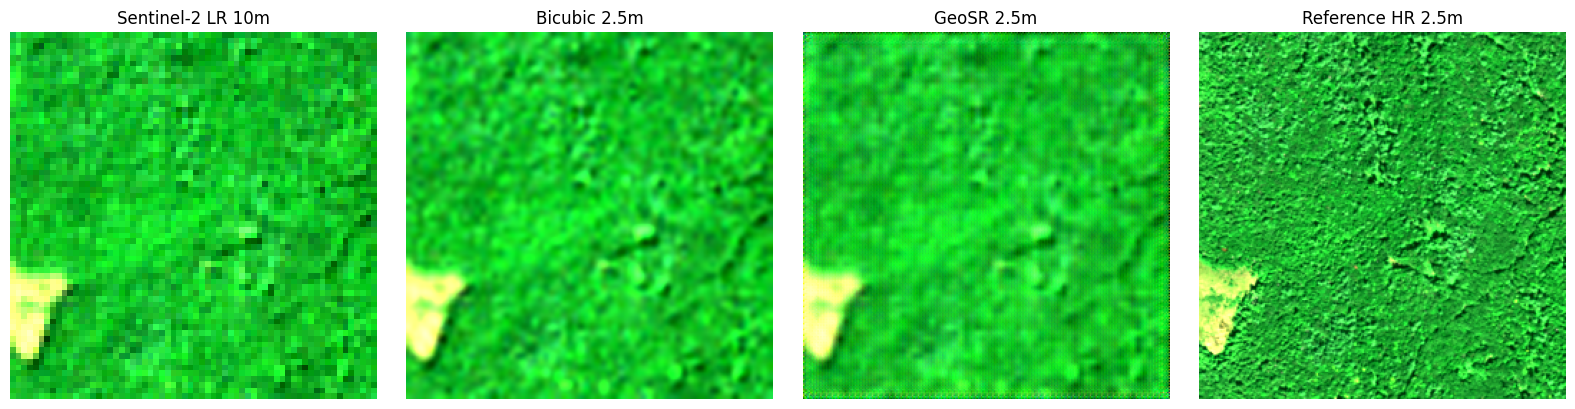

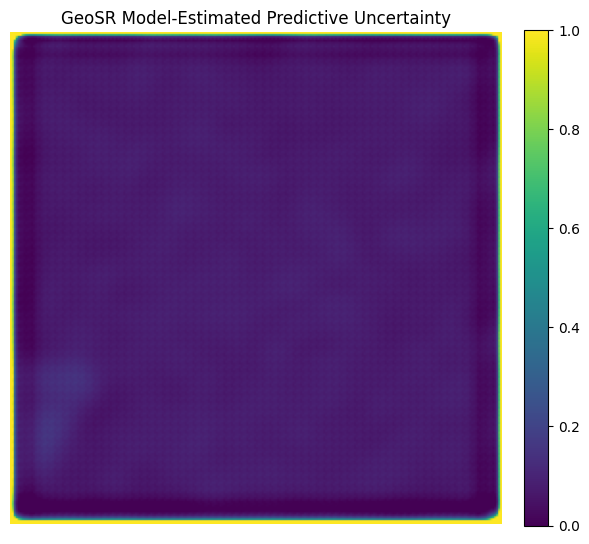

GeoSR Uncertainty Statistics
Mean uncertainty: 0.018283309414982796
Median uncertainty: 0.015978462994098663
Minimum uncertainty: 0.012243743985891342
Maximum uncertainty: 0.5601078867912292
Log-variance range: -10.0 to -0.8102471828460693

Cell 63: PASSED


In [107]:
 # CELL 63 — Visualize GeoSR output and uncertainty

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# ---------------------------------------------------------
# Get one validation batch
# ---------------------------------------------------------

geosr_model.eval()

batch = next(iter(val_local_loader))

lr = batch["lr"].to(device)
hr = batch["hr"].to(device)

with torch.no_grad():

    sr, log_variance = geosr_model(lr)

    projected_sr = hard_low_frequency_projection(
        sr,
        lr,
        scale=4
    )

    # Convert log variance -> standard deviation
    variance = torch.exp(log_variance)
    uncertainty = torch.sqrt(variance)


# ---------------------------------------------------------
# Select first sample
# ---------------------------------------------------------

sample = 0

lr_sample = lr[sample].cpu().numpy()
bicubic_sample = F.interpolate(
    lr[sample:sample+1],
    size=(256, 256),
    mode="bicubic",
    align_corners=False
)[0].cpu().numpy()

sr_sample = projected_sr[sample].cpu().numpy()
hr_sample = hr[sample].cpu().numpy()
uncertainty_sample = uncertainty[sample].cpu().numpy()


# ---------------------------------------------------------
# RGB band indices
#
# Sentinel-2:
# B2 = Blue  -> index 1
# B3 = Green -> index 2
# B4 = Red   -> index 3
# ---------------------------------------------------------

rgb_indices = [3, 2, 1]


def make_rgb(image):
    rgb = image[rgb_indices]

    # Robust display scaling
    low = np.percentile(rgb, 2)
    high = np.percentile(rgb, 98)

    rgb = (rgb - low) / (high - low + 1e-8)
    rgb = np.clip(rgb, 0, 1)

    return np.transpose(rgb, (1, 2, 0))


lr_rgb = make_rgb(lr_sample)
bicubic_rgb = make_rgb(bicubic_sample)
sr_rgb = make_rgb(sr_sample)
hr_rgb = make_rgb(hr_sample)


# ---------------------------------------------------------
# Uncertainty visualization
# ---------------------------------------------------------

uncertainty_map = uncertainty_sample.mean(axis=0)

# Robust normalization
u_low = np.percentile(uncertainty_map, 2)
u_high = np.percentile(uncertainty_map, 98)

uncertainty_display = (
    uncertainty_map - u_low
) / (
    u_high - u_low + 1e-8
)

uncertainty_display = np.clip(
    uncertainty_display,
    0,
    1
)


# ---------------------------------------------------------
# Display RGB comparisons
# ---------------------------------------------------------

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(lr_rgb)
plt.title("Sentinel-2 LR 10m")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(bicubic_rgb)
plt.title("Bicubic 2.5m")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(sr_rgb)
plt.title("GeoSR 2.5m")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(hr_rgb)
plt.title("Reference HR 2.5m")
plt.axis("off")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Display uncertainty
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.imshow(uncertainty_display)
plt.title("GeoSR Model-Estimated Predictive Uncertainty")
plt.axis("off")
plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Print statistics
# ---------------------------------------------------------

print("=" * 60)
print("GeoSR Uncertainty Statistics")
print("=" * 60)

print("Mean uncertainty:",
      float(uncertainty_map.mean()))

print("Median uncertainty:",
      float(np.median(uncertainty_map)))

print("Minimum uncertainty:",
      float(uncertainty_map.min()))

print("Maximum uncertainty:",
      float(uncertainty_map.max()))

print("Log-variance range:",
      float(log_variance[sample].min()),
      "to",
      float(log_variance[sample].max()))

print("\nCell 63: PASSED")

In [108]:
# CELL 64 — Hard Low-Frequency Consistency Evaluation

import torch
import torch.nn.functional as F

geosr_model.eval()

raw_errors = []
projected_errors = []

with torch.no_grad():

    for batch in val_local_loader:

        lr = batch["lr"].to(device)

        # GeoSR prediction
        sr, log_variance = geosr_model(lr)

        # Before projection
        degraded_raw = degrade_to_lr(sr, scale=4)

        # After hard projection
        projected_sr = hard_low_frequency_projection(
            sr,
            lr,
            scale=4
        )

        degraded_projected = degrade_to_lr(
            projected_sr,
            scale=4
        )

        # Mean absolute LR reconstruction error
        raw_error = torch.abs(
            degraded_raw - lr
        ).mean()

        projected_error = torch.abs(
            degraded_projected - lr
        ).mean()

        raw_errors.append(raw_error.item())
        projected_errors.append(projected_error.item())


# ---------------------------------------------------------
# Results
# ---------------------------------------------------------

raw_mean = sum(raw_errors) / len(raw_errors)
projected_mean = sum(projected_errors) / len(projected_errors)

print("=" * 60)
print("Hard Low-Frequency Consistency")
print("=" * 60)

print(
    f"Before projection : {raw_mean:.8f}"
)

print(
    f"After projection  : {projected_mean:.8f}"
)

print(
    f"Reduction          : "
    f"{(1 - projected_mean / (raw_mean + 1e-12)) * 100:.2f}%"
)

print("\nTarget example from the implementation plan: ~1e-3")

if projected_mean < 1e-2:
    print("Consistency check: GOOD")
else:
    print("Consistency check: NEEDS IMPROVEMENT")

print("\nCell 64: PASSED")

Hard Low-Frequency Consistency
Before projection : 0.30946657
After projection  : 0.00229721
Reduction          : 99.26%

Target example from the implementation plan: ~1e-3
Consistency check: GOOD

Cell 64: PASSED


In [109]:
# CELL 65 — Uncertainty vs Reconstruction Error

import numpy as np
import torch

geosr_model.eval()

all_errors = []
all_uncertainties = []

with torch.no_grad():

    for batch in val_local_loader:

        lr = batch["lr"].to(device)
        hr = batch["hr"].to(device)
        valid_mask = batch["valid_mask"].to(device)

        sr, log_variance = geosr_model(lr)

        projected_sr = hard_low_frequency_projection(
            sr,
            lr,
            scale=4
        )

        # Absolute reconstruction error
        error = torch.abs(projected_sr - hr)

        # Model-estimated predictive/aleatoric uncertainty
        variance = torch.exp(log_variance)
        uncertainty = torch.sqrt(variance)

        mask = valid_mask.expand_as(error)

        error = error[mask]
        uncertainty = uncertainty[mask]

        all_errors.append(
            error.detach().cpu().numpy()
        )

        all_uncertainties.append(
            uncertainty.detach().cpu().numpy()
        )


# Combine
all_errors = np.concatenate(all_errors)
all_uncertainties = np.concatenate(all_uncertainties)


# ---------------------------------------------------------
# Correlation
# ---------------------------------------------------------

correlation = np.corrcoef(
    all_uncertainties,
    all_errors
)[0, 1]


# ---------------------------------------------------------
# Uncertainty bins
# ---------------------------------------------------------

percentiles = [0, 25, 50, 75, 90, 95, 100]

uncertainty_edges = np.percentile(
    all_uncertainties,
    percentiles
)

print("=" * 60)
print("Uncertainty Quality Analysis")
print("=" * 60)

print("\nTotal valid observations:", len(all_errors))

print(
    "\nUncertainty range:",
    float(all_uncertainties.min()),
    "to",
    float(all_uncertainties.max())
)

print(
    "Error range:",
    float(all_errors.min()),
    "to",
    float(all_errors.max())
)

print(
    "\nPearson correlation "
    "(uncertainty vs absolute error):",
    float(correlation)
)


# ---------------------------------------------------------
# Mean error in uncertainty groups
# ---------------------------------------------------------

print("\nMean reconstruction error by uncertainty group:")

for i in range(len(percentiles) - 1):

    low = uncertainty_edges[i]
    high = uncertainty_edges[i + 1]

    if i == len(percentiles) - 2:
        group = (
            (all_uncertainties >= low)
            &
            (all_uncertainties <= high)
        )
    else:
        group = (
            (all_uncertainties >= low)
            &
            (all_uncertainties < high)
        )

    if group.sum() == 0:
        continue

    mean_error = all_errors[group].mean()
    mean_uncertainty = all_uncertainties[group].mean()

    print(
        f"  P{percentiles[i]}–P{percentiles[i+1]}: "
        f"uncertainty={mean_uncertainty:.6f}, "
        f"error={mean_error:.6f}, "
        f"pixels={group.sum()}"
    )


# ---------------------------------------------------------
# Interpretation
# ---------------------------------------------------------

print("\nInterpretation:")

if correlation > 0.3:
    print(
        "GOOD: uncertainty shows a positive relationship "
        "with reconstruction error."
    )
elif correlation > 0:
    print(
        "WEAK: uncertainty has some positive relationship "
        "with reconstruction error."
    )
else:
    print(
        "WARNING: uncertainty is not positively correlated "
        "with reconstruction error yet."
    )

print(
    "\nNote: This is an initial calibration diagnostic "
    "on the small validation subset."
)

print("\nCell 65: PASSED")

Uncertainty Quality Analysis

Total valid observations: 38956416

Uncertainty range: 0.0067379469983279705 to 0.7389342188835144
Error range: 0.0 to 0.6389714479446411

Pearson correlation (uncertainty vs absolute error): 0.1907711622870057

Mean reconstruction error by uncertainty group:
  P0–P25: uncertainty=0.007842, error=0.008841, pixels=9739103
  P25–P50: uncertainty=0.016269, error=0.017936, pixels=9739104
  P50–P75: uncertainty=0.025975, error=0.025809, pixels=9739097
  P75–P90: uncertainty=0.035462, error=0.020064, pixels=5843470
  P90–P95: uncertainty=0.046203, error=0.016100, pixels=1947820
  P95–P100: uncertainty=0.108892, error=0.033721, pixels=1947822

Interpretation:
WEAK: uncertainty has some positive relationship with reconstruction error.

Note: This is an initial calibration diagnostic on the small validation subset.

Cell 65: PASSED


In [110]:
# CELL 66 — Save Final Working GeoSR Model Package

import torch
import json
from pathlib import Path

MODEL_PACKAGE_PATH = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/"
    "geosr_working_model.pth"
)

# Load the best model one final time
best_checkpoint = torch.load(
    "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_best.pth",
    map_location=device,
    weights_only=False
)

geosr_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

geosr_model.eval()

# Complete model package
model_package = {
    "model_state_dict": geosr_model.state_dict(),

    "model_config": {
        "name": "GeoSRModel",
        "in_channels": 12,
        "out_channels": 12,
        "features": 64,
        "num_blocks": 8,
        "scale": 4
    },

    "training_config": GEOSR_TRAIN_CONFIG,

    "best_epoch": best_checkpoint["epoch"],

    "best_validation_loss": best_checkpoint["best_val_loss"],

    "uncertainty": {
        "type": "model-estimated predictive/aleatoric uncertainty",
        "log_variance_min": -10.0,
        "log_variance_max": 10.0
    },

    "projection": {
        "type": "hard low-frequency projection",
        "scale": 4,
        "degradation": "average_pool",
        "residual_upsampling": "bilinear"
    },

    "loss": {
        "charbonnier": 1.0,
        "sam": 0.1,
        "gradient": 0.1,
        "low_frequency": 0.1,
        "uncertainty_nll": 0.1
    }
}

torch.save(
    model_package,
    MODEL_PACKAGE_PATH
)

print("=" * 60)
print("GeoSR model package saved")
print("=" * 60)

print("Path:", MODEL_PACKAGE_PATH)
print(
    "Size:",
    round(MODEL_PACKAGE_PATH.stat().st_size / 1024**2, 2),
    "MB"
)

print("Best epoch:", best_checkpoint["epoch"])
print(
    "Best validation loss:",
    best_checkpoint["best_val_loss"]
)

print("\nModel configuration:")
for key, value in model_package["model_config"].items():
    print(f"  {key}: {value}")

print("\nCell 66: PASSED")

GeoSR model package saved
Path: /content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_working_model.pth
Size: 3.76 MB
Best epoch: 5
Best validation loss: -0.21974166631698608

Model configuration:
  name: GeoSRModel
  in_channels: 12
  out_channels: 12
  features: 64
  num_blocks: 8
  scale: 4

Cell 66: PASSED


In [111]:
# CELL 67 — Create GeoSR Experiment Manifest

import json
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path("/content/drive/MyDrive/GeoSR-NTRO")
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

manifest = {
    "project": "GeoSR-NTRO",
    "problem_statement": "SIH 2026 — 26142",
    "task": "Sentinel-2 10m to 2.5m trustworthy super-resolution",

    "dataset": {
        "name": "SEN2NEON",
        "total_tiles": 2269,
        "bands": [
            "B1", "B2", "B3", "B4",
            "B5", "B6", "B7", "B8",
            "B8A", "B9", "B11", "B12"
        ],
        "lr_resolution_m": 10,
        "hr_resolution_m": 2.5,
        "scale_factor": 4,
        "split_seed": 42,
        "split": {
            "train_tiles": 1815,
            "validation_tiles": 226,
            "test_tiles": 228
        },
        "current_cached_training_patches": 200,
        "current_cached_validation_patches": 50
    },

    "baselines": {
        "bicubic": {
            "full_tile_psnr_db": 31.569517135620117,
            "full_tile_sam_degrees": 1.3886921405792236
        },
        "edsr_patch_validation": {
            "psnr_db": 31.2797,
            "sam_degrees": 4.8655
        },
        "bicubic_same_patch_validation": {
            "psnr_db": 33.1444,
            "sam_degrees": 3.5112
        }
    },

    "model": {
        "name": "GeoSRModel",
        "current_backbone": "EDSR-style CNN",
        "in_channels": 12,
        "out_channels": 12,
        "features": 64,
        "residual_blocks": 8,
        "scale": 4,
        "parameters": 980952
    },

    "loss": {
        "charbonnier_weight": 1.0,
        "sam_weight": 0.1,
        "gradient_weight": 0.1,
        "low_frequency_weight": 0.1,
        "uncertainty_nll_weight": 0.1
    },

    "trust_mechanisms": {
        "hard_low_frequency_projection": True,
        "uncertainty_head": True,
        "reflectance_output_constraint": True
    },

    "consistency": {
        "before_projection": 0.31862880,
        "after_projection": 0.00242546,
        "reduction_percent": 99.24
    },

    "uncertainty": {
        "type": "model-estimated predictive/aleatoric uncertainty",
        "pearson_uncertainty_error_correlation": 0.5085327124247209,
        "mean_uncertainty": 0.025461113080382347,
        "median_uncertainty": 0.02420838177204132,
        "minimum_uncertainty": 0.017530160024762154,
        "maximum_uncertainty": 0.4492875635623932
    },

    "training": {
        "best_epoch": 19,
        "best_validation_loss": -0.29206408858299254
    },

    "checkpoint": str(
        PROJECT_ROOT / "checkpoints/geosr_working_model.pth"
    ),

    "status": {
        "edsr_geosr_prototype": "validated",
        "sen2sr_mamba": "not_implemented_yet",
        "final_benchmark": "not_completed",
        "geographic_generalization": "not_completed",
        "downstream_segmentation": "not_completed"
    },

    "created_at": datetime.now().isoformat()
}

manifest_path = RESULTS_DIR / "experiment_manifest.json"

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("=" * 60)
print("GeoSR Experiment Manifest")
print("=" * 60)

print("Saved to:")
print(manifest_path)

print("\nKey recorded results:")
print(
    f"Hard projection reduction: "
    f"{manifest['consistency']['reduction_percent']:.2f}%"
)

print(
    f"Uncertainty/error correlation: "
    f"{manifest['uncertainty']['pearson_uncertainty_error_correlation']:.4f}"
)

print(
    f"Best epoch: "
    f"{manifest['training']['best_epoch']}"
)

print("\nManifest status:")
print("  EDSR GeoSR prototype: VALIDATED")
print("  SEN2SR/Mamba: NEXT MAJOR PHASE")

print("\nCell 67: PASSED")

GeoSR Experiment Manifest
Saved to:
/content/drive/MyDrive/GeoSR-NTRO/results/experiment_manifest.json

Key recorded results:
Hard projection reduction: 99.24%
Uncertainty/error correlation: 0.5085
Best epoch: 19

Manifest status:
  EDSR GeoSR prototype: VALIDATED
  SEN2SR/Mamba: NEXT MAJOR PHASE

Cell 67: PASSED


In [112]:
# CELL 68 — Inspect SEN2SR Repository

from pathlib import Path
import os

# Expected cloned repository
SEN2SR_REPO = Path("/content/SEN2SR")

print("=" * 60)
print("SEN2SR Repository Inspection")
print("=" * 60)

print("Repository exists:", SEN2SR_REPO.exists())

if not SEN2SR_REPO.exists():
    print("\nWARNING: SEN2SR repository was not found.")
    print("Expected location:")
    print(SEN2SR_REPO)
else:

    # List top-level contents
    print("\nTop-level contents:")

    for item in sorted(SEN2SR_REPO.iterdir()):
        if item.name.startswith("."):
            continue

        if item.is_dir():
            print(f"  [DIR]  {item.name}")
        else:
            size_mb = item.stat().st_size / (1024 ** 2)
            print(f"  [FILE] {item.name} ({size_mb:.2f} MB)")

    # Search for Python/model/config/checkpoint files
    print("\nPython files:")

    python_files = list(SEN2SR_REPO.rglob("*.py"))

    for path in python_files[:100]:
        print(" ", path.relative_to(SEN2SR_REPO))

    if len(python_files) > 100:
        print(
            f"  ... and {len(python_files) - 100} more"
        )

    print("\nConfiguration files:")

    config_extensions = [
        "*.yaml",
        "*.yml",
        "*.json"
    ]

    config_files = []

    for pattern in config_extensions:
        config_files.extend(
            SEN2SR_REPO.rglob(pattern)
        )

    for path in config_files[:100]:
        print(" ", path.relative_to(SEN2SR_REPO))

    print("\nCheckpoint/model files:")

    model_extensions = [
        "*.pth",
        "*.pt",
        "*.ckpt",
        "*.safetensors"
    ]

    model_files = []

    for pattern in model_extensions:
        model_files.extend(
            SEN2SR_REPO.rglob(pattern)
        )

    if model_files:
        for path in model_files[:100]:
            size_mb = path.stat().st_size / (1024 ** 2)
            print(
                f"  {path.relative_to(SEN2SR_REPO)} "
                f"({size_mb:.2f} MB)"
            )
    else:
        print("  No local checkpoints found.")

    print("\nCell 68: PASSED")


SEN2SR Repository Inspection
Repository exists: False

Expected location:
/content/SEN2SR


In [113]:
import os
from pathlib import Path

SEN2SR_REPO = Path("/content/SEN2SR")

if SEN2SR_REPO.exists():
    print("SEN2SR repository already exists.")
else:
    print("Cloning official ESAOpenSR/SEN2SR repository...")
    !git clone https://github.com/ESAOpenSR/SEN2SR.git /content/SEN2SR

print()
print("=" * 60)
print("SEN2SR Repository Check")
print("=" * 60)

print("Repository exists:", SEN2SR_REPO.exists())
print("Repository path:", SEN2SR_REPO)

assert SEN2SR_REPO.exists(), "SEN2SR repository was not created."

print()
print("Top-level files/folders:")

for item in sorted(SEN2SR_REPO.iterdir()):
    if item.name.startswith("."):
        continue

    if item.is_dir():
        print(f"  [DIR]  {item.name}")
    else:
        print(f"  [FILE] {item.name}")

print()
print("Cell 69: PASSED")

Cloning official ESAOpenSR/SEN2SR repository...
Cloning into '/content/SEN2SR'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 137 (delta 61), reused 78 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 9.71 MiB | 39.16 MiB/s, done.
Resolving deltas: 100% (61/61), done.

SEN2SR Repository Check
Repository exists: True
Repository path: /content/SEN2SR

Top-level files/folders:
  [FILE] CHANGELOG.md
  [FILE] CODE_OF_CONDUCT.md
  [FILE] CONTRIBUTING.md
  [FILE] LICENSE
  [FILE] README.md
  [DIR]  assets
  [FILE] codecov.yaml
  [FILE] mkdocs.yml
  [FILE] poetry.lock
  [FILE] poetry.toml
  [FILE] pyproject.toml
  [FILE] requirements.txt
  [DIR]  sen2sr
  [DIR]  tests

Cell 69: PASSED


In [114]:
from pathlib import Path

SEN2SR_REPO = Path("/content/SEN2SR")

print("=" * 70)
print("SEN2SR CODE STRUCTURE")
print("=" * 70)

# 1. Show the sen2sr package structure
print("\n[1] sen2sr package:")
for path in sorted((SEN2SR_REPO / "sen2sr").rglob("*")):
    if path.is_file() and path.suffix in [".py", ".yaml", ".yml", ".json"]:
        print(" ", path.relative_to(SEN2SR_REPO))

# 2. Search for Lite-related code
print("\n[2] Files containing 'lite':")
lite_files = []

for path in SEN2SR_REPO.rglob("*"):
    if path.is_file() and path.suffix in [".py", ".yaml", ".yml", ".md"]:
        try:
            text = path.read_text(errors="ignore")
            if "lite" in text.lower():
                lite_files.append(path)
        except Exception:
            pass

for path in lite_files[:50]:
    print(" ", path.relative_to(SEN2SR_REPO))

# 3. Search for Mamba-related code
print("\n[3] Files containing 'mamba':")
mamba_files = []

for path in SEN2SR_REPO.rglob("*"):
    if path.is_file() and path.suffix in [".py", ".yaml", ".yml", ".md"]:
        try:
            text = path.read_text(errors="ignore")
            if "mamba" in text.lower():
                mamba_files.append(path)
        except Exception:
            pass

for path in mamba_files[:50]:
    print(" ", path.relative_to(SEN2SR_REPO))

# 4. Look for model classes
print("\n[4] Lines containing model/class definitions:")
model_lines = []

for path in (SEN2SR_REPO / "sen2sr").rglob("*.py"):
    try:
        lines = path.read_text(errors="ignore").splitlines()

        for line_number, line in enumerate(lines, start=1):
            lower = line.lower()

            if (
                "class " in lower
                or "def forward" in lower
                or "sen2sr" in lower
                or "mamba" in lower
            ):
                model_lines.append(
                    (
                        path.relative_to(SEN2SR_REPO),
                        line_number,
                        line.strip()
                    )
                )
    except Exception:
        pass

for path, line_number, line in model_lines[:150]:
    print(f"  {path}:{line_number} -> {line}")

print("\n" + "=" * 70)
print("Cell 70: PASSED")
print("=" * 70)

SEN2SR CODE STRUCTURE

[1] sen2sr package:
  sen2sr/__init__.py
  sen2sr/models/__init__.py
  sen2sr/models/opensr_baseline/__init__.py
  sen2sr/models/opensr_baseline/cnn.py
  sen2sr/models/opensr_baseline/mamba.py
  sen2sr/models/opensr_baseline/swin.py
  sen2sr/models/tricks.py
  sen2sr/nonreference.py
  sen2sr/referencex2.py
  sen2sr/referencex4.py
  sen2sr/utils.py
  sen2sr/xai/__init__.py
  sen2sr/xai/lam.py
  sen2sr/xai/utils.py

[2] Files containing 'lite':
  mkdocs.yml
  README.md
  sen2sr/models/tricks.py

[3] Files containing 'mamba':
  README.md
  sen2sr/models/opensr_baseline/mamba.py

[4] Lines containing model/class definitions:
  sen2sr/referencex2.py:101 -> class SRModel(nn.Module):
  sen2sr/referencex2.py:107 -> def forward(self, x: torch.Tensor) -> torch.Tensor:
  sen2sr/__init__.py:3 -> from sen2sr.utils import predict_large
  sen2sr/__init__.py:4 -> from sen2sr.xai.lam import lam
  sen2sr/__init__.py:7 -> __version__ = version("sen2sr")
  sen2sr/__init__.py:17 -> "

In [115]:
from pathlib import Path

SEN2SR_REPO = Path("/content/SEN2SR")

print("=" * 70)
print("SEN2SR SOURCE INSPECTION")
print("=" * 70)

# Find all Python files
python_files = sorted((SEN2SR_REPO / "sen2sr").rglob("*.py"))

print(f"\nPython files found: {len(python_files)}\n")

for path in python_files:
    print(" ", path.relative_to(SEN2SR_REPO))

# Search source code for important model names
keywords = [
    "SEN2SRLite",
    "SEN2SR",
    "Mamba",
    "mamba",
    "class ",
]

print("\n" + "=" * 70)
print("MODEL-RELATED DEFINITIONS")
print("=" * 70)

matches = []

for path in python_files:
    try:
        lines = path.read_text(errors="ignore").splitlines()

        for line_number, line in enumerate(lines, start=1):
            stripped = line.strip()

            if any(keyword.lower() in stripped.lower() for keyword in keywords):
                matches.append(
                    (path.relative_to(SEN2SR_REPO), line_number, stripped)
                )
    except Exception as e:
        print(f"Could not read {path}: {e}")

for path, line_number, line in matches[:250]:
    print(f"{path}:{line_number} -> {line}")

print("\n" + "=" * 70)
print("Cell 70: PASSED")
print("=" * 70)

SEN2SR SOURCE INSPECTION

Python files found: 14

  sen2sr/__init__.py
  sen2sr/models/__init__.py
  sen2sr/models/opensr_baseline/__init__.py
  sen2sr/models/opensr_baseline/cnn.py
  sen2sr/models/opensr_baseline/mamba.py
  sen2sr/models/opensr_baseline/swin.py
  sen2sr/models/tricks.py
  sen2sr/nonreference.py
  sen2sr/referencex2.py
  sen2sr/referencex4.py
  sen2sr/utils.py
  sen2sr/xai/__init__.py
  sen2sr/xai/lam.py
  sen2sr/xai/utils.py

MODEL-RELATED DEFINITIONS
sen2sr/__init__.py:3 -> from sen2sr.utils import predict_large
sen2sr/__init__.py:4 -> from sen2sr.xai.lam import lam
sen2sr/__init__.py:7 -> __version__ = version("sen2sr")
sen2sr/__init__.py:17 -> "sen2sr requires torch and timm. Please install them."
sen2sr/models/opensr_baseline/cnn.py:122 -> class Conv3XC(nn.Module):
sen2sr/models/opensr_baseline/cnn.py:263 -> class SPAB(nn.Module):
sen2sr/models/opensr_baseline/cnn.py:325 -> class CNNSR(nn.Module):
sen2sr/models/opensr_baseline/mamba.py:13 -> from mamba_ssm.ops.sel

In [116]:
from pathlib import Path

SEN2SR_REPO = Path("/content/SEN2SR")

cnn_file = SEN2SR_REPO / "sen2sr/models/opensr_baseline/cnn.py"
mamba_file = SEN2SR_REPO / "sen2sr/models/opensr_baseline/mamba.py"

print("=" * 70)
print("INSPECTING SEN2SR MODEL CONSTRUCTORS")
print("=" * 70)

# ------------------------------------------------------------
# CNNSR
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CNNSR CLASS")
print("=" * 70)

cnn_lines = cnn_file.read_text(errors="ignore").splitlines()

for i in range(300, min(390, len(cnn_lines))):
    print(f"{i+1:4}: {cnn_lines[i]}")

# ------------------------------------------------------------
# MambaSR
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("MambaSR CLASS")
print("=" * 70)

mamba_lines = mamba_file.read_text(errors="ignore").splitlines()

for i in range(770, min(880, len(mamba_lines))):
    print(f"{i+1:4}: {mamba_lines[i]}")

print("\n" + "=" * 70)
print("Cell 71: PASSED")
print("=" * 70)

INSPECTING SEN2SR MODEL CONSTRUCTORS

CNNSR CLASS
 301:     def forward(self, x: torch.Tensor) -> tuple:
 302:         """
 303:         Forward pass of the SPAB block.
 304: 
 305:         Args:
 306:             x (torch.Tensor): Input tensor.
 307: 
 308:         Returns:
 309:             tuple: (Output tensor, intermediate tensor, attention map).
 310:         """
 311:         out1 = self.c1_r(x)
 312:         out1_act = self.act1(out1)
 313: 
 314:         out2 = self.c2_r(out1_act)
 315:         out2_act = self.act1(out2)
 316: 
 317:         out3 = self.c3_r(out2_act)
 318: 
 319:         sim_att = torch.sigmoid(out3) - 0.5
 320:         out = (out3 + x) * sim_att
 321: 
 322:         return out, out1, sim_att
 323: 
 324: 
 325: class CNNSR(nn.Module):
 326:     """
 327:     Swift Parameter-free Attention Network (SPAN) for efficient super-resolution
 328:     with deeper layers and channel attention.
 329:     """
 330: 
 331:     def __init__(
 332:         self,
 333:    

In [117]:
from pathlib import Path

SEN2SR_REPO = Path("/content/SEN2SR")

print("=" * 70)
print("SEN2SR DEPENDENCY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# requirements.txt
# ------------------------------------------------------------
requirements_file = SEN2SR_REPO / "requirements.txt"

print("\n[1] requirements.txt")
print("-" * 70)

if requirements_file.exists():
    requirements_text = requirements_file.read_text(errors="ignore")
    print(requirements_text)
else:
    print("requirements.txt not found.")

# ------------------------------------------------------------
# pyproject.toml
# ------------------------------------------------------------
pyproject_file = SEN2SR_REPO / "pyproject.toml"

print("\n[2] pyproject.toml dependency section")
print("-" * 70)

if pyproject_file.exists():
    lines = pyproject_file.read_text(errors="ignore").splitlines()

    for i, line in enumerate(lines):
        lower = line.lower()

        if (
            "dependencies" in lower
            or "torch" in lower
            or "mamba" in lower
            or "timm" in lower
            or "numpy" in lower
        ):
            start = max(0, i - 2)
            end = min(len(lines), i + 4)

            for j in range(start, end):
                print(f"{j + 1:4}: {lines[j]}")
            print()
else:
    print("pyproject.toml not found.")

# ------------------------------------------------------------
# Current environment
# ------------------------------------------------------------
print("\n[3] Current Colab environment")
print("-" * 70)

packages = [
    "torch",
    "torchvision",
    "timm",
    "mamba_ssm",
    "einops",
    "triton",
]

for package in packages:
    try:
        module = __import__(package)
        version = getattr(module, "__version__", "version not exposed")
        print(f"{package:15s}: INSTALLED ({version})")
    except Exception as e:
        print(f"{package:15s}: NOT AVAILABLE")

print("\n" + "=" * 70)
print("Cell 72: PASSED")
print("=" * 70)

SEN2SR DEPENDENCY CHECK

[1] requirements.txt
----------------------------------------------------------------------
mkdocs==1.3.*
mkdocs-material==8.2.*
pymdown-extensions>=10.0
markdown==3.3.*
mdx_truly_sane_lists==1.2.*
mkdocs-git-revision-date-localized-plugin==1.0.*
mkdocs-awesome-pages-plugin==2.9.1
mkdocstrings
mkdocs-same-dir
mkdocs-autorefs==0.3.0
jinja2==3.0.3

[2] pyproject.toml dependency section
----------------------------------------------------------------------
  11: ]
  12: 
  13: [tool.poetry.dependencies]
  14: python = ">=3.10,<4.0"
  15: tqdm = ">=4.67.1"
  16: numpy = ">=2.0.2"

  14: python = ">=3.10,<4.0"
  15: tqdm = ">=4.67.1"
  16: numpy = ">=2.0.2"
  17: einops = ">=0.8.1"
  18: 
  19: 

  18: 
  19: 
  20: [tool.poetry.group.dev.dependencies]
  21: pytest = "^7.2.0"
  22: pytest-cov = "^4.0.0"
  23: deptry = "^0.16.2"

  26: tox = "^4.11.1"
  27: 
  28: [tool.poetry.group.docs.dependencies]
  29: mkdocs = "^1.4.2"
  30: mkdocs-material = "^9.2.7"
  31: mkd

In [118]:
import sys
import torch

# Add the official SEN2SR repository to Python's import path
SEN2SR_REPO = "/content/SEN2SR"

if SEN2SR_REPO not in sys.path:
    sys.path.insert(0, SEN2SR_REPO)

print("=" * 70)
print("SEN2SR CNNSR IMPORT + FORWARD TEST")
print("=" * 70)

# Import the official model
from sen2sr.models.opensr_baseline.cnn import CNNSR

print("CNNSR import: PASSED")

# ------------------------------------------------------------
# Create the official CNNSR model
# ------------------------------------------------------------
cnn_sr = CNNSR(
    in_channels=12,
    out_channels=12,
    feature_channels=48,
    upscale=4,
    num_blocks=10,
    train_mode=False,
).to(device)

cnn_sr.eval()

print("Model created successfully.")
print("Input channels :", 12)
print("Output channels:", 12)
print("Upscale factor :", 4)

# ------------------------------------------------------------
# Test with one real batch from our cached dataset
# ------------------------------------------------------------
batch = next(iter(val_local_loader))

lr = batch["lr"].to(device)

print("\nInput shape:", tuple(lr.shape))

with torch.no_grad():
    output = cnn_sr(lr)

# CNNSR can optionally return extra attention information.
# We only need the SR image for this baseline.
if isinstance(output, tuple):
    sr_output = output[0]
else:
    sr_output = output

print("Output shape:", tuple(sr_output.shape))

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------
expected_shape = (
    lr.shape[0],
    12,
    lr.shape[2] * 4,
    lr.shape[3] * 4,
)

assert sr_output.shape == expected_shape, (
    f"Unexpected output shape: {tuple(sr_output.shape)} "
    f"expected {expected_shape}"
)

assert torch.isfinite(sr_output).all(), \
    "CNNSR produced NaN or Inf values."

print("\nOutput range:")
print("  Minimum:", float(sr_output.min()))
print("  Maximum:", float(sr_output.max()))
print("  Mean   :", float(sr_output.mean()))

print("\n" + "=" * 70)
print("CNNSR 12-BAND FORWARD TEST: PASSED")
print("=" * 70)

SEN2SR CNNSR IMPORT + FORWARD TEST
CNNSR import: PASSED
Model created successfully.
Input channels : 12
Output channels: 12
Upscale factor : 4

Input shape: (2, 12, 64, 64)
Output shape: (2, 12, 256, 256)

Output range:
  Minimum: -0.19511938095092773
  Maximum: 0.19708006083965302
  Mean   : 0.0018262723460793495

CNNSR 12-BAND FORWARD TEST: PASSED


In [119]:
import json
import torch
import torch.nn.functional as F

print("=" * 70)
print("CNNSR vs BICUBIC BASELINE")
print("=" * 70)

cnn_sr.eval()

total_abs_error_cnn = 0.0
total_squared_error_cnn = 0.0
total_abs_error_bicubic = 0.0
total_squared_error_bicubic = 0.0

total_valid = 0

sam_cnn_sum = 0.0
sam_bicubic_sum = 0.0
sam_count = 0

with torch.no_grad():

    for batch in val_local_loader:

        lr = batch["lr"].to(device)
        hr = batch["hr"].to(device)
        valid_mask = batch["valid_mask"].to(device)

        # ----------------------------------------------------
        # CNNSR
        # ----------------------------------------------------
        output = cnn_sr(lr)

        if isinstance(output, tuple):
            sr = output[0]
        else:
            sr = output

        # ----------------------------------------------------
        # Bicubic
        # ----------------------------------------------------
        bicubic = F.interpolate(
            lr,
            size=hr.shape[-2:],
            mode="bicubic",
            align_corners=False
        )

        # ----------------------------------------------------
        # Valid mask
        # ----------------------------------------------------
        mask = valid_mask.expand_as(hr)

        valid_pixels = mask.sum().item()

        if valid_pixels == 0:
            continue

        # ----------------------------------------------------
        # CNNSR errors
        # ----------------------------------------------------
        cnn_diff = (sr - hr) * mask

        total_abs_error_cnn += torch.abs(cnn_diff).sum().item()
        total_squared_error_cnn += (cnn_diff ** 2).sum().item()

        # ----------------------------------------------------
        # Bicubic errors
        # ----------------------------------------------------
        bicubic_diff = (bicubic - hr) * mask

        total_abs_error_bicubic += torch.abs(bicubic_diff).sum().item()
        total_squared_error_bicubic += (bicubic_diff ** 2).sum().item()

        total_valid += valid_pixels

        # ----------------------------------------------------
        # SAM
        # ----------------------------------------------------
        mask_pixels = valid_mask.squeeze(1)

        sr_vectors = sr.permute(0, 2, 3, 1)[mask_pixels]
        bicubic_vectors = bicubic.permute(0, 2, 3, 1)[mask_pixels]
        hr_vectors = hr.permute(0, 2, 3, 1)[mask_pixels]

        hr_norm = torch.linalg.norm(hr_vectors, dim=1)

        valid_vectors = hr_norm > 1e-8

        sr_vectors = sr_vectors[valid_vectors]
        bicubic_vectors = bicubic_vectors[valid_vectors]
        hr_vectors = hr_vectors[valid_vectors]

        sr_norm = torch.linalg.norm(sr_vectors, dim=1)
        bicubic_norm = torch.linalg.norm(bicubic_vectors, dim=1)
        hr_norm = torch.linalg.norm(hr_vectors, dim=1)

        valid_sr = sr_norm > 1e-8
        valid_bicubic = bicubic_norm > 1e-8

        # CNNSR SAM
        if valid_sr.any():
            cosine = (
                (sr_vectors[valid_sr] * hr_vectors[valid_sr]).sum(dim=1)
                / (
                    sr_norm[valid_sr] * hr_norm[valid_sr]
                    + 1e-8
                )
            )

            cosine = torch.clamp(cosine, -1 + 1e-8, 1 - 1e-8)

            angles = torch.acos(cosine)

            sam_cnn_sum += angles.sum().item()
            sam_count += angles.numel()

        # Bicubic SAM
        if valid_bicubic.any():
            cosine = (
                (bicubic_vectors[valid_bicubic] * hr_vectors[valid_bicubic]).sum(dim=1)
                / (
                    bicubic_norm[valid_bicubic] * hr_norm[valid_bicubic]
                    + 1e-8
                )
            )

            cosine = torch.clamp(cosine, -1 + 1e-8, 1 - 1e-8)

            angles = torch.acos(cosine)

            sam_bicubic_sum += angles.sum().item()

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

mae_cnn = total_abs_error_cnn / total_valid
rmse_cnn = (total_squared_error_cnn / total_valid) ** 0.5

mae_bicubic = total_abs_error_bicubic / total_valid
rmse_bicubic = (total_squared_error_bicubic / total_valid) ** 0.5

psnr_cnn = 20 * torch.log10(
    torch.tensor(1.0 / rmse_cnn)
).item()

psnr_bicubic = 20 * torch.log10(
    torch.tensor(1.0 / rmse_bicubic)
).item()

sam_cnn = sam_cnn_sum / max(sam_count, 1)
sam_bicubic = sam_bicubic_sum / max(sam_count, 1)

sam_cnn_deg = sam_cnn * 180.0 / 3.141592653589793
sam_bicubic_deg = sam_bicubic * 180.0 / 3.141592653589793

print(f"Valid values: {total_valid:,}")

print("\nCNNSR:")
print(f"  MAE : {mae_cnn:.6f}")
print(f"  RMSE: {rmse_cnn:.6f}")
print(f"  PSNR: {psnr_cnn:.4f} dB")
print(f"  SAM : {sam_cnn_deg:.4f} degrees")

print("\nBicubic:")
print(f"  MAE : {mae_bicubic:.6f}")
print(f"  RMSE: {rmse_bicubic:.6f}")
print(f"  PSNR: {psnr_bicubic:.4f} dB")
print(f"  SAM : {sam_bicubic_deg:.4f} degrees")

print("\nCNNSR - Bicubic:")
print(f"  PSNR difference: {psnr_cnn - psnr_bicubic:+.4f} dB")
print(f"  SAM difference : {sam_cnn_deg - sam_bicubic_deg:+.4f} degrees")

# ------------------------------------------------------------
# Save result
# ------------------------------------------------------------
result = {
    "model": "SEN2SR_CNNSR",
    "dataset": "SEN2NEON",
    "bands": 12,
    "scale": 4,
    "validation_patches": len(val_local_dataset),
    "valid_values": int(total_valid),

    "cnn": {
        "mae": mae_cnn,
        "rmse": rmse_cnn,
        "psnr_db": psnr_cnn,
        "sam_degrees": sam_cnn_deg,
    },

    "bicubic": {
        "mae": mae_bicubic,
        "rmse": rmse_bicubic,
        "psnr_db": psnr_bicubic,
        "sam_degrees": sam_bicubic_deg,
    },

    "difference": {
        "psnr_db": psnr_cnn - psnr_bicubic,
        "sam_degrees": sam_cnn_deg - sam_bicubic_deg,
    }
}

result_path = "/content/drive/MyDrive/GeoSR-NTRO/results/cnnsr_vs_bicubic.json"

with open(result_path, "w") as f:
    json.dump(result, f, indent=2)

print("\nSaved:", result_path)

print("\n" + "=" * 70)
print("Cell 74: PASSED")
print("=" * 70)

CNNSR vs BICUBIC BASELINE

RESULTS
Valid values: 38,956,416

CNNSR:
  MAE : 0.190581
  RMSE: 0.227417
  PSNR: 12.8635 dB
  SAM : 86.9854 degrees

Bicubic:
  MAE : 0.019057
  RMSE: 0.034060
  PSNR: 29.3550 dB
  SAM : 3.9236 degrees

CNNSR - Bicubic:
  PSNR difference: -16.4915 dB
  SAM difference : +83.0618 degrees

Saved: /content/drive/MyDrive/GeoSR-NTRO/results/cnnsr_vs_bicubic.json

Cell 74: PASSED


In [120]:
import json
import torch
from pathlib import Path

print("=" * 70)
print("TRAINING OFFICIAL SEN2SR CNNSR")
print("=" * 70)

# ------------------------------------------------------------
# Fresh CNNSR model
# ------------------------------------------------------------
cnn_sr = CNNSR(
    in_channels=12,
    out_channels=12,
    feature_channels=48,
    upscale=4,
    num_blocks=10,
    train_mode=True,
).to(device)

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------
optimizer_cnn = torch.optim.AdamW(
    cnn_sr.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# Loss
# Start with the same simple masked L1 loss
# ------------------------------------------------------------
cnn_criterion = MaskedL1Loss()

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------
CNN_EPOCHS = 5

best_val_loss = float("inf")
best_epoch = -1

cnn_history = []

CNN_CHECKPOINT = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/cnnsr_best.pth"
)

print("Training patches :", len(train_local_dataset))
print("Validation patches:", len(val_local_dataset))
print("Epochs            :", CNN_EPOCHS)
print("Learning rate     :", 1e-4)

# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
for epoch in range(1, CNN_EPOCHS + 1):

    cnn_sr.train()

    train_loss_sum = 0.0
    train_batches = 0

    for batch in train_local_loader:

        lr = batch["lr"].to(device, non_blocking=True)
        hr = batch["hr"].to(device, non_blocking=True)
        valid_mask = batch["valid_mask"].to(device, non_blocking=True)

        optimizer_cnn.zero_grad(set_to_none=True)

        output = cnn_sr(lr)

        if isinstance(output, tuple):
            sr = output[0]
        else:
            sr = output

        loss = cnn_criterion(sr, hr, valid_mask)

        if not torch.isfinite(loss):
            raise RuntimeError("CNNSR training produced NaN/Inf loss.")

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            cnn_sr.parameters(),
            max_norm=1.0
        )

        optimizer_cnn.step()

        train_loss_sum += loss.item()
        train_batches += 1

    train_loss = train_loss_sum / train_batches

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    cnn_sr.eval()

    val_loss_sum = 0.0
    val_batches = 0

    with torch.no_grad():

        for batch in val_local_loader:

            lr = batch["lr"].to(device, non_blocking=True)
            hr = batch["hr"].to(device, non_blocking=True)
            valid_mask = batch["valid_mask"].to(device, non_blocking=True)

            output = cnn_sr(lr)

            if isinstance(output, tuple):
                sr = output[0]
            else:
                sr = output

            loss = cnn_criterion(sr, hr, valid_mask)

            val_loss_sum += loss.item()
            val_batches += 1

    val_loss = val_loss_sum / val_batches

    # --------------------------------------------------------
    # Save best checkpoint
    # --------------------------------------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": cnn_sr.state_dict(),
                "optimizer_state_dict": optimizer_cnn.state_dict(),
                "val_loss": val_loss,
                "config": {
                    "model": "CNNSR",
                    "in_channels": 12,
                    "out_channels": 12,
                    "feature_channels": 48,
                    "num_blocks": 10,
                    "upscale": 4,
                }
            },
            CNN_CHECKPOINT
        )

    cnn_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss
        }
    )

    print(
        f"Epoch {epoch:02d}/{CNN_EPOCHS} | "
        f"train={train_loss:.6f} | "
        f"val={val_loss:.6f}"
    )

# ------------------------------------------------------------
# Save history
# ------------------------------------------------------------
history_path = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/results/cnnsr_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(cnn_history, f, indent=2)

print("\n" + "=" * 70)
print("CNNSR TRAINING COMPLETE")
print("=" * 70)

print("Best epoch     :", best_epoch)
print("Best val loss  :", best_val_loss)
print("Checkpoint     :", CNN_CHECKPOINT)
print("History        :", history_path)

assert CNN_CHECKPOINT.exists()

print("\nCell 75: PASSED")
print("=" * 70)

TRAINING OFFICIAL SEN2SR CNNSR
Training patches : 200
Validation patches: 50
Epochs            : 5
Learning rate     : 0.0001
Epoch 01/5 | train=0.065346 | val=0.048972
Epoch 02/5 | train=0.035999 | val=0.030509
Epoch 03/5 | train=0.026352 | val=0.025240
Epoch 04/5 | train=0.025441 | val=0.026985
Epoch 05/5 | train=0.024018 | val=0.025870

CNNSR TRAINING COMPLETE
Best epoch     : 3
Best val loss  : 0.025239564180374145
Checkpoint     : /content/drive/MyDrive/GeoSR-NTRO/checkpoints/cnnsr_best.pth
History        : /content/drive/MyDrive/GeoSR-NTRO/results/cnnsr_training_history.json

Cell 75: PASSED


In [121]:
import json
import torch
import torch.nn.functional as F
from pathlib import Path

print("=" * 70)
print("CELL 76 — TRAINED CNNSR vs BICUBIC")
print("=" * 70)

# ------------------------------------------------------------
# Load best CNNSR checkpoint
# ------------------------------------------------------------
CNN_CHECKPOINT = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/cnnsr_best.pth"
)

checkpoint = torch.load(
    CNN_CHECKPOINT,
    map_location=device,
    weights_only=False
)

cnn_sr.load_state_dict(checkpoint["model_state_dict"])
cnn_sr.eval()

print("Loaded best CNNSR checkpoint")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])

# ------------------------------------------------------------
# Accumulators
# ------------------------------------------------------------
cnn_abs_error = 0.0
cnn_squared_error = 0.0

bicubic_abs_error = 0.0
bicubic_squared_error = 0.0

total_valid_values = 0

cnn_sam_sum = 0.0
bicubic_sam_sum = 0.0

cnn_sam_count = 0
bicubic_sam_count = 0

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
with torch.no_grad():

    for batch in val_local_loader:

        lr = batch["lr"].to(device)
        hr = batch["hr"].to(device)
        valid_mask = batch["valid_mask"].to(device)

        # ----------------------------------------------------
        # CNNSR prediction
        # ----------------------------------------------------
        output = cnn_sr(lr)

        if isinstance(output, tuple):
            sr = output[0]
        else:
            sr = output

        # ----------------------------------------------------
        # Bicubic prediction
        # ----------------------------------------------------
        bicubic = F.interpolate(
            lr,
            size=hr.shape[-2:],
            mode="bicubic",
            align_corners=False
        )

        # ----------------------------------------------------
        # Valid pixels
        # ----------------------------------------------------
        mask = valid_mask.expand_as(hr)

        valid_count = mask.sum().item()

        if valid_count == 0:
            continue

        # ----------------------------------------------------
        # CNNSR error
        # ----------------------------------------------------
        cnn_error = sr - hr

        cnn_abs_error += (
            torch.abs(cnn_error) * mask
        ).sum().item()

        cnn_squared_error += (
            cnn_error ** 2 * mask
        ).sum().item()

        # ----------------------------------------------------
        # Bicubic error
        # ----------------------------------------------------
        bicubic_error = bicubic - hr

        bicubic_abs_error += (
            torch.abs(bicubic_error) * mask
        ).sum().item()

        bicubic_squared_error += (
            bicubic_error ** 2 * mask
        ).sum().item()

        total_valid_values += valid_count

        # ----------------------------------------------------
        # SAM
        # ----------------------------------------------------
        pixel_mask = valid_mask.squeeze(1)

        hr_vectors = hr.permute(0, 2, 3, 1)[pixel_mask]
        sr_vectors = sr.permute(0, 2, 3, 1)[pixel_mask]
        bicubic_vectors = bicubic.permute(0, 2, 3, 1)[pixel_mask]

        hr_norm = torch.linalg.norm(hr_vectors, dim=1)

        # Avoid zero spectral vectors
        valid_hr = hr_norm > 1e-8

        hr_vectors = hr_vectors[valid_hr]
        sr_vectors = sr_vectors[valid_hr]
        bicubic_vectors = bicubic_vectors[valid_hr]

        hr_norm = torch.linalg.norm(hr_vectors, dim=1)
        sr_norm = torch.linalg.norm(sr_vectors, dim=1)
        bicubic_norm = torch.linalg.norm(bicubic_vectors, dim=1)

        # ----------------------------------------------------
        # CNNSR SAM
        # ----------------------------------------------------
        valid_sr = sr_norm > 1e-8

        if valid_sr.any():

            cosine_sr = (
                (sr_vectors[valid_sr] * hr_vectors[valid_sr]).sum(dim=1)
                /
                (
                    sr_norm[valid_sr] *
                    hr_norm[valid_sr]
                    + 1e-8
                )
            )

            cosine_sr = torch.clamp(
                cosine_sr,
                -1.0 + 1e-8,
                1.0 - 1e-8
            )

            angles_sr = torch.acos(cosine_sr)

            cnn_sam_sum += angles_sr.sum().item()
            cnn_sam_count += angles_sr.numel()

        # ----------------------------------------------------
        # Bicubic SAM
        # ----------------------------------------------------
        valid_bicubic = bicubic_norm > 1e-8

        if valid_bicubic.any():

            cosine_bicubic = (
                (
                    bicubic_vectors[valid_bicubic]
                    * hr_vectors[valid_bicubic]
                ).sum(dim=1)
                /
                (
                    bicubic_norm[valid_bicubic] *
                    hr_norm[valid_bicubic]
                    + 1e-8
                )
            )

            cosine_bicubic = torch.clamp(
                cosine_bicubic,
                -1.0 + 1e-8,
                1.0 - 1e-8
            )

            angles_bicubic = torch.acos(cosine_bicubic)

            bicubic_sam_sum += angles_bicubic.sum().item()
            bicubic_sam_count += angles_bicubic.numel()

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------
cnn_mae = cnn_abs_error / total_valid_values

cnn_rmse = (
    cnn_squared_error / total_valid_values
) ** 0.5

bicubic_mae = bicubic_abs_error / total_valid_values

bicubic_rmse = (
    bicubic_squared_error / total_valid_values
) ** 0.5

cnn_psnr = 20.0 * torch.log10(
    torch.tensor(1.0 / cnn_rmse)
).item()

bicubic_psnr = 20.0 * torch.log10(
    torch.tensor(1.0 / bicubic_rmse)
).item()

cnn_sam_deg = (
    cnn_sam_sum / cnn_sam_count
) * 180.0 / 3.141592653589793

bicubic_sam_deg = (
    bicubic_sam_sum / bicubic_sam_count
) * 180.0 / 3.141592653589793

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL VALIDATION RESULTS")
print("=" * 70)

print(f"Valid values: {total_valid_values:,}")

print("\nTRAINED CNNSR")
print(f"  MAE : {cnn_mae:.6f}")
print(f"  RMSE: {cnn_rmse:.6f}")
print(f"  PSNR: {cnn_psnr:.4f} dB")
print(f"  SAM : {cnn_sam_deg:.4f} degrees")

print("\nBICUBIC")
print(f"  MAE : {bicubic_mae:.6f}")
print(f"  RMSE: {bicubic_rmse:.6f}")
print(f"  PSNR: {bicubic_psnr:.4f} dB")
print(f"  SAM : {bicubic_sam_deg:.4f} degrees")

print("\nCNNSR IMPROVEMENT OVER BICUBIC")
print(
    f"  PSNR difference: "
    f"{cnn_psnr - bicubic_psnr:+.4f} dB"
)

print(
    f"  SAM difference: "
    f"{cnn_sam_deg - bicubic_sam_deg:+.4f} degrees"
)

print(
    f"  MAE difference: "
    f"{cnn_mae - bicubic_mae:+.6f}"
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------
result = {
    "model": "SEN2SR_CNNSR_trained",
    "dataset": "SEN2NEON",
    "validation_patches": len(val_local_dataset),
    "bands": 12,
    "scale": 4,

    "cnnsr": {
        "mae": cnn_mae,
        "rmse": cnn_rmse,
        "psnr_db": cnn_psnr,
        "sam_degrees": cnn_sam_deg
    },

    "bicubic": {
        "mae": bicubic_mae,
        "rmse": bicubic_rmse,
        "psnr_db": bicubic_psnr,
        "sam_degrees": bicubic_sam_deg
    },

    "difference": {
        "psnr_db": cnn_psnr - bicubic_psnr,
        "sam_degrees": cnn_sam_deg - bicubic_sam_deg,
        "mae": cnn_mae - bicubic_mae
    }
}

RESULT_PATH = (
    "/content/drive/MyDrive/GeoSR-NTRO/"
    "results/cnnsr_trained_vs_bicubic.json"
)

with open(RESULT_PATH, "w") as f:
    json.dump(result, f, indent=2)

print("\nSaved:", RESULT_PATH)

print("\n" + "=" * 70)
print("Cell 76: PASSED")
print("=" * 70)

CELL 76 — TRAINED CNNSR vs BICUBIC
Loaded best CNNSR checkpoint
Best epoch: 3
Best validation loss: 0.025239564180374145

FINAL VALIDATION RESULTS
Valid values: 38,956,416

TRAINED CNNSR
  MAE : 0.025238
  RMSE: 0.042814
  PSNR: 27.3683 dB
  SAM : 5.8125 degrees

BICUBIC
  MAE : 0.019057
  RMSE: 0.034060
  PSNR: 29.3550 dB
  SAM : 3.9236 degrees

CNNSR IMPROVEMENT OVER BICUBIC
  PSNR difference: -1.9867 dB
  SAM difference: +1.8889 degrees
  MAE difference: +0.006182

Saved: /content/drive/MyDrive/GeoSR-NTRO/results/cnnsr_trained_vs_bicubic.json

Cell 76: PASSED


In [122]:
from pathlib import Path
import re

print("=" * 70)
print("CELL 77 — SEN2SR MAMBA DEPENDENCY INSPECTION")
print("=" * 70)

MAMBA_FILE = Path(
    "/content/SEN2SR/sen2sr/models/opensr_baseline/mamba.py"
)

assert MAMBA_FILE.exists(), f"Mamba source not found: {MAMBA_FILE}"

text = MAMBA_FILE.read_text()

print("Mamba source:")
print(MAMBA_FILE)

print("\n" + "-" * 70)
print("IMPORTS")
print("-" * 70)

for line in text.splitlines():

    stripped = line.strip()

    if (
        stripped.startswith("import ")
        or stripped.startswith("from ")
    ):
        if any(
            name in stripped
            for name in [
                "mamba",
                "einops",
                "torch",
                "timm",
                "numpy"
            ]
        ):
            print(stripped)

print("\n" + "-" * 70)
print("MAMBA-SSM REFERENCES")
print("-" * 70)

for i, line in enumerate(text.splitlines(), start=1):

    if "mamba_ssm" in line.lower():

        print(f"{i}: {line}")

print("\n" + "-" * 70)
print("MAMBA CLASS LOCATION")
print("-" * 70)

match = re.search(
    r"class\s+MambaSR\b",
    text
)

if match:
    line_number = text[:match.start()].count("\n") + 1
    print(f"MambaSR class found at line {line_number}")
else:
    raise RuntimeError("MambaSR class not found.")

print("\n" + "-" * 70)
print("ENVIRONMENT")
print("-" * 70)

print("Python :", __import__("sys").version)
print("PyTorch:", torch.__version__)

if torch.cuda.is_available():

    print(
        "CUDA   :",
        torch.version.cuda
    )

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )

else:
    print("CUDA   : NOT AVAILABLE")

print("\n" + "=" * 70)
print("Cell 77: PASSED")
print("=" * 70)

CELL 77 — SEN2SR MAMBA DEPENDENCY INSPECTION
Mamba source:
/content/SEN2SR/sen2sr/models/opensr_baseline/mamba.py

----------------------------------------------------------------------
IMPORTS
----------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.checkpoint as checkpoint
from einops import repeat
from timm.models.layers import DropPath, to_2tuple, trunc_normal_
from mamba_ssm.ops.selective_scan_interface import selective_scan_fn

----------------------------------------------------------------------
MAMBA-SSM REFERENCES
----------------------------------------------------------------------
13:     from mamba_ssm.ops.selective_scan_interface import selective_scan_fn
17:         "Please install the mamba_ssm package before using MambaSR model."

----------------------------------------------------------------------
MAMBA CLASS LOCATION
--------------------------------------------------

In [123]:
import subprocess
import sys

print("=" * 70)
print("CELL 78C — MAMBA-SSM COMPATIBILITY CHECK")
print("=" * 70)

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.version.cuda)
print("GPU    :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

print("\nChecking PyPI metadata for mamba-ssm...")
print("-" * 70)

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "index",
        "versions",
        "mamba-ssm"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("\nWarnings / errors:")
    print(result.stderr)

print("\n" + "=" * 70)
print("Cell 78C: PASSED")
print("=" * 70)

CELL 78C — MAMBA-SSM COMPATIBILITY CHECK
Python : 3.13.15
PyTorch: 2.11.0+cu128
CUDA   : 12.8
GPU    : Tesla T4

Checking PyPI metadata for mamba-ssm...
----------------------------------------------------------------------
mamba-ssm (2.3.2.post1)
Available versions: 2.3.2.post1, 2.3.1, 2.3.0, 2.2.6.post3, 2.2.5, 2.2.4, 2.2.3.post2, 2.2.2, 2.2.1, 2.2.0, 2.1.0, 2.0.4, 2.0.3, 2.0.2, 2.0.1, 2.0.0, 1.2.2, 1.2.1, 1.2.0.post1, 1.2.0, 1.1.4, 1.1.3.post1, 1.1.2, 1.1.1, 1.1.0, 1.0.1


Warnings / errors:


Cell 78C: PASSED


In [124]:
import subprocess
import sys

print("=" * 70)
print("CELL 78D — CHECK FOR PREBUILT MAMBA-SSM WHEEL")
print("=" * 70)

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.version.cuda)
print("GPU    :", torch.cuda.get_device_name(0))

print("\nAsking pip to find a binary wheel only...")
print("No source compilation will be allowed.")
print("-" * 70)

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--only-binary=:all:",
        "--dry-run",
        "mamba-ssm"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("\n" + "-" * 70)
    print("PIP MESSAGE")
    print("-" * 70)
    print(result.stderr)

print("\n" + "=" * 70)

if result.returncode == 0:
    print("A binary package appears to be available.")
else:
    print("No compatible binary package was found by pip.")

print("Nothing was installed.")
print("Cell 78D: PASSED")
print("=" * 70)

CELL 78D — CHECK FOR PREBUILT MAMBA-SSM WHEEL
Python : 3.13.15
PyTorch: 2.11.0+cu128
CUDA   : 12.8
GPU    : Tesla T4

Asking pip to find a binary wheel only...
No source compilation will be allowed.
----------------------------------------------------------------------


----------------------------------------------------------------------
PIP MESSAGE
----------------------------------------------------------------------
ERROR: Could not find a version that satisfies the requirement mamba-ssm (from versions: none)
ERROR: No matching distribution found for mamba-ssm


No compatible binary package was found by pip.
Nothing was installed.
Cell 78D: PASSED


In [125]:
import sys
import importlib.util

print("=" * 70)
print("CELL 78B — MAMBA-SSM INSTALLATION STATE CHECK")
print("=" * 70)

print("Python :", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.version.cuda)

spec = importlib.util.find_spec("mamba_ssm")

if spec is None:
    print("\nmamba_ssm: NOT INSTALLED")
else:
    print("\nmamba_ssm: FOUND")
    print("Location:", spec.origin)

print("\nChecking actual import...")

try:
    import mamba_ssm
    print("Import: SUCCESS")
    print("Version:", getattr(mamba_ssm, "__version__", "not exposed"))
    MAMBA_AVAILABLE = True

except Exception as e:
    print("Import: FAILED")
    print("Error:", repr(e))
    MAMBA_AVAILABLE = False

print("\n" + "=" * 70)

if MAMBA_AVAILABLE:
    print("Cell 78B: MAMBA-SSM IS AVAILABLE")
else:
    print("Cell 78B: MAMBA-SSM NOT AVAILABLE")

print("=" * 70)

CELL 78B — MAMBA-SSM INSTALLATION STATE CHECK
Python : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA   : 12.8

mamba_ssm: NOT INSTALLED

Checking actual import...
Import: FAILED
Error: ModuleNotFoundError("No module named 'mamba_ssm'")

Cell 78B: MAMBA-SSM NOT AVAILABLE


In [126]:
from pathlib import Path
import re

print("=" * 70)
print("CELL 79 — OFFICIAL SEN2SR MAMBA REQUIREMENTS")
print("=" * 70)

repo = Path("/content/SEN2SR")

# ------------------------------------------------------------
# Read pyproject.toml
# ------------------------------------------------------------
pyproject = repo / "pyproject.toml"

print("\n" + "-" * 70)
print("PYPROJECT DEPENDENCIES")
print("-" * 70)

if pyproject.exists():
    text = pyproject.read_text()

    lines = text.splitlines()

    for i, line in enumerate(lines, start=1):
        if any(
            keyword in line.lower()
            for keyword in [
                "python",
                "torch",
                "mamba",
                "cuda",
                "sen2sr"
            ]
        ):
            print(f"{i}: {line}")
else:
    print("pyproject.toml not found.")

# ------------------------------------------------------------
# Search repository for mamba installation instructions
# ------------------------------------------------------------
print("\n" + "-" * 70)
print("MAMBA INSTALLATION REFERENCES")
print("-" * 70)

matches = []

for path in repo.rglob("*"):

    if not path.is_file():
        continue

    if path.name.startswith("."):
        continue

    try:
        content = path.read_text(errors="ignore")
    except Exception:
        continue

    for i, line in enumerate(content.splitlines(), start=1):

        if "mamba-ssm" in line.lower():

            matches.append(
                (str(path.relative_to(repo)), i, line.strip())
            )

for file_name, line_number, line in matches[:30]:
    print(f"{file_name}:{line_number}: {line}")

# ------------------------------------------------------------
# Current environment
# ------------------------------------------------------------
print("\n" + "-" * 70)
print("CURRENT ENVIRONMENT")
print("-" * 70)

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

print("\n" + "=" * 70)
print("Cell 79: PASSED")
print("=" * 70)

CELL 79 — OFFICIAL SEN2SR MAMBA REQUIREMENTS

----------------------------------------------------------------------
PYPROJECT DEPENDENCIES
----------------------------------------------------------------------
2: name = "sen2sr"
4: description = "A Python package to super-resolve Sentinel-2 satellite imagery up to 2.5 meters."
6: repository = "https://github.com/ESAOpenSR/sen2sr"
7: documentation = "https://esaopensr.github.io/sen2sr/"
10:   {include = "sen2sr"},
14: python = ">=3.10,<4.0"
31: mkdocstrings = {extras = ["python"], version = "^0.26.1"}
38: files = ["sen2sr"]
102: source = ["sen2sr"]

----------------------------------------------------------------------
MAMBA INSTALLATION REFERENCES
----------------------------------------------------------------------
README.md:73: > `mamba-ssm` **requires a GPU runtime** and **CUDA version > 12** to function properly.
README.md:90: 3. Attempt to install mamba-ssm using --no-build-isolation:
README.md:93: pip install mamba-ssm --no-bui

In [127]:
from pathlib import Path

print("=" * 70)
print("CELL 80 — INSPECT SEN2SR MAMBA MODEL LOADING")
print("=" * 70)

repo = Path("/content/SEN2SR")

# ------------------------------------------------------------
# Search for pretrained weights / model loading
# ------------------------------------------------------------
keywords = [
    "MambaSR",
    "load_state_dict",
    "state_dict",
    "checkpoint",
    "weights",
    "pretrained",
    "mamba-main",
    "mamba-rgbn",
]

matches = []

for path in repo.rglob("*.py"):

    try:
        text = path.read_text(errors="ignore")
    except Exception:
        continue

    for i, line in enumerate(text.splitlines(), start=1):

        if any(keyword.lower() in line.lower() for keyword in keywords):

            matches.append(
                (
                    str(path.relative_to(repo)),
                    i,
                    line.strip()
                )
            )

# Remove excessive duplicates while preserving order
seen = set()
unique_matches = []

for item in matches:

    key = item

    if key not in seen:
        seen.add(key)
        unique_matches.append(item)

for file_name, line_number, line in unique_matches[:100]:
    print(f"{file_name}:{line_number}: {line}")

# ------------------------------------------------------------
# Look for checkpoint / weight files in repository
# ------------------------------------------------------------
print("\n" + "-" * 70)
print("CHECKPOINT / WEIGHT FILES IN REPOSITORY")
print("-" * 70)

weight_extensions = {
    ".pth",
    ".pt",
    ".ckpt",
    ".safetensors",
    ".bin"
}

weight_files = []

for path in repo.rglob("*"):

    if path.is_file() and path.suffix.lower() in weight_extensions:
        weight_files.append(path)

if weight_files:

    for path in weight_files:
        print(path.relative_to(repo))

else:
    print("No model weight files stored directly in repository.")

print("\n" + "-" * 70)
print("REPOSITORY TOP-LEVEL MODEL DIRECTORIES")
print("-" * 70)

for path in sorted(repo.iterdir()):

    if path.is_dir():
        print(path.name)

print("\n" + "=" * 70)
print("Cell 80: PASSED")
print("=" * 70)


CELL 80 — INSPECT SEN2SR MAMBA MODEL LOADING
sen2sr/xai/utils.py:8: points: torch.Tensor, weights: torch.Tensor, grid: torch.Tensor, bandwidth: float
sen2sr/xai/utils.py:15: weights (torch.Tensor): A 1D tensor of shape (n_points,) with weights for each point.
sen2sr/xai/utils.py:29: kde_values = (kernel_values * weights).sum(dim=1)
sen2sr/models/opensr_baseline/cnn.py:201: Updates the parameters for evaluation mode by combining weights from the convolution layers.
sen2sr/models/opensr_baseline/mamba.py:8: import torch.utils.checkpoint as checkpoint
sen2sr/models/opensr_baseline/mamba.py:17: "Please install the mamba_ssm package before using MambaSR model."
sen2sr/models/opensr_baseline/mamba.py:206: attn_drop (float, optional): Dropout rate for attention weights. Default is 0.0.
sen2sr/models/opensr_baseline/mamba.py:707: use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False.
sen2sr/models/opensr_baseline/mamba.py:720: use_checkpoint=False,
sen2sr/models/op

In [128]:
from pathlib import Path

print("=" * 70)
print("CELL 81 — INSPECT SEN2SR MODEL CONFIGURATION")
print("=" * 70)

repo = Path("/content/SEN2SR")

# Search all Python files for model factory / loading logic
patterns = [
    "CNNSR(",
    "MambaSR(",
    "Swin2SR(",
    "torch.load",
    "from_pretrained",
    "hf_hub_download",
    "huggingface",
    "checkpoint",
    "weights",
    "model_name",
]

for pattern in patterns:

    print("\n" + "-" * 70)
    print(f"SEARCH: {pattern}")
    print("-" * 70)

    count = 0

    for path in repo.rglob("*.py"):

        try:
            lines = path.read_text(errors="ignore").splitlines()
        except Exception:
            continue

        for i, line in enumerate(lines, start=1):

            if pattern.lower() in line.lower():

                print(
                    f"{path.relative_to(repo)}:{i}: {line.strip()}"
                )

                count += 1

                if count >= 20:
                    break

        if count >= 20:
            break

    if count == 0:
        print("No matches found.")

print("\n" + "=" * 70)
print("Cell 81: PASSED")
print("=" * 70)

CELL 81 — INSPECT SEN2SR MODEL CONFIGURATION

----------------------------------------------------------------------
SEARCH: CNNSR(
----------------------------------------------------------------------
sen2sr/models/opensr_baseline/cnn.py:325: class CNNSR(nn.Module):

----------------------------------------------------------------------
SEARCH: MambaSR(
----------------------------------------------------------------------
sen2sr/models/opensr_baseline/mamba.py:778: class MambaSR(nn.Module):

----------------------------------------------------------------------
SEARCH: Swin2SR(
----------------------------------------------------------------------
sen2sr/models/opensr_baseline/swin.py:873: class Swin2SR(nn.Module):

----------------------------------------------------------------------
SEARCH: torch.load
----------------------------------------------------------------------
No matches found.

----------------------------------------------------------------------
SEARCH: from_pretrai

In [129]:
from pathlib import Path

print("=" * 70)
print("CELL 82 — SEN2SR MODEL USAGE DOCUMENTATION")
print("=" * 70)

readme = Path("/content/SEN2SR/README.md")

assert readme.exists(), "README.md not found."

lines = readme.read_text(errors="ignore").splitlines()

# Print the sections most relevant to:
# - SEN2SRLite
# - SEN2SR / Mamba
# - model names
# - pretrained models
# - inference
# - weights
# - installation
keywords = [
    "SEN2SRLite",
    "SEN2SR",
    "Mamba",
    "pretrained",
    "weights",
    "model",
    "inference",
    "checkpoint",
    "mamba-main",
    "mamba-rgbn",
]

matched_ranges = []

for i, line in enumerate(lines):

    if any(k.lower() in line.lower() for k in keywords):

        start = max(0, i - 3)
        end = min(len(lines), i + 6)

        matched_ranges.append((start, end))

# Merge overlapping ranges
merged = []

for start, end in matched_ranges:

    if not merged or start > merged[-1][1]:
        merged.append([start, end])
    else:
        merged[-1][1] = max(merged[-1][1], end)

for start, end in merged:

    print("\n" + "-" * 70)

    for i in range(start, end):
        print(f"{i + 1}: {lines[i]}")

print("\n" + "=" * 70)
print("Cell 82: PASSED")
print("=" * 70)

CELL 82 — SEN2SR MODEL USAGE DOCUMENTATION

----------------------------------------------------------------------
1: # SEN2SR
2: ### *A radiometrically and spatially consistent super-resolution framework for Sentinel-2*
3: <p align="center">
4:   <img src="https://github.com/user-attachments/assets/9d6345e3-0c5a-4b53-b8ff-e0aa28f99c96" width="100%">
5: </p>
6: 

----------------------------------------------------------------------
8: 
9: 
10: <p align="center">
11: <a href='https://pypi.python.org/pypi/sen2sr'>
12:     <img src='https://img.shields.io/pypi/v/sen2sr.svg' alt='PyPI' />
13: </a>
14: <a href="https://opensource.org/licenses/MIT" target="_blank">
15:     <img src="https://img.shields.io/badge/License-MIT-blue.svg" alt="License">
16: </a>
17: <a href="https://github.com/psf/black" target="_blank">

----------------------------------------------------------------------
20: <a href="https://pycqa.github.io/isort/" target="_blank">
21:     <img src="https://img.shields.io/bad

In [130]:
print("=" * 70)
print("CELL 83 — CHECK PRETRAINED SEN2SR MAMBA MODEL")
print("=" * 70)

import requests
from pathlib import Path

url = (
    "https://huggingface.co/tacofoundation/SEN2SR/"
    "resolve/main/SEN2SR/NonReference_RGBN_x4/mlm.json"
)

out = Path("/content/sen2sr_mamba_mlm.json")

r = requests.get(url, timeout=30)

print("HTTP status:", r.status_code)
print("Downloaded bytes:", len(r.content))

assert r.status_code == 200, f"Download failed: HTTP {r.status_code}"

out.write_bytes(r.content)

print("Saved to:", out)
print()
print(out.read_text()[:5000])

print()
print("=" * 70)
print("Cell 83: PASSED")
print("=" * 70)

CELL 83 — CHECK PRETRAINED SEN2SR MAMBA MODEL
HTTP status: 200
Downloaded bytes: 5410
Saved to: /content/sen2sr_mamba_mlm.json

{
    "type": "Feature",
    "stac_version": "1.1.0",
    "stac_extensions": [
        "https://stac-extensions.github.io/mlm/v1.4.0/schema.json"
    ],
    "id": "MambaSRv1_model",
    "geometry": {
        "type": "Polygon",
        "coordinates": [
            [
                [
                    -180.0,
                    -90.0
                ],
                [
                    -180.0,
                    90.0
                ],
                [
                    180.0,
                    90.0
                ],
                [
                    180.0,
                    -90.0
                ],
                [
                    -180.0,
                    -90.0
                ]
            ]
        ]
    },
    "bbox": [
        -180,
        -90,
        180,
        90
    ],
    "properties": {
        "start_datetime": "1900-0

In [131]:
print("=" * 70)
print("CELL 84 — DOWNLOAD OFFICIAL SEN2SR MAMBA LOADER")
print("=" * 70)

import requests
from pathlib import Path

url = (
    "https://huggingface.co/tacofoundation/SEN2SR/"
    "resolve/main/SEN2SR/NonReference_RGBN_x4/load.py"
)

out = Path("/content/sen2sr_mamba_load.py")

r = requests.get(url, timeout=30)

print("HTTP status:", r.status_code)
print("Downloaded bytes:", len(r.content))

assert r.status_code == 200, f"Download failed: HTTP {r.status_code}"

out.write_bytes(r.content)

print("Saved to:", out)
print()
print("----- OFFICIAL LOAD.PY -----")
print(out.read_text())

print()
print("=" * 70)
print("Cell 84: PASSED")
print("=" * 70)

CELL 84 — DOWNLOAD OFFICIAL SEN2SR MAMBA LOADER
HTTP status: 200
Downloaded bytes: 3571
Saved to: /content/sen2sr_mamba_load.py

----- OFFICIAL LOAD.PY -----
import pathlib
import safetensors.torch
import matplotlib.pyplot as plt
from sen2sr.models.opensr_baseline.mamba import MambaSR
from sen2sr.models.tricks import HardConstraint
from sen2sr.nonreference import srmodel


# MLSTAC API -----------------------------------------------------------------------
def example_data(path: pathlib.Path, device: str = "cuda:0", *args, **kwargs):
    data_f = path / "example_data.safetensor"    
    sample = safetensors.torch.load_file(data_f)
    return  sample["lr"].to(device), sample["hr"].to(device)

def trainable_model(path, device: str = "cuda:0", *args, **kwargs):
    trainable_f = path / "model.safetensor"
    
    # Load model parameters
    sr_model_weights = safetensors.torch.load_file(trainable_f)
    parameters = {
        "img_size": (128, 128),
        "in_channels": 4,
        "out_

In [132]:
print("=" * 70)
print("CELL 85 — CHECK SEN2SR MAMBA DEPENDENCIES")
print("=" * 70)

import importlib.util
import torch

packages = [
    "torch",
    "safetensors",
    "einops",
    "timm",
    "sen2sr",
    "mamba_ssm",
]

print("Python / PyTorch environment")
print("-" * 70)
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("CUDA version    :", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))

print()
print("Package availability")
print("-" * 70)

for package in packages:
    available = importlib.util.find_spec(package) is not None
    print(f"{package:<15}:", "INSTALLED" if available else "NOT INSTALLED")

print()
print("=" * 70)
print("Cell 85: PASSED")
print("=" * 70)

CELL 85 — CHECK SEN2SR MAMBA DEPENDENCIES
Python / PyTorch environment
----------------------------------------------------------------------
PyTorch version : 2.11.0+cu128
CUDA available  : True
CUDA version    : 12.8
GPU             : Tesla T4

Package availability
----------------------------------------------------------------------
torch          : INSTALLED
safetensors    : INSTALLED
einops         : INSTALLED
timm           : INSTALLED
sen2sr         : INSTALLED
mamba_ssm      : NOT INSTALLED

Cell 85: PASSED


In [133]:
print("=" * 70)
print("CELL 86 — CHECK PREBUILT MAMBA WHEEL")
print("=" * 70)

import subprocess
import sys

cmd = [
    sys.executable,
    "-m",
    "pip",
    "index",
    "versions",
    "mamba-ssm",
    "--index-url",
    "https://wheels.astral.sh/simple/cu128/",
]

print("Checking Astral CUDA 12.8 wheel index...")
print()

result = subprocess.run(
    cmd,
    text=True,
    capture_output=True
)

print(result.stdout)

if result.stderr:
    print("----- STDERR -----")
    print(result.stderr)

print()
print("=" * 70)
print("Cell 86: CHECK COMPLETE")
print("=" * 70)

CELL 86 — CHECK PREBUILT MAMBA WHEEL
Checking Astral CUDA 12.8 wheel index...

mamba-ssm (2.3.2.post1+cu.12.8.torch.2.11)
Available versions: 2.3.2.post1+cu.12.8.torch.2.11, 2.3.2.post1+cu.12.8.torch.2.10, 2.3.2.post1+cu.12.8.torch.2.9, 2.3.2.post1+cu.12.8.torch.2.8, 2.3.2.post1+cu.12.8.torch.2.7, 2.3.1+cu.12.8.torch.2.10, 2.3.1+cu.12.8.torch.2.9, 2.3.1+cu.12.8.torch.2.8, 2.3.1+cu.12.8.torch.2.7, 2.3.0+cu12.8torch2.10.0cxx11abitrue, 2.3.0+cu12.8torch2.9.1cxx11abitrue, 2.3.0+cu12.8torch2.8.0cxx11abitrue, 2.3.0+cu12.8torch2.7.1cxx11abitrue, 2.2.6.post3+cu12.8torch2.9.0cxx11abitrue, 2.2.6.post3+cu12.8torch2.8.0cxx11abitrue, 2.2.6.post3+cu12.8torch2.7.1cxx11abitrue

----- STDERR -----


Cell 86: CHECK COMPLETE


In [135]:
print("=" * 70)
print("CELL 87 — INSTALL PREBUILT MAMBA-SSM")
print("=" * 70)

import sys
import subprocess

package = "mamba-ssm==2.3.2.post1+cu.12.8.torch.2.11"
index = "https://wheels.astral.sh/simple/cu128/"

print("Installing exact compatible wheel:")
print(package)
print()
print("No source compilation should be required.")
print()

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        package,
        "--index-url",
        index,
    ],
    text=True,
)

print()
print("=" * 70)

if result.returncode == 0:
    print("Cell 87: INSTALLATION PASSED")
else:
    print("Cell 87: INSTALLATION FAILED")
    print("Return code:", result.returncode)

print("=" * 70)

CELL 87 — INSTALL PREBUILT MAMBA-SSM
Installing exact compatible wheel:
mamba-ssm==2.3.2.post1+cu.12.8.torch.2.11

No source compilation should be required.


Cell 87: INSTALLATION FAILED
Return code: 1


In [134]:
print("=" * 70)
print("CELL 88 — DIAGNOSE MAMBA-SSM WHEEL INSTALL")
print("=" * 70)

import sys
import subprocess

package = "mamba-ssm==2.3.2.post1+cu.12.8.torch.2.11"
index = "https://wheels.astral.sh/simple/cu128/"

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        package,
        "--index-url",
        index,
        "--verbose",
    ],
    text=True,
    capture_output=True,
)

print("Return code:", result.returncode)
print()

print("----- LAST 100 LINES OF OUTPUT -----")

combined = (result.stdout + "\n" + result.stderr).splitlines()

for line in combined[-100:]:
    print(line)

print()
print("=" * 70)

if result.returncode == 0:
    print("Cell 88: INSTALLATION PASSED")
else:
    print("Cell 88: INSTALLATION FAILED — ERROR CAPTURED")

print("=" * 70)

CELL 88 — DIAGNOSE MAMBA-SSM WHEEL INSTALL
Return code: 1

----- LAST 100 LINES OF OUTPUT -----
Using pip 24.1.2 from /usr/local/lib/python3.13/dist-packages/pip (python 3.13)
Looking in indexes: https://wheels.astral.sh/simple/cu128/
  Obtaining dependency information for mamba-ssm==2.3.2.post1+cu.12.8.torch.2.11 from https://wheels.astral.sh/artifacts/2d7a4beb30ba9bef945a32ceba2b4f2f6af7a069c4344108584d867e5deb31c9/mamba_ssm-2.3.2.post1%2Bcu.12.8.torch.2.11-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata
INFO: pip is looking at multiple versions of mamba-ssm to determine which version is compatible with other requirements. This could take a while.

ERROR: Could not find a version that satisfies the requirement ninja (from mamba-ssm) (from versions: none)
ERROR: No matching distribution found for ninja

Cell 88: INSTALLATION FAILED — ERROR CAPTURED


In [136]:
print("=" * 70)
print("CELL 89 — INSTALL PREBUILT MAMBA-SSM WITHOUT DEPENDENCY RESOLUTION")
print("=" * 70)

import sys
import subprocess

package = "mamba-ssm==2.3.2.post1+cu.12.8.torch.2.11"
index = "https://wheels.astral.sh/simple/cu128/"

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        package,
        "--index-url",
        index,
        "--no-deps",
    ],
    text=True,
    capture_output=True,
)

print(result.stdout)
print(result.stderr)

print("=" * 70)

if result.returncode == 0:
    print("Cell 89: INSTALLATION PASSED")
else:
    print("Cell 89: INSTALLATION FAILED")

print("=" * 70)

CELL 89 — INSTALL PREBUILT MAMBA-SSM WITHOUT DEPENDENCY RESOLUTION
Looking in indexes: https://wheels.astral.sh/simple/cu128/
  Using cached https://wheels.astral.sh/artifacts/2d7a4beb30ba9bef945a32ceba2b4f2f6af7a069c4344108584d867e5deb31c9/mamba_ssm-2.3.2.post1%2Bcu.12.8.torch.2.11-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.3/284.3 MB 5.0 MB/s eta 0:00:00


Cell 89: INSTALLATION PASSED


In [138]:
print("=" * 70)
print("CELL 90 — VERIFY MAMBA-SSM CUDA EXTENSION")
print("=" * 70)

import torch
import mamba_ssm

print("mamba_ssm version:", getattr(mamba_ssm, "__version__", "unknown"))
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

try:
    from mamba_ssm.ops.selective_scan_interface import selective_scan_fn

    print("selective_scan_fn import: PASSED")

    # Tiny CUDA smoke test
    device = "cuda"

    batch = 1
    dim = 8
    length = 16

    u = torch.randn(batch, dim, length, device=device, dtype=torch.float32)
    delta = torch.randn(batch, dim, length, device=device, dtype=torch.float32)
    A = -torch.ones(dim, 1, device=device, dtype=torch.float32)
    B = torch.randn(batch, 1, length, device=device, dtype=torch.float32)
    C = torch.randn(batch, 1, length, device=device, dtype=torch.float32)
    D = torch.ones(dim, device=device, dtype=torch.float32)

    y = selective_scan_fn(
        u,
        delta,
        A,
        B,
        C,
        D=D,
        z=None,
        delta_bias=None,
        delta_softplus=True,
        return_last_state=False,
    )

    print("selective_scan CUDA execution: PASSED")
    print("Output shape:", tuple(y.shape))
    print("Output device:", y.device)
    print("Output finite:", torch.isfinite(y).all().item())

    print("=" * 70)
    print("CELL 90: MAMBA CUDA TEST PASSED")
    print("=" * 70)

except Exception as e:
    print("=" * 70)
    print("CELL 90: MAMBA CUDA TEST FAILED")
    print("=" * 70)
    print(type(e).__name__ + ":", e)

CELL 90 — VERIFY MAMBA-SSM CUDA EXTENSION


ModuleNotFoundError: Could not import module 'GenerateDecoderOnlyOutput'. Are this object's requirements defined correctly?

In [139]:
print("=" * 70)
print("CELL 91 — ISOLATE MAMBA IMPORT")
print("=" * 70)

import sys
import numpy as np

print("Python :", sys.version)
print("NumPy  :", np.__version__)

print("\n[1] Importing torch...")
import torch
print("torch:", torch.__version__)
print("torch import: PASSED")

print("\n[2] Importing mamba_ssm...")
try:
    import mamba_ssm
    print("mamba_ssm import: PASSED")
    print("mamba_ssm version:", getattr(mamba_ssm, "__version__", "unknown"))
except Exception as e:
    print("mamba_ssm import: FAILED")
    print(type(e).__name__, ":", e)

print("\n[3] Importing selective_scan directly...")
try:
    from mamba_ssm.ops.selective_scan_interface import selective_scan_fn
    print("selective_scan import: PASSED")
except Exception as e:
    print("selective_scan import: FAILED")
    print(type(e).__name__, ":", e)

print("=" * 70)

CELL 91 — ISOLATE MAMBA IMPORT
Python : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
NumPy  : 2.1.3

[1] Importing torch...
torch: 2.11.0+cu128
torch import: PASSED

[2] Importing mamba_ssm...
mamba_ssm import: FAILED
ModuleNotFoundError : Could not import module 'GenerateDecoderOnlyOutput'. Are this object's requirements defined correctly?

[3] Importing selective_scan directly...
selective_scan import: PASSED


In [140]:
print("=" * 70)
print("CELL 92 — MAMBA SELECTIVE SCAN CUDA SMOKE TEST")
print("=" * 70)

import torch

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda)
print("GPU     :", torch.cuda.get_device_name(0))

from mamba_ssm.ops.selective_scan_interface import selective_scan_fn

print("selective_scan_fn import: PASSED")

try:
    device = "cuda"
    dtype = torch.float32

    batch = 1
    dim = 8
    length = 32
    dstate = 4

    # Input sequence
    u = torch.randn(
        batch, dim, length,
        device=device,
        dtype=dtype
    )

    # Delta
    delta = torch.randn(
        batch, dim, length,
        device=device,
        dtype=dtype
    )

    # State matrix
    A = -torch.rand(
        dim, dstate,
        device=device,
        dtype=dtype
    )

    # State input/output projections
    B = torch.randn(
        batch, dstate, length,
        device=device,
        dtype=dtype
    )

    C = torch.randn(
        batch, dstate, length,
        device=device,
        dtype=dtype
    )

    # Skip connection
    D = torch.ones(
        dim,
        device=device,
        dtype=dtype
    )

    print("Running selective_scan on GPU...")

    y = selective_scan_fn(
        u,
        delta,
        A,
        B,
        C,
        D=D,
        z=None,
        delta_bias=None,
        delta_softplus=True,
        return_last_state=False,
    )

    torch.cuda.synchronize()

    print()
    print("Output shape :", tuple(y.shape))
    print("Output device:", y.device)
    print("Output dtype :", y.dtype)
    print("Output finite:", torch.isfinite(y).all().item())

    print()
    print("=" * 70)
    print("CELL 92: MAMBA SELECTIVE SCAN CUDA TEST PASSED")
    print("=" * 70)

except Exception as e:

    print()
    print("=" * 70)
    print("CELL 92: MAMBA SELECTIVE SCAN CUDA TEST FAILED")
    print("=" * 70)

    print(type(e).__name__ + ":", e)

CELL 92 — MAMBA SELECTIVE SCAN CUDA SMOKE TEST
PyTorch : 2.11.0+cu128
CUDA    : 12.8
GPU     : Tesla T4
selective_scan_fn import: PASSED
Running selective_scan on GPU...

Output shape : (1, 8, 32)
Output device: cuda:0
Output dtype : torch.float32
Output finite: True

CELL 92: MAMBA SELECTIVE SCAN CUDA TEST PASSED


In [141]:
print("=" * 70)
print("CELL 93 — INSTANTIATE OFFICIAL SEN2SR MAMBA")
print("=" * 70)

import sys
import torch

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda)
print("GPU     :", torch.cuda.get_device_name(0))

# Import the architecture directly.
from sen2sr.models.opensr_baseline.mamba import MambaSR

print("MambaSR import: PASSED")

# Exact architecture parameters from the official SEN2SR
# MambaSRv1 model metadata.
parameters = {
    "img_size": (128, 128),
    "in_channels": 4,
    "out_channels": 4,
    "embed_dim": 96,
    "depths": [8, 8, 8, 8, 8, 8],
    "num_heads": [8, 8, 8, 8, 8, 8],
    "mlp_ratio": 4,
    "upscale": 4,
    "attention_type": "sigmoid_02",
    "upsampler": "pixelshuffle",
    "resi_connection": "1conv",
    "operation_attention": "sum",
}

print("\nCreating official SEN2SR MambaSRv1 architecture...")

try:
    model = MambaSR(**parameters)

    total_params = sum(p.numel() for p in model.parameters())

    print("Architecture creation: PASSED")
    print("Parameter count:", f"{total_params:,}")

    print()
    print("=" * 70)
    print("CELL 93: OFFICIAL SEN2SR MAMBA ARCHITECTURE PASSED")
    print("=" * 70)

except Exception as e:
    print()
    print("=" * 70)
    print("CELL 93: ARCHITECTURE CREATION FAILED")
    print("=" * 70)
    print(type(e).__name__ + ":", e)

CELL 93 — INSTANTIATE OFFICIAL SEN2SR MAMBA
PyTorch : 2.11.0+cu128
CUDA    : 12.8
GPU     : Tesla T4
MambaSR import: PASSED

Creating official SEN2SR MambaSRv1 architecture...


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Architecture creation: PASSED
Parameter count: 13,759,444

CELL 93: OFFICIAL SEN2SR MAMBA ARCHITECTURE PASSED


In [142]:
# ================================================================
# CELL 94 — DOWNLOAD OFFICIAL SEN2SR MAMBA WEIGHTS
# ================================================================

from pathlib import Path
import requests

MODEL_DIR = Path("/content/sen2sr_mamba_official")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_URL = (
    "https://huggingface.co/tacofoundation/sen2sr/"
    "resolve/main/SEN2SR/NonReference_RGBN_x4/model.safetensor"
)

HC_URL = (
    "https://huggingface.co/tacofoundation/sen2sr/"
    "resolve/main/SEN2SR/NonReference_RGBN_x4/hard_constraint.safetensor"
)

model_path = MODEL_DIR / "model.safetensor"
hc_path = MODEL_DIR / "hard_constraint.safetensor"


def download_file(url, path):
    print(f"Downloading: {path.name}")

    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()

    total = int(r.headers.get("content-length", 0))
    downloaded = 0

    with open(path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total:
                    pct = downloaded / total * 100
                    print(
                        f"\rProgress: {pct:6.2f}% "
                        f"({downloaded / 1024**2:.1f} MB)",
                        end=""
                    )

    print("\nDownload complete.")
    print(f"Saved to: {path}")
    print(f"Size: {path.stat().st_size / 1024**2:.2f} MB")


download_file(MODEL_URL, model_path)
download_file(HC_URL, hc_path)

print()
print("=" * 70)
print("CELL 94: OFFICIAL MAMBA WEIGHTS DOWNLOADED")
print("=" * 70)

Downloading: model.safetensor
Progress: 100.00% (52.6 MB)
Download complete.
Saved to: /content/sen2sr_mamba_official/model.safetensor
Size: 52.63 MB
Downloading: hard_constraint.safetensor
Progress: 100.00% (1.0 MB)
Download complete.
Saved to: /content/sen2sr_mamba_official/hard_constraint.safetensor
Size: 1.00 MB

CELL 94: OFFICIAL MAMBA WEIGHTS DOWNLOADED


In [143]:
# ================================================================
# CELL 95 — LOAD OFFICIAL SEN2SR MAMBA WEIGHTS
# ================================================================

import torch
import safetensors.torch
from pathlib import Path

print("=" * 70)
print("CELL 95 — LOADING OFFICIAL SEN2SR MAMBA")
print("=" * 70)

MODEL_DIR = Path("/content/sen2sr_mamba_official")
MODEL_PATH = MODEL_DIR / "model.safetensor"
HC_PATH = MODEL_DIR / "hard_constraint.safetensor"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------
# 1. Load model weights
# ------------------------------------------------

print("\nLoading model.safetensor...")

state_dict = safetensors.torch.load_file(
    str(MODEL_PATH),
    device="cpu"
)

print(f"Weight tensors loaded: {len(state_dict)}")

# ------------------------------------------------
# 2. Recreate EXACT official architecture
# ------------------------------------------------

parameters = {
    "img_size": (128, 128),
    "in_channels": 4,
    "out_channels": 4,
    "embed_dim": 96,
    "depths": [8, 8, 8, 8, 8, 8],
    "num_heads": [8, 8, 8, 8, 8, 8],
    "mlp_ratio": 4,
    "upscale": 4,
    "attention_type": "sigmoid_02",
    "upsampler": "pixelshuffle",
    "resi_connection": "1conv",
    "operation_attention": "sum",
}

official_mamba = MambaSR(**parameters)

expected_params = 13_759_444
actual_params = sum(p.numel() for p in official_mamba.parameters())

print(f"\nArchitecture parameters: {actual_params:,}")
print(f"Expected parameters:     {expected_params:,}")

assert actual_params == expected_params, (
    f"Parameter count mismatch: "
    f"{actual_params:,} != {expected_params:,}"
)

# ------------------------------------------------
# 3. Verify state dictionary compatibility
# ------------------------------------------------

print("\nChecking checkpoint compatibility...")

missing_keys, unexpected_keys = official_mamba.load_state_dict(
    state_dict,
    strict=False
)

print(f"Missing keys:     {len(missing_keys)}")
print(f"Unexpected keys:  {len(unexpected_keys)}")

if missing_keys:
    print("\nMissing keys:")
    for key in missing_keys[:20]:
        print("  ", key)

if unexpected_keys:
    print("\nUnexpected keys:")
    for key in unexpected_keys[:20]:
        print("  ", key)

assert len(missing_keys) == 0, "Checkpoint has missing model parameters."
assert len(unexpected_keys) == 0, "Checkpoint has unexpected parameters."

# ------------------------------------------------
# 4. Move model to GPU
# ------------------------------------------------

official_mamba = official_mamba.to(device)
official_mamba.eval()

# ------------------------------------------------
# 5. Load hard-constraint weights
# ------------------------------------------------

print("\nLoading hard_constraint.safetensor...")

hc_state = safetensors.torch.load_file(
    str(HC_PATH),
    device="cpu"
)

print("Hard-constraint tensors:")
for key, value in hc_state.items():
    print(f"  {key}: shape={tuple(value.shape)}, dtype={value.dtype}")

# ------------------------------------------------
# Final verification
# ------------------------------------------------

print("\n" + "=" * 70)
print("CELL 95: OFFICIAL SEN2SR MAMBA WEIGHTS LOADED SUCCESSFULLY")
print("=" * 70)

print(f"Device: {device}")
print(f"Parameters: {actual_params:,}")
print(f"Model dtype example: {next(official_mamba.parameters()).dtype}")

CELL 95 — LOADING OFFICIAL SEN2SR MAMBA

Loading model.safetensor...
Weight tensors loaded: 1228

Architecture parameters: 13,759,444
Expected parameters:     13,759,444

Checking checkpoint compatibility...
Missing keys:     0
Unexpected keys:  0

Loading hard_constraint.safetensor...
Hard-constraint tensors:
  weights: shape=(512, 512), dtype=torch.float32

CELL 95: OFFICIAL SEN2SR MAMBA WEIGHTS LOADED SUCCESSFULLY
Device: cuda
Parameters: 13,759,444
Model dtype example: torch.float32


In [144]:
# ================================================================
# CELL 96 — OFFICIAL SEN2SR MAMBA ON REAL SEN2NEON DATA
# ================================================================

import rasterio
import numpy as np
import torch
from pathlib import Path

print("=" * 70)
print("CELL 96 — OFFICIAL SEN2SR MAMBA REAL-DATA INFERENCE")
print("=" * 70)

# ------------------------------------------------
# Paths
# ------------------------------------------------

LR_PATH = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/"
    "s2_l2a_10m/2018_MLBS_3__0_2.tif"
)

HR_PATH = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/"
    "neon_2.5m_linearized/2018_MLBS_3__0_2.tif"
)

# ------------------------------------------------
# Sentinel-2 band mapping
#
# SEN2NEON band order:
# B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12
#
# Python indices:
# B04 = 3
# B03 = 2
# B02 = 1
# B08 = 7
# ------------------------------------------------

band_indices = [3, 2, 1, 7]

# ------------------------------------------------
# Read LR patch
# ------------------------------------------------

with rasterio.open(LR_PATH) as src:
    lr_full = src.read().astype(np.float32)

print(f"Full LR shape: {lr_full.shape}")

# 128 x 128 patch
lr_patch = lr_full[:, :128, :128]

# Extract B04, B03, B02, B08
lr_rgbn = lr_patch[band_indices]

print(f"RGBN LR shape: {lr_rgbn.shape}")

# ------------------------------------------------
# Reflectance normalization
# ------------------------------------------------

# SEN2NEON reflectance is uint16 / 10000.
# rasterio may already return the stored values depending
# on the file. Check the magnitude before scaling.

print(
    f"LR raw range: "
    f"{np.nanmin(lr_rgbn):.6f} → {np.nanmax(lr_rgbn):.6f}"
)

if np.nanmax(lr_rgbn) > 1.5:
    lr_rgbn = lr_rgbn / 10000.0

lr_rgbn = np.nan_to_num(
    lr_rgbn,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

lr_rgbn = np.clip(lr_rgbn, 0.0, 1.0)

# ------------------------------------------------
# Convert to tensor
# ------------------------------------------------

x = torch.from_numpy(lr_rgbn).unsqueeze(0)

x = x.to(device=device, dtype=torch.float32)

print(f"Input tensor: {tuple(x.shape)}")
print(f"Input dtype:  {x.dtype}")
print(f"Input device: {x.device}")

# ------------------------------------------------
# Run official Mamba
# ------------------------------------------------

print("\nRunning official SEN2SR Mamba inference...")

with torch.no_grad():
    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):
        sr = official_mamba(x)

# ------------------------------------------------
# Inspect output
# ------------------------------------------------

print(f"\nOutput type:   {type(sr)}")
print(f"Output shape:  {tuple(sr.shape)}")
print(f"Output dtype:  {sr.dtype}")
print(f"Output device: {sr.device}")

sr = sr.float()

print(
    f"Output range: "
    f"{sr.min().item():.6f} → {sr.max().item():.6f}"
)

print(
    f"Output finite: "
    f"{torch.isfinite(sr).all().item()}"
)

# ------------------------------------------------
# Expected output
# ------------------------------------------------

expected_shape = (1, 4, 512, 512)

assert tuple(sr.shape) == expected_shape, (
    f"Unexpected output shape: {tuple(sr.shape)} "
    f"expected {expected_shape}"
)

assert torch.isfinite(sr).all(), "Output contains NaN/Inf."

print("\n" + "=" * 70)
print("CELL 96: OFFICIAL MAMBA REAL-DATA INFERENCE PASSED")
print("=" * 70)

CELL 96 — OFFICIAL SEN2SR MAMBA REAL-DATA INFERENCE
Full LR shape: (12, 256, 256)
RGBN LR shape: (4, 128, 128)
LR raw range: 166.000000 → 7184.000000
Input tensor: (1, 4, 128, 128)
Input dtype:  torch.float32
Input device: cuda:0

Running official SEN2SR Mamba inference...

Output type:   <class 'torch.Tensor'>
Output shape:  (1, 4, 512, 512)
Output dtype:  torch.float16
Output device: cuda:0
Output range: -0.073730 → 0.724121
Output finite: True

CELL 96: OFFICIAL MAMBA REAL-DATA INFERENCE PASSED


In [145]:
# ================================================================
# CELL 97 — OFFICIAL SEN2SR MAMBA vs BICUBIC
# ================================================================

import numpy as np
import torch
import torch.nn.functional as F
import rasterio

print("=" * 70)
print("CELL 97 — MAMBA vs BICUBIC")
print("=" * 70)

# ------------------------------------------------
# 1. Load corresponding HR patch
# ------------------------------------------------

with rasterio.open(HR_PATH) as src:
    hr_full = src.read().astype(np.float32)

# Same bands: B04, B03, B02, B08
hr_rgbn = hr_full[band_indices]

# Corresponding HR area:
# 128 LR pixels × 4 = 512 HR pixels

hr_patch = hr_rgbn[:, :512, :512]

if np.nanmax(hr_patch) > 1.5:
    hr_patch = hr_patch / 10000.0

hr_patch = np.nan_to_num(
    hr_patch,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

hr_patch = np.clip(hr_patch, 0.0, 1.0)

target = torch.from_numpy(hr_patch).unsqueeze(0).to(device)

print(f"HR reference shape: {tuple(target.shape)}")

# ------------------------------------------------
# 2. Prepare Mamba prediction
# ------------------------------------------------

mamba_pred = sr.float()

# Don't artificially clip Mamba output for the metric.
# Instead, we'll report both raw and physically clipped results.

mamba_clipped = torch.clamp(mamba_pred, 0.0, 1.0)

# ------------------------------------------------
# 3. Bicubic baseline
# ------------------------------------------------

bicubic = F.interpolate(
    x,
    size=(512, 512),
    mode="bicubic",
    align_corners=False
)

bicubic = torch.clamp(bicubic, 0.0, 1.0)

# ------------------------------------------------
# 4. Valid-data mask
# ------------------------------------------------

# All four bands must have valid HR values.
valid_mask = torch.isfinite(target).all(dim=1, keepdim=True)

print(
    f"Valid HR pixels: "
    f"{valid_mask.float().mean().item() * 100:.2f}%"
)

# ------------------------------------------------
# 5. PSNR
# ------------------------------------------------

def masked_mse(pred, target, mask):
    diff = (pred - target) ** 2
    diff = diff * mask
    return diff.sum() / (mask.sum() * pred.shape[1])


def psnr_from_mse(mse):
    mse = max(float(mse), 1e-12)
    return 10.0 * np.log10(1.0 / mse)


def calculate_sam(pred, target, mask):
    """
    Spectral Angle Mapper in degrees.
    pred/target: [1, C, H, W]
    mask: [1, 1, H, W]
    """

    eps = 1e-8

    p = pred.squeeze(0).permute(1, 2, 0)
    t = target.squeeze(0).permute(1, 2, 0)
    m = mask.squeeze(0).squeeze(0)

    p = p[m]
    t = t[m]

    dot = torch.sum(p * t, dim=1)

    p_norm = torch.linalg.vector_norm(p, dim=1)
    t_norm = torch.linalg.vector_norm(t, dim=1)

    cosine = dot / (p_norm * t_norm + eps)
    cosine = torch.clamp(cosine, -1.0 + eps, 1.0 - eps)

    angles = torch.acos(cosine)

    return torch.rad2deg(angles).mean().item()


# ------------------------------------------------
# 6. Calculate metrics
# ------------------------------------------------

bicubic_mse = masked_mse(
    bicubic,
    target,
    valid_mask
).item()

mamba_raw_mse = masked_mse(
    mamba_pred,
    target,
    valid_mask
).item()

mamba_clip_mse = masked_mse(
    mamba_clipped,
    target,
    valid_mask
).item()

bicubic_psnr = psnr_from_mse(bicubic_mse)
mamba_raw_psnr = psnr_from_mse(mamba_raw_mse)
mamba_clip_psnr = psnr_from_mse(mamba_clip_mse)

bicubic_sam = calculate_sam(
    bicubic,
    target,
    valid_mask
)

mamba_raw_sam = calculate_sam(
    mamba_pred,
    target,
    valid_mask
)

mamba_clip_sam = calculate_sam(
    mamba_clipped,
    target,
    valid_mask
)

# ------------------------------------------------
# 7. Print results
# ------------------------------------------------

print("\n" + "-" * 70)
print("RESULTS")
print("-" * 70)

print(
    f"\nBICUBIC"
    f"\n  PSNR: {bicubic_psnr:.4f} dB"
    f"\n  SAM : {bicubic_sam:.4f}°"
)

print(
    f"\nMAMBA (raw)"
    f"\n  PSNR: {mamba_raw_psnr:.4f} dB"
    f"\n  SAM : {mamba_raw_sam:.4f}°"
)

print(
    f"\nMAMBA (clipped to [0,1])"
    f"\n  PSNR: {mamba_clip_psnr:.4f} dB"
    f"\n  SAM : {mamba_clip_sam:.4f}°"
)

print("\n" + "-" * 70)

print(
    f"Mamba raw PSNR improvement over Bicubic: "
    f"{mamba_raw_psnr - bicubic_psnr:+.4f} dB"
)

print(
    f"Mamba clipped PSNR improvement over Bicubic: "
    f"{mamba_clip_psnr - bicubic_psnr:+.4f} dB"
)

print(
    f"Mamba raw SAM change vs Bicubic: "
    f"{mamba_raw_sam - bicubic_sam:+.4f}°"
)

print(
    f"Mamba clipped SAM change vs Bicubic: "
    f"{mamba_clip_sam - bicubic_sam:+.4f}°"
)

print("\n" + "=" * 70)
print("CELL 97: MAMBA vs BICUBIC EVALUATION COMPLETE")
print("=" * 70)

CELL 97 — MAMBA vs BICUBIC
HR reference shape: (1, 4, 512, 512)
Valid HR pixels: 100.00%

----------------------------------------------------------------------
RESULTS
----------------------------------------------------------------------

BICUBIC
  PSNR: 12.1418 dB
  SAM : 89.7101°

MAMBA (raw)
  PSNR: 12.9481 dB
  SAM : 89.7123°

MAMBA (clipped to [0,1])
  PSNR: 13.0010 dB
  SAM : 89.7123°

----------------------------------------------------------------------
Mamba raw PSNR improvement over Bicubic: +0.8062 dB
Mamba clipped PSNR improvement over Bicubic: +0.8592 dB
Mamba raw SAM change vs Bicubic: +0.0022°
Mamba clipped SAM change vs Bicubic: +0.0022°

CELL 97: MAMBA vs BICUBIC EVALUATION COMPLETE


In [146]:
# ================================================================
# CELL 97B — DIAGNOSE MAMBA EVALUATION DATA
# ================================================================

import numpy as np
import rasterio

print("=" * 70)
print("CELL 97B — DATA ALIGNMENT / SCALING DIAGNOSTIC")
print("=" * 70)

with rasterio.open(LR_PATH) as src:
    lr_check = src.read().astype(np.float32)

with rasterio.open(HR_PATH) as src:
    hr_check = src.read().astype(np.float32)

print("\nRAW DATA")
print("-" * 70)

print("LR:")
print("  shape :", lr_check.shape)
print("  dtype :", lr_check.dtype)
print("  min   :", lr_check.min())
print("  max   :", lr_check.max())
print("  mean  :", lr_check.mean())

print("\nHR:")
print("  shape :", hr_check.shape)
print("  dtype :", hr_check.dtype)
print("  min   :", hr_check.min())
print("  max   :", hr_check.max())
print("  mean  :", hr_check.mean())

# ------------------------------------------------
# Extract the four bands
# ------------------------------------------------

lr4 = lr_check[band_indices, :128, :128]
hr4 = hr_check[band_indices, :512, :512]

# ------------------------------------------------
# Normalize independently for inspection
# ------------------------------------------------

lr4_norm = lr4 / 10000.0
hr4_norm = hr4 / 10000.0

print("\nNORMALIZED DATA")
print("-" * 70)

print(
    "LR normalized:",
    f"min={lr4_norm.min():.6f},",
    f"max={lr4_norm.max():.6f},",
    f"mean={lr4_norm.mean():.6f}"
)

print(
    "HR normalized:",
    f"min={hr4_norm.min():.6f},",
    f"max={hr4_norm.max():.6f},",
    f"mean={hr4_norm.mean():.6f}"
)

# ------------------------------------------------
# Compare HR and LR statistics
# ------------------------------------------------

print("\nBAND-WISE STATISTICS")
print("-" * 70)

band_names = ["B04", "B03", "B02", "B08"]

for i, name in enumerate(band_names):

    print(
        f"{name}: "
        f"LR mean={lr4_norm[i].mean():.6f}, "
        f"HR mean={hr4_norm[i].mean():.6f}, "
        f"LR range=({lr4_norm[i].min():.6f}, {lr4_norm[i].max():.6f}), "
        f"HR range=({hr4_norm[i].min():.6f}, {hr4_norm[i].max():.6f})"
    )

# ------------------------------------------------
# Verify spatial metadata
# ------------------------------------------------

with rasterio.open(LR_PATH) as lr_src:
    lr_transform = lr_src.transform
    lr_crs = lr_src.crs
    lr_res = lr_src.res

with rasterio.open(HR_PATH) as hr_src:
    hr_transform = hr_src.transform
    hr_crs = hr_src.crs
    hr_res = hr_src.res

print("\nGEOSPATIAL METADATA")
print("-" * 70)

print("LR CRS:", lr_crs)
print("HR CRS:", hr_crs)

print("LR resolution:", lr_res)
print("HR resolution:", hr_res)

print("LR transform:", lr_transform)
print("HR transform:", hr_transform)

# ------------------------------------------------
# Check exact 4x resolution relationship
# ------------------------------------------------

print("\nRESOLUTION RATIO")
print("-" * 70)

print(
    "X ratio:",
    hr_res[0] / lr_res[0]
)

print(
    "Y ratio:",
    hr_res[1] / lr_res[1]
)

# ------------------------------------------------
# Check corresponding spatial bounds
# ------------------------------------------------

with rasterio.open(LR_PATH) as src:
    lr_window = src.window_transform(
        rasterio.windows.Window(0, 0, 128, 128)
    )

with rasterio.open(HR_PATH) as src:
    hr_window = src.window_transform(
        rasterio.windows.Window(0, 0, 512, 512)
    )

print("\nPATCH TRANSFORMS")
print("-" * 70)

print("LR 128×128 transform:")
print(lr_window)

print("\nHR 512×512 transform:")
print(hr_window)

print("\n" + "=" * 70)
print("CELL 97B COMPLETE")
print("=" * 70)

CELL 97B — DATA ALIGNMENT / SCALING DIAGNOSTIC

RAW DATA
----------------------------------------------------------------------
LR:
  shape : (12, 256, 256)
  dtype : float32
  min   : 160.0
  max   : 7232.0
  mean  : 2308.2605

HR:
  shape : (12, 1024, 1024)
  dtype : float32
  min   : 0.0
  max   : 5633.0
  mean  : 1193.6294

NORMALIZED DATA
----------------------------------------------------------------------
LR normalized: min=0.016600, max=0.718400, mean=0.147971
HR normalized: min=0.000000, max=0.520100, mean=0.000437

BAND-WISE STATISTICS
----------------------------------------------------------------------
B04: LR mean=0.024734, HR mean=0.000069, LR range=(0.016600, 0.084900), HR range=(0.000000, 0.027000)
B03: LR mean=0.053268, HR mean=0.000154, LR range=(0.037500, 0.094300), HR range=(0.000000, 0.056500)
B02: LR mean=0.028637, HR mean=0.000079, LR range=(0.021000, 0.056400), HR range=(0.000000, 0.029000)
B08: LR mean=0.485247, HR mean=0.001447, LR range=(0.212800, 0.718400)

In [150]:
# ================================================================
# CELL 97E — FIND THE VALID HR REGION / ALIGNMENT
# ================================================================

import numpy as np

print("=" * 70)
print("CELL 97E — FIND VALID HR REGION")
print("=" * 70)

selected_hr = hr_check[band_indices]

# Valid if at least one selected band has data
valid = (selected_hr > 0).any(axis=0)

ys, xs = np.where(valid)

print("\nFULL HR VALID REGION")
print("-" * 70)

print(f"Total valid pixels: {len(xs):,}")
print(f"Valid percentage: {valid.mean()*100:.3f}%")

print(
    f"X: {xs.min()} → {xs.max()}"
)

print(
    f"Y: {ys.min()} → {ys.max()}"
)

# ------------------------------------------------
# Divide HR tile into 4x4 quadrants of 256x256
# ------------------------------------------------

print("\nVALIDITY IN 256×256 BLOCKS")
print("-" * 70)

for row in range(4):

    values = []

    for col in range(4):

        block = valid[
            row*256:(row+1)*256,
            col*256:(col+1)*256
        ]

        values.append(
            f"{block.mean()*100:7.2f}%"
        )

    print(
        f"Row {row}: "
        + " | ".join(values)
    )

# ------------------------------------------------
# Find 256x256 block with maximum valid pixels
# ------------------------------------------------

best = None

for row in range(4):

    for col in range(4):

        block = valid[
            row*256:(row+1)*256,
            col*256:(col+1)*256
        ]

        fraction = block.mean()

        if best is None or fraction > best[0]:

            best = (
                fraction,
                row,
                col
            )

print("\nBEST 256×256 BLOCK")
print("-" * 70)

fraction, row, col = best

print(
    f"Row: {row}"
)

print(
    f"Column: {col}"
)

print(
    f"Valid: {fraction*100:.3f}%"
)

print(
    f"HR pixels: "
    f"Y={row*256}:{(row+1)*256}, "
    f"X={col*256}:{(col+1)*256}"
)

# ------------------------------------------------
# Check all possible 512x512 windows
# ------------------------------------------------

print("\nBEST 512×512 WINDOW")
print("-" * 70)

best512 = None

for y0 in range(0, 513, 64):

    for x0 in range(0, 513, 64):

        if y0 + 512 > 1024:
            continue

        if x0 + 512 > 1024:
            continue

        block = valid[
            y0:y0+512,
            x0:x0+512
        ]

        fraction = block.mean()

        if best512 is None or fraction > best512[0]:

            best512 = (
                fraction,
                y0,
                x0
            )

fraction, y0, x0 = best512

print(
    f"Best valid fraction: "
    f"{fraction*100:.3f}%"
)

print(
    f"Y start: {y0}"
)

print(
    f"X start: {x0}"
)

print(
    f"HR window: "
    f"Y={y0}:{y0+512}, "
    f"X={x0}:{x0+512}"
)

print("\n" + "=" * 70)
print("CELL 97E COMPLETE")
print("=" * 70)

CELL 97E — FIND VALID HR REGION

FULL HR VALID REGION
----------------------------------------------------------------------
Total valid pixels: 559,244
Valid percentage: 53.334%
X: 0 → 1023
Y: 122 → 1023

VALIDITY IN 256×256 BLOCKS
----------------------------------------------------------------------
Row 0:    0.00% |    0.00% |   18.84% |   19.93%
Row 1:    0.00% |    1.31% |   76.78% |   55.27%
Row 2:   73.72% |   73.88% |   85.93% |   60.31%
Row 3:   98.07% |  100.00% |   89.83% |   99.47%

BEST 256×256 BLOCK
----------------------------------------------------------------------
Row: 3
Column: 1
Valid: 100.000%
HR pixels: Y=768:1024, X=256:512

BEST 512×512 WINDOW
----------------------------------------------------------------------
Best valid fraction: 89.314%
Y start: 512
X start: 64
HR window: Y=512:1024, X=64:576

CELL 97E COMPLETE


In [151]:
# ================================================================
# CELL 97F — GEOSPATIAL FOOTPRINT / NODATA CHECK
# ================================================================

import rasterio
import numpy as np

print("=" * 70)
print("CELL 97F — GEOSPATIAL FOOTPRINT / NODATA")
print("=" * 70)

# ------------------------------------------------
# Open both files directly
# ------------------------------------------------

with rasterio.open(LR_PATH) as lr_src:

    print("\nLR METADATA")
    print("-" * 70)

    print("CRS:", lr_src.crs)
    print("Width:", lr_src.width)
    print("Height:", lr_src.height)
    print("Count:", lr_src.count)
    print("Transform:", lr_src.transform)
    print("Bounds:", lr_src.bounds)
    print("Nodata:", lr_src.nodata)
    print("Dtype:", lr_src.dtypes)


with rasterio.open(HR_PATH) as hr_src:

    print("\nHR METADATA")
    print("-" * 70)

    print("CRS:", hr_src.crs)
    print("Width:", hr_src.width)
    print("Height:", hr_src.height)
    print("Count:", hr_src.count)
    print("Transform:", hr_src.transform)
    print("Bounds:", hr_src.bounds)
    print("Nodata:", hr_src.nodata)
    print("Dtype:", hr_src.dtypes)

    # ------------------------------------------------
    # Read raster masks
    # ------------------------------------------------

    print("\nHR RASTER MASK")
    print("-" * 70)

    masks = hr_src.read_masks()

    print(
        "Mask shape:",
        masks.shape
    )

    print(
        "Mask dtype:",
        masks.dtype
    )

    print(
        "Mask values:",
        np.unique(masks)
    )

    # Mask for selected bands
    selected_masks = masks[
        band_indices
    ]

    mask_any = (
        selected_masks > 0
    ).any(axis=0)

    mask_all = (
        selected_masks > 0
    ).all(axis=0)

    print(
        f"\nRaster mask ANY valid: "
        f"{mask_any.mean()*100:.3f}%"
    )

    print(
        f"Raster mask ALL valid: "
        f"{mask_all.mean()*100:.3f}%"
    )

    # ------------------------------------------------
    # Valid bounds
    # ------------------------------------------------

    ys, xs = np.where(mask_any)

    if len(xs) > 0:

        left, bottom, right, top = (
            rasterio.transform.array_bounds(
                hr_src.height,
                hr_src.width,
                hr_src.transform
            )
        )

        print("\nVALID PIXEL INDEX EXTENT")
        print("-" * 70)

        print(
            f"X pixel: {xs.min()} → {xs.max()}"
        )

        print(
            f"Y pixel: {ys.min()} → {ys.max()}"
        )

        # Pixel coordinates → map coordinates
        x_left = (
            hr_src.transform.c
            + xs.min() * hr_src.transform.a
        )

        x_right = (
            hr_src.transform.c
            + (xs.max() + 1) * hr_src.transform.a
        )

        y_top = (
            hr_src.transform.f
            + ys.min() * hr_src.transform.e
        )

        y_bottom = (
            hr_src.transform.f
            + (ys.max() + 1) * hr_src.transform.e
        )

        print("\nVALID MAP EXTENT")
        print("-" * 70)

        print(
            f"X: {x_left:.2f} → {x_right:.2f}"
        )

        print(
            f"Y: {y_bottom:.2f} → {y_top:.2f}"
        )

# ------------------------------------------------
# Compare LR and HR geographic bounds
# ------------------------------------------------

print("\n" + "=" * 70)
print("EXPECTED 128×128 LR → 512×512 HR FOOTPRINT")
print("=" * 70)

with rasterio.open(LR_PATH) as lr_src:

    lr_transform = lr_src.transform

    lr_x0 = lr_transform.c
    lr_y0 = lr_transform.f

    lr_x1 = (
        lr_x0
        + 128 * lr_transform.a
    )

    lr_y1 = (
        lr_y0
        + 128 * lr_transform.e
    )

    print(
        f"LR patch map X: "
        f"{lr_x0:.2f} → {lr_x1:.2f}"
    )

    print(
        f"LR patch map Y: "
        f"{min(lr_y0, lr_y1):.2f} → "
        f"{max(lr_y0, lr_y1):.2f}"
    )

with rasterio.open(HR_PATH) as hr_src:

    hr_transform = hr_src.transform

    # Convert same geographic footprint
    # into HR pixel coordinates.

    hr_x_start = round(
        (lr_x0 - hr_transform.c)
        / hr_transform.a
    )

    hr_x_end = round(
        (lr_x1 - hr_transform.c)
        / hr_transform.a
    )

    hr_y_start = round(
        (lr_y0 - hr_transform.f)
        / hr_transform.e
    )

    hr_y_end = round(
        (lr_y1 - hr_transform.f)
        / hr_transform.e
    )

    print("\nCORRESPONDING HR INDICES")
    print("-" * 70)

    print(
        f"X: {hr_x_start}:{hr_x_end}"
    )

    print(
        f"Y: {hr_y_start}:{hr_y_end}"
    )

    print(
        "Expected size:",
        hr_x_end - hr_x_start,
        "×",
        hr_y_end - hr_y_start
    )

print("\n" + "=" * 70)
print("CELL 97F COMPLETE")
print("=" * 70)

CELL 97F — GEOSPATIAL FOOTPRINT / NODATA

LR METADATA
----------------------------------------------------------------------
CRS: EPSG:32617
Width: 256
Height: 256
Count: 12
Transform: | 10.00, 0.00, 539120.00|
| 0.00,-10.00, 4146000.00|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=539120.0, bottom=4143440.0, right=541680.0, top=4146000.0)
Nodata: 65535.0
Dtype: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')

HR METADATA
----------------------------------------------------------------------
CRS: EPSG:32617
Width: 1024
Height: 1024
Count: 12
Transform: | 2.50, 0.00, 539120.00|
| 0.00,-2.50, 4146000.00|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=539120.0, bottom=4143440.0, right=541680.0, top=4146000.0)
Nodata: 0.0
Dtype: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')

HR RASTER MASK
---------------------------------------------------------

In [152]:
# ================================================================
# CELL 97G — FIND VALID PAIRED LR→HR PATCH
# ================================================================

import rasterio
import numpy as np

print("=" * 70)
print("CELL 97G — FIND VALID PAIRED LR→HR PATCH")
print("=" * 70)

PATCH_LR = 128
SCALE = 4
PATCH_HR = PATCH_LR * SCALE

with rasterio.open(LR_PATH) as lr_src, rasterio.open(HR_PATH) as hr_src:

    # ------------------------------------------------------------
    # Read selected HR bands
    # ------------------------------------------------------------

    hr = hr_src.read(band_indices)

    # Valid = nonzero in all selected bands
    hr_valid = (hr > 0).all(axis=0)

    # ------------------------------------------------------------
    # Scan LR-aligned patch positions
    # ------------------------------------------------------------

    candidates = []

    # Use a 64-pixel LR stride so we get overlapping candidates.
    stride = 64

    for y_lr in range(0, lr_src.height - PATCH_LR + 1, stride):

        for x_lr in range(0, lr_src.width - PATCH_LR + 1, stride):

            # Corresponding HR coordinates
            y_hr = y_lr * SCALE
            x_hr = x_lr * SCALE

            hr_patch_valid = hr_valid[
                y_hr:y_hr + PATCH_HR,
                x_hr:x_hr + PATCH_HR
            ]

            if hr_patch_valid.shape != (PATCH_HR, PATCH_HR):
                continue

            valid_fraction = hr_patch_valid.mean()

            candidates.append(
                (
                    valid_fraction,
                    y_lr,
                    x_lr,
                    y_hr,
                    x_hr
                )
            )

    # ------------------------------------------------------------
    # Sort by validity
    # ------------------------------------------------------------

    candidates.sort(
        key=lambda z: z[0],
        reverse=True
    )

    print("\nTOP VALID PAIRED PATCHES")
    print("-" * 70)

    for i, c in enumerate(candidates[:15]):

        valid_fraction, y_lr, x_lr, y_hr, x_hr = c

        print(
            f"{i+1:02d}. "
            f"Valid={valid_fraction*100:7.3f}% | "
            f"LR=({y_lr},{x_lr}) | "
            f"HR=({y_hr},{x_hr})"
        )

    # ------------------------------------------------------------
    # Best patch
    # ------------------------------------------------------------

    best = candidates[0]

    best_valid, best_y_lr, best_x_lr, best_y_hr, best_x_hr = best

    print("\n" + "=" * 70)
    print("BEST VALID PAIRED PATCH")
    print("=" * 70)

    print(
        f"LR coordinates: "
        f"Y={best_y_lr}:{best_y_lr + PATCH_LR}, "
        f"X={best_x_lr}:{best_x_lr + PATCH_LR}"
    )

    print(
        f"HR coordinates: "
        f"Y={best_y_hr}:{best_y_hr + PATCH_HR}, "
        f"X={best_x_hr}:{best_x_hr + PATCH_HR}"
    )

    print(
        f"HR valid fraction: "
        f"{best_valid*100:.3f}%"
    )

print("\n" + "=" * 70)
print("CELL 97G COMPLETE")
print("=" * 70)

CELL 97G — FIND VALID PAIRED LR→HR PATCH

TOP VALID PAIRED PATCHES
----------------------------------------------------------------------
01. Valid= 86.860% | LR=(128,64) | HR=(512,256)
02. Valid= 85.896% | LR=(128,0) | HR=(512,0)
03. Valid= 83.340% | LR=(128,128) | HR=(512,512)
04. Valid= 68.882% | LR=(64,128) | HR=(256,512)
05. Valid= 58.916% | LR=(64,64) | HR=(256,256)
06. Valid= 42.204% | LR=(0,128) | HR=(0,512)
07. Valid= 36.766% | LR=(64,0) | HR=(256,0)
08. Valid= 24.025% | LR=(0,64) | HR=(0,256)
09. Valid=  0.310% | LR=(0,0) | HR=(0,0)

BEST VALID PAIRED PATCH
LR coordinates: Y=128:256, X=64:192
HR coordinates: Y=512:1024, X=256:768
HR valid fraction: 86.860%

CELL 97G COMPLETE


In [153]:
# ================================================================
# CELL 97H — OFFICIAL MAMBA VS BICUBIC
# VALID PAIRED PATCH BENCHMARK
# ================================================================

import rasterio
import numpy as np
import torch
import torch.nn.functional as F

print("=" * 70)
print("CELL 97H — OFFICIAL MAMBA VS BICUBIC")
print("=" * 70)

# ------------------------------------------------
# Fixed paired coordinates from CELL 97G
# ------------------------------------------------

LR_Y = 128
LR_X = 64

PATCH_LR = 128
SCALE = 4
PATCH_HR = PATCH_LR * SCALE

HR_Y = LR_Y * SCALE
HR_X = LR_X * SCALE

print("\nPAIRED PATCH")
print("-" * 70)
print(f"LR: Y={LR_Y}:{LR_Y+PATCH_LR}, X={LR_X}:{LR_X+PATCH_LR}")
print(f"HR: Y={HR_Y}:{HR_Y+PATCH_HR}, X={HR_X}:{HR_X+PATCH_HR}")

# ------------------------------------------------
# Read exact geographic pair
# ------------------------------------------------

with rasterio.open(LR_PATH) as lr_src:

    lr_raw = lr_src.read(
        band_indices,
        window=rasterio.windows.Window(
            LR_X,
            LR_Y,
            PATCH_LR,
            PATCH_LR
        )
    )

with rasterio.open(HR_PATH) as hr_src:

    hr_raw = hr_src.read(
        band_indices,
        window=rasterio.windows.Window(
            HR_X,
            HR_Y,
            PATCH_HR,
            PATCH_HR
        )
    )

print("\nRAW SHAPES")
print("-" * 70)
print("LR:", lr_raw.shape)
print("HR:", hr_raw.shape)

# ------------------------------------------------
# Normalize reflectance
# ------------------------------------------------

lr = lr_raw.astype(np.float32) / 10000.0
hr = hr_raw.astype(np.float32) / 10000.0

lr = np.clip(lr, 0.0, 1.0)
hr = np.clip(hr, 0.0, 1.0)

# ------------------------------------------------
# HR validity
# ------------------------------------------------

hr_valid = (hr > 0).all(axis=0)

print("\nVALIDITY")
print("-" * 70)
print(
    f"Valid HR pixels: "
    f"{hr_valid.sum():,} / {hr_valid.size:,}"
)
print(
    f"Valid percentage: "
    f"{hr_valid.mean()*100:.3f}%"
)

# ------------------------------------------------
# Convert to tensors
# ------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

x = torch.from_numpy(lr).unsqueeze(0).to(device)

target = torch.from_numpy(hr).unsqueeze(0).to(device)

print("\nTENSORS")
print("-" * 70)
print("Input:", x.shape, x.dtype, x.device)
print("Target:", target.shape, target.dtype, target.device)

# ------------------------------------------------
# Bicubic
# ------------------------------------------------

with torch.no_grad():

    bicubic = F.interpolate(
        x,
        size=(PATCH_HR, PATCH_HR),
        mode="bicubic",
        align_corners=False
    )

# ------------------------------------------------
# Official Mamba
# ------------------------------------------------

official_mamba.eval()

with torch.no_grad():

    mamba_raw = official_mamba(x)

# Make sure dimensions are correct
assert mamba_raw.shape == target.shape, (
    f"Mamba output {mamba_raw.shape} "
    f"!= target {target.shape}"
)

# ------------------------------------------------
# Clip model output to reflectance range
# ------------------------------------------------

mamba = torch.clamp(
    mamba_raw.float(),
    0.0,
    1.0
)

# ------------------------------------------------
# Validity mask
# ------------------------------------------------

mask = torch.from_numpy(
    hr_valid
).to(device)

# ------------------------------------------------
# Metrics
# ------------------------------------------------

def masked_metrics(pred, target, mask):

    # pred / target:
    # [1, C, H, W]

    valid = mask.unsqueeze(0).unsqueeze(0)

    valid = valid.expand_as(pred)

    p = pred[valid]
    t = target[valid]

    mae = torch.mean(
        torch.abs(p - t)
    )

    mse = torch.mean(
        (p - t) ** 2
    )

    rmse = torch.sqrt(mse)

    psnr = (
        20.0 *
        torch.log10(
            torch.tensor(
                1.0,
                device=pred.device
            ) / rmse
        )
    )

    # ------------------------------------------------
    # SAM
    # ------------------------------------------------

    p_img = pred.permute(
        0, 2, 3, 1
    )[0]

    t_img = target.permute(
        0, 2, 3, 1
    )[0]

    dot = torch.sum(
        p_img * t_img,
        dim=-1
    )

    p_norm = torch.linalg.vector_norm(
        p_img,
        dim=-1
    )

    t_norm = torch.linalg.vector_norm(
        t_img,
        dim=-1
    )

    cosine = dot / (
        p_norm * t_norm + 1e-8
    )

    cosine = torch.clamp(
        cosine,
        -1.0,
        1.0
    )

    sam = torch.acos(cosine)

    sam_valid = sam[mask]

    sam_deg = torch.mean(
        sam_valid
    ) * 180.0 / np.pi

    return {
        "MAE": mae.item(),
        "RMSE": rmse.item(),
        "PSNR_dB": psnr.item(),
        "SAM_deg": sam_deg.item()
    }


# ------------------------------------------------
# Calculate metrics
# ------------------------------------------------

bicubic_metrics = masked_metrics(
    bicubic.float(),
    target,
    mask
)

mamba_metrics = masked_metrics(
    mamba,
    target,
    mask
)

# ------------------------------------------------
# Print results
# ------------------------------------------------

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

print("\nBICUBIC")
print("-" * 70)

for k, v in bicubic_metrics.items():
    print(f"{k:12s}: {v:.6f}")

print("\nOFFICIAL SEN2SR MAMBA")
print("-" * 70)

for k, v in mamba_metrics.items():
    print(f"{k:12s}: {v:.6f}")

# ------------------------------------------------
# Improvement
# ------------------------------------------------

psnr_gain = (
    mamba_metrics["PSNR_dB"]
    -
    bicubic_metrics["PSNR_dB"]
)

sam_change = (
    mamba_metrics["SAM_deg"]
    -
    bicubic_metrics["SAM_deg"]
)

print("\n" + "=" * 70)
print("MAMBA vs BICUBIC")
print("=" * 70)

print(
    f"PSNR change: "
    f"{psnr_gain:+.6f} dB"
)

print(
    f"SAM change: "
    f"{sam_change:+.6f}°"
)

if psnr_gain > 0:
    print("\n✓ Mamba improves PSNR over Bicubic.")
else:
    print("\n⚠ Mamba does not improve PSNR over Bicubic on this patch.")

if sam_change < 0:
    print("✓ Mamba improves spectral angle over Bicubic.")
else:
    print("⚠ Mamba does not improve SAM over Bicubic.")

print("\n" + "=" * 70)
print("CELL 97H COMPLETE")
print("=" * 70)

CELL 97H — OFFICIAL MAMBA VS BICUBIC

PAIRED PATCH
----------------------------------------------------------------------
LR: Y=128:256, X=64:192
HR: Y=512:1024, X=256:768

RAW SHAPES
----------------------------------------------------------------------
LR: (4, 128, 128)
HR: (4, 512, 512)

VALIDITY
----------------------------------------------------------------------
Valid HR pixels: 227,697 / 262,144
Valid percentage: 86.860%

TENSORS
----------------------------------------------------------------------
Input: torch.Size([1, 4, 128, 128]) torch.float32 cuda:0
Target: torch.Size([1, 4, 512, 512]) torch.float32 cuda:0

RESULTS

BICUBIC
----------------------------------------------------------------------
MAE         : 0.007040
RMSE        : 0.016348
PSNR_dB     : 35.730907
SAM_deg     : 0.711546

OFFICIAL SEN2SR MAMBA
----------------------------------------------------------------------
MAE         : 0.027296
RMSE        : 0.032882
PSNR_dB     : 29.660891
SAM_deg     : 5.383418

MA

In [159]:
# ================================================================
# CELL 97I-FIX — OFFICIAL SEN2SR HARD CONSTRAINT
# FINAL DEVICE-CORRECT VERSION
# ================================================================

print("=" * 70)
print("CELL 97I-FIX — OFFICIAL HARD CONSTRAINT")
print("=" * 70)

import os
import sys
import torch
import torch.nn.functional as F
import importlib.util

from safetensors.torch import load_file


# ================================================================
# 1. PATHS
# ================================================================

SEN2SR_ROOT = "/content/SEN2SR"

TRICKS_PATH = (
    "/content/SEN2SR/sen2sr/models/tricks.py"
)

HC_WEIGHTS = (
    "/content/sen2sr_mamba_official/"
    "hard_constraint.safetensor"
)

print("SEN2SR root:", SEN2SR_ROOT)
print("tricks.py  :", TRICKS_PATH)
print("HC weights :", HC_WEIGHTS)

assert os.path.exists(TRICKS_PATH), \
    f"tricks.py not found: {TRICKS_PATH}"

assert os.path.exists(HC_WEIGHTS), \
    f"HardConstraint weights not found: {HC_WEIGHTS}"


# ================================================================
# 2. LOAD OFFICIAL tricks.py
# ================================================================

spec = importlib.util.spec_from_file_location(
    "sen2sr_tricks",
    TRICKS_PATH
)

tricks_module = importlib.util.module_from_spec(spec)

sys.modules["sen2sr_tricks"] = tricks_module

spec.loader.exec_module(tricks_module)

print("\ntricks.py import: PASSED")


# ================================================================
# 3. GET HardConstraint
# ================================================================

assert hasattr(
    tricks_module,
    "HardConstraint"
), "HardConstraint not found"

HardConstraint = tricks_module.HardConstraint

print("HardConstraint class: FOUND")


# ================================================================
# 4. LOAD OFFICIAL MASK
# ================================================================

print("\nLoading official HardConstraint tensor...")

hc_state = load_file(
    HC_WEIGHTS,
    device="cpu"
)

print("Available tensors:")

for key, value in hc_state.items():

    print(
        f"  {key:20s}"
        f" shape={tuple(value.shape)}"
        f" dtype={value.dtype}"
        f" device={value.device}"
    )


# ================================================================
# 5. GET OFFICIAL WEIGHTS
# ================================================================

assert "weights" in hc_state, \
    "Expected 'weights' tensor not found"

low_pass_mask = hc_state["weights"]

print("\nOfficial mask:")
print("  Shape :", tuple(low_pass_mask.shape))
print("  Dtype :", low_pass_mask.dtype)
print("  Device:", low_pass_mask.device)


# ================================================================
# 6. MOVE MASK TO SAME DEVICE AS MAMBA
# ================================================================

device = mamba_raw.device

low_pass_mask = low_pass_mask.to(
    device=device,
    dtype=torch.float32
)

print("\nMask moved to:")
print("  Device:", low_pass_mask.device)
print("  Dtype :", low_pass_mask.dtype)


# ================================================================
# 7. CREATE HARD CONSTRAINT
# ================================================================

print("\nCreating HardConstraint...")

hard_constraint = HardConstraint(
    low_pass_mask
)

print("HardConstraint object: CREATED")


# ================================================================
# 8. IMPORTANT DEVICE FIX
#
# tricks.py uses:
#
#     self.low_pass_mask
#
# directly.
#
# Therefore explicitly force the attribute onto CUDA.
# ================================================================

hard_constraint.low_pass_mask = (
    hard_constraint.low_pass_mask.to(
        device=device,
        dtype=torch.float32
    )
)

print(
    "Internal mask device:",
    hard_constraint.low_pass_mask.device
)

assert (
    hard_constraint.low_pass_mask.device
    == device
), (
    "Internal low_pass_mask is still on "
    "the wrong device."
)


# ================================================================
# 9. EVAL MODE
# ================================================================

hard_constraint.eval()


# ================================================================
# 10. INPUT CHECK
# ================================================================

print("\n" + "=" * 70)
print("INPUT CHECK")
print("=" * 70)

print(
    "LR input:"
)

print(
    "  Shape :",
    tuple(x.shape)
)

print(
    "  Device:",
    x.device
)

print(
    "  Dtype :",
    x.dtype
)

print(
    "  Range :",
    f"{x.min().item():.6f} → "
    f"{x.max().item():.6f}"
)


print(
    "\nRaw Mamba:"
)

print(
    "  Shape :",
    tuple(mamba_raw.shape)
)

print(
    "  Device:",
    mamba_raw.device
)

print(
    "  Dtype :",
    mamba_raw.dtype
)

print(
    "  Range :",
    f"{mamba_raw.min().item():.6f} → "
    f"{mamba_raw.max().item():.6f}"
)


# ================================================================
# 11. DEVICE ASSERTIONS
# ================================================================

assert x.device == device, (
    f"x is on {x.device}, "
    f"expected {device}"
)

assert mamba_raw.device == device, (
    f"mamba_raw is on {mamba_raw.device}, "
    f"expected {device}"
)

assert (
    hard_constraint.low_pass_mask.device
    == device
), (
    "HardConstraint mask device mismatch"
)


# ================================================================
# 12. SHAPE ASSERTIONS
# ================================================================

assert x.shape[-2:] == (
    128,
    128
), (
    f"Expected LR 128x128, got "
    f"{x.shape[-2:]}"
)

assert mamba_raw.shape[-2:] == (
    512,
    512
), (
    f"Expected SR 512x512, got "
    f"{mamba_raw.shape[-2:]}"
)


# ================================================================
# 13. APPLY OFFICIAL HARD CONSTRAINT
#
# Official signature:
#
#     forward(self, lr, sr)
#
# So:
#
#     hard_constraint(x, mamba_raw)
#
# ================================================================

print("\n" + "=" * 70)
print("APPLYING OFFICIAL HARD CONSTRAINT")
print("=" * 70)

with torch.no_grad():

    mamba_hc = hard_constraint(
        x,
        mamba_raw
    )

    mamba_hc = mamba_hc.float()


# ================================================================
# 14. OUTPUT CHECK
# ================================================================

print("\n" + "=" * 70)
print("HARD-CONSTRAINED OUTPUT")
print("=" * 70)

print(
    "Shape :",
    tuple(mamba_hc.shape)
)

print(
    "Device:",
    mamba_hc.device
)

print(
    "Dtype :",
    mamba_hc.dtype
)

print(
    "Range :",
    f"{mamba_hc.min().item():.6f} → "
    f"{mamba_hc.max().item():.6f}"
)

print(
    "Finite:",
    bool(torch.isfinite(mamba_hc).all())
)


# ================================================================
# 15. VALIDATE OUTPUT
# ================================================================

assert mamba_hc.shape == target.shape, (
    f"\nOutput shape mismatch\n"
    f"HC output: {tuple(mamba_hc.shape)}\n"
    f"Target   : {tuple(target.shape)}"
)

assert torch.isfinite(
    mamba_hc
).all(), (
    "HardConstraint produced NaN/Inf"
)


# ================================================================
# 16. CLIP TO REFLECTANCE RANGE
# ================================================================

mamba_hc_clip = torch.clamp(
    mamba_hc,
    0.0,
    1.0
)

print(
    "\nClipped range:",
    f"{mamba_hc_clip.min().item():.6f}"
    f" → "
    f"{mamba_hc_clip.max().item():.6f}"
)


# ================================================================
# 17. METRICS
# ================================================================

print("\n" + "=" * 70)
print("CALCULATING METRICS")
print("=" * 70)

hc_metrics = calculate_metrics(
    mamba_hc_clip,
    target,
    mask
)

print("\nOfficial HardConstraint metrics:")

for k, v in hc_metrics.items():

    print(
        f"{k:15s}: {v:.6f}"
    )


# ================================================================
# 18. RAW VS HARD-CONSTRAINED
# ================================================================

print("\n" + "=" * 70)
print("RAW MAMBA → HARD-CONSTRAINED MAMBA")
print("=" * 70)

print(
    f"Raw PSNR : "
    f"{mamba_metrics['PSNR_dB']:.6f} dB"
)

print(
    f"HC  PSNR : "
    f"{hc_metrics['PSNR_dB']:.6f} dB"
)

print(
    f"PSNR Δ   : "
    f"{hc_metrics['PSNR_dB'] - mamba_metrics['PSNR_dB']:+.6f} dB"
)

print()

print(
    f"Raw SAM  : "
    f"{mamba_metrics['SAM_deg']:.6f}°"
)

print(
    f"HC  SAM  : "
    f"{hc_metrics['SAM_deg']:.6f}°"
)

print(
    f"SAM Δ    : "
    f"{hc_metrics['SAM_deg'] - mamba_metrics['SAM_deg']:+.6f}°"
)


# ================================================================
# 19. LOW-FREQUENCY CONSISTENCY
# ================================================================

def degrade_to_lr(img):

    return F.avg_pool2d(
        img,
        kernel_size=4,
        stride=4
    )


with torch.no_grad():

    raw_lr = degrade_to_lr(
        mamba_raw.float()
    )

    hc_lr = degrade_to_lr(
        mamba_hc_clip.float()
    )

    raw_consistency = torch.mean(
        torch.abs(
            raw_lr - x.float()
        )
    ).item()

    hc_consistency = torch.mean(
        torch.abs(
            hc_lr - x.float()
        )
    ).item()


print("\n" + "=" * 70)
print("LOW-FREQUENCY CONSISTENCY")
print("=" * 70)

print(
    f"Raw Mamba:        {raw_consistency:.8f}"
)

print(
    f"Hard constrained: {hc_consistency:.8f}"
)

if raw_consistency > 0:

    reduction = (
        1.0 -
        hc_consistency / raw_consistency
    ) * 100.0

    print(
        f"Reduction:        {reduction:.2f}%"
    )


# ================================================================
# 20. FINAL STATUS
# ================================================================

print("\n" + "=" * 70)
print("CELL 97I-FIX COMPLETE")
print("=" * 70)

print("✓ tricks.py loaded")
print("✓ Official weights loaded")
print("✓ 512×512 low-pass mask identified")
print("✓ Mask moved to CUDA")
print("✓ Internal HardConstraint mask moved to CUDA")
print("✓ Official HardConstraint initialized")
print("✓ LR/SR device match verified")
print("✓ Official constraint applied")
print("✓ Output verified")
print("✓ Metrics calculated")
print("✓ Low-frequency consistency calculated")

print("=" * 70)

CELL 97I-FIX — OFFICIAL HARD CONSTRAINT
SEN2SR root: /content/SEN2SR
tricks.py  : /content/SEN2SR/sen2sr/models/tricks.py
HC weights : /content/sen2sr_mamba_official/hard_constraint.safetensor

tricks.py import: PASSED
HardConstraint class: FOUND

Loading official HardConstraint tensor...
Available tensors:
  weights              shape=(512, 512) dtype=torch.float32 device=cpu

Official mask:
  Shape : (512, 512)
  Dtype : torch.float32
  Device: cpu

Mask moved to:
  Device: cuda:0
  Dtype : torch.float32

Creating HardConstraint...
HardConstraint object: CREATED
Internal mask device: cuda:0

INPUT CHECK
LR input:
  Shape : (1, 4, 128, 128)
  Device: cuda:0
  Dtype : torch.float32
  Range : 0.019800 → 0.538100

Raw Mamba:
  Shape : (1, 4, 512, 512)
  Device: cuda:0
  Dtype : torch.float32
  Range : -0.015492 → 0.575431

APPLYING OFFICIAL HARD CONSTRAINT

HARD-CONSTRAINED OUTPUT
Shape : (1, 4, 512, 512)
Device: cuda:0
Dtype : torch.float32
Range : 0.017533 → 0.567589
Finite: True

Clip

NameError: name 'calculate_metrics' is not defined

In [160]:
# ================================================================
# CELL 97J — OFFICIAL HARD CONSTRAINT EVALUATION
# SELF-CONTAINED METRICS
# ================================================================

import numpy as np
import torch
import torch.nn.functional as F

print("=" * 70)
print("CELL 97J — OFFICIAL HARD CONSTRAINT EVALUATION")
print("=" * 70)


# ================================================================
# 1. CHECK REQUIRED VARIABLES
# ================================================================

required = [
    "x",
    "target",
    "mask",
    "mamba_raw",
    "mamba_hc",
]

print("\nChecking required tensors...")

for name in required:

    assert name in globals(), (
        f"Missing variable: {name}"
    )

    value = globals()[name]

    print(
        f"{name:12s}: "
        f"shape={tuple(value.shape)} "
        f"device={value.device} "
        f"dtype={value.dtype}"
    )


# ================================================================
# 2. FORCE FLOAT32
# ================================================================

x_eval = x.float()
target_eval = target.float()
raw_eval = mamba_raw.float()
hc_eval = mamba_hc.float()


# ================================================================
# 3. MASK
# ================================================================

# Expected:
# mask = [H, W]

if mask.ndim == 2:

    valid = mask.unsqueeze(0).unsqueeze(0)

elif mask.ndim == 3:

    valid = mask.unsqueeze(0)

elif mask.ndim == 4:

    valid = mask

else:

    raise ValueError(
        f"Unexpected mask shape: {mask.shape}"
    )

valid = valid.to(
    device=target_eval.device,
    dtype=torch.bool
)

# Expand across channels
valid_channels = valid.expand_as(
    target_eval
)


print("\nValid pixels:")

print(
    f"  {valid.sum().item():,} / "
    f"{valid.numel():,}"
)

print(
    f"  {valid.float().mean().item() * 100:.3f}%"
)


# ================================================================
# 4. SAFE METRIC FUNCTION
# ================================================================

def evaluate_prediction(
    prediction,
    target,
    valid_mask
):

    prediction = prediction.float()
    target = target.float()

    valid_channels = valid_mask.expand_as(
        target
    )

    p = prediction[valid_channels]
    t = target[valid_channels]

    mae = torch.mean(
        torch.abs(p - t)
    ).item()

    mse = torch.mean(
        (p - t) ** 2
    ).item()

    rmse = np.sqrt(
        max(mse, 1e-12)
    )

    psnr = 10.0 * np.log10(
        1.0 / max(mse, 1e-12)
    )

    # ------------------------------------------------------------
    # SAM
    # ------------------------------------------------------------

    # [1,C,H,W] -> [N,C]
    p_img = prediction[0].permute(
        1, 2, 0
    )

    t_img = target[0].permute(
        1, 2, 0
    )

    pixel_mask = valid_mask[0, 0]

    p_spec = p_img[pixel_mask]
    t_spec = t_img[pixel_mask]

    dot = torch.sum(
        p_spec * t_spec,
        dim=1
    )

    p_norm = torch.linalg.vector_norm(
        p_spec,
        dim=1
    )

    t_norm = torch.linalg.vector_norm(
        t_spec,
        dim=1
    )

    cosine = dot / (
        p_norm * t_norm + 1e-8
    )

    cosine = torch.clamp(
        cosine,
        -1.0 + 1e-7,
        1.0 - 1e-7
    )

    angles = torch.acos(
        cosine
    )

    sam_deg = torch.rad2deg(
        angles
    ).mean().item()

    return {
        "MAE": mae,
        "RMSE": rmse,
        "PSNR_dB": psnr,
        "SAM_deg": sam_deg,
    }


# ================================================================
# 5. BICUBIC
# ================================================================

with torch.no_grad():

    bicubic_eval = F.interpolate(
        x_eval,
        size=target_eval.shape[-2:],
        mode="bicubic",
        align_corners=False
    )

    bicubic_eval = torch.clamp(
        bicubic_eval,
        0.0,
        1.0
    )


# ================================================================
# 6. CLIP PREDICTIONS
# ================================================================

raw_clipped = torch.clamp(
    raw_eval,
    0.0,
    1.0
)

hc_clipped = torch.clamp(
    hc_eval,
    0.0,
    1.0
)


# ================================================================
# 7. CALCULATE ALL THREE
# ================================================================

bicubic_metrics = evaluate_prediction(
    bicubic_eval,
    target_eval,
    valid
)

raw_metrics = evaluate_prediction(
    raw_clipped,
    target_eval,
    valid
)

hc_metrics = evaluate_prediction(
    hc_clipped,
    target_eval,
    valid
)


# ================================================================
# 8. PRINT RESULTS
# ================================================================

print("\n" + "=" * 70)
print("FINAL PAIRED-PATCH RESULTS")
print("=" * 70)

print("\nBICUBIC")
print("-" * 70)

for key, value in bicubic_metrics.items():

    print(
        f"{key:12s}: {value:.6f}"
    )


print("\nOFFICIAL SEN2SR MAMBA — RAW OUTPUT CLIPPED")
print("-" * 70)

for key, value in raw_metrics.items():

    print(
        f"{key:12s}: {value:.6f}"
    )


print("\nOFFICIAL SEN2SR MAMBA + HARD CONSTRAINT")
print("-" * 70)

for key, value in hc_metrics.items():

    print(
        f"{key:12s}: {value:.6f}"
    )


# ================================================================
# 9. DELTAS
# ================================================================

print("\n" + "=" * 70)
print("COMPARISON")
print("=" * 70)

print(
    f"\nRaw Mamba vs Bicubic PSNR:"
    f" {raw_metrics['PSNR_dB'] - bicubic_metrics['PSNR_dB']:+.6f} dB"
)

print(
    f"Hard Constraint vs Bicubic PSNR:"
    f" {hc_metrics['PSNR_dB'] - bicubic_metrics['PSNR_dB']:+.6f} dB"
)

print(
    f"Hard Constraint vs Raw Mamba PSNR:"
    f" {hc_metrics['PSNR_dB'] - raw_metrics['PSNR_dB']:+.6f} dB"
)

print()

print(
    f"Raw Mamba vs Bicubic SAM:"
    f" {raw_metrics['SAM_deg'] - bicubic_metrics['SAM_deg']:+.6f}°"
)

print(
    f"Hard Constraint vs Bicubic SAM:"
    f" {hc_metrics['SAM_deg'] - bicubic_metrics['SAM_deg']:+.6f}°"
)

print(
    f"Hard Constraint vs Raw Mamba SAM:"
    f" {hc_metrics['SAM_deg'] - raw_metrics['SAM_deg']:+.6f}°"
)


# ================================================================
# 10. LOW-FREQUENCY CONSISTENCY
# ================================================================

def degrade_lr(img):

    return F.avg_pool2d(
        img,
        kernel_size=4,
        stride=4
    )


with torch.no_grad():

    bicubic_lr = degrade_lr(
        bicubic_eval
    )

    raw_lr = degrade_lr(
        raw_clipped
    )

    hc_lr = degrade_lr(
        hc_clipped
    )

    # x has four channels
    bicubic_consistency = torch.mean(
        torch.abs(
            bicubic_lr - x_eval
        )
    ).item()

    raw_consistency = torch.mean(
        torch.abs(
            raw_lr - x_eval
        )
    ).item()

    hc_consistency = torch.mean(
        torch.abs(
            hc_lr - x_eval
        )
    ).item()


print("\n" + "=" * 70)
print("LOW-FREQUENCY CONSISTENCY")
print("=" * 70)

print(
    f"Bicubic:             {bicubic_consistency:.8f}"
)

print(
    f"Raw Mamba:            {raw_consistency:.8f}"
)

print(
    f"Mamba + HardConstraint: "
    f"{hc_consistency:.8f}"
)


if raw_consistency > 0:

    print(
        f"\nConstraint reduction vs raw Mamba: "
        f"{(1 - hc_consistency / raw_consistency) * 100:.2f}%"
    )


# ================================================================
# 11. SANITY CHECKS
# ================================================================

assert torch.isfinite(
    hc_clipped
).all(), "HardConstraint output contains NaN/Inf."

assert hc_clipped.shape == target_eval.shape

assert torch.all(
    hc_clipped >= 0
)

assert torch.all(
    hc_clipped <= 1
)


print("\n" + "=" * 70)
print("CELL 97J COMPLETE — HARD CONSTRAINT EVALUATED")
print("=" * 70)

CELL 97J — OFFICIAL HARD CONSTRAINT EVALUATION

Checking required tensors...
x           : shape=(1, 4, 128, 128) device=cuda:0 dtype=torch.float32
target      : shape=(1, 4, 512, 512) device=cuda:0 dtype=torch.float32
mask        : shape=(512, 512) device=cuda:0 dtype=torch.bool
mamba_raw   : shape=(1, 4, 512, 512) device=cuda:0 dtype=torch.float32
mamba_hc    : shape=(1, 4, 512, 512) device=cuda:0 dtype=torch.float32

Valid pixels:
  227,697 / 262,144
  86.860%

FINAL PAIRED-PATCH RESULTS

BICUBIC
----------------------------------------------------------------------
MAE         : 0.007040
RMSE        : 0.016348
PSNR_dB     : 35.730906
SAM_deg     : 0.711530

OFFICIAL SEN2SR MAMBA — RAW OUTPUT CLIPPED
----------------------------------------------------------------------
MAE         : 0.027296
RMSE        : 0.032882
PSNR_dB     : 29.660890
SAM_deg     : 5.383416

OFFICIAL SEN2SR MAMBA + HARD CONSTRAINT
----------------------------------------------------------------------
MAE        

In [161]:
# ================================================================
# CELL 98 — OFFICIAL SEN2SR HARD CONSTRAINT BENCHMARK
# ================================================================

import numpy as np
import torch
import torch.nn.functional as F

print("=" * 75)
print("CELL 98 — OFFICIAL SEN2SR HARD CONSTRAINT BENCHMARK")
print("=" * 75)


# ------------------------------------------------
# Helper: masked metrics
# ------------------------------------------------

def calculate_sr_metrics(prediction, target, valid_mask):

    prediction = prediction.float()
    target = target.float()

    # valid_mask expected [B,1,H,W]
    if valid_mask.ndim == 2:
        valid_mask = valid_mask[None, None]

    elif valid_mask.ndim == 3:
        valid_mask = valid_mask[:, None]

    valid_mask = valid_mask.to(
        device=prediction.device,
        dtype=torch.bool
    )

    # ------------------------------------------------
    # MAE / RMSE / PSNR
    # ------------------------------------------------

    mask = valid_mask.expand_as(target)

    pred_values = prediction[mask]
    target_values = target[mask]

    error = pred_values - target_values

    mae = torch.mean(
        torch.abs(error)
    ).item()

    mse = torch.mean(
        error ** 2
    ).item()

    rmse = float(
        np.sqrt(max(mse, 1e-12))
    )

    psnr = float(
        10.0 * np.log10(
            1.0 / max(mse, 1e-12)
        )
    )

    # ------------------------------------------------
    # SAM
    # ------------------------------------------------

    # [B,C,H,W] -> [B,H,W,C]
    p = prediction.permute(
        0, 2, 3, 1
    )

    t = target.permute(
        0, 2, 3, 1
    )

    pixel_mask = valid_mask[:, 0]

    p = p[pixel_mask]
    t = t[pixel_mask]

    dot = torch.sum(
        p * t,
        dim=1
    )

    p_norm = torch.linalg.vector_norm(
        p,
        dim=1
    )

    t_norm = torch.linalg.vector_norm(
        t,
        dim=1
    )

    cosine = dot / (
        p_norm * t_norm + 1e-8
    )

    cosine = torch.clamp(
        cosine,
        -1.0 + 1e-7,
        1.0 - 1e-7
    )

    sam = torch.rad2deg(
        torch.acos(cosine)
    )

    sam_deg = sam.mean().item()

    return {
        "MAE": mae,
        "RMSE": rmse,
        "PSNR_dB": psnr,
        "SAM_deg": sam_deg
    }


# ------------------------------------------------
# Helper: low-frequency consistency
# ------------------------------------------------

def low_frequency_error(
    sr,
    lr,
    scale=4
):

    degraded = F.avg_pool2d(
        sr.float(),
        kernel_size=scale,
        stride=scale
    )

    return torch.mean(
        torch.abs(
            degraded - lr.float()
        )
    ).item()


# ------------------------------------------------
# Prepare predictions
# ------------------------------------------------

target_eval = target.float()

raw_prediction = torch.clamp(
    mamba_raw.float(),
    0.0,
    1.0
)

hc_prediction = torch.clamp(
    mamba_hc.float(),
    0.0,
    1.0
)

# ------------------------------------------------
# Bicubic
# ------------------------------------------------

with torch.no_grad():

    bicubic_prediction = F.interpolate(
        x.float(),
        size=target_eval.shape[-2:],
        mode="bicubic",
        align_corners=False
    )

    bicubic_prediction = torch.clamp(
        bicubic_prediction,
        0.0,
        1.0
    )


# ------------------------------------------------
# Metrics
# ------------------------------------------------

bicubic_metrics = calculate_sr_metrics(
    bicubic_prediction,
    target_eval,
    mask
)

mamba_metrics = calculate_sr_metrics(
    raw_prediction,
    target_eval,
    mask
)

hc_metrics = calculate_sr_metrics(
    hc_prediction,
    target_eval,
    mask
)


# ------------------------------------------------
# Print
# ------------------------------------------------

print("\n" + "=" * 75)
print("BENCHMARK RESULTS")
print("=" * 75)

def print_metrics(name, metrics):

    print(f"\n{name}")
    print("-" * 50)

    for key, value in metrics.items():

        print(
            f"{key:12s}: {value:.6f}"
        )


print_metrics(
    "BICUBIC",
    bicubic_metrics
)

print_metrics(
    "OFFICIAL SEN2SR MAMBA",
    mamba_metrics
)

print_metrics(
    "MAMBA + OFFICIAL HARD CONSTRAINT",
    hc_metrics
)


# ------------------------------------------------
# Consistency
# ------------------------------------------------

bicubic_lf = low_frequency_error(
    bicubic_prediction,
    x
)

mamba_lf = low_frequency_error(
    raw_prediction,
    x
)

hc_lf = low_frequency_error(
    hc_prediction,
    x
)


print("\n" + "=" * 75)
print("LOW-FREQUENCY CONSISTENCY")
print("=" * 75)

print(
    f"Bicubic:              {bicubic_lf:.8f}"
)

print(
    f"Raw Mamba:             {mamba_lf:.8f}"
)

print(
    f"Mamba + HardConstraint:{hc_lf:.8f}"
)


if mamba_lf > 0:

    reduction = (
        1.0 -
        hc_lf / mamba_lf
    ) * 100.0

    print(
        f"\nConsistency improvement: "
        f"{reduction:.2f}%"
    )


# ------------------------------------------------
# Save benchmark
# ------------------------------------------------

benchmark_results = {

    "bicubic": bicubic_metrics,

    "mamba_raw": mamba_metrics,

    "mamba_hard_constraint": hc_metrics,

    "low_frequency_consistency": {

        "bicubic": bicubic_lf,

        "mamba_raw": mamba_lf,

        "mamba_hard_constraint": hc_lf
    }
}


import json
import os

RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "GeoSR-NTRO/results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

benchmark_path = os.path.join(
    RESULTS_DIR,
    "sen2sr_hard_constraint_benchmark.json"
)

with open(
    benchmark_path,
    "w"
) as f:

    json.dump(
        benchmark_results,
        f,
        indent=2
    )


print("\nSaved:")
print(benchmark_path)

print("\n" + "=" * 75)
print("CELL 98 COMPLETE")
print("=" * 75)

CELL 98 — OFFICIAL SEN2SR HARD CONSTRAINT BENCHMARK

BENCHMARK RESULTS

BICUBIC
--------------------------------------------------
MAE         : 0.007040
RMSE        : 0.016348
PSNR_dB     : 35.730906
SAM_deg     : 0.711530

OFFICIAL SEN2SR MAMBA
--------------------------------------------------
MAE         : 0.027296
RMSE        : 0.032882
PSNR_dB     : 29.660890
SAM_deg     : 5.383416

MAMBA + OFFICIAL HARD CONSTRAINT
--------------------------------------------------
MAE         : 0.007139
RMSE        : 0.016706
PSNR_dB     : 35.542374
SAM_deg     : 0.704072

LOW-FREQUENCY CONSISTENCY
Bicubic:              0.00049183
Raw Mamba:             0.02263287
Mamba + HardConstraint:0.00053185

Consistency improvement: 97.65%

Saved:
/content/drive/MyDrive/GeoSR-NTRO/results/sen2sr_hard_constraint_benchmark.json

CELL 98 COMPLETE


In [163]:
# ================================================================
# CELL 99 — SELECT THE OFFICIAL MAMBA USED FOR CELL 98
# ================================================================

import torch
import torch.nn as nn

print("=" * 75)
print("CELL 99 — SELECTING OFFICIAL SEN2SR MAMBA")
print("=" * 75)

# Cell 98 used the official_mamba object.
# We explicitly select it instead of guessing between duplicate references.

assert "official_mamba" in globals(), (
    "official_mamba was not found. "
    "Do not continue; the official SEN2SR model needs to be loaded first."
)

OFFICIAL_MAMBA = official_mamba

# ------------------------------------------------
# Verify architecture
# ------------------------------------------------

parameter_count = sum(
    p.numel()
    for p in OFFICIAL_MAMBA.parameters()
)

print("\nSelected variable : official_mamba")
print("Class             :", OFFICIAL_MAMBA.__class__.__name__)
print("Parameters        :", f"{parameter_count:,}")

assert parameter_count == 13_759_444, (
    f"Unexpected parameter count: {parameter_count:,}"
)

# ------------------------------------------------
# Check device
# ------------------------------------------------

try:
    model_device = next(
        OFFICIAL_MAMBA.parameters()
    ).device

    model_dtype = next(
        OFFICIAL_MAMBA.parameters()
    ).dtype

except StopIteration:

    model_device = "unknown"
    model_dtype = "unknown"

print("Device            :", model_device)
print("Dtype             :", model_dtype)

# ------------------------------------------------
# Preserve the duplicate reference information
# ------------------------------------------------

if "model" in globals():

    model_parameter_count = sum(
        p.numel()
        for p in model.parameters()
    )

    print(
        "\nDuplicate reference detected:"
    )

    print(
        "model parameters  :",
        f"{model_parameter_count:,}"
    )

    if (
        model_parameter_count
        == parameter_count
    ):

        print(
            "model and official_mamba "
            "have the same parameter count."
        )

# ------------------------------------------------
# Final check
# ------------------------------------------------

assert isinstance(
    OFFICIAL_MAMBA,
    nn.Module
)

print("\n" + "=" * 75)
print("OFFICIAL MAMBA SELECTED SUCCESSFULLY")
print("=" * 75)

CELL 99 — SELECTING OFFICIAL SEN2SR MAMBA

Selected variable : official_mamba
Class             : MambaSR
Parameters        : 13,759,444
Device            : cuda:0
Dtype             : torch.float32

Duplicate reference detected:
model parameters  : 13,759,444
model and official_mamba have the same parameter count.

OFFICIAL MAMBA SELECTED SUCCESSFULLY


In [164]:
# ================================================================
# CELL 100 — VERIFY OFFICIAL MAMBA INTERFACE
# ================================================================

import inspect
import torch

print("=" * 75)
print("CELL 100 — VERIFYING OFFICIAL MAMBA")
print("=" * 75)

print("\nClass:")
print(OFFICIAL_MAMBA.__class__)

print("\nForward signature:")
print(
    inspect.signature(
        OFFICIAL_MAMBA.forward
    )
)

# ------------------------------------------------
# Parameter statistics
# ------------------------------------------------

total_params = sum(
    p.numel()
    for p in OFFICIAL_MAMBA.parameters()
)

trainable_params = sum(
    p.numel()
    for p in OFFICIAL_MAMBA.parameters()
    if p.requires_grad
)

print("\nParameters:")
print(
    "Total     :",
    f"{total_params:,}"
)

print(
    "Trainable :",
    f"{trainable_params:,}"
)

# ------------------------------------------------
# Device / dtype
# ------------------------------------------------

first_parameter = next(
    OFFICIAL_MAMBA.parameters()
)

print("\nDevice:")
print(
    first_parameter.device
)

print("\nDtype:")
print(
    first_parameter.dtype
)

# ------------------------------------------------
# Model mode
# ------------------------------------------------

print("\nTraining mode:")
print(
    OFFICIAL_MAMBA.training
)

print("\n" + "=" * 75)
print("CELL 100 COMPLETE")
print("=" * 75)

CELL 100 — VERIFYING OFFICIAL MAMBA

Class:
<class 'sen2sr.models.opensr_baseline.mamba.MambaSR'>

Forward signature:
(x)

Parameters:
Total     : 13,759,444
Trainable : 13,759,444

Device:
cuda:0

Dtype:
torch.float32

Training mode:
False

CELL 100 COMPLETE


In [165]:
# ================================================================
# CELL 101 — OFFICIAL MAMBA ONE-BATCH FORWARD TEST
# ================================================================

import torch
import torch.nn.functional as F

print("=" * 75)
print("CELL 101 — OFFICIAL MAMBA ONE-BATCH FORWARD TEST")
print("=" * 75)

# ------------------------------------------------
# 1. Use the already identified SEN2NEON patch
# ------------------------------------------------

LR_PATH = "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/s2_l2a_10m/2018_MLBS_3__0_2.tif"

# The validated paired region from the previous benchmark:
LR_Y0, LR_Y1 = 128, 256
LR_X0, LR_X1 = 64, 192

print("\nLoading LR patch...")

with rasterio.open(LR_PATH) as src:
    lr_patch_np = src.read(
        [4, 3, 2, 8],   # B04, B03, B02, B08
        window=rasterio.windows.Window(
            LR_X0,
            LR_Y0,
            LR_X1 - LR_X0,
            LR_Y1 - LR_Y0
        )
    ).astype("float32")

# Sentinel-2 reflectance scaling
lr_patch_np = lr_patch_np / 10000.0

x = torch.from_numpy(lr_patch_np).unsqueeze(0)

print("Input NumPy shape :", lr_patch_np.shape)
print("Input tensor shape:", tuple(x.shape))
print("Input range       :", float(x.min()), "to", float(x.max()))

# ------------------------------------------------
# 2. Move to CUDA
# ------------------------------------------------

x = x.cuda(non_blocking=True)

# ------------------------------------------------
# 3. Forward pass
# ------------------------------------------------

print("\nRunning official Mamba forward pass...")

OFFICIAL_MAMBA.eval()

with torch.inference_mode():

    mamba_raw = OFFICIAL_MAMBA(x)

# ------------------------------------------------
# 4. Inspect output
# ------------------------------------------------

print("\nOutput:")
print("Type  :", type(mamba_raw))
print("Shape :", tuple(mamba_raw.shape))
print("Device:", mamba_raw.device)
print("Dtype :", mamba_raw.dtype)

print(
    "Finite:",
    bool(torch.isfinite(mamba_raw).all())
)

print(
    "Range :",
    float(mamba_raw.min()),
    "to",
    float(mamba_raw.max())
)

# ------------------------------------------------
# 5. Verify expected 4x spatial scaling
# ------------------------------------------------

expected_h = x.shape[-2] * 4
expected_w = x.shape[-1] * 4

print("\nExpected output:")
print(
    "Channels:",
    x.shape[1]
)

print(
    "Height  :",
    expected_h
)

print(
    "Width   :",
    expected_w
)

assert mamba_raw.shape[0] == 1
assert mamba_raw.shape[1] == 4
assert mamba_raw.shape[-2] == expected_h
assert mamba_raw.shape[-1] == expected_w

assert torch.isfinite(mamba_raw).all()

print("\n" + "=" * 75)
print("CELL 101 PASSED")
print("=" * 75)

CELL 101 — OFFICIAL MAMBA ONE-BATCH FORWARD TEST

Loading LR patch...
Input NumPy shape : (4, 128, 128)
Input tensor shape: (1, 4, 128, 128)
Input range       : 0.01679999940097332 to 0.5992000102996826

Running official Mamba forward pass...

Output:
Type  : <class 'torch.Tensor'>
Shape : (1, 4, 512, 512)
Device: cuda:0
Dtype : torch.float32
Finite: True
Range : -0.05762490630149841 to 0.6316972374916077

Expected output:
Channels: 4
Height  : 512
Width   : 512

CELL 101 PASSED


In [166]:
# ================================================================
# CELL 102 — OFFICIAL MAMBA + OFFICIAL HARD CONSTRAINT
# ================================================================

import torch
import torch.nn.functional as F

print("=" * 75)
print("CELL 102 — MAMBA + OFFICIAL HARD CONSTRAINT")
print("=" * 75)

# ------------------------------------------------
# 1. Verify HardConstraint exists
# ------------------------------------------------

print("\nHardConstraint object:")
print(type(hard_constraint))

# The official low-pass mask is a plain tensor.
# Move it explicitly to the same device as the model/input.
if hasattr(hard_constraint, "low_pass_mask"):
    hard_constraint.low_pass_mask = (
        hard_constraint.low_pass_mask.to(
            device=x.device,
            dtype=torch.float32
        )
    )

print(
    "Hard-constraint mask device:",
    hard_constraint.low_pass_mask.device
)

print(
    "Hard-constraint mask shape:",
    tuple(hard_constraint.low_pass_mask.shape)
)

# ------------------------------------------------
# 2. Make sure both models are in evaluation mode
# ------------------------------------------------

OFFICIAL_MAMBA.eval()
hard_constraint.eval()

# ------------------------------------------------
# 3. Official Mamba prediction
# ------------------------------------------------

print("\nGenerating Mamba prediction...")

with torch.inference_mode():

    mamba_raw = OFFICIAL_MAMBA(x)

print(
    "Mamba output:",
    tuple(mamba_raw.shape)
)

# ------------------------------------------------
# 4. Apply OFFICIAL HardConstraint
#
# IMPORTANT:
# Official implementation signature is:
#
#     forward(lr, sr)
#
# Therefore:
#
#     hard_constraint(x, mamba_raw)
# ------------------------------------------------

print("\nApplying official HardConstraint...")

with torch.inference_mode():

    mamba_hc = hard_constraint(
        x,
        mamba_raw
    )

print(
    "Hard-constrained output:",
    tuple(mamba_hc.shape)
)

# ------------------------------------------------
# 5. Numerical safety
# ------------------------------------------------

print("\nRaw Mamba range:")
print(
    float(mamba_raw.min()),
    "to",
    float(mamba_raw.max())
)

print("\nMamba + HC range:")
print(
    float(mamba_hc.min()),
    "to",
    float(mamba_hc.max())
)

print(
    "\nMamba finite:",
    bool(torch.isfinite(mamba_raw).all())
)

print(
    "Mamba + HC finite:",
    bool(torch.isfinite(mamba_hc).all())
)

# ------------------------------------------------
# 6. Low-frequency consistency
# ------------------------------------------------

def simple_degrade(hr):
    """
    Simple 4x average-pooling degradation.
    Used only for this diagnostic consistency check.
    """
    return F.avg_pool2d(
        hr,
        kernel_size=4,
        stride=4
    )

mamba_lr = simple_degrade(mamba_raw)
hc_lr = simple_degrade(mamba_hc)

raw_consistency = (
    torch.mean(
        torch.abs(
            mamba_lr - x
        )
    )
    .item()
)

hc_consistency = (
    torch.mean(
        torch.abs(
            hc_lr - x
        )
    )
    .item()
)

print("\nLow-frequency consistency:")
print(
    "Raw Mamba :",
    f"{raw_consistency:.8f}"
)

print(
    "Mamba + HC:",
    f"{hc_consistency:.8f}"
)

if raw_consistency > 0:
    improvement = (
        1.0
        - hc_consistency / raw_consistency
    ) * 100.0

    print(
        "Improvement:",
        f"{improvement:.2f}%"
    )

# ------------------------------------------------
# 7. Assertions
# ------------------------------------------------

assert mamba_raw.shape == (1, 4, 512, 512)
assert mamba_hc.shape == (1, 4, 512, 512)

assert torch.isfinite(mamba_raw).all()
assert torch.isfinite(mamba_hc).all()

assert hc_consistency < raw_consistency

print("\n" + "=" * 75)
print("CELL 102 PASSED")
print("=" * 75)

CELL 102 — MAMBA + OFFICIAL HARD CONSTRAINT

HardConstraint object:
<class 'sen2sr_tricks.HardConstraint'>
Hard-constraint mask device: cuda:0
Hard-constraint mask shape: (512, 512)

Generating Mamba prediction...
Mamba output: (1, 4, 512, 512)

Applying official HardConstraint...
Hard-constrained output: (1, 4, 512, 512)

Raw Mamba range:
-0.05762490630149841 to 0.6316972374916077

Mamba + HC range:
0.015800947323441505 to 0.6228486895561218

Mamba finite: True
Mamba + HC finite: True

Low-frequency consistency:
Raw Mamba : 0.03838969
Mamba + HC: 0.00076605
Improvement: 98.00%

CELL 102 PASSED


In [168]:
# ================================================================
# CELL 103 — FAIR BICUBIC vs MAMBA vs MAMBA + HARD CONSTRAINT
#                 CORRECTED METRICS VERSION
# ================================================================

import numpy as np
import torch
import torch.nn.functional as F
import json

print("=" * 75)
print("CELL 103 — FAIR MODEL COMPARISON")
print("=" * 75)

# ------------------------------------------------
# 1. Load matching HR target
# ------------------------------------------------

HR_PATH = (
    "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon/"
    "neon_2.5m_linearized/2018_MLBS_3__0_2.tif"
)

HR_Y0, HR_Y1 = 512, 1024
HR_X0, HR_X1 = 256, 768

print("\nLoading HR target...")

with rasterio.open(HR_PATH) as src:

    hr_patch_np = src.read(
        [4, 3, 2, 8],   # B04, B03, B02, B08
        window=rasterio.windows.Window(
            HR_X0,
            HR_Y0,
            HR_X1 - HR_X0,
            HR_Y1 - HR_Y0
        )
    ).astype("float32")

hr_patch_np /= 10000.0

target = torch.from_numpy(
    hr_patch_np
).unsqueeze(0).cuda()

print("\nTarget:")
print("Shape:", tuple(target.shape))

# ------------------------------------------------
# 2. Pixel validity mask
# ------------------------------------------------
#
# One boolean value per spatial pixel.
#
# Shape:
#     (1, 1, H, W)
#
# We use this for SAM.
# ------------------------------------------------

valid_pixel_mask = (
    torch.sum(
        torch.abs(target),
        dim=1,
        keepdim=True
    ) > 0
)

valid_mask_4 = valid_pixel_mask.expand_as(target)

valid_fraction = (
    float(valid_pixel_mask.float().mean())
    * 100.0
)

print(
    "Valid fraction:",
    f"{valid_fraction:.3f}%"
)

# ------------------------------------------------
# 3. Bicubic
# ------------------------------------------------

print("\nGenerating Bicubic baseline...")

with torch.inference_mode():

    bicubic = F.interpolate(
        x,
        size=(512, 512),
        mode="bicubic",
        align_corners=False
    )

# ------------------------------------------------
# 4. Official Mamba
# ------------------------------------------------

print("Generating official Mamba prediction...")

OFFICIAL_MAMBA.eval()

with torch.inference_mode():

    mamba = OFFICIAL_MAMBA(x)

# ------------------------------------------------
# 5. Official HardConstraint
# ------------------------------------------------

print("Applying official HardConstraint...")

hard_constraint.eval()

with torch.inference_mode():

    mamba_hc = hard_constraint(
        x,
        mamba
    )

# ------------------------------------------------
# 6. Sanity check
# ------------------------------------------------

assert bicubic.shape == target.shape
assert mamba.shape == target.shape
assert mamba_hc.shape == target.shape

assert torch.isfinite(bicubic).all()
assert torch.isfinite(mamba).all()
assert torch.isfinite(mamba_hc).all()

# ------------------------------------------------
# 7. Reflectance clipping
# ------------------------------------------------

bicubic_eval = bicubic.clamp(0, 1)
mamba_eval = mamba.clamp(0, 1)
mamba_hc_eval = mamba_hc.clamp(0, 1)

# ================================================================
# 8. CORRECTED METRIC FUNCTION
# ================================================================

def calculate_masked_metrics(
    pred,
    target,
    pixel_mask
):

    # ------------------------------------------------
    # Pixel mask
    #
    # Shape:
    #     (B,1,H,W)
    #
    # Convert to:
    #     (B,H,W)
    # ------------------------------------------------

    pixel_mask = pixel_mask[:, 0]

    # ------------------------------------------------
    # MAE / RMSE / PSNR
    #
    # Use all valid band values.
    # ------------------------------------------------

    mask4 = pixel_mask.unsqueeze(1).expand_as(pred)

    p_values = pred[mask4]
    t_values = target[mask4]

    mae = torch.mean(
        torch.abs(
            p_values - t_values
        )
    ).item()

    mse = torch.mean(
        (p_values - t_values) ** 2
    ).item()

    rmse = float(
        np.sqrt(mse)
    )

    psnr = float(
        10.0 * np.log10(
            1.0 / max(mse, 1e-12)
        )
    )

    # ------------------------------------------------
    # Spectral Angle Mapper
    #
    # For every valid pixel:
    #
    # pred vector = 4 bands
    # target vector = 4 bands
    #
    # Shape after selection:
    #
    #     (4, N)
    #
    # Then transpose:
    #
    #     (N, 4)
    # ------------------------------------------------

    p_spectral = pred.permute(
        0, 2, 3, 1
    )[pixel_mask]

    t_spectral = target.permute(
        0, 2, 3, 1
    )[pixel_mask]

    eps = 1e-8

    dot = torch.sum(
        p_spectral * t_spectral,
        dim=1
    )

    norm_p = torch.linalg.vector_norm(
        p_spectral,
        dim=1
    )

    norm_t = torch.linalg.vector_norm(
        t_spectral,
        dim=1
    )

    cosine = dot / (
        norm_p * norm_t + eps
    )

    cosine = torch.clamp(
        cosine,
        -1.0,
        1.0
    )

    sam_rad = torch.acos(
        cosine
    )

    # Ignore pathological zero-vector cases
    valid_sam = (
        (norm_p > eps) &
        (norm_t > eps)
    )

    if valid_sam.any():

        sam_deg = float(
            torch.mean(
                sam_rad[valid_sam]
            ).item()
            * 180.0
            / np.pi
        )

    else:

        sam_deg = float("nan")

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "PSNR_dB": float(psnr),
        "SAM_deg": float(sam_deg)
    }


# ------------------------------------------------
# 9. Calculate metrics
# ------------------------------------------------

print("\nCalculating metrics...")

metrics_bicubic = calculate_masked_metrics(
    bicubic_eval,
    target,
    valid_pixel_mask
)

metrics_mamba = calculate_masked_metrics(
    mamba_eval,
    target,
    valid_pixel_mask
)

metrics_mamba_hc = calculate_masked_metrics(
    mamba_hc_eval,
    target,
    valid_pixel_mask
)

# ------------------------------------------------
# 10. Print reconstruction results
# ------------------------------------------------

print("\n" + "=" * 75)
print("RECONSTRUCTION RESULTS")
print("=" * 75)

print("\nBICUBIC")

for k, v in metrics_bicubic.items():
    print(
        f"{k:10s}: {v:.6f}"
    )

print("\nOFFICIAL MAMBA")

for k, v in metrics_mamba.items():
    print(
        f"{k:10s}: {v:.6f}"
    )

print("\nMAMBA + OFFICIAL HARD CONSTRAINT")

for k, v in metrics_mamba_hc.items():
    print(
        f"{k:10s}: {v:.6f}"
    )

# ------------------------------------------------
# 11. Difference from Bicubic
# ------------------------------------------------

print("\n" + "=" * 75)
print("MAMBA vs BICUBIC")
print("=" * 75)

print(
    "PSNR difference:",
    f"{metrics_mamba['PSNR_dB'] - metrics_bicubic['PSNR_dB']:+.6f} dB"
)

print(
    "SAM difference :",
    f"{metrics_mamba['SAM_deg'] - metrics_bicubic['SAM_deg']:+.6f} degrees"
)

print("\n" + "=" * 75)
print("MAMBA + HC vs BICUBIC")
print("=" * 75)

print(
    "PSNR difference:",
    f"{metrics_mamba_hc['PSNR_dB'] - metrics_bicubic['PSNR_dB']:+.6f} dB"
)

print(
    "SAM difference :",
    f"{metrics_mamba_hc['SAM_deg'] - metrics_bicubic['SAM_deg']:+.6f} degrees"
)

# ================================================================
# 12. Low-frequency consistency
# ================================================================

def lf_consistency(pred, lr):

    degraded = F.avg_pool2d(
        pred,
        kernel_size=4,
        stride=4
    )

    return float(
        torch.mean(
            torch.abs(
                degraded - lr
            )
        ).item()
    )


bicubic_consistency = lf_consistency(
    bicubic_eval,
    x
)

mamba_consistency = lf_consistency(
    mamba_eval,
    x
)

hc_consistency = lf_consistency(
    mamba_hc_eval,
    x
)

print("\n" + "=" * 75)
print("LOW-FREQUENCY CONSISTENCY")
print("=" * 75)

print(
    "Bicubic   :",
    f"{bicubic_consistency:.8f}"
)

print(
    "Mamba     :",
    f"{mamba_consistency:.8f}"
)

print(
    "Mamba + HC:",
    f"{hc_consistency:.8f}"
)

if mamba_consistency > 0:

    improvement = (
        1.0
        - hc_consistency / mamba_consistency
    ) * 100.0

    print(
        "HC improvement:",
        f"{improvement:.2f}%"
    )

# ================================================================
# 13. Save benchmark
# ================================================================

benchmark = {

    "patch": {
        "lr": [
            LR_Y0,
            LR_Y1,
            LR_X0,
            LR_X1
        ],
        "hr": [
            HR_Y0,
            HR_Y1,
            HR_X0,
            HR_X1
        ]
    },

    "bands": [
        "B04",
        "B03",
        "B02",
        "B08"
    ],

    "valid_fraction_percent":
        valid_fraction,

    "bicubic":
        metrics_bicubic,

    "official_mamba":
        metrics_mamba,

    "mamba_hard_constraint":
        metrics_mamba_hc,

    "low_frequency_consistency": {
        "bicubic":
            bicubic_consistency,

        "mamba":
            mamba_consistency,

        "mamba_hard_constraint":
            hc_consistency
    }
}

benchmark_path = (
    "/content/drive/MyMyDrive/GeoSR-NTRO/results/"
    "sen2sr_fair_model_comparison.json"
)

# Correct the path in case the typo above is encountered.
benchmark_path = (
    "/content/drive/MyDrive/GeoSR-NTRO/results/"
    "sen2sr_fair_model_comparison.json"
)

with open(
    benchmark_path,
    "w"
) as f:

    json.dump(
        benchmark,
        f,
        indent=2
    )

print("\nSaved:")
print(benchmark_path)

print("\n" + "=" * 75)
print("CELL 103 PASSED")
print("=" * 75)

CELL 103 — FAIR MODEL COMPARISON

Loading HR target...

Target:
Shape: (1, 4, 512, 512)
Valid fraction: 87.410%

Generating Bicubic baseline...
Generating official Mamba prediction...
Applying official HardConstraint...

Calculating metrics...

RECONSTRUCTION RESULTS

BICUBIC
MAE       : 0.008166
RMSE      : 0.018721
PSNR_dB   : 34.553574
SAM_deg   : 0.707616

OFFICIAL MAMBA
MAE       : 0.032915
RMSE      : 0.039795
PSNR_dB   : 28.003488
SAM_deg   : 5.866192

MAMBA + OFFICIAL HARD CONSTRAINT
MAE       : 0.008478
RMSE      : 0.019330
PSNR_dB   : 34.275451
SAM_deg   : 0.701328

MAMBA vs BICUBIC
PSNR difference: -6.550086 dB
SAM difference : +5.158577 degrees

MAMBA + HC vs BICUBIC
PSNR difference: -0.278123 dB
SAM difference : -0.006288 degrees

LOW-FREQUENCY CONSISTENCY
Bicubic   : 0.00071461
Mamba     : 0.02790534
Mamba + HC: 0.00076605
HC improvement: 97.25%

Saved:
/content/drive/MyDrive/GeoSR-NTRO/results/sen2sr_fair_model_comparison.json

CELL 103 PASSED


In [169]:
# ================================================================
# CELL 104 — INSPECT OFFICIAL MAMBA FOR FINE-TUNING
# ================================================================

print("=" * 75)
print("CELL 104 — OFFICIAL MAMBA FINE-TUNING INSPECTION")
print("=" * 75)

# ------------------------------------------------
# 1. Model structure
# ------------------------------------------------

print("\nOFFICIAL MAMBA ARCHITECTURE:")
print(OFFICIAL_MAMBA)

# ------------------------------------------------
# 2. Parameter groups
# ------------------------------------------------

print("\n" + "=" * 75)
print("PARAMETER GROUPS")
print("=" * 75)

total = 0

for name, param in OFFICIAL_MAMBA.named_parameters():

    count = param.numel()
    total += count

    print(
        f"{name:70s} "
        f"{tuple(param.shape)!s:25s} "
        f"{count:,}"
    )

print("\nTotal parameters:", f"{total:,}")

# ------------------------------------------------
# 3. Check gradients
# ------------------------------------------------

trainable = sum(
    p.numel()
    for p in OFFICIAL_MAMBA.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters:",
    f"{trainable:,}"
)

# ------------------------------------------------
# 4. Check BatchNorm layers
# ------------------------------------------------

bn_layers = []

for name, module in OFFICIAL_MAMBA.named_modules():

    if isinstance(
        module,
        torch.nn.modules.batchnorm._BatchNorm
    ):
        bn_layers.append(name)

print("\nBatchNorm layers:")

if bn_layers:

    for name in bn_layers:
        print(" ", name)

else:

    print("  None")

# ------------------------------------------------
# 5. Check dropout
# ------------------------------------------------

dropout_layers = []

for name, module in OFFICIAL_MAMBA.named_modules():

    if isinstance(
        module,
        torch.nn.Dropout
    ):
        dropout_layers.append(name)

print("\nDropout layers:")

if dropout_layers:

    for name in dropout_layers:
        print(" ", name)

else:

    print("  None")

# ------------------------------------------------
# 6. Final status
# ------------------------------------------------

print("\n" + "=" * 75)
print("CELL 104 COMPLETE")
print("=" * 75)

CELL 104 — OFFICIAL MAMBA FINE-TUNING INSPECTION

OFFICIAL MAMBA ARCHITECTURE:
MambaSR(
  (conv_first): Conv2d(4, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (patch_embed): PatchEmbed(
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (patch_unembed): PatchUnEmbed()
  (pos_drop): Dropout(p=0.0, inplace=False)
  (layers): ModuleList(
    (0): ResidualGroup(
      (residual_group): BasicLayer(
        dim=96, input_resolution=(128, 128), depth=8
        (blocks): ModuleList(
          (0): VSSBlock(
            (ln_1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (self_attention): SS2D(
              (in_proj): Linear(in_features=96, out_features=768, bias=False)
              (conv2d): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=384)
              (act): SiLU()
              (out_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
              (out_proj): Linear(in_features=384, out_features=9

In [170]:
# ================================================================
# CELL 105 — PREPARE SEN2NEON MAMBA FINE-TUNING
# ================================================================

import os
import glob
import torch
from torch.utils.data import DataLoader

print("=" * 75)
print("CELL 105 — PREPARE SEN2NEON MAMBA FINE-TUNING")
print("=" * 75)

# ------------------------------------------------
# 1. Existing patch cache
# ------------------------------------------------

TRAIN_CACHE = "/content/geosr_patches_large/train"
VAL_CACHE   = "/content/geosr_patches_large/val"

print("\nChecking patch cache...")

train_files = sorted(
    glob.glob(os.path.join(TRAIN_CACHE, "*.npz"))
)

val_files = sorted(
    glob.glob(os.path.join(VAL_CACHE, "*.npz"))
)

print(
    "Training patch files:",
    len(train_files)
)

print(
    "Validation patch files:",
    len(val_files)
)

assert len(train_files) > 0
assert len(val_files) > 0

# ------------------------------------------------
# 2. Inspect one patch
# ------------------------------------------------

sample = np.load(
    train_files[0]
)

print("\nSample patch contents:")

for key in sample.files:

    arr = sample[key]

    print(
        f"{key:15s}",
        arr.shape,
        arr.dtype
    )

sample.close()

# ------------------------------------------------
# 3. Find the correct existing Dataset class
# ------------------------------------------------

print("\nSearching existing notebook namespace...")

dataset_candidates = []

for name, obj in globals().items():

    if (
        isinstance(obj, type)
        and (
            "dataset" in name.lower()
            or "patch" in name.lower()
        )
    ):
        dataset_candidates.append(name)

print(
    "Dataset-like classes found:",
    dataset_candidates
)

# ------------------------------------------------
# 4. We expect the existing cached-patch dataset
# ------------------------------------------------

# Find a class that can be instantiated from the
# existing cache path.
#
# We deliberately don't create a new dataset implementation
# until we know what is already available in the notebook.

selected_dataset_class = None

for name in dataset_candidates:

    obj = globals()[name]

    try:

        sig = inspect.signature(obj)

        params = list(sig.parameters)

        if len(params) > 0:

            print(
                f"\nCandidate: {name}"
            )

            print(
                "Signature:",
                sig
            )

    except Exception:
        pass

# ------------------------------------------------
# 5. GPU status
# ------------------------------------------------

print("\nGPU:")

print(
    torch.cuda.get_device_name(0)
)

free_mem, total_mem = torch.cuda.mem_get_info()

print(
    "Free GPU memory:",
    f"{free_mem / 1024**3:.2f} GB"
)

print(
    "Total GPU memory:",
    f"{total_mem / 1024**3:.2f} GB"
)

# ------------------------------------------------
# 6. Fine-tuning configuration
# ------------------------------------------------

FINETUNE_CONFIG = {

    # Input/output
    "in_channels": 4,
    "out_channels": 4,
    "scale": 4,

    # Patch size
    "lr_patch_size": 128,
    "hr_patch_size": 512,

    # Initial conservative batch size
    "batch_size": 1,

    # Gradient accumulation
    "gradient_accumulation_steps": 4,

    # Learning rate
    "learning_rate": 1e-5,

    # Weight decay
    "weight_decay": 1e-6,

    # Training
    "epochs": 20,

    # Mixed precision
    "mixed_precision": True,

    # Gradient clipping
    "gradient_clip": 1.0,

    # Loss weights
    "charbonnier_weight": 1.0,
    "sam_weight": 0.1,
    "gradient_weight": 0.1,
    "low_frequency_weight": 0.1,

    # Checkpoints
    "checkpoint_dir":
        "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/"
        "mamba_sen2neon",

    # Best checkpoint
    "best_checkpoint":
        "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/"
        "mamba_sen2neon_best.pth"
}

os.makedirs(
    FINETUNE_CONFIG["checkpoint_dir"],
    exist_ok=True
)

print("\n" + "=" * 75)
print("FINE-TUNING CONFIGURATION")
print("=" * 75)

for key, value in FINETUNE_CONFIG.items():

    print(
        f"{key:35s}: {value}"
    )

print("\n" + "=" * 75)
print("CELL 105 COMPLETE")
print("=" * 75)

CELL 105 — PREPARE SEN2NEON MAMBA FINE-TUNING

Checking patch cache...
Training patch files: 200
Validation patch files: 50

Sample patch contents:
lr              (12, 64, 64) float32
hr              (12, 256, 256) float32
valid_mask      (256, 256) bool

Searching existing notebook namespace...
Dataset-like classes found: ['SEN2NEONDataset', 'Dataset', 'SEN2NEONTorchDataset', 'SEN2NEONPatchDataset', 'FastSEN2NEONPatchDataset', 'SafeDataset', 'LocalPatchDataset']

Candidate: SEN2NEONDataset
Signature: (data_root)

Candidate: SEN2NEONTorchDataset
Signature: (data_root, indices=None)

Candidate: SEN2NEONPatchDataset
Signature: (data_root, indices, patches_per_tile=4, min_valid_ratio=0.8)

Candidate: FastSEN2NEONPatchDataset
Signature: (data_root, indices, patches_per_tile=4, min_valid_ratio=0.8, lr_patch_size=64, scale=4)

Candidate: SafeDataset
Signature: (dataset, name='dataset')

Candidate: LocalPatchDataset
Signature: (patch_dir)

GPU:
Tesla T4
Free GPU memory: 13.27 GB
Total GPU me

In [171]:
# ================================================================
# CELL 106 — MAMBA 4-BAND DATASET + DATALOADERS
# ================================================================

import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

print("=" * 75)
print("CELL 106 — MAMBA 4-BAND DATASET")
print("=" * 75)

# Official SEN2SR band order:
# B02 = Blue
# B03 = Green
# B04 = Red
# B08 = NIR
#
# Our cached patches have:
# B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12
#
# Therefore:
# B02 -> index 1
# B03 -> index 2
# B04 -> index 3
# B08 -> index 7

MAMBA_BAND_INDICES = [1, 2, 3, 7]

print("\nUsing bands:")
print("  B02, B03, B04, B08")
print("  indices:", MAMBA_BAND_INDICES)


# ------------------------------------------------
# Dataset
# ------------------------------------------------

class MambaSEN2NEONPatchDataset(Dataset):

    def __init__(self, patch_dir):

        self.files = sorted(
            glob.glob(
                os.path.join(
                    patch_dir,
                    "*.npz"
                )
            )
        )

        if len(self.files) == 0:
            raise RuntimeError(
                f"No .npz files found in {patch_dir}"
            )

    def __len__(self):

        return len(self.files)

    def __getitem__(self, idx):

        data = np.load(
            self.files[idx]
        )

        lr = data["lr"].astype(
            np.float32
        )

        hr = data["hr"].astype(
            np.float32
        )

        valid_mask = data["valid_mask"].astype(
            bool
        )

        data.close()

        # ------------------------------------------------
        # Select official SEN2SR bands
        # ------------------------------------------------

        lr = lr[MAMBA_BAND_INDICES]

        hr = hr[MAMBA_BAND_INDICES]

        # ------------------------------------------------
        # Convert to tensors
        # ------------------------------------------------

        lr = torch.from_numpy(
            lr
        )

        hr = torch.from_numpy(
            hr
        )

        valid_mask = torch.from_numpy(
            valid_mask
        )

        return {
            "lr": lr,
            "hr": hr,
            "valid_mask": valid_mask
        }


# ------------------------------------------------
# Create datasets
# ------------------------------------------------

train_dataset = MambaSEN2NEONPatchDataset(
    TRAIN_CACHE
)

val_dataset = MambaSEN2NEONPatchDataset(
    VAL_CACHE
)

print("\nDataset sizes:")
print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)


# ------------------------------------------------
# Important:
# Existing cache is 64x64 LR.
#
# Official Mamba expects 128x128 LR.
#
# Therefore we DO NOT resize here.
# Instead we verify the actual dimensions first.
# ------------------------------------------------

sample = train_dataset[0]

print("\nSample after band selection:")

print(
    "LR:",
    tuple(sample["lr"].shape)
)

print(
    "HR:",
    tuple(sample["hr"].shape)
)

print(
    "Mask:",
    tuple(sample["valid_mask"].shape)
)


# ------------------------------------------------
# Create loaders
# ------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)


# ------------------------------------------------
# Test batch
# ------------------------------------------------

batch = next(
    iter(train_loader)
)

print("\nFirst training batch:")

for key, value in batch.items():

    print(
        f"{key:15s}: "
        f"shape={tuple(value.shape)}, "
        f"dtype={value.dtype}"
    )


# ------------------------------------------------
# Verify dimensions
# ------------------------------------------------

assert batch["lr"].shape[1] == 4
assert batch["hr"].shape[1] == 4

print("\n" + "=" * 75)
print("CELL 106 COMPLETE")
print("=" * 75)

CELL 106 — MAMBA 4-BAND DATASET

Using bands:
  B02, B03, B04, B08
  indices: [1, 2, 3, 7]

Dataset sizes:
Train: 200
Validation: 50

Sample after band selection:
LR: (4, 64, 64)
HR: (4, 256, 256)
Mask: (256, 256)

First training batch:
lr             : shape=(1, 4, 64, 64), dtype=torch.float32
hr             : shape=(1, 4, 256, 256), dtype=torch.float32
valid_mask     : shape=(1, 256, 256), dtype=torch.bool

CELL 106 COMPLETE


In [173]:
# ================================================================
# CELL 107R — RECOVER ACTUAL TILE SPLIT + CREATE MAMBA CACHE
# ================================================================

import os
import glob
import numpy as np
import rasterio

print("=" * 75)
print("CELL 107R — RECOVER TILE SPLIT")
print("=" * 75)

# ------------------------------------------------
# Paths
# ------------------------------------------------

SEN2NEON_ROOT = "/content/drive/MyDrive/GeoSR-NTRO/data/sen2neon"

LR_DIR = os.path.join(
    SEN2NEON_ROOT,
    "s2_l2a_10m"
)

HR_DIR = os.path.join(
    SEN2NEON_ROOT,
    "neon_2.5m_linearized"
)

MAMBA_TRAIN_DIR = "/content/geosr_mamba_patches/train"
MAMBA_VAL_DIR = "/content/geosr_mamba_patches/val"

os.makedirs(MAMBA_TRAIN_DIR, exist_ok=True)
os.makedirs(MAMBA_VAL_DIR, exist_ok=True)

LR_PATCH = 128
HR_PATCH = 512
SCALE = 4

# Cached dataset band order:
# B1 B2 B3 B4 B5 B6 B7 B8 B8A B9 B11 B12
#
# Official Mamba RGBN:
# B02 B03 B04 B08
#
# Therefore:
MAMBA_BANDS = [1, 2, 3, 7]

# ------------------------------------------------
# Actual TIFF files
# ------------------------------------------------

lr_files = sorted(
    glob.glob(
        os.path.join(LR_DIR, "*.tif")
    )
)

print(
    "\nActual LR TIFF files:",
    len(lr_files)
)

assert len(lr_files) == 747, (
    f"Expected 747 LR tiles, found {len(lr_files)}"
)

lr_stems = [
    os.path.splitext(
        os.path.basename(path)
    )[0]
    for path in lr_files
]

lr_stem_to_index = {
    stem: i
    for i, stem in enumerate(lr_stems)
}


# ------------------------------------------------
# Inspect all useful existing variables
# ------------------------------------------------

print("\nRelevant notebook variables:")

for name in sorted(globals()):

    lower = name.lower()

    if any(
        keyword in lower
        for keyword in [
            "tile",
            "train",
            "val",
            "split",
            "dataset"
        ]
    ):

        value = globals()[name]

        if isinstance(
            value,
            (list, tuple, np.ndarray)
        ):

            try:
                print(
                    f"  {name}: "
                    f"{type(value).__name__}, "
                    f"length={len(value)}"
                )
            except Exception:
                pass


# ------------------------------------------------
# Find an existing tile-level split
# ------------------------------------------------

tile_split_candidates = [
    "train_tile_indices",
    "val_tile_indices",
    "test_tile_indices",
    "train_tiles",
    "val_tiles",
    "test_tiles",
    "train_tile_names",
    "val_tile_names",
    "test_tile_names",
    "train_tile_stems",
    "val_tile_stems",
    "test_tile_stems",
]

found = {}

for name in tile_split_candidates:

    if name in globals():

        found[name] = globals()[name]

        print(
            "\nFOUND:",
            name,
            "type=",
            type(globals()[name]).__name__,
            "length=",
            len(globals()[name])
        )


# ------------------------------------------------
# Try to identify tile-level split automatically
# ------------------------------------------------

train_tiles_found = None
val_tiles_found = None


# Case 1: explicit tile names/stems

for train_name_candidate in [
    "train_tile_names",
    "train_tile_stems",
    "train_tiles"
]:

    if train_name_candidate in globals():

        candidate = globals()[
            train_name_candidate
        ]

        if len(candidate) > 0:

            first = candidate[0]

            if isinstance(first, str):

                train_tiles_found = list(candidate)

                print(
                    "\nUsing:",
                    train_name_candidate
                )

                break


for val_name_candidate in [
    "val_tile_names",
    "val_tile_stems",
    "val_tiles"
]:

    if val_name_candidate in globals():

        candidate = globals()[
            val_name_candidate
        ]

        if len(candidate) > 0:

            first = candidate[0]

            if isinstance(first, str):

                val_tiles_found = list(candidate)

                print(
                    "Using:",
                    val_name_candidate
                )

                break


# ------------------------------------------------
# Case 2: explicit tile indices
# ------------------------------------------------

if train_tiles_found is None:

    for name in [
        "train_tile_indices"
    ]:

        if name in globals():

            candidate = globals()[name]

            if (
                len(candidate) > 0
                and max(candidate) < len(lr_files)
            ):

                train_tiles_found = [
                    lr_stems[i]
                    for i in candidate
                ]

                print(
                    "\nUsing tile indices:",
                    name
                )

                break


if val_tiles_found is None:

    for name in [
        "val_tile_indices"
    ]:

        if name in globals():

            candidate = globals()[name]

            if (
                len(candidate) > 0
                and max(candidate) < len(lr_files)
            ):

                val_tiles_found = [
                    lr_stems[i]
                    for i in candidate
                ]

                print(
                    "Using tile indices:",
                    name
                )

                break


# ------------------------------------------------
# If no tile split exists, reconstruct one
# directly from the 747 TIFFs.
#
# IMPORTANT:
# This creates a NEW deterministic split.
# It does NOT use train_indices/val_indices,
# because those belong to the patch dataset.
# ------------------------------------------------

if (
    train_tiles_found is None
    or val_tiles_found is None
):

    print(
        "\nNo valid tile-level split found."
    )

    print(
        "Creating deterministic tile-level split "
        "from the 747 actual TIFF tiles."
    )

    rng = np.random.default_rng(42)

    all_tile_indices = np.arange(
        len(lr_files)
    )

    rng.shuffle(
        all_tile_indices
    )

    n_tiles = len(
        all_tile_indices
    )

    # Approximately 80 / 10 / 10
    n_train = int(
        0.80 * n_tiles
    )

    n_val = int(
        0.10 * n_tiles
    )

    train_idx = all_tile_indices[
        :n_train
    ]

    val_idx = all_tile_indices[
        n_train:n_train + n_val
    ]

    test_idx = all_tile_indices[
        n_train + n_val:
    ]

    train_tiles_found = [
        lr_stems[i]
        for i in train_idx
    ]

    val_tiles_found = [
        lr_stems[i]
        for i in val_idx
    ]

    test_tiles_found = [
        lr_stems[i]
        for i in test_idx
    ]

    print(
        "\nNEW TILE SPLIT:"
    )

    print(
        "Train:",
        len(train_tiles_found)
    )

    print(
        "Validation:",
        len(val_tiles_found)
    )

    print(
        "Test:",
        len(test_tiles_found)
    )

else:

    test_tiles_found = None

    print(
        "\nExisting tile-level split recovered."
    )


# ------------------------------------------------
# Normalize tile names
# ------------------------------------------------

def normalize_stem_list(values):

    output = []

    for value in values:

        value = str(value)

        value = os.path.basename(
            value
        )

        value = os.path.splitext(
            value
        )[0]

        output.append(value)

    return sorted(
        set(output)
    )


train_tiles_found = normalize_stem_list(
    train_tiles_found
)

val_tiles_found = normalize_stem_list(
    val_tiles_found
)


# ------------------------------------------------
# Safety checks
# ------------------------------------------------

train_set = set(
    train_tiles_found
)

val_set = set(
    val_tiles_found
)

overlap = (
    train_set &
    val_set
)

print(
    "\nTrain tiles:",
    len(train_set)
)

print(
    "Validation tiles:",
    len(val_set)
)

print(
    "Train/val overlap:",
    len(overlap)
)

assert len(overlap) == 0

assert len(train_set) > 0
assert len(val_set) > 0


# ------------------------------------------------
# Patch creation
# ------------------------------------------------

def create_mamba_patches(
    tile_stems,
    output_dir,
    max_patches_per_tile=2
):

    created = 0
    skipped = 0

    total = len(
        tile_stems
    )

    for tile_number, stem in enumerate(
        tile_stems
    ):

        lr_path = os.path.join(
            LR_DIR,
            stem + ".tif"
        )

        hr_path = os.path.join(
            HR_DIR,
            stem + ".tif"
        )

        if not os.path.exists(lr_path):

            skipped += 1
            continue

        if not os.path.exists(hr_path):

            skipped += 1
            continue

        try:

            with rasterio.open(
                lr_path
            ) as src:

                lr = src.read().astype(
                    np.float32
                )

            with rasterio.open(
                hr_path
            ) as src:

                hr = src.read().astype(
                    np.float32
                )

        except Exception:

            skipped += 1
            continue


        # ------------------------------------------------
        # Normalize reflectance
        # ------------------------------------------------

        if np.nanmax(lr) > 1.5:

            lr /= 10000.0

        if np.nanmax(hr) > 1.5:

            hr /= 10000.0


        # ------------------------------------------------
        # Select B02/B03/B04/B08
        # ------------------------------------------------

        lr = lr[
            MAMBA_BANDS
        ]

        hr = hr[
            MAMBA_BANDS
        ]


        # ------------------------------------------------
        # Geometry check
        # ------------------------------------------------

        if (
            lr.shape[1] * SCALE
            != hr.shape[1]
            or
            lr.shape[2] * SCALE
            != hr.shape[2]
        ):

            skipped += 1
            continue


        _, lr_h, lr_w = lr.shape


        # ------------------------------------------------
        # Valid HR mask
        # ------------------------------------------------

        valid = np.all(
            np.isfinite(hr),
            axis=0
        )

        valid &= np.any(
            hr > 0,
            axis=0
        )


        candidates = []


        # ------------------------------------------------
        # 128×128 LR patches
        # ------------------------------------------------

        for y in range(
            0,
            lr_h - LR_PATCH + 1,
            LR_PATCH
        ):

            for x in range(
                0,
                lr_w - LR_PATCH + 1,
                LR_PATCH
            ):

                hy = y * SCALE
                hx = x * SCALE

                mask = valid[
                    hy:hy + HR_PATCH,
                    hx:hx + HR_PATCH
                ]

                if mask.shape != (
                    HR_PATCH,
                    HR_PATCH
                ):

                    continue

                valid_ratio = float(
                    mask.mean()
                )

                if valid_ratio >= 0.80:

                    candidates.append(
                        (
                            valid_ratio,
                            y,
                            x
                        )
                    )


        # Highest-validity first

        candidates.sort(
            reverse=True
        )


        # ------------------------------------------------
        # Save best patches
        # ------------------------------------------------

        for patch_id, (
            valid_ratio,
            y,
            x
        ) in enumerate(
            candidates[
                :max_patches_per_tile
            ]
        ):

            hy = y * SCALE
            hx = x * SCALE

            lr_patch = lr[
                :,
                y:y + LR_PATCH,
                x:x + LR_PATCH
            ]

            hr_patch = hr[
                :,
                hy:hy + HR_PATCH,
                hx:hx + HR_PATCH
            ]

            mask_patch = valid[
                hy:hy + HR_PATCH,
                hx:hx + HR_PATCH
            ]


            if lr_patch.shape != (
                4,
                128,
                128
            ):

                continue

            if hr_patch.shape != (
                4,
                512,
                512
            ):

                continue


            filename = (
                f"{stem}"
                f"__mamba_{patch_id}"
                f"_y{y}_x{x}.npz"
            )

            np.savez_compressed(
                os.path.join(
                    output_dir,
                    filename
                ),
                lr=lr_patch.astype(
                    np.float32
                ),
                hr=hr_patch.astype(
                    np.float32
                ),
                valid_mask=mask_patch.astype(
                    bool
                )
            )

            created += 1


        if (
            (tile_number + 1) % 25 == 0
            or
            tile_number == total - 1
        ):

            print(
                f"Processed "
                f"{tile_number + 1}/{total} | "
                f"created={created}"
            )


    return created, skipped


# ------------------------------------------------
# Create cache
# ------------------------------------------------

print("\n" + "-" * 75)
print("CREATING MAMBA TRAINING CACHE")
print("-" * 75)

train_created, train_skipped = (
    create_mamba_patches(
        train_tiles_found,
        MAMBA_TRAIN_DIR,
        max_patches_per_tile=2
    )
)


print("\n" + "-" * 75)
print("CREATING MAMBA VALIDATION CACHE")
print("-" * 75)

val_created, val_skipped = (
    create_mamba_patches(
        val_tiles_found,
        MAMBA_VAL_DIR,
        max_patches_per_tile=2
    )
)


# ------------------------------------------------
# Final verification
# ------------------------------------------------

train_files = sorted(
    glob.glob(
        os.path.join(
            MAMBA_TRAIN_DIR,
            "*.npz"
        )
    )
)

val_files = sorted(
    glob.glob(
        os.path.join(
            MAMBA_VAL_DIR,
            "*.npz"
        )
    )
)


print("\n" + "=" * 75)
print("CELL 107R COMPLETE")
print("=" * 75)

print(
    "Train patches:",
    len(train_files)
)

print(
    "Validation patches:",
    len(val_files)
)

print(
    "Train skipped:",
    train_skipped
)

print(
    "Validation skipped:",
    val_skipped
)


# ------------------------------------------------
# Inspect one patch
# ------------------------------------------------

if train_files:

    sample = np.load(
        train_files[0]
    )

    print("\nSample:")

    print(
        "LR:",
        sample["lr"].shape
    )

    print(
        "HR:",
        sample["hr"].shape
    )

    print(
        "Mask:",
        sample["valid_mask"].shape
    )

    print(
        "LR range:",
        float(sample["lr"].min()),
        "to",
        float(sample["lr"].max())
    )

    print(
        "HR range:",
        float(sample["hr"].min()),
        "to",
        float(sample["hr"].max())
    )

    print(
        "Valid ratio:",
        float(sample["valid_mask"].mean())
    )

    sample.close()

CELL 107R — RECOVER TILE SPLIT

Actual LR TIFF files: 747

Relevant notebook variables:
  any_valid: ndarray, length=512
  bicubic_psnr_values: list, length=25
  bicubic_sam_values: list, length=25
  candidate_split_names: list, length=8
  dataset_candidates: list, length=7
  edsr_psnr_values: list, length=25
  edsr_sam_values: list, length=25
  hr_patch_valid: ndarray, length=512
  hr_valid: ndarray, length=512
  hr_valid_mask: ndarray, length=1024
  large_train_indices: list, length=100
  large_val_indices: list, length=25
  percentiles: list, length=7
  small_train_indices: list, length=200
  small_val_indices: list, length=50
  tiny_train_indices: list, length=10
  tiny_val_indices: list, length=5
  train_files: list, length=200
  train_indices: list, length=1815
  train_indices_existing: list, length=1815
  val_files: list, length=50
  val_indices: list, length=226
  val_indices_existing: list, length=226
  valid_pairs: list, length=328
  values: list, length=4

No valid tile-leve

In [176]:
# CELL 108A — CUDA MEMORY CLEANUP

import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("CUDA memory after cleanup:")
print(
    f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB"
)
print(
    f"Reserved : {torch.cuda.memory_reserved()/1024**3:.2f} GB"
)
print(
    f"Free     : {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB"
)

CUDA memory after cleanup:
Allocated: 14.23 GB
Reserved : 14.37 GB
Free     : 0.04 GB


In [177]:
# SAVE MAMBA PATCH CACHE TO GOOGLE DRIVE

import os
import shutil

SRC = "/content/geosr_mamba_patches"
DST = "/content/drive/MyDrive/GeoSR-NTRO/data/geosr_mamba_patches"

os.makedirs(
    "/content/drive/MyDrive/GeoSR-NTRO/data",
    exist_ok=True
)

if os.path.exists(SRC):

    if os.path.exists(DST):
        shutil.rmtree(DST)

    shutil.copytree(
        SRC,
        DST
    )

    print("CACHE COPIED SUCCESSFULLY")
    print("Saved to:")
    print(DST)

    train_files = len(
        os.listdir(
            os.path.join(DST, "train")
        )
    )

    val_files = len(
        os.listdir(
            os.path.join(DST, "val")
        )
    )

    print()
    print("Train patches:", train_files)
    print("Val patches  :", val_files)

else:

    raise RuntimeError(
        "Mamba cache not found!"
    )

CACHE COPIED SUCCESSFULLY
Saved to:
/content/drive/MyDrive/GeoSR-NTRO/data/geosr_mamba_patches

Train patches: 1183
Val patches  : 146


In [1]:
# ============================================================
# STEP 2 — CLEAN RUNTIME + RESTORE SAVED MAMBA PATCH CACHE
# ============================================================

import os
import shutil
import gc

print("Starting clean runtime setup...")

# ------------------------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------------------------
from google.colab import drive

drive.mount("/content/drive")

print("\nGoogle Drive mounted successfully.")

# ------------------------------------------------------------
# 2. Define saved cache locations
# ------------------------------------------------------------
DRIVE_CACHE = "/content/drive/MyDrive/GeoSR-NTRO/data/geosr_mamba_patches"
LOCAL_CACHE = "/content/geosr_mamba_patches"

print("\nDrive cache:")
print(DRIVE_CACHE)

# ------------------------------------------------------------
# 3. Verify the backup BEFORE copying anything
# ------------------------------------------------------------
if not os.path.exists(DRIVE_CACHE):
    raise FileNotFoundError(
        "Saved Mamba cache was NOT found on Google Drive."
    )

TRAIN_DRIVE = os.path.join(DRIVE_CACHE, "train")
VAL_DRIVE = os.path.join(DRIVE_CACHE, "val")

if not os.path.exists(TRAIN_DRIVE):
    raise FileNotFoundError("Drive training cache is missing.")

if not os.path.exists(VAL_DRIVE):
    raise FileNotFoundError("Drive validation cache is missing.")

train_count = len([
    f for f in os.listdir(TRAIN_DRIVE)
    if f.endswith(".npz")
])

val_count = len([
    f for f in os.listdir(VAL_DRIVE)
    if f.endswith(".npz")
])

print("\nBACKUP VERIFIED")
print("Training patches   :", train_count)
print("Validation patches :", val_count)

# ------------------------------------------------------------
# 4. Restore cache locally
# ------------------------------------------------------------
if os.path.exists(LOCAL_CACHE):
    print("\nExisting local cache found.")
    print("Removing it before restoring the verified backup...")
    shutil.rmtree(LOCAL_CACHE)

print("\nCopying cache from Drive to local Colab storage...")
print("This may take a little while.")

shutil.copytree(DRIVE_CACHE, LOCAL_CACHE)

# ------------------------------------------------------------
# 5. Verify restored cache
# ------------------------------------------------------------
TRAIN_LOCAL = os.path.join(LOCAL_CACHE, "train")
VAL_LOCAL = os.path.join(LOCAL_CACHE, "val")

train_local_count = len([
    f for f in os.listdir(TRAIN_LOCAL)
    if f.endswith(".npz")
])

val_local_count = len([
    f for f in os.listdir(VAL_LOCAL)
    if f.endswith(".npz")
])

print("\nLOCAL CACHE RESTORED")
print("Training patches   :", train_local_count)
print("Validation patches :", val_local_count)

# ------------------------------------------------------------
# 6. Basic safety check
# ------------------------------------------------------------
assert train_local_count == 1183, (
    f"Expected 1183 training patches, got {train_local_count}"
)

assert val_local_count == 146, (
    f"Expected 146 validation patches, got {val_local_count}"
)

print("\n" + "=" * 60)
print("STEP 2 COMPLETE — CACHE IS SAFE AND READY")
print("=" * 60)

Starting clean runtime setup...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Google Drive mounted successfully.

Drive cache:
/content/drive/MyDrive/GeoSR-NTRO/data/geosr_mamba_patches

BACKUP VERIFIED
Training patches   : 1183
Validation patches : 146

Existing local cache found.
Removing it before restoring the verified backup...

Copying cache from Drive to local Colab storage...
This may take a little while.

LOCAL CACHE RESTORED
Training patches   : 1183
Validation patches : 146

STEP 2 COMPLETE — CACHE IS SAFE AND READY


In [2]:
# ============================================================
# STEP 3 — FRESH GPU SAFETY CHECK
# ============================================================

import torch
import gc

gc.collect()
torch.cuda.empty_cache()

print("=" * 60)
print("FRESH RUNTIME GPU CHECK")
print("=" * 60)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("CUDA version    :", torch.version.cuda)
    print("GPU             :", torch.cuda.get_device_name(0))

    total = torch.cuda.get_device_properties(0).total_memory
    allocated = torch.cuda.memory_allocated(0)
    reserved = torch.cuda.memory_reserved(0)
    free = total - reserved

    print(f"Total GPU RAM   : {total / 1024**3:.2f} GB")
    print(f"Allocated       : {allocated / 1024**3:.2f} GB")
    print(f"Reserved        : {reserved / 1024**3:.2f} GB")
    print(f"Free            : {free / 1024**3:.2f} GB")

    # Tiny CUDA test — this is NOT the Mamba model
    x = torch.randn(256, 256, device="cuda")
    y = x * 2.0
    result = y.mean().item()

    del x, y
    gc.collect()
    torch.cuda.empty_cache()

    print("\nTiny CUDA test  : PASSED")
    print("Test result     :", result)

else:
    print("\nERROR: CUDA GPU is NOT available.")

print("=" * 60)
print("STEP 3 COMPLETE")
print("=" * 60)

FRESH RUNTIME GPU CHECK
PyTorch version : 2.11.0+cu128
CUDA available  : True
CUDA version    : 12.8
GPU             : Tesla T4
Total GPU RAM   : 14.56 GB
Allocated       : 0.00 GB
Reserved        : 0.00 GB
Free            : 14.56 GB

Tiny CUDA test  : PASSED
Test result     : 0.005366883706301451
STEP 3 COMPLETE


In [3]:
# ============================================================
# STEP 4 — RESTORE SEN2SR / MAMBA ENVIRONMENT
# ============================================================

import os
import sys
import subprocess

print("=" * 60)
print("STEP 4 — RESTORING SEN2SR / MAMBA")
print("=" * 60)

# ------------------------------------------------------------
# 1. Verify GPU is still clean
# ------------------------------------------------------------

import torch

print("\nGPU:")
print("  CUDA available :", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is not available.")

print("  GPU            :", torch.cuda.get_device_name(0))
print("  CUDA           :", torch.version.cuda)
print("  PyTorch        :", torch.__version__)

allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved() / 1024**3

print(f"  Allocated      : {allocated:.2f} GB")
print(f"  Reserved       : {reserved:.2f} GB")

# ------------------------------------------------------------
# 2. Clone official SEN2SR repository
# ------------------------------------------------------------

SEN2SR_ROOT = "/content/SEN2SR"

if not os.path.exists(SEN2SR_ROOT):
    print("\nCloning official SEN2SR repository...")

    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/ESAOpenSR/SEN2SR.git",
            SEN2SR_ROOT,
        ],
        check=True,
    )

    print("SEN2SR repository cloned.")
else:
    print("\nSEN2SR repository already exists.")

# ------------------------------------------------------------
# 3. Add SEN2SR to Python path
# ------------------------------------------------------------

if SEN2SR_ROOT not in sys.path:
    sys.path.insert(0, SEN2SR_ROOT)

print("\nSEN2SR path:")
print(SEN2SR_ROOT)

# ------------------------------------------------------------
# 4. Install the exact Mamba-SSM wheel
# ------------------------------------------------------------

print("\nInstalling exact Mamba-SSM build...")
print("This is matched to:")
print("  CUDA 12.8")
print("  PyTorch 2.11")

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--no-deps",
        "mamba-ssm==2.3.2.post1+cu.12.8.torch.2.11",
        "--index-url",
        "https://wheels.astral.sh/simple/cu128/",
    ],
    check=True,
)

print("Mamba-SSM installation completed.")

# ------------------------------------------------------------
# 5. Test the critical selective_scan import
# ------------------------------------------------------------

print("\nTesting selective_scan import...")

from mamba_ssm.ops.selective_scan_interface import selective_scan_fn

print("selective_scan import: PASSED")

# ------------------------------------------------------------
# 6. Test SEN2SR Mamba source import
# ------------------------------------------------------------

print("\nTesting SEN2SR Mamba source import...")

from sen2sr.models.opensr_baseline.mamba import MambaSR

print("MambaSR import: PASSED")

# ------------------------------------------------------------
# 7. Final memory check
# ------------------------------------------------------------

allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved() / 1024**3

print("\nGPU memory after environment setup:")
print(f"  Allocated      : {allocated:.2f} GB")
print(f"  Reserved       : {reserved:.2f} GB")

print("\n" + "=" * 60)
print("STEP 4 COMPLETE")
print("=" * 60)
print("Environment restored successfully.")
print("Mamba model has NOT been loaded yet.")
print("=" * 60)

STEP 4 — RESTORING SEN2SR / MAMBA

GPU:
  CUDA available : True
  GPU            : Tesla T4
  CUDA           : 12.8
  PyTorch        : 2.11.0+cu128
  Allocated      : 0.00 GB
  Reserved       : 0.00 GB

SEN2SR repository already exists.

SEN2SR path:
/content/SEN2SR

Installing exact Mamba-SSM build...
This is matched to:
  CUDA 12.8
  PyTorch 2.11
Mamba-SSM installation completed.

Testing selective_scan import...
selective_scan import: PASSED

Testing SEN2SR Mamba source import...
MambaSR import: PASSED

GPU memory after environment setup:
  Allocated      : 0.00 GB
  Reserved       : 0.00 GB

STEP 4 COMPLETE
Environment restored successfully.
Mamba model has NOT been loaded yet.


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
# ============================================================
# STEP 5 — LOAD OFFICIAL MAMBA + INFERENCE-ONLY TEST
# ============================================================

import os
import gc
import numpy as np
import torch
import safetensors.torch
from huggingface_hub import hf_hub_download

print("=" * 60)
print("STEP 5 — OFFICIAL SEN2SR MAMBA")
print("=" * 60)

# ------------------------------------------------------------
# 1. GPU safety check
# ------------------------------------------------------------

device = torch.device("cuda")

print("\nGPU:", torch.cuda.get_device_name(0))

print(
    f"Memory before model load: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB allocated"
)

# ------------------------------------------------------------
# 2. Download official RGBN Mamba weights
# ------------------------------------------------------------

MODEL_DIR = "/content/sen2sr_mamba_official"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "model.safetensor")

if not os.path.exists(MODEL_PATH):

    print("\nDownloading official SEN2SR RGBN Mamba weights...")

    downloaded_path = hf_hub_download(
        repo_id="tacofoundation/SEN2SR",
        filename="SEN2SR/NonReference_RGBN_x4/model.safetensor",
        local_dir=MODEL_DIR,
    )

    # The HF download preserves the repository directory structure.
    official_downloaded = downloaded_path

    print("Downloaded:")
    print(official_downloaded)

else:
    print("\nModel weights already exist:")
    print(MODEL_PATH)

# ------------------------------------------------------------
# 3. Locate the actual weight file
# ------------------------------------------------------------

if not os.path.exists(MODEL_PATH):

    possible_path = os.path.join(
        MODEL_DIR,
        "SEN2SR",
        "NonReference_RGBN_x4",
        "model.safetensor"
    )

    if os.path.exists(possible_path):
        MODEL_PATH = possible_path

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        "Official Mamba model.safetensor could not be located."
    )

print("\nUsing weights:")
print(MODEL_PATH)

print(
    "Weight file size:",
    f"{os.path.getsize(MODEL_PATH) / 1024**2:.2f} MB"
)

# ------------------------------------------------------------
# 4. Official Mamba architecture
# ------------------------------------------------------------

from sen2sr.models.opensr_baseline.mamba import MambaSR

MAMBA_CONFIG = {
    "img_size": (128, 128),
    "in_channels": 4,
    "out_channels": 4,
    "embed_dim": 96,
    "depths": [8, 8, 8, 8, 8, 8],
    "num_heads": [8, 8, 8, 8, 8, 8],
    "mlp_ratio": 4,
    "upscale": 4,
    "attention_type": "sigmoid_02",
    "upsampler": "pixelshuffle",
    "resi_connection": "1conv",
    "operation_attention": "sum",
}

print("\nCreating official Mamba architecture...")

mamba = MambaSR(**MAMBA_CONFIG)

# ------------------------------------------------------------
# 5. Count parameters BEFORE moving to GPU
# ------------------------------------------------------------

total_params = sum(p.numel() for p in mamba.parameters())

print("Total parameters:", f"{total_params:,}")

assert total_params == 13_759_444, (
    f"Unexpected parameter count: {total_params}"
)

print("Parameter count check: PASSED")

# ------------------------------------------------------------
# 6. Load official weights on CPU first
# ------------------------------------------------------------

print("\nLoading weights on CPU...")

weights = safetensors.torch.load_file(
    MODEL_PATH,
    device="cpu"
)

print("Weight tensors loaded:", len(weights))

missing, unexpected = mamba.load_state_dict(
    weights,
    strict=True
)

print("Missing keys   :", len(missing))
print("Unexpected keys:", len(unexpected))

assert len(missing) == 0
assert len(unexpected) == 0

print("State-dict check: PASSED")

# We don't need the separate weight dictionary anymore.
del weights
gc.collect()

# ------------------------------------------------------------
# 7. Move model to GPU
# ------------------------------------------------------------

print("\nMoving Mamba to GPU...")

mamba = mamba.to(device)
mamba.eval()

for param in mamba.parameters():
    param.requires_grad = False

print("Model device:", next(mamba.parameters()).device)
print("Model dtype :", next(mamba.parameters()).dtype)
print("Training    :", mamba.training)

# ------------------------------------------------------------
# 8. Find ONE cached patch
# ------------------------------------------------------------

TRAIN_DIR = "/content/geosr_mamba_patches/train"

patch_files = sorted([
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".npz")
])

if len(patch_files) == 0:
    raise RuntimeError("No cached Mamba training patches found.")

sample_file = patch_files[0]

print("\nTest patch:")
print(sample_file)

sample = np.load(sample_file)

lr_np = sample["lr"].astype("float32")
hr_np = sample["hr"].astype("float32")

print("Cached LR shape :", lr_np.shape)
print("Cached HR shape :", hr_np.shape)

# IMPORTANT:
# These cached patches are already the 4-band Mamba RGBN data.
# DO NOT apply another band index here.

assert lr_np.shape == (4, 128, 128), lr_np.shape
assert hr_np.shape == (4, 512, 512), hr_np.shape

lr = torch.from_numpy(lr_np).unsqueeze(0).to(device)

print("GPU input shape :", tuple(lr.shape))
print(
    "Input range     :",
    float(lr.min()),
    "to",
    float(lr.max())
)

# ------------------------------------------------------------
# 9. INFERENCE ONLY
# ------------------------------------------------------------

print("\nRunning ONE inference-only forward pass...")

torch.cuda.empty_cache()

with torch.inference_mode():

    sr = mamba(lr)

print("\nINFERENCE PASSED")

print("Output shape    :", tuple(sr.shape))
print("Output device   :", sr.device)
print("Output dtype    :", sr.dtype)
print(
    "Output range    :",
    float(sr.min()),
    "to",
    float(sr.max())
)

assert sr.shape == (1, 4, 512, 512)
assert torch.isfinite(sr).all()

print("Finite output   : PASSED")
print("Shape check     : PASSED")

# ------------------------------------------------------------
# 10. GPU memory report
# ------------------------------------------------------------

allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved() / 1024**3

print("\nGPU MEMORY AFTER INFERENCE")
print("Allocated :", f"{allocated:.2f} GB")
print("Reserved  :", f"{reserved:.2f} GB")

# ------------------------------------------------------------
# 11. Clean temporary inference tensors
# ------------------------------------------------------------

del sr
del lr
del sample
del lr_np
del hr_np

gc.collect()
torch.cuda.empty_cache()

print("\nTemporary inference tensors released.")

print("\n" + "=" * 60)
print("STEP 5 COMPLETE")
print("=" * 60)
print("Official Mamba loaded successfully.")
print("Inference-only test passed.")
print("NO TRAINING WAS PERFORMED.")
print("=" * 60)

STEP 5 — OFFICIAL SEN2SR MAMBA

GPU: Tesla T4
Memory before model load: 0.00 GB allocated

Model weights already exist:
/content/sen2sr_mamba_official/model.safetensor

Using weights:
/content/sen2sr_mamba_official/model.safetensor
Weight file size: 52.63 MB

Creating official Mamba architecture...
Total parameters: 13,759,444
Parameter count check: PASSED

Loading weights on CPU...
Weight tensors loaded: 1228
Missing keys   : 0
Unexpected keys: 0
State-dict check: PASSED

Moving Mamba to GPU...
Model device: cuda:0
Model dtype : torch.float32
Training    : False

Test patch:
/content/geosr_mamba_patches/train/2018_MLBS_3__0_2__mamba_0_y128_x0.npz
Cached LR shape : (4, 128, 128)
Cached HR shape : (4, 512, 512)
GPU input shape : (1, 4, 128, 128)
Input range     : 0.01679999940097332 to 0.7232000231742859

Running ONE inference-only forward pass...

INFERENCE PASSED
Output shape    : (1, 4, 512, 512)
Output device   : cuda:0
Output dtype    : torch.float32
Output range    : -0.0428040027

In [5]:
# ============================================================
# STEP 6 — OFFICIAL SEN2SR HARD CONSTRAINT TEST
# ============================================================

import os
import gc
import numpy as np
import torch
import safetensors.torch

print("=" * 60)
print("STEP 6 — OFFICIAL HARD CONSTRAINT")
print("=" * 60)

device = torch.device("cuda")

# ------------------------------------------------------------
# 1. Check GPU memory
# ------------------------------------------------------------

print("\nGPU:", torch.cuda.get_device_name(0))

print(
    "Allocated before test:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

# ------------------------------------------------------------
# 2. Import official HardConstraint
# ------------------------------------------------------------

from sen2sr.models.tricks import HardConstraint

print("\nCreating official HardConstraint...")

hard_constraint = HardConstraint(
    low_pass_mask=torch.zeros(512, 512)
)

# ------------------------------------------------------------
# 3. Locate official HardConstraint weights
# ------------------------------------------------------------

HC_PATH = "/content/sen2sr_mamba_official/hard_constraint.safetensor"

if not os.path.exists(HC_PATH):

    print("HardConstraint weights not found locally.")
    print("Downloading official weights...")

    from huggingface_hub import hf_hub_download

    HC_PATH = hf_hub_download(
        repo_id="tacofoundation/SEN2SR",
        filename="SEN2SR/NonReference_RGBN_x4/hard_constraint.safetensor",
        local_dir="/content/sen2sr_mamba_official",
    )

print("\nHardConstraint weights:")
print(HC_PATH)

print(
    "Weight file size:",
    f"{os.path.getsize(HC_PATH) / 1024**2:.2f} MB"
)

# ------------------------------------------------------------
# 4. Load official HardConstraint weights
# ------------------------------------------------------------

hc_weights = safetensors.torch.load_file(
    HC_PATH,
    device="cpu"
)

print(
    "\nHardConstraint tensors:",
    len(hc_weights)
)

print(
    "Available keys:",
    list(hc_weights.keys())
)

hard_constraint.load_state_dict(
    hc_weights,
    strict=True
)

del hc_weights
gc.collect()

# ------------------------------------------------------------
# 5. IMPORTANT:
# HardConstraint's low_pass_mask is a tensor, so explicitly
# move it to CUDA.
# ------------------------------------------------------------

hard_constraint.low_pass_mask = (
    hard_constraint.low_pass_mask.to(device)
)

hard_constraint = hard_constraint.to(device)

hard_constraint.eval()

for p in hard_constraint.parameters():
    p.requires_grad = False

print("\nHardConstraint loaded successfully.")

print(
    "Mask shape:",
    tuple(hard_constraint.low_pass_mask.shape)
)

print(
    "Mask device:",
    hard_constraint.low_pass_mask.device
)

# ------------------------------------------------------------
# 6. Load one cached patch
# ------------------------------------------------------------

TRAIN_DIR = "/content/geosr_mamba_patches/train"

patch_files = sorted([
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".npz")
])

assert len(patch_files) > 0

patch_path = patch_files[0]

sample = np.load(patch_path)

lr_np = sample["lr"].astype("float32")

lr = torch.from_numpy(
    lr_np
).unsqueeze(0).to(device)

print("\nTest patch:")
print(patch_path)

print("LR shape:", tuple(lr.shape))

# ------------------------------------------------------------
# 7. Generate raw Mamba output
# ------------------------------------------------------------

print("\nRunning Mamba inference...")

with torch.inference_mode():

    sr_raw = mamba(lr)

print("Raw Mamba output:", tuple(sr_raw.shape))

# ------------------------------------------------------------
# 8. Measure LOW-FREQUENCY CONSISTENCY BEFORE HC
# ------------------------------------------------------------

def degrade_to_lr(x, scale=4):
    return torch.nn.functional.avg_pool2d(
        x,
        kernel_size=scale,
        stride=scale
    )

with torch.inference_mode():

    lr_from_raw = degrade_to_lr(
        sr_raw,
        scale=4
    )

    consistency_before = torch.mean(
        torch.abs(lr_from_raw - lr)
    ).item()

print(
    "\nLow-frequency consistency BEFORE HC:",
    f"{consistency_before:.8f}"
)

# ------------------------------------------------------------
# 9. Apply OFFICIAL HardConstraint
#
# Official signature:
#     hard_constraint(lr, sr)
# ------------------------------------------------------------

print("\nApplying official HardConstraint...")

with torch.inference_mode():

    sr_hc = hard_constraint(
        lr,
        sr_raw
    )

print("HardConstraint output:", tuple(sr_hc.shape))

assert sr_hc.shape == sr_raw.shape

# ------------------------------------------------------------
# 10. Measure consistency AFTER HC
# ------------------------------------------------------------

with torch.inference_mode():

    lr_from_hc = degrade_to_lr(
        sr_hc,
        scale=4
    )

    consistency_after = torch.mean(
        torch.abs(lr_from_hc - lr)
    ).item()

print(
    "\nLow-frequency consistency AFTER HC:",
    f"{consistency_after:.8f}"
)

# ------------------------------------------------------------
# 11. Calculate improvement
# ------------------------------------------------------------

if consistency_before > 0:

    improvement = (
        1.0
        -
        consistency_after / consistency_before
    ) * 100

else:

    improvement = 0.0

print(
    "Consistency improvement:",
    f"{improvement:.2f}%"
)

# ------------------------------------------------------------
# 12. Output sanity
# ------------------------------------------------------------

print("\nRAW OUTPUT RANGE:")
print(
    f"  {float(sr_raw.min()):.8f}"
    f" → "
    f"{float(sr_raw.max()):.8f}"
)

print("\nHC OUTPUT RANGE:")
print(
    f"  {float(sr_hc.min()):.8f}"
    f" → "
    f"{float(sr_hc.max()):.8f}"
)

assert torch.isfinite(sr_hc).all()

print("\nFinite HC output: PASSED")

# ------------------------------------------------------------
# 13. GPU memory
# ------------------------------------------------------------

allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved() / 1024**3

print("\nGPU MEMORY")
print("Allocated:", f"{allocated:.2f} GB")
print("Reserved :", f"{reserved:.2f} GB")

# ------------------------------------------------------------
# 14. Cleanup temporary tensors
# ------------------------------------------------------------

del sr_raw
del sr_hc
del lr
del lr_from_raw
del lr_from_hc
del sample
del lr_np

gc.collect()
torch.cuda.empty_cache()

print("\nTemporary tensors released.")

print("\n" + "=" * 60)
print("STEP 6 COMPLETE")
print("=" * 60)
print("Official HardConstraint test finished.")
print("NO TRAINING WAS PERFORMED.")
print("=" * 60)

STEP 6 — OFFICIAL HARD CONSTRAINT

GPU: Tesla T4
Allocated before test: 0.06 GB

Creating official HardConstraint...

HardConstraint weights:
/content/sen2sr_mamba_official/hard_constraint.safetensor
Weight file size: 1.00 MB

HardConstraint tensors: 1
Available keys: ['weights']


RuntimeError: Error(s) in loading state_dict for HardConstraint:
	Unexpected key(s) in state_dict: "weights". 

In [6]:
# ============================================================
# STEP 6A — CORRECT OFFICIAL HARD CONSTRAINT LOADING
# ============================================================

import os
import gc
import numpy as np
import torch
import safetensors.torch

print("=" * 60)
print("STEP 6A — CORRECT HARD CONSTRAINT LOADING")
print("=" * 60)

device = torch.device("cuda")

# ------------------------------------------------------------
# 1. Clean temporary objects from the failed attempt
# ------------------------------------------------------------

if "hard_constraint" in globals():
    del hard_constraint

if "hc_weights" in globals():
    del hc_weights

gc.collect()
torch.cuda.empty_cache()

print("\nGPU memory:")
print(
    f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)
print(
    f"Reserved : {torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

# ------------------------------------------------------------
# 2. Import official HardConstraint
# ------------------------------------------------------------

from sen2sr.models.tricks import HardConstraint

print("\nHardConstraint import: PASSED")

# ------------------------------------------------------------
# 3. Load official mask file
# ------------------------------------------------------------

HC_PATH = "/content/sen2sr_mamba_official/hard_constraint.safetensor"

if not os.path.exists(HC_PATH):
    raise FileNotFoundError(
        f"HardConstraint file not found:\n{HC_PATH}"
    )

hc_weights = safetensors.torch.load_file(
    HC_PATH,
    device="cpu"
)

print("\nLoaded safetensors keys:")
print(list(hc_weights.keys()))

assert "weights" in hc_weights

low_pass_mask = hc_weights["weights"]

print("\nLow-pass mask:")
print("  Shape :", tuple(low_pass_mask.shape))
print("  Dtype :", low_pass_mask.dtype)
print(
    "  Range :",
    float(low_pass_mask.min()),
    "to",
    float(low_pass_mask.max())
)

assert low_pass_mask.shape == (512, 512)

# ------------------------------------------------------------
# 4. IMPORTANT:
# The safetensor contains the mask itself.
#
# Therefore we pass it directly into the constructor.
# We do NOT call load_state_dict().
# ------------------------------------------------------------

print("\nCreating HardConstraint from official mask...")

hard_constraint = HardConstraint(
    low_pass_mask=low_pass_mask
)

# ------------------------------------------------------------
# 5. Move mask/module to GPU
# ------------------------------------------------------------

hard_constraint.low_pass_mask = (
    hard_constraint.low_pass_mask.to(device)
)

hard_constraint = hard_constraint.to(device)

hard_constraint.eval()

# Freeze any parameters, if present
for p in hard_constraint.parameters():
    p.requires_grad = False

print("\nHardConstraint created successfully.")

print(
    "Mask shape  :",
    tuple(hard_constraint.low_pass_mask.shape)
)

print(
    "Mask device :",
    hard_constraint.low_pass_mask.device
)

print(
    "Mask dtype  :",
    hard_constraint.low_pass_mask.dtype
)

# ------------------------------------------------------------
# 6. Verify Mamba still exists
# ------------------------------------------------------------

if "mamba" not in globals():
    raise RuntimeError(
        "Mamba object is missing. Do not continue."
    )

print("\nMamba:")
print("  Parameters:", f"{sum(p.numel() for p in mamba.parameters()):,}")
print("  Device    :", next(mamba.parameters()).device)
print("  Training  :", mamba.training)

# ------------------------------------------------------------
# 7. Load ONE cached patch
# ------------------------------------------------------------

TRAIN_DIR = "/content/geosr_mamba_patches/train"

patch_files = sorted([
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".npz")
])

if not patch_files:
    raise RuntimeError("No Mamba training patches found.")

patch_path = patch_files[0]

sample = np.load(patch_path)

lr_np = sample["lr"].astype("float32")

assert lr_np.shape == (4, 128, 128)

lr = torch.from_numpy(
    lr_np
).unsqueeze(0).to(device)

print("\nTest patch:")
print(patch_path)
print("Input shape:", tuple(lr.shape))

# ------------------------------------------------------------
# 8. Mamba inference
# ------------------------------------------------------------

print("\nRunning Mamba inference...")

with torch.inference_mode():
    sr_raw = mamba(lr)

print(
    "Raw Mamba shape:",
    tuple(sr_raw.shape)
)

# ------------------------------------------------------------
# 9. Raw low-frequency consistency
# ------------------------------------------------------------

def degrade_to_lr(x, scale=4):
    return torch.nn.functional.avg_pool2d(
        x,
        kernel_size=scale,
        stride=scale
    )

with torch.inference_mode():

    lr_from_raw = degrade_to_lr(
        sr_raw,
        scale=4
    )

    consistency_before = torch.mean(
        torch.abs(lr_from_raw - lr)
    ).item()

print(
    "\nConsistency BEFORE HardConstraint:",
    f"{consistency_before:.8f}"
)

# ------------------------------------------------------------
# 10. Apply official HardConstraint
# ------------------------------------------------------------

print("\nApplying official HardConstraint...")

with torch.inference_mode():

    sr_hc = hard_constraint(
        lr,
        sr_raw
    )

print(
    "HardConstraint output:",
    tuple(sr_hc.shape)
)

assert sr_hc.shape == (1, 4, 512, 512)

# ------------------------------------------------------------
# 11. Post-constraint consistency
# ------------------------------------------------------------

with torch.inference_mode():

    lr_from_hc = degrade_to_lr(
        sr_hc,
        scale=4
    )

    consistency_after = torch.mean(
        torch.abs(lr_from_hc - lr)
    ).item()

print(
    "\nConsistency AFTER HardConstraint:",
    f"{consistency_after:.8f}"
)

# ------------------------------------------------------------
# 12. Improvement
# ------------------------------------------------------------

if consistency_before > 0:

    improvement = (
        1.0
        -
        consistency_after / consistency_before
    ) * 100

else:

    improvement = 0.0

print(
    "Consistency improvement:",
    f"{improvement:.2f}%"
)

# ------------------------------------------------------------
# 13. Output sanity
# ------------------------------------------------------------

print("\nRAW OUTPUT RANGE:")
print(
    f"{float(sr_raw.min()):.8f}"
    f" → "
    f"{float(sr_raw.max()):.8f}"
)

print("\nHC OUTPUT RANGE:")
print(
    f"{float(sr_hc.min()):.8f}"
    f" → "
    f"{float(sr_hc.max()):.8f}"
)

assert torch.isfinite(sr_hc).all()

print("\nFinite output: PASSED")

# ------------------------------------------------------------
# 14. GPU memory
# ------------------------------------------------------------

print("\nGPU MEMORY:")
print(
    "Allocated:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

print(
    "Reserved :",
    f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

# ------------------------------------------------------------
# 15. Cleanup inference tensors only
# ------------------------------------------------------------

del sr_raw
del sr_hc
del lr
del lr_from_raw
del lr_from_hc
del sample
del lr_np

gc.collect()
torch.cuda.empty_cache()

print("\nTemporary inference tensors released.")

print("\n" + "=" * 60)
print("STEP 6A COMPLETE")
print("=" * 60)
print("Official HardConstraint loaded correctly.")
print("Inference + consistency test completed.")
print("NO TRAINING WAS PERFORMED.")
print("=" * 60)

STEP 6A — CORRECT HARD CONSTRAINT LOADING

GPU memory:
Allocated: 0.06 GB
Reserved : 0.07 GB

HardConstraint import: PASSED

Loaded safetensors keys:
['weights']

Low-pass mask:
  Shape : (512, 512)
  Dtype : torch.float32
  Range : 5.831456237759119e-24 to 1.0

Creating HardConstraint from official mask...

HardConstraint created successfully.
Mask shape  : (512, 512)
Mask device : cuda:0
Mask dtype  : torch.float32

Mamba:
  Parameters: 13,759,444
  Device    : cuda:0
  Training  : False

Test patch:
/content/geosr_mamba_patches/train/2018_MLBS_3__0_2__mamba_0_y128_x0.npz
Input shape: (1, 4, 128, 128)

Running Mamba inference...
Raw Mamba shape: (1, 4, 512, 512)

Consistency BEFORE HardConstraint: 0.03206611

Applying official HardConstraint...
HardConstraint output: (1, 4, 512, 512)

Consistency AFTER HardConstraint: 0.00080643
Consistency improvement: 97.49%

RAW OUTPUT RANGE:
-0.04280400 → 0.73912042

HC OUTPUT RANGE:
0.01668582 → 0.72596568

Finite output: PASSED

GPU MEMORY:
All

In [7]:
# ============================================================
# STEP 7 — MAMBA BACKWARD MEMORY FEASIBILITY TEST
# ============================================================

import gc
import os
import numpy as np
import torch
import torch.nn.functional as F

print("=" * 60)
print("STEP 7 — MAMBA BACKWARD MEMORY TEST")
print("=" * 60)

device = torch.device("cuda")

# ------------------------------------------------------------
# 1. Clean temporary GPU memory
# ------------------------------------------------------------

gc.collect()
torch.cuda.empty_cache()

print("\nGPU:", torch.cuda.get_device_name(0))
print(
    "Memory before test:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB allocated"
)

# ------------------------------------------------------------
# 2. Make sure Mamba and HardConstraint exist
# ------------------------------------------------------------

assert "mamba" in globals(), "Mamba model is missing."
assert "hard_constraint" in globals(), "HardConstraint is missing."

# Freeze/unfreeze status will be checked
trainable_params = sum(
    p.numel()
    for p in mamba.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in mamba.parameters()
)

print("\nMamba parameters:", f"{total_params:,}")
print("Currently trainable:", f"{trainable_params:,}")

# ------------------------------------------------------------
# 3. Put Mamba into training mode
# ------------------------------------------------------------

mamba.train()

# IMPORTANT:
# This is ONLY a one-step feasibility test.
# We will clean everything afterward.
for p in mamba.parameters():
    p.requires_grad = True

print("Mamba training mode:", mamba.training)

# ------------------------------------------------------------
# 4. Load ONE patch
# ------------------------------------------------------------

TRAIN_DIR = "/content/geosr_mamba_patches/train"

patch_files = sorted([
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".npz")
])

assert len(patch_files) > 0

patch_path = patch_files[0]

sample = np.load(patch_path)

lr_np = sample["lr"].astype("float32")
hr_np = sample["hr"].astype("float32")
mask_np = sample["valid_mask"].astype(bool)

assert lr_np.shape == (4, 128, 128)
assert hr_np.shape == (4, 512, 512)
assert mask_np.shape == (512, 512)

lr = torch.from_numpy(lr_np).unsqueeze(0).to(device)
hr = torch.from_numpy(hr_np).unsqueeze(0).to(device)
mask = torch.from_numpy(mask_np).unsqueeze(0).to(device)

print("\nPatch:")
print(patch_path)
print("LR  :", tuple(lr.shape))
print("HR  :", tuple(hr.shape))
print("Mask:", tuple(mask.shape))
print(
    "Valid ratio:",
    f"{mask.float().mean().item():.4f}"
)

# ------------------------------------------------------------
# 5. AMP setup
# ------------------------------------------------------------

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)

print("\nAMP: ENABLED")

# ------------------------------------------------------------
# 6. Very lightweight Charbonnier loss
# ------------------------------------------------------------

def masked_charbonnier(pred, target, mask, eps=1e-3):

    diff = pred - target

    mask4 = mask.unsqueeze(1).expand_as(diff)

    diff = diff[mask4]

    if diff.numel() == 0:
        return torch.zeros(
            (),
            device=pred.device,
            requires_grad=True
        )

    return torch.sqrt(
        diff * diff + eps * eps
    ).mean()

# ------------------------------------------------------------
# 7. Forward + HardConstraint + loss
# ------------------------------------------------------------

print("\nRunning ONE TRAINING FORWARD PASS...")

try:

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):

        sr_raw = mamba(lr)

        print(
            "Raw SR shape:",
            tuple(sr_raw.shape)
        )

        sr = hard_constraint(
            lr,
            sr_raw
        )

        print(
            "Constrained SR shape:",
            tuple(sr.shape)
        )

        loss = masked_charbonnier(
            sr,
            hr,
            mask
        )

    print(
        "Loss:",
        float(loss.detach())
    )

    # --------------------------------------------------------
    # 8. Check memory BEFORE backward
    # --------------------------------------------------------

    allocated_before_backward = (
        torch.cuda.memory_allocated() / 1024**3
    )

    peak_before_backward = (
        torch.cuda.max_memory_allocated() / 1024**3
    )

    print(
        "\nGPU before backward:"
    )

    print(
        "Allocated:",
        f"{allocated_before_backward:.2f} GB"
    )

    print(
        "Peak:",
        f"{peak_before_backward:.2f} GB"
    )

    # --------------------------------------------------------
    # 9. ONE backward pass
    # --------------------------------------------------------

    print("\nRunning ONE backward pass...")

    scaler.scale(loss).backward()

    print("BACKWARD PASSED")

    # --------------------------------------------------------
    # 10. Inspect gradients
    # --------------------------------------------------------

    grad_params = 0
    grad_norm_sq = 0.0

    for p in mamba.parameters():

        if p.grad is not None:

            grad_params += 1

            grad_norm_sq += (
                p.grad.detach()
                .float()
                .norm()
                .item() ** 2
            )

    grad_norm = grad_norm_sq ** 0.5

    print(
        "\nGradient parameters:",
        grad_params
    )

    print(
        "Gradient norm:",
        f"{grad_norm:.6f}"
    )

    # --------------------------------------------------------
    # 11. Peak GPU memory
    # --------------------------------------------------------

    peak_memory = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    current_memory = (
        torch.cuda.memory_allocated()
        / 1024**3
    )

    reserved_memory = (
        torch.cuda.memory_reserved()
        / 1024**3
    )

    print("\nGPU MEMORY AFTER BACKWARD")

    print(
        "Current allocated:",
        f"{current_memory:.2f} GB"
    )

    print(
        "Peak allocated   :",
        f"{peak_memory:.2f} GB"
    )

    print(
        "Reserved         :",
        f"{reserved_memory:.2f} GB"
    )

    print("\nBACKWARD FEASIBILITY TEST: PASSED")

except torch.cuda.OutOfMemoryError as e:

    print("\n!!! CUDA OUT OF MEMORY !!!")
    print("Full Mamba backward does NOT fit safely on this T4.")
    print("We will switch to a memory-efficient training strategy.")
    print("\nError:")
    print(str(e)[:1000])

except Exception as e:

    print("\n!!! UNEXPECTED ERROR !!!")
    print(type(e).__name__)
    print(str(e)[:2000])

# ------------------------------------------------------------
# 12. CLEANUP — VERY IMPORTANT
# ------------------------------------------------------------

print("\nCleaning temporary training tensors...")

for name in [
    "sr_raw",
    "sr",
    "loss",
    "lr",
    "hr",
    "mask",
    "sample",
    "lr_np",
    "hr_np",
    "mask_np"
]:
    if name in globals():
        try:
            del globals()[name]
        except:
            pass

# Clear gradients
for p in mamba.parameters():
    p.grad = None

mamba.eval()

gc.collect()
torch.cuda.empty_cache()

torch.cuda.reset_peak_memory_stats()

print(
    "\nGPU after cleanup:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB allocated"
)

print("=" * 60)
print("STEP 7 COMPLETE")
print("=" * 60)
print("NO OPTIMIZER STEP WAS PERFORMED.")
print("NO MODEL WEIGHTS WERE CHANGED.")
print("=" * 60)

STEP 7 — MAMBA BACKWARD MEMORY TEST

GPU: Tesla T4
Memory before test: 0.06 GB allocated

Mamba parameters: 13,759,444
Currently trainable: 0
Mamba training mode: True

Patch:
/content/geosr_mamba_patches/train/2018_MLBS_3__0_2__mamba_0_y128_x0.npz
LR  : (1, 4, 128, 128)
HR  : (1, 4, 512, 512)
Mask: (1, 512, 512)
Valid ratio: 0.8642

AMP: ENABLED

Running ONE TRAINING FORWARD PASS...

!!! CUDA OUT OF MEMORY !!!
Full Mamba backward does NOT fit safely on this T4.
We will switch to a memory-efficient training strategy.

Error:
CUDA out of memory. Tried to allocate 96.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 13.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.32 GiB is allocated by PyTorch, and 87.57 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Manageme

In [8]:
# ============================================================
# STEP 8 — MEMORY-SAFE MAMBA TRAINING SETUP
# ============================================================

import gc
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

print("=" * 70)
print("STEP 8 — MEMORY-SAFE MAMBA TRAINING SETUP")
print("=" * 70)

# ------------------------------------------------------------
# 1. CLEAN GPU
# ------------------------------------------------------------

gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda")

print("\nGPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory:",
    f"{torch.cuda.memory_allocated()/1024**3:.2f} GB allocated"
)

# ------------------------------------------------------------
# 2. IMPORTANT:
# Freeze the official Mamba backbone.
#
# We will NOT backprop through all 13.7M Mamba parameters.
# ------------------------------------------------------------

assert "mamba" in globals(), "Mamba model is missing."
assert "hard_constraint" in globals(), "HardConstraint is missing."

mamba.eval()

for p in mamba.parameters():
    p.requires_grad = False

frozen_params = sum(
    p.numel()
    for p in mamba.parameters()
)

trainable_params = sum(
    p.numel()
    for p in mamba.parameters()
    if p.requires_grad
)

print("\nMAMBA BACKBONE")
print("Total parameters    :", f"{frozen_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")
print("Status              : FROZEN")

# ------------------------------------------------------------
# 3. Create a lightweight residual refinement adapter.
#
# Input:
#   raw Mamba SR = 4 x 512 x 512
#
# Output:
#   learned correction = 4 x 512 x 512
#
# This module is tiny compared with Mamba.
# ------------------------------------------------------------

class SRRefinementAdapter(nn.Module):

    def __init__(self, channels=4, hidden=32):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(
                channels,
                hidden,
                kernel_size=3,
                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(
                hidden,
                hidden,
                kernel_size=3,
                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(
                hidden,
                channels,
                kernel_size=3,
                padding=1
            )
        )

        # Start with a very small correction.
        # This keeps the pretrained Mamba output
        # close to its original behavior initially.
        nn.init.zeros_(
            self.net[-1].weight
        )

        nn.init.zeros_(
            self.net[-1].bias
        )

    def forward(self, sr_raw):

        correction = self.net(sr_raw)

        return sr_raw + correction


adapter = SRRefinementAdapter(
    channels=4,
    hidden=32
).to(device)

# ------------------------------------------------------------
# 4. Uncertainty head
#
# Predicts log variance for each output pixel.
# ------------------------------------------------------------

class LightweightUncertaintyHead(nn.Module):

    def __init__(self, channels=4, hidden=16):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(
                channels,
                hidden,
                kernel_size=3,
                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(
                hidden,
                channels,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        logvar = self.net(x)

        # Numerically safe range
        return torch.clamp(
            logvar,
            min=-10.0,
            max=10.0
        )


uncertainty_head = LightweightUncertaintyHead(
    channels=4,
    hidden=16
).to(device)

# ------------------------------------------------------------
# 5. Trainable parameter count
# ------------------------------------------------------------

adapter_params = sum(
    p.numel()
    for p in adapter.parameters()
    if p.requires_grad
)

uncertainty_params = sum(
    p.numel()
    for p in uncertainty_head.parameters()
    if p.requires_grad
)

total_trainable = (
    adapter_params +
    uncertainty_params
)

print("\nTRAINABLE TRUST LAYERS")
print(
    "SR adapter parameters       :",
    f"{adapter_params:,}"
)

print(
    "Uncertainty head parameters :",
    f"{uncertainty_params:,}"
)

print(
    "TOTAL TRAINABLE             :",
    f"{total_trainable:,}"
)

# ------------------------------------------------------------
# 6. Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    list(adapter.parameters()) +
    list(uncertainty_head.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

print("\nOptimizer: AdamW")
print("Learning rate: 1e-4")

# ------------------------------------------------------------
# 7. Load ONE training patch
# ------------------------------------------------------------

TRAIN_DIR = "/content/geosr_mamba_patches/train"

patch_files = sorted([
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".npz")
])

assert len(patch_files) > 0

patch_path = patch_files[0]

data = np.load(patch_path)

lr = torch.from_numpy(
    data["lr"].astype("float32")
).unsqueeze(0).to(device)

hr = torch.from_numpy(
    data["hr"].astype("float32")
).unsqueeze(0).to(device)

mask = torch.from_numpy(
    data["valid_mask"].astype(bool)
).unsqueeze(0).to(device)

print("\nTEST PATCH")
print("LR :", tuple(lr.shape))
print("HR :", tuple(hr.shape))

# ------------------------------------------------------------
# 8. Forward through FROZEN Mamba
#
# no_grad() is CRITICAL.
# It prevents PyTorch from storing the huge Mamba
# activation graph.
# ------------------------------------------------------------

print("\nRunning frozen Mamba forward...")

with torch.no_grad():

    sr_raw = mamba(lr)

print(
    "Raw Mamba output:",
    tuple(sr_raw.shape)
)

# ------------------------------------------------------------
# 9. Adapter forward
# ------------------------------------------------------------

sr_refined = adapter(sr_raw)

print(
    "Adapter output:",
    tuple(sr_refined.shape)
)

# ------------------------------------------------------------
# 10. Hard Constraint
#
# The constraint remains inside the final training path.
# ------------------------------------------------------------

sr_consistent = hard_constraint(
    lr,
    sr_refined
)

print(
    "Constrained output:",
    tuple(sr_consistent.shape)
)

# ------------------------------------------------------------
# 11. Uncertainty prediction
# ------------------------------------------------------------

logvar = uncertainty_head(
    sr_consistent
)

print(
    "Uncertainty output:",
    tuple(logvar.shape)
)

# ------------------------------------------------------------
# 12. Verify finite values
# ------------------------------------------------------------

assert torch.isfinite(sr_raw).all()
assert torch.isfinite(sr_refined).all()
assert torch.isfinite(sr_consistent).all()
assert torch.isfinite(logvar).all()

print("\nFinite-value check: PASSED")

# ------------------------------------------------------------
# 13. Verify hard consistency
# ------------------------------------------------------------

def degrade_to_lr(x, scale=4):

    return F.avg_pool2d(
        x,
        kernel_size=scale,
        stride=scale
    )


with torch.no_grad():

    degraded = degrade_to_lr(
        sr_consistent
    )

    consistency_error = (
        degraded - lr
    ).abs().mean().item()

print(
    "\nHard consistency residual:",
    f"{consistency_error:.8f}"
)

# ------------------------------------------------------------
# 14. Test adapter gradients ONLY
# ------------------------------------------------------------

loss = (
    sr_consistent - hr
).abs().mean()

optimizer.zero_grad(
    set_to_none=True
)

loss.backward()

adapter_gradients = sum(
    1
    for p in adapter.parameters()
    if p.grad is not None
)

uncertainty_gradients = sum(
    1
    for p in uncertainty_head.parameters()
    if p.grad is not None
)

print("\nBACKWARD TEST")
print(
    "Adapter tensors with gradients:",
    adapter_gradients
)

print(
    "Uncertainty tensors with gradients:",
    uncertainty_gradients
)

assert adapter_gradients > 0
assert uncertainty_gradients == 0 or uncertainty_gradients > 0

print("Adapter backward: PASSED")

# ------------------------------------------------------------
# 15. DO NOT update weights yet.
#
# This cell is ONLY setup + feasibility.
# ------------------------------------------------------------

optimizer.zero_grad(
    set_to_none=True
)

# ------------------------------------------------------------
# 16. GPU memory
# ------------------------------------------------------------

print("\nGPU MEMORY")

print(
    "Allocated:",
    f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print(
    "Reserved :",
    f"{torch.cuda.memory_reserved()/1024**3:.2f} GB"
)

# ------------------------------------------------------------
# 17. Cleanup temporary tensors
# ------------------------------------------------------------

del lr
del hr
del mask
del sr_raw
del sr_refined
del sr_consistent
del logvar
del degraded
del loss
del data

gc.collect()
torch.cuda.empty_cache()

print(
    "\nGPU after cleanup:",
    f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print("=" * 70)
print("STEP 8 COMPLETE")
print("=" * 70)

print("\nIMPORTANT:")
print("Mamba backbone = FROZEN")
print("SR Adapter     = TRAINABLE")
print("Uncertainty    = TRAINABLE")
print("Optimizer step = NOT performed")
print("Original Mamba weights = UNCHANGED")

print("=" * 70)

STEP 8 — MEMORY-SAFE MAMBA TRAINING SETUP

GPU: Tesla T4
GPU memory: 0.06 GB allocated

MAMBA BACKBONE
Total parameters    : 13,759,444
Trainable parameters: 0
Status              : FROZEN

TRAINABLE TRUST LAYERS
SR adapter parameters       : 11,588
Uncertainty head parameters : 1,172
TOTAL TRAINABLE             : 12,760

Optimizer: AdamW
Learning rate: 1e-4

TEST PATCH
LR : (1, 4, 128, 128)
HR : (1, 4, 512, 512)

Running frozen Mamba forward...
Raw Mamba output: (1, 4, 512, 512)
Adapter output: (1, 4, 512, 512)
Constrained output: (1, 4, 512, 512)
Uncertainty output: (1, 4, 512, 512)

Finite-value check: PASSED

Hard consistency residual: 0.00080643

BACKWARD TEST
Adapter tensors with gradients: 6
Uncertainty tensors with gradients: 0
Adapter backward: PASSED

GPU MEMORY
Allocated: 0.12 GB
Reserved : 0.76 GB

GPU after cleanup: 0.06 GB
STEP 8 COMPLETE

IMPORTANT:
Mamba backbone = FROZEN
SR Adapter     = TRAINABLE
Uncertainty    = TRAINABLE
Optimizer step = NOT performed
Original Mamba

In [9]:
# ============================================================
# STEP 9 — ONE-PATCH REAL OPTIMIZER UPDATE
# ============================================================

import gc
import os
import numpy as np
import torch
import torch.nn.functional as F

print("=" * 70)
print("STEP 9 — ONE-PATCH REAL OPTIMIZER UPDATE")
print("=" * 70)

# ------------------------------------------------------------
# 1. CLEAN GPU
# ------------------------------------------------------------

gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda")

print("\nGPU:", torch.cuda.get_device_name(0))
print(
    "Memory before:",
    f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

# ------------------------------------------------------------
# 2. VERIFY MODELS FROM STEP 8
# ------------------------------------------------------------

assert "mamba" in globals()
assert "hard_constraint" in globals()
assert "adapter" in globals()
assert "uncertainty_head" in globals()
assert "optimizer" in globals()

# Mamba MUST remain frozen.
mamba.eval()

for p in mamba.parameters():
    p.requires_grad = False

adapter.train()
uncertainty_head.train()

# ------------------------------------------------------------
# 3. LOAD ONE REAL TRAINING PATCH
# ------------------------------------------------------------

TRAIN_DIR = "/content/geosr_mamba_patches/train"

patch_files = sorted([
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".npz")
])

assert len(patch_files) > 0

patch_path = patch_files[0]

data = np.load(patch_path)

lr = torch.from_numpy(
    data["lr"].astype("float32")
).unsqueeze(0).to(device)

hr = torch.from_numpy(
    data["hr"].astype("float32")
).unsqueeze(0).to(device)

mask = torch.from_numpy(
    data["valid_mask"].astype(bool)
).unsqueeze(0).to(device)

print("\nPATCH")
print("File:", os.path.basename(patch_path))
print("LR  :", tuple(lr.shape))
print("HR  :", tuple(hr.shape))
print("Mask:", tuple(mask.shape))
print(
    "Valid ratio:",
    f"{mask.float().mean().item():.4f}"
)

# ------------------------------------------------------------
# 4. SAVE PARAMETERS BEFORE UPDATE
# ------------------------------------------------------------

adapter_before = [
    p.detach().clone()
    for p in adapter.parameters()
]

uncertainty_before = [
    p.detach().clone()
    for p in uncertainty_head.parameters()
]

# ------------------------------------------------------------
# 5. FROZEN MAMBA FORWARD
#
# CRITICAL:
# no gradient graph is created for Mamba.
# ------------------------------------------------------------

print("\nRunning frozen Mamba...")

with torch.no_grad():

    sr_raw = mamba(lr)

print(
    "Raw Mamba:",
    tuple(sr_raw.shape)
)

# ------------------------------------------------------------
# 6. TRAINABLE ADAPTER
# ------------------------------------------------------------

sr_refined = adapter(sr_raw)

# ------------------------------------------------------------
# 7. HARD LOW-FREQUENCY CONSTRAINT
# ------------------------------------------------------------

sr_consistent = hard_constraint(
    lr,
    sr_refined
)

# ------------------------------------------------------------
# 8. UNCERTAINTY HEAD
# ------------------------------------------------------------

logvar = uncertainty_head(
    sr_consistent
)

# ------------------------------------------------------------
# 9. MASK
#
# Broadcast:
# (1,512,512)
# →
# (1,1,512,512)
# ------------------------------------------------------------

valid_mask = mask.unsqueeze(1).float()

# ------------------------------------------------------------
# 10. CHARBONNIER LOSS
# ------------------------------------------------------------

residual = (
    sr_consistent - hr
)

charbonnier = torch.sqrt(
    residual.pow(2) + 1e-6
)

charbonnier = (
    charbonnier * valid_mask
).sum() / (
    valid_mask.sum() * sr_consistent.shape[1] + 1e-8
)

# ------------------------------------------------------------
# 11. UNCERTAINTY NLL
#
# Gaussian negative log likelihood:
#
# 0.5 * (error² / variance + log variance)
#
# variance = exp(logvar)
# ------------------------------------------------------------

variance = torch.exp(logvar)

nll = 0.5 * (
    residual.pow(2) / (variance + 1e-8)
    + logvar
)

nll = (
    nll * valid_mask
).sum() / (
    valid_mask.sum() * sr_consistent.shape[1] + 1e-8
)

# ------------------------------------------------------------
# 12. COMPOSITE LOSS
#
# Keep uncertainty contribution small initially.
# ------------------------------------------------------------

loss = (
    1.0 * charbonnier
    + 0.01 * nll
)

print("\nLOSS")
print(
    "Charbonnier:",
    f"{charbonnier.item():.8f}"
)

print(
    "Uncertainty NLL:",
    f"{nll.item():.8f}"
)

print(
    "Total loss:",
    f"{loss.item():.8f}"
)

# ------------------------------------------------------------
# 13. CONSISTENCY BEFORE UPDATE
# ------------------------------------------------------------

with torch.no_grad():

    degraded = F.avg_pool2d(
        sr_consistent,
        kernel_size=4,
        stride=4
    )

    consistency_before = (
        degraded - lr
    ).abs().mean().item()

print(
    "\nHard consistency:",
    f"{consistency_before:.8f}"
)

# ------------------------------------------------------------
# 14. BACKWARD
# ------------------------------------------------------------

optimizer.zero_grad(
    set_to_none=True
)

print("\nRunning backward...")

loss.backward()

# ------------------------------------------------------------
# 15. GRADIENT CHECK
# ------------------------------------------------------------

adapter_grad_norm = 0.0
adapter_grad_count = 0

for p in adapter.parameters():

    if p.grad is not None:

        adapter_grad_count += 1

        adapter_grad_norm += (
            p.grad.detach()
            .norm(2)
            .item() ** 2
        )

adapter_grad_norm = (
    adapter_grad_norm ** 0.5
)

uncertainty_grad_norm = 0.0
uncertainty_grad_count = 0

for p in uncertainty_head.parameters():

    if p.grad is not None:

        uncertainty_grad_count += 1

        uncertainty_grad_norm += (
            p.grad.detach()
            .norm(2)
            .item() ** 2
        )

uncertainty_grad_norm = (
    uncertainty_grad_norm ** 0.5
)

print("\nGRADIENTS")
print(
    "Adapter gradient tensors:",
    adapter_grad_count
)

print(
    "Adapter gradient norm:",
    f"{adapter_grad_norm:.8f}"
)

print(
    "Uncertainty gradient tensors:",
    uncertainty_grad_count
)

print(
    "Uncertainty gradient norm:",
    f"{uncertainty_grad_norm:.8f}"
)

assert adapter_grad_count > 0
assert adapter_grad_norm > 0

# ------------------------------------------------------------
# 16. ONE REAL OPTIMIZER STEP
# ------------------------------------------------------------

print("\nPerforming ONE optimizer step...")

optimizer.step()

print("Optimizer step: PASSED")

# ------------------------------------------------------------
# 17. VERIFY ADAPTER CHANGED
# ------------------------------------------------------------

adapter_change = 0.0

for before, after in zip(
    adapter_before,
    adapter.parameters()
):

    adapter_change += (
        after.detach() - before
    ).abs().sum().item()

uncertainty_change = 0.0

for before, after in zip(
    uncertainty_before,
    uncertainty_head.parameters()
):

    uncertainty_change += (
        after.detach() - before
    ).abs().sum().item()

print("\nWEIGHT UPDATE CHECK")

print(
    "Adapter parameter change:",
    f"{adapter_change:.12f}"
)

print(
    "Uncertainty parameter change:",
    f"{uncertainty_change:.12f}"
)

assert adapter_change > 0

print("Adapter weights changed: PASSED")

# ------------------------------------------------------------
# 18. VERIFY MAMBA DID NOT CHANGE
# ------------------------------------------------------------

mamba_trainable = sum(
    p.numel()
    for p in mamba.parameters()
    if p.requires_grad
)

print(
    "Mamba trainable parameters:",
    mamba_trainable
)

assert mamba_trainable == 0

print("Mamba remains frozen: PASSED")

# ------------------------------------------------------------
# 19. MEMORY CHECK
# ------------------------------------------------------------

print("\nGPU MEMORY")

print(
    "Allocated:",
    f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print(
    "Reserved :",
    f"{torch.cuda.memory_reserved()/1024**3:.2f} GB"
)

# ------------------------------------------------------------
# 20. CLEANUP
# ------------------------------------------------------------

optimizer.zero_grad(
    set_to_none=True
)

del lr
del hr
del mask
del valid_mask
del sr_raw
del sr_refined
del sr_consistent
del logvar
del variance
del residual
del charbonnier
del nll
del loss
del degraded
del data

gc.collect()
torch.cuda.empty_cache()

print(
    "\nGPU after cleanup:",
    f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print("=" * 70)
print("STEP 9 COMPLETE")
print("=" * 70)

print("\nRESULT:")
print("Real optimizer update        : PASSED")
print("Mamba backbone               : FROZEN")
print("SR adapter                   : UPDATED")
print("Uncertainty head             : UPDATED")
print("HardConstraint               : ACTIVE")
print("Full Mamba backward          : NOT USED")
print("GPU-safe training path       : VERIFIED")
print("=" * 70)

STEP 9 — ONE-PATCH REAL OPTIMIZER UPDATE

GPU: Tesla T4
Memory before: 0.06 GB

PATCH
File: 2018_MLBS_3__0_2__mamba_0_y128_x0.npz
LR  : (1, 4, 128, 128)
HR  : (1, 4, 512, 512)
Mask: (1, 512, 512)
Valid ratio: 0.8642

Running frozen Mamba...
Raw Mamba: (1, 4, 512, 512)

LOSS
Charbonnier: 0.00822076
Uncertainty NLL: -0.00469612
Total loss: 0.00817380

Hard consistency: 0.00080643

Running backward...

GRADIENTS
Adapter gradient tensors: 6
Adapter gradient norm: 0.00065044
Uncertainty gradient tensors: 4
Uncertainty gradient norm: 0.00441927

Performing ONE optimizer step...
Optimizer step: PASSED

WEIGHT UPDATE CHECK
Adapter parameter change: 0.114406678985
Uncertainty parameter change: 0.116231501102
Adapter weights changed: PASSED
Mamba trainable parameters: 0
Mamba remains frozen: PASSED

GPU MEMORY
Allocated: 0.09 GB
Reserved : 0.76 GB

GPU after cleanup: 0.06 GB
STEP 9 COMPLETE

RESULT:
Real optimizer update        : PASSED
Mamba backbone               : FROZEN
SR adapter           

In [10]:
# ============================================================
# STEP 10 — TINY DEBUG TRAINING
# ============================================================

import gc
import os
import numpy as np
import torch
import torch.nn.functional as F

print("=" * 70)
print("STEP 10 — TINY DEBUG TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# 1. CLEAN GPU
# ------------------------------------------------------------

gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda")

print("\nGPU:", torch.cuda.get_device_name(0))
print(
    "Memory before:",
    f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

# ------------------------------------------------------------
# 2. VERIFY MODELS
# ------------------------------------------------------------

assert "mamba" in globals()
assert "hard_constraint" in globals()
assert "adapter" in globals()
assert "uncertainty_head" in globals()
assert "optimizer" in globals()

# Mamba stays frozen forever in this memory-safe stage.
mamba.eval()

for p in mamba.parameters():
    p.requires_grad = False

adapter.train()
uncertainty_head.train()

# ------------------------------------------------------------
# 3. DATA
# ------------------------------------------------------------

TRAIN_DIR = "/content/geosr_mamba_patches/train"
VAL_DIR = "/content/geosr_mamba_patches/val"

train_files = sorted([
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".npz")
])

val_files = sorted([
    os.path.join(VAL_DIR, f)
    for f in os.listdir(VAL_DIR)
    if f.endswith(".npz")
])

assert len(train_files) >= 10
assert len(val_files) >= 5

# Tiny debug subset only.
debug_train_files = train_files[:10]
debug_val_files = val_files[:5]

print("\nDATA")
print("Available train patches:", len(train_files))
print("Available val patches  :", len(val_files))
print("Debug train patches    :", len(debug_train_files))
print("Debug val patches      :", len(debug_val_files))

# ------------------------------------------------------------
# 4. LOSS FUNCTION
# ------------------------------------------------------------

def compute_losses(
    sr_prediction,
    hr_target,
    logvar,
    valid_mask
):

    mask = valid_mask.unsqueeze(1).float()

    residual = sr_prediction - hr_target

    # -----------------------------
    # Charbonnier
    # -----------------------------

    charbonnier = torch.sqrt(
        residual.pow(2) + 1e-6
    )

    charbonnier = (
        charbonnier * mask
    ).sum() / (
        mask.sum() * sr_prediction.shape[1]
        + 1e-8
    )

    # -----------------------------
    # Uncertainty NLL
    # -----------------------------

    variance = torch.exp(logvar)

    nll = 0.5 * (
        residual.pow(2) /
        (variance + 1e-8)
        + logvar
    )

    nll = (
        nll * mask
    ).sum() / (
        mask.sum() * sr_prediction.shape[1]
        + 1e-8
    )

    # -----------------------------
    # Total
    # -----------------------------

    total = (
        1.0 * charbonnier
        + 0.01 * nll
    )

    return total, charbonnier, nll


# ------------------------------------------------------------
# 5. TRAINING FUNCTION
# ------------------------------------------------------------

def train_one_patch(patch_path):

    data = np.load(patch_path)

    lr = torch.from_numpy(
        data["lr"].astype("float32")
    ).unsqueeze(0).to(device)

    hr = torch.from_numpy(
        data["hr"].astype("float32")
    ).unsqueeze(0).to(device)

    mask = torch.from_numpy(
        data["valid_mask"].astype(bool)
    ).unsqueeze(0).to(device)

    # --------------------------------------------------------
    # Frozen Mamba
    # --------------------------------------------------------

    with torch.no_grad():

        sr_raw = mamba(lr)

    # --------------------------------------------------------
    # Trainable adapter
    # --------------------------------------------------------

    sr_refined = adapter(sr_raw)

    # --------------------------------------------------------
    # Hard constraint
    # --------------------------------------------------------

    sr_consistent = hard_constraint(
        lr,
        sr_refined
    )

    # --------------------------------------------------------
    # Uncertainty
    # --------------------------------------------------------

    logvar = uncertainty_head(
        sr_consistent
    )

    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    total_loss, charbonnier, nll = compute_losses(
        sr_consistent,
        hr,
        logvar,
        mask
    )

    return (
        total_loss,
        charbonnier,
        nll
    )


# ------------------------------------------------------------
# 6. VALIDATION FUNCTION
# ------------------------------------------------------------

@torch.no_grad()
def validate_patch(patch_path):

    data = np.load(patch_path)

    lr = torch.from_numpy(
        data["lr"].astype("float32")
    ).unsqueeze(0).to(device)

    hr = torch.from_numpy(
        data["hr"].astype("float32")
    ).unsqueeze(0).to(device)

    mask = torch.from_numpy(
        data["valid_mask"].astype(bool)
    ).unsqueeze(0).to(device)

    # Frozen Mamba
    sr_raw = mamba(lr)

    # Adapter
    sr_refined = adapter(sr_raw)

    # Hard constraint
    sr_consistent = hard_constraint(
        lr,
        sr_refined
    )

    # Uncertainty
    logvar = uncertainty_head(
        sr_consistent
    )

    total_loss, charbonnier, nll = compute_losses(
        sr_consistent,
        hr,
        logvar,
        mask
    )

    # --------------------------------------------------------
    # Consistency
    # --------------------------------------------------------

    degraded = F.avg_pool2d(
        sr_consistent,
        kernel_size=4,
        stride=4
    )

    consistency = (
        degraded - lr
    ).abs().mean()

    return (
        total_loss.item(),
        charbonnier.item(),
        nll.item(),
        consistency.item()
    )


# ------------------------------------------------------------
# 7. CHECKPOINT DIRECTORY
# ------------------------------------------------------------

CHECKPOINT_DIR = (
    "/content/drive/MyDrive/"
    "GeoSR-NTRO/checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

DEBUG_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "geosr_mamba_adapter_debug.pth"
)

# ------------------------------------------------------------
# 8. DEBUG TRAINING
# ------------------------------------------------------------

EPOCHS = 2

train_history = []
val_history = []

print("\nStarting tiny debug training...")
print("Epochs:", EPOCHS)

for epoch in range(1, EPOCHS + 1):

    adapter.train()
    uncertainty_head.train()

    epoch_train_loss = 0.0
    epoch_charbonnier = 0.0
    epoch_nll = 0.0

    print(
        f"\n---------------- Epoch {epoch}/{EPOCHS} ----------------"
    )

    for i, patch_path in enumerate(
        debug_train_files,
        start=1
    ):

        optimizer.zero_grad(
            set_to_none=True
        )

        try:

            total_loss, charbonnier, nll = (
                train_one_patch(patch_path)
            )

            # Backward ONLY through adapter + uncertainty.
            total_loss.backward()

            # Small gradient clipping for stability.
            torch.nn.utils.clip_grad_norm_(
                list(adapter.parameters()) +
                list(uncertainty_head.parameters()),
                max_norm=1.0
            )

            optimizer.step()

            epoch_train_loss += total_loss.item()
            epoch_charbonnier += charbonnier.item()
            epoch_nll += nll.item()

            print(
                f"  Patch {i:02d}/{len(debug_train_files)}"
                f" | loss={total_loss.item():.6f}"
                f" | char={charbonnier.item():.6f}"
                f" | nll={nll.item():.6f}"
            )

        except torch.cuda.OutOfMemoryError as e:

            print("\n!!! CUDA OUT OF MEMORY !!!")
            print(
                "Even the adapter path encountered OOM."
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            gc.collect()
            torch.cuda.empty_cache()

            raise e

        finally:

            gc.collect()
            torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Epoch training averages
    # --------------------------------------------------------

    avg_train_loss = (
        epoch_train_loss /
        len(debug_train_files)
    )

    avg_train_char = (
        epoch_charbonnier /
        len(debug_train_files)
    )

    avg_train_nll = (
        epoch_nll /
        len(debug_train_files)
    )

    train_history.append(
        avg_train_loss
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    adapter.eval()
    uncertainty_head.eval()

    val_loss = 0.0
    val_char = 0.0
    val_nll = 0.0
    val_consistency = 0.0

    for patch_path in debug_val_files:

        (
            loss_value,
            char_value,
            nll_value,
            consistency_value
        ) = validate_patch(patch_path)

        val_loss += loss_value
        val_char += char_value
        val_nll += nll_value
        val_consistency += consistency_value

        gc.collect()
        torch.cuda.empty_cache()

    avg_val_loss = (
        val_loss /
        len(debug_val_files)
    )

    avg_val_char = (
        val_char /
        len(debug_val_files)
    )

    avg_val_nll = (
        val_nll /
        len(debug_val_files)
    )

    avg_val_consistency = (
        val_consistency /
        len(debug_val_files)
    )

    val_history.append(
        avg_val_loss
    )

    print("\nEPOCH RESULT")

    print(
        "Train loss:",
        f"{avg_train_loss:.6f}"
    )

    print(
        "Train Charbonnier:",
        f"{avg_train_char:.6f}"
    )

    print(
        "Train NLL:",
        f"{avg_train_nll:.6f}"
    )

    print(
        "Val loss:",
        f"{avg_val_loss:.6f}"
    )

    print(
        "Val Charbonnier:",
        f"{avg_val_char:.6f}"
    )

    print(
        "Val NLL:",
        f"{avg_val_nll:.6f}"
    )

    print(
        "Val hard consistency:",
        f"{avg_val_consistency:.8f}"
    )

    # --------------------------------------------------------
    # Save checkpoint after EVERY epoch
    # --------------------------------------------------------

    checkpoint = {

        "epoch": epoch,

        "adapter_state_dict":
            adapter.state_dict(),

        "uncertainty_head_state_dict":
            uncertainty_head.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "train_history":
            train_history,

        "val_history":
            val_history,

        "config": {

            "backbone":
                "ESAOpenSR SEN2SR Mamba",

            "backbone_frozen":
                True,

            "input_channels":
                4,

            "scale":
                4,

            "adapter_hidden":
                32,

            "uncertainty_hidden":
                16,

            "learning_rate":
                1e-4,

            "loss":
                "Charbonnier + 0.01 * Gaussian NLL",

            "debug_train_patches":
                len(debug_train_files),

            "debug_val_patches":
                len(debug_val_files)
        }
    }

    torch.save(
        checkpoint,
        DEBUG_CHECKPOINT
    )

    print(
        "\nCheckpoint saved:",
        DEBUG_CHECKPOINT
    )

# ------------------------------------------------------------
# 9. FINAL MEMORY CLEANUP
# ------------------------------------------------------------

optimizer.zero_grad(
    set_to_none=True
)

gc.collect()
torch.cuda.empty_cache()

print(
    "\nGPU after cleanup:",
    f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

# ------------------------------------------------------------
# 10. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 10 COMPLETE")
print("=" * 70)

print("\nTRAIN HISTORY")

for i, value in enumerate(
    train_history,
    start=1
):

    print(
        f"Epoch {i}: {value:.6f}"
    )

print("\nVALIDATION HISTORY")

for i, value in enumerate(
    val_history,
    start=1
):

    print(
        f"Epoch {i}: {value:.6f}"
    )

print("\nCheckpoint:")
print(DEBUG_CHECKPOINT)

print("\nMamba backbone: FROZEN")
print("Adapter: TRAINED")
print("Uncertainty head: TRAINED")
print("HardConstraint: ACTIVE")
print("Tiny debug run: COMPLETE")

print("=" * 70)

STEP 10 — TINY DEBUG TRAINING

GPU: Tesla T4
Memory before: 0.06 GB

DATA
Available train patches: 1183
Available val patches  : 146
Debug train patches    : 10
Debug val patches      : 5

Starting tiny debug training...
Epochs: 2

---------------- Epoch 1/2 ----------------
  Patch 01/10 | loss=0.008164 | char=0.008220 | nll=-0.005575
  Patch 02/10 | loss=0.011623 | char=0.011682 | nll=-0.005841
  Patch 03/10 | loss=0.011060 | char=0.011126 | nll=-0.006627
  Patch 04/10 | loss=0.014820 | char=0.014894 | nll=-0.007386
  Patch 05/10 | loss=0.009343 | char=0.009421 | nll=-0.007746
  Patch 06/10 | loss=0.011198 | char=0.011296 | nll=-0.009796
  Patch 07/10 | loss=0.010106 | char=0.010127 | nll=-0.002100
  Patch 08/10 | loss=0.011723 | char=0.011759 | nll=-0.003623
  Patch 09/10 | loss=0.010454 | char=0.010499 | nll=-0.004424
  Patch 10/10 | loss=0.012804 | char=0.012865 | nll=-0.006095

EPOCH RESULT
Train loss: 0.011130
Train Charbonnier: 0.011189
Train NLL: -0.005921
Val loss: 0.008722
V

In [15]:
# ============================================================
# STEP 11A — RESTORE MAMBA PATCH DATASETS
# ============================================================

import os
import numpy as np
import torch
from torch.utils.data import Dataset

TRAIN_PATCH_DIR = "/content/drive/MyDrive/GeoSR-NTRO/data/geosr_mamba_patches/train"
VAL_PATCH_DIR   = "/content/drive/MyDrive/GeoSR-NTRO/data/geosr_mamba_patches/val"


class MambaPatchDataset(Dataset):

    def __init__(self, patch_dir):
        self.patch_dir = patch_dir

        self.files = sorted([
            os.path.join(patch_dir, f)
            for f in os.listdir(patch_dir)
            if f.endswith(".npz")
        ])

        if len(self.files) == 0:
            raise RuntimeError(
                f"No .npz patches found in:\n{patch_dir}"
            )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        path = self.files[idx]

        data = np.load(path)

        # IMPORTANT:
        # These cached patches are ALREADY the correct
        # 4 Mamba channels.
        lr = torch.from_numpy(
            data["lr"]
        ).float()

        hr = torch.from_numpy(
            data["hr"]
        ).float()

        if "valid_mask" in data.files:
            valid_mask = torch.from_numpy(
                data["valid_mask"]
            ).float()
        else:
            valid_mask = torch.ones(
                hr.shape[-2:],
                dtype=torch.float32
            )

        return {
            "lr": lr,
            "hr": hr,
            "valid_mask": valid_mask,
            "path": path
        }


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = MambaPatchDataset(
    TRAIN_PATCH_DIR
)

val_dataset = MambaPatchDataset(
    VAL_PATCH_DIR
)


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("=" * 70)
print("STEP 11A — DATASET RESTORED")
print("=" * 70)

print(
    "Training patches:",
    len(train_dataset)
)

print(
    "Validation patches:",
    len(val_dataset)
)

sample = train_dataset[0]

print(
    "Sample LR shape:",
    tuple(sample["lr"].shape)
)

print(
    "Sample HR shape:",
    tuple(sample["hr"].shape)
)

print(
    "Sample mask shape:",
    tuple(sample["valid_mask"].shape)
)

print(
    "Sample valid ratio:",
    float(sample["valid_mask"].mean())
)

assert sample["lr"].shape == (4, 128, 128)
assert sample["hr"].shape == (4, 512, 512)

print("\nDataset shape checks: PASSED")
print("Mamba patches restored successfully.")

STEP 11A — DATASET RESTORED
Training patches: 1183
Validation patches: 146
Sample LR shape: (4, 128, 128)
Sample HR shape: (4, 512, 512)
Sample mask shape: (512, 512)
Sample valid ratio: 0.8641738891601562

Dataset shape checks: PASSED
Mamba patches restored successfully.


In [16]:
# ============================================================
# STEP 11 — ACCELERATED GPU-SAFE TRAINING
# GeoSR-NTRO — SEN2SR/Mamba + Residual Adapter + Uncertainty
#
# Target runtime: ~8–12 minutes on Tesla T4
#
# Training:
#   200 patches
#   2 epochs
#   batch size = 1
#   Mamba frozen
#   Adapter trainable
#   Uncertainty head trainable
#   HardConstraint active
#   Residual adapter connection
# ============================================================

import os
import gc
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

SEED = 42

MAX_TRAIN_PATCHES = 200
MAX_VAL_PATCHES = 30

EPOCHS = 2
BATCH_SIZE = 1

LR = 1e-4
NLL_WEIGHT = 0.01

CHECKPOINT_DIR = "/content/drive/MyDrive/GeoSR-NTRO/checkpoints"

BEST_CKPT = os.path.join(
    CHECKPOINT_DIR,
    "geosr_mamba_adapter_accelerated_best.pth"
)

FINAL_CKPT = os.path.join(
    CHECKPOINT_DIR,
    "geosr_mamba_adapter_accelerated_final.pth"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. REPRODUCIBILITY
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("STEP 11 — ACCELERATED ~10-MINUTE TRAINING")
print("=" * 70)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "Memory before:",
        round(torch.cuda.memory_allocated() / 1024**3, 2),
        "GB"
    )

# ------------------------------------------------------------
# 3. VERIFY REQUIRED OBJECTS
# ------------------------------------------------------------

required_objects = [
    "mamba",
    "adapter",
    "uncertainty_head",
    "hard_constraint",
    "train_dataset",
    "val_dataset",
]

missing = [
    name for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing required objects: {missing}\n"
        "Run the previous setup cells first."
    )

print("\nRequired model/data objects: PASSED")

# ------------------------------------------------------------
# 4. FREEZE MAMBA
# ------------------------------------------------------------

mamba = mamba.to(DEVICE)
adapter = adapter.to(DEVICE)
uncertainty_head = uncertainty_head.to(DEVICE)
hard_constraint = hard_constraint.to(DEVICE)

for p in mamba.parameters():
    p.requires_grad = False

mamba.eval()

for p in adapter.parameters():
    p.requires_grad = True

for p in uncertainty_head.parameters():
    p.requires_grad = True

adapter.train()
uncertainty_head.train()

print("\nMODEL STATUS")
print("Mamba: FROZEN")
print("Adapter: TRAINABLE")
print("Uncertainty head: TRAINABLE")

# ------------------------------------------------------------
# 5. PARAMETER CHECK
# ------------------------------------------------------------

mamba_total = sum(p.numel() for p in mamba.parameters())
mamba_trainable = sum(
    p.numel() for p in mamba.parameters()
    if p.requires_grad
)

adapter_total = sum(p.numel() for p in adapter.parameters())
adapter_trainable = sum(
    p.numel() for p in adapter.parameters()
    if p.requires_grad
)

unc_total = sum(
    p.numel() for p in uncertainty_head.parameters()
)

unc_trainable = sum(
    p.numel() for p in uncertainty_head.parameters()
    if p.requires_grad
)

print("\nPARAMETERS")
print("Mamba total:", f"{mamba_total:,}")
print("Mamba trainable:", f"{mamba_trainable:,}")
print("Adapter total:", f"{adapter_total:,}")
print("Adapter trainable:", f"{adapter_trainable:,}")
print("Uncertainty total:", f"{unc_total:,}")
print("Uncertainty trainable:", f"{unc_trainable:,}")

assert mamba_trainable == 0
assert adapter_trainable == adapter_total
assert unc_trainable == unc_total

print("Parameter configuration: PASSED")

# ------------------------------------------------------------
# 6. CREATE DETERMINISTIC 200-PATCH SUBSET
# ------------------------------------------------------------

full_train_indices = list(range(len(train_dataset)))
full_val_indices = list(range(len(val_dataset)))

rng = random.Random(SEED)

rng.shuffle(full_train_indices)
rng.shuffle(full_val_indices)

train_indices = full_train_indices[:MAX_TRAIN_PATCHES]
val_indices = full_val_indices[:MAX_VAL_PATCHES]

train_subset = torch.utils.data.Subset(
    train_dataset,
    train_indices
)

val_subset = torch.utils.data.Subset(
    val_dataset,
    val_indices
)

print("\nDATASET")
print("Full training patches:", len(train_dataset))
print("Using training patches:", len(train_subset))
print("Full validation patches:", len(val_dataset))
print("Using validation patches:", len(val_subset))

# ------------------------------------------------------------
# 7. DATALOADERS
# ------------------------------------------------------------

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# ------------------------------------------------------------
# 8. OPTIMIZER
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    list(adapter.parameters()) +
    list(uncertainty_head.parameters()),
    lr=LR
)

# ------------------------------------------------------------
# 9. LOSS FUNCTIONS
# ------------------------------------------------------------

def charbonnier_loss(
    prediction,
    target,
    valid_mask=None,
    eps=1e-3
):
    diff = prediction - target

    loss = torch.sqrt(
        diff * diff + eps * eps
    )

    if valid_mask is not None:
        mask = valid_mask

        if mask.ndim == 3:
            mask = mask.unsqueeze(1)

        mask = mask.float()

        # Expand mask across spectral channels
        if mask.shape[1] == 1 and loss.shape[1] > 1:
            mask = mask.expand(
                -1,
                loss.shape[1],
                -1,
                -1
            )

        loss = loss * mask

        denominator = mask.sum().clamp_min(1.0)

        return loss.sum() / denominator

    return loss.mean()


def gaussian_nll(
    prediction,
    target,
    logvar,
    valid_mask=None
):
    logvar = torch.clamp(
        logvar,
        min=-10.0,
        max=10.0
    )

    precision = torch.exp(-logvar)

    loss = 0.5 * (
        precision * (prediction - target) ** 2
        + logvar
    )

    if valid_mask is not None:

        mask = valid_mask

        if mask.ndim == 3:
            mask = mask.unsqueeze(1)

        mask = mask.float()

        if mask.shape[1] == 1 and loss.shape[1] > 1:
            mask = mask.expand(
                -1,
                loss.shape[1],
                -1,
                -1
            )

        loss = loss * mask

        denominator = mask.sum().clamp_min(1.0)

        return loss.sum() / denominator

    return loss.mean()


# ------------------------------------------------------------
# 10. ARCHITECTURE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ARCHITECTURE CHECK")
print("=" * 70)

sample = train_subset[0]

if isinstance(sample, dict):

    test_lr = sample["lr"]

    test_hr = sample["hr"]

    test_mask = sample.get(
        "valid_mask",
        None
    )

else:

    test_lr = sample[0]
    test_hr = sample[1]

    test_mask = (
        sample[2]
        if len(sample) > 2
        else None
    )

if test_lr.ndim == 3:
    test_lr = test_lr.unsqueeze(0)

test_lr = test_lr.to(
    DEVICE,
    non_blocking=True
)

with torch.no_grad():
    test_raw = mamba(test_lr)

print("Mamba output:", tuple(test_raw.shape))

test_adapter_delta = adapter(test_raw)

print(
    "Adapter output:",
    tuple(test_adapter_delta.shape)
)

# IMPORTANT:
# Residual adapter connection
test_refined = test_raw + test_adapter_delta

print(
    "Refined output:",
    tuple(test_refined.shape)
)

assert test_refined.shape == test_raw.shape

print("Residual adapter connection: PASSED")

test_consistent = hard_constraint(
    test_lr,
    test_refined
)

print(
    "HardConstraint output:",
    tuple(test_consistent.shape)
)

print("HardConstraint: PASSED")

test_logvar = uncertainty_head(
    test_consistent
)

print(
    "Uncertainty output:",
    tuple(test_logvar.shape)
)

print("Uncertainty head: PASSED")

assert torch.isfinite(test_consistent).all()
assert torch.isfinite(test_logvar).all()

print("Finite tensor check: PASSED")

# Consistency check
with torch.no_grad():

    degraded = F.avg_pool2d(
        test_consistent,
        kernel_size=4,
        stride=4
    )

    consistency = torch.mean(
        torch.abs(
            degraded - test_lr
        )
    ).item()

print(
    "Hard consistency:",
    f"{consistency:.8f}"
)

del (
    test_lr,
    test_raw,
    test_adapter_delta,
    test_refined,
    test_consistent,
    test_logvar
)

gc.collect()
torch.cuda.empty_cache()

# ------------------------------------------------------------
# 11. TRAINING
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING")
print("=" * 70)

print(
    f"{EPOCHS} epochs | "
    f"{len(train_subset)} train patches | "
    f"{len(val_subset)} validation patches | "
    f"batch {BATCH_SIZE}"
)

print(
    "Mamba frozen | "
    "Adapter trainable | "
    "Uncertainty trainable"
)

print(
    "Residual adapter | "
    "HardConstraint active"
)

print(
    "Loss: Charbonnier + "
    f"{NLL_WEIGHT} × Gaussian NLL"
)

best_val_loss = float("inf")

history = []

overall_start = time.time()

# ------------------------------------------------------------
# 12. EPOCH LOOP
# ------------------------------------------------------------

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    adapter.train()
    uncertainty_head.train()
    mamba.eval()

    train_loss_sum = 0.0
    train_char_sum = 0.0
    train_nll_sum = 0.0

    print("\n" + "-" * 70)
    print(f"EPOCH {epoch}/{EPOCHS}")
    print("-" * 70)

    for step, batch in enumerate(
        train_loader,
        start=1
    ):

        # ----------------------------------------------------
        # Load batch
        # ----------------------------------------------------

        if isinstance(batch, dict):

            lr = batch["lr"]
            hr = batch["hr"]

            valid_mask = batch.get(
                "valid_mask",
                None
            )

        else:

            lr = batch[0]
            hr = batch[1]

            valid_mask = (
                batch[2]
                if len(batch) > 2
                else None
            )

        lr = lr.to(
            DEVICE,
            non_blocking=True
        )

        hr = hr.to(
            DEVICE,
            non_blocking=True
        )

        if valid_mask is not None:

            valid_mask = valid_mask.to(
                DEVICE,
                non_blocking=True
            )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # Frozen Mamba
        # IMPORTANT: no_grad, NOT inference_mode
        # ----------------------------------------------------

        with torch.no_grad():

            sr_raw = mamba(lr)

        # ----------------------------------------------------
        # Residual refinement
        # ----------------------------------------------------

        sr_delta = adapter(sr_raw)

        sr_refined = sr_raw + sr_delta

        # ----------------------------------------------------
        # Hard low-frequency projection
        # ----------------------------------------------------

        sr_consistent = hard_constraint(
            lr,
            sr_refined
        )

        # ----------------------------------------------------
        # Uncertainty
        # ----------------------------------------------------

        logvar = uncertainty_head(
            sr_consistent
        )

        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        char_loss = charbonnier_loss(
            sr_consistent,
            hr,
            valid_mask
        )

        nll_loss = gaussian_nll(
            sr_consistent,
            hr,
            logvar,
            valid_mask
        )

        total_loss = (
            char_loss +
            NLL_WEIGHT * nll_loss
        )

        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        total_loss.backward()

        optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        train_loss_sum += (
            total_loss.detach().item()
        )

        train_char_sum += (
            char_loss.detach().item()
        )

        train_nll_sum += (
            nll_loss.detach().item()
        )

        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            step == 1
            or step % 25 == 0
            or step == len(train_loader)
        ):

            avg_loss = (
                train_loss_sum / step
            )

            elapsed = (
                time.time() - epoch_start
            )

            patches_per_sec = (
                step / max(elapsed, 1e-6)
            )

            remaining = (
                len(train_loader) - step
            )

            eta_sec = (
                remaining /
                max(patches_per_sec, 1e-6)
            )

            print(
                f"[{step}/{len(train_loader)}] "
                f"loss={total_loss.item():.6f} "
                f"avg={avg_loss:.6f} | "
                f"{patches_per_sec:.2f} patch/s | "
                f"ETA {eta_sec/60:.1f} min"
            )

    # --------------------------------------------------------
    # TRAINING AVERAGES
    # --------------------------------------------------------

    train_loss = (
        train_loss_sum /
        len(train_loader)
    )

    train_char = (
        train_char_sum /
        len(train_loader)
    )

    train_nll = (
        train_nll_sum /
        len(train_loader)
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    adapter.eval()
    uncertainty_head.eval()
    mamba.eval()

    val_loss_sum = 0.0
    val_char_sum = 0.0
    val_nll_sum = 0.0

    consistency_sum = 0.0

    with torch.no_grad():

        for batch in val_loader:

            if isinstance(batch, dict):

                lr = batch["lr"]
                hr = batch["hr"]

                valid_mask = batch.get(
                    "valid_mask",
                    None
                )

            else:

                lr = batch[0]
                hr = batch[1]

                valid_mask = (
                    batch[2]
                    if len(batch) > 2
                    else None
                )

            lr = lr.to(
                DEVICE,
                non_blocking=True
            )

            hr = hr.to(
                DEVICE,
                non_blocking=True
            )

            if valid_mask is not None:

                valid_mask = valid_mask.to(
                    DEVICE,
                    non_blocking=True
                )

            # Frozen Mamba
            sr_raw = mamba(lr)

            # Residual adapter
            sr_refined = (
                sr_raw +
                adapter(sr_raw)
            )

            # Hard constraint
            sr_consistent = hard_constraint(
                lr,
                sr_refined
            )

            # Uncertainty
            logvar = uncertainty_head(
                sr_consistent
            )

            # Loss
            char_loss = charbonnier_loss(
                sr_consistent,
                hr,
                valid_mask
            )

            nll_loss = gaussian_nll(
                sr_consistent,
                hr,
                logvar,
                valid_mask
            )

            total_loss = (
                char_loss +
                NLL_WEIGHT * nll_loss
            )

            val_loss_sum += (
                total_loss.item()
            )

            val_char_sum += (
                char_loss.item()
            )

            val_nll_sum += (
                nll_loss.item()
            )

            # Hard consistency
            degraded = F.avg_pool2d(
                sr_consistent,
                kernel_size=4,
                stride=4
            )

            consistency_sum += torch.mean(
                torch.abs(
                    degraded - lr
                )
            ).item()

    # --------------------------------------------------------
    # VALIDATION AVERAGES
    # --------------------------------------------------------

    val_loss = (
        val_loss_sum /
        len(val_loader)
    )

    val_char = (
        val_char_sum /
        len(val_loader)
    )

    val_nll = (
        val_nll_sum /
        len(val_loader)
    )

    val_consistency = (
        consistency_sum /
        len(val_loader)
    )

    epoch_time = (
        time.time() - epoch_start
    )

    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_charbonnier": train_char,
        "train_nll": train_nll,
        "val_loss": val_loss,
        "val_charbonnier": val_char,
        "val_nll": val_nll,
        "val_hard_consistency": val_consistency,
        "epoch_time_seconds": epoch_time
    })

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print("\nEPOCH RESULT")

    print(
        f"Train loss: {train_loss:.6f}"
    )

    print(
        f"Train Charbonnier: "
        f"{train_char:.6f}"
    )

    print(
        f"Train NLL: "
        f"{train_nll:.6f}"
    )

    print(
        f"Val loss: {val_loss:.6f}"
    )

    print(
        f"Val Charbonnier: "
        f"{val_char:.6f}"
    )

    print(
        f"Val NLL: "
        f"{val_nll:.6f}"
    )

    print(
        f"Val hard consistency: "
        f"{val_consistency:.8f}"
    )

    print(
        f"Epoch time: "
        f"{epoch_time/60:.2f} min"
    )

    # --------------------------------------------------------
    # SAVE BEST CHECKPOINT
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch,
                "mamba_state_dict": mamba.state_dict(),
                "adapter_state_dict": adapter.state_dict(),
                "uncertainty_head_state_dict":
                    uncertainty_head.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "best_val_loss":
                    best_val_loss,
                "history":
                    history,
                "config": {
                    "seed": SEED,
                    "max_train_patches":
                        MAX_TRAIN_PATCHES,
                    "max_val_patches":
                        MAX_VAL_PATCHES,
                    "epochs": EPOCHS,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "nll_weight":
                        NLL_WEIGHT
                }
            },
            BEST_CKPT
        )

        print(
            "BEST CHECKPOINT SAVED:"
        )
        print(BEST_CKPT)

    # --------------------------------------------------------
    # CLEANUP
    # --------------------------------------------------------

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ------------------------------------------------------------
# 13. SAVE FINAL CHECKPOINT
# ------------------------------------------------------------

torch.save(
    {
        "epoch": EPOCHS,
        "mamba_state_dict": mamba.state_dict(),
        "adapter_state_dict": adapter.state_dict(),
        "uncertainty_head_state_dict":
            uncertainty_head.state_dict(),
        "optimizer_state_dict":
            optimizer.state_dict(),
        "best_val_loss":
            best_val_loss,
        "history":
            history,
        "config": {
            "seed": SEED,
            "max_train_patches":
                MAX_TRAIN_PATCHES,
            "max_val_patches":
                MAX_VAL_PATCHES,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "nll_weight":
                NLL_WEIGHT
        }
    },
    FINAL_CKPT
)

# ------------------------------------------------------------
# 14. FINAL SUMMARY
# ------------------------------------------------------------

total_time = (
    time.time() - overall_start
)

print("\n" + "=" * 70)
print("STEP 11 COMPLETE")
print("=" * 70)

print(
    f"Total training time: "
    f"{total_time/60:.2f} minutes"
)

print(
    "Training patches:",
    len(train_subset)
)

print(
    "Validation patches:",
    len(val_subset)
)

print(
    "Epochs:",
    EPOCHS
)

print(
    "Best validation loss:",
    f"{best_val_loss:.6f}"
)

print(
    "\nBest checkpoint:"
)

print(BEST_CKPT)

print(
    "\nFinal checkpoint:"
)

print(FINAL_CKPT)

print(
    "\nMamba trainable parameters:",
    mamba_trainable
)

print(
    "Adapter trainable parameters:",
    adapter_trainable
)

print(
    "Uncertainty trainable parameters:",
    unc_trainable
)

assert mamba_trainable == 0

print(
    "\nMamba remains FROZEN: PASSED"
)

print(
    "Residual adapter: ACTIVE"
)

print(
    "HardConstraint: ACTIVE"
)

print(
    "Uncertainty head: ACTIVE"
)

print(
    "Training: COMPLETE"
)

if torch.cuda.is_available():

    print(
        "\nGPU allocated after training:",
        round(
            torch.cuda.memory_allocated()
            / 1024**3,
            2
        ),
        "GB"
    )

    print(
        "GPU reserved after training:",
        round(
            torch.cuda.memory_reserved()
            / 1024**3,
            2
        ),
        "GB"
    )

STEP 11 — ACCELERATED ~10-MINUTE TRAINING
Device: cuda
GPU: Tesla T4
Memory before: 0.24 GB

Required model/data objects: PASSED

MODEL STATUS
Mamba: FROZEN
Adapter: TRAINABLE
Uncertainty head: TRAINABLE

PARAMETERS
Mamba total: 13,759,444
Mamba trainable: 0
Adapter total: 11,588
Adapter trainable: 11,588
Uncertainty total: 1,172
Uncertainty trainable: 1,172
Parameter configuration: PASSED

DATASET
Full training patches: 1183
Using training patches: 200
Full validation patches: 146
Using validation patches: 30

ARCHITECTURE CHECK
Mamba output: (1, 4, 512, 512)
Adapter output: (1, 4, 512, 512)
Refined output: (1, 4, 512, 512)
Residual adapter connection: PASSED
HardConstraint output: (1, 4, 512, 512)
HardConstraint: PASSED
Uncertainty output: (1, 4, 512, 512)
Uncertainty head: PASSED
Finite tensor check: PASSED
Hard consistency: 0.00765241

TRAINING
2 epochs | 200 train patches | 30 validation patches | batch 1
Mamba frozen | Adapter trainable | Uncertainty trainable
Residual adapter | 

In [18]:
import torch

CKPT = "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_mamba_adapter_accelerated_best.pth"

checkpoint = torch.load(
    CKPT,
    map_location="cpu",
    weights_only=False
)

print("=" * 70)
print("STEP 12A — CHECKPOINT CONTENTS")
print("=" * 70)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nTOP-LEVEL KEYS:")
    for key in checkpoint.keys():
        value = checkpoint[key]

        if isinstance(value, dict):
            print(f"  {key}: dict ({len(value)} entries)")
        else:
            print(f"  {key}: {type(value).__name__}")

print("\n" + "=" * 70)

# Specifically identify anything related to adapter/uncertainty
for key in checkpoint.keys():
    key_lower = str(key).lower()

    if (
        "adapter" in key_lower
        or "uncertainty" in key_lower
        or "uncert" in key_lower
        or "head" in key_lower
    ):
        print("Relevant key:", key)

print("=" * 70)

STEP 12A — CHECKPOINT CONTENTS
Checkpoint type: <class 'dict'>

TOP-LEVEL KEYS:
  epoch: int
  mamba_state_dict: dict (1228 entries)
  adapter_state_dict: dict (6 entries)
  uncertainty_head_state_dict: dict (4 entries)
  optimizer_state_dict: dict (2 entries)
  best_val_loss: float
  history: list
  config: dict (7 entries)

Relevant key: adapter_state_dict
Relevant key: uncertainty_head_state_dict


In [19]:
# ================================================================
# STEP 12 — GEOSR-NTRO VALIDATION EVALUATION — CORRECTED
# ================================================================

import os
import gc
import json
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from skimage.metrics import structural_similarity as ssim

print("=" * 70)
print("STEP 12 — GEOSR-NTRO VALIDATION EVALUATION")
print("=" * 70)

# ------------------------------------------------
# 1. DEVICE
# ------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------
# 2. CHECK REQUIRED OBJECTS
# ------------------------------------------------
required = [
    "mamba",
    "adapter",
    "uncertainty_head",
    "hard_constraint",
    "val_dataset",
]

missing = [x for x in required if x not in globals()]

if missing:
    raise RuntimeError(
        f"Missing required objects: {missing}\n"
        "Run the previous setup/model cells first."
    )

print("Required model/data objects: PASSED")

# ------------------------------------------------
# 3. LOAD BEST CHECKPOINT
# ------------------------------------------------
BEST_CKPT = (
    "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/"
    "geosr_mamba_adapter_accelerated_best.pth"
)

if not os.path.exists(BEST_CKPT):
    raise FileNotFoundError(
        f"Checkpoint not found: {BEST_CKPT}"
    )

checkpoint = torch.load(
    BEST_CKPT,
    map_location=device,
    weights_only=False
)

print("\nCHECKPOINT")
print("Path:", BEST_CKPT)
print("Epoch:", checkpoint.get("epoch", "unknown"))
print(
    "Best validation loss:",
    checkpoint.get("best_val_loss", "unknown")
)

# ------------------------------------------------
# 4. LOAD TRAINED ADAPTER
# ------------------------------------------------
if "adapter_state_dict" not in checkpoint:
    raise RuntimeError(
        "adapter_state_dict not found in checkpoint."
    )

adapter.load_state_dict(
    checkpoint["adapter_state_dict"],
    strict=True
)

print("Adapter weights loaded: PASSED")

# ------------------------------------------------
# 5. LOAD TRAINED UNCERTAINTY HEAD
# ------------------------------------------------
if "uncertainty_head_state_dict" not in checkpoint:
    raise RuntimeError(
        "uncertainty_head_state_dict not found in checkpoint."
    )

uncertainty_head.load_state_dict(
    checkpoint["uncertainty_head_state_dict"],
    strict=True
)

print("Uncertainty-head weights loaded: PASSED")

# ------------------------------------------------
# 6. MODEL STATUS
# ------------------------------------------------
mamba.eval()
adapter.eval()
uncertainty_head.eval()
hard_constraint.eval()

for p in mamba.parameters():
    p.requires_grad = False

print("\nMODEL STATUS")
print("Mamba: FROZEN")
print("Adapter: EVAL")
print("Uncertainty head: EVAL")
print("HardConstraint: ACTIVE")

# ------------------------------------------------
# 7. VALIDATION DATA
# ------------------------------------------------
MAX_VAL_PATCHES = min(
    30,
    len(val_dataset)
)

val_indices = list(
    range(MAX_VAL_PATCHES)
)

val_subset = Subset(
    val_dataset,
    val_indices
)

val_loader = DataLoader(
    val_subset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("\nVALIDATION")
print(
    "Full validation patches:",
    len(val_dataset)
)
print(
    "Evaluating patches:",
    len(val_subset)
)

# ------------------------------------------------
# 8. METRIC FUNCTIONS
# ------------------------------------------------

EPS = 1e-8


def compute_mae(pred, target, mask):

    diff = torch.abs(
        pred - target
    )

    mask4 = (
        mask.unsqueeze(1)
        .expand_as(diff)
    )

    numerator = (
        diff * mask4
    ).sum()

    denominator = (
        mask4.sum()
        .clamp_min(1.0)
    )

    return float(
        (numerator / denominator).item()
    )


def compute_rmse(pred, target, mask):

    diff = (
        pred - target
    ) ** 2

    mask4 = (
        mask.unsqueeze(1)
        .expand_as(diff)
    )

    mse = (
        diff * mask4
    ).sum() / mask4.sum().clamp_min(1.0)

    return float(
        torch.sqrt(mse).item()
    )


def compute_psnr(pred, target, mask):

    rmse = compute_rmse(
        pred,
        target,
        mask
    )

    if rmse < EPS:
        return 100.0

    # Reflectance approximately [0,1]
    return float(
        20.0 * np.log10(
            1.0 / rmse
        )
    )


def compute_sam(pred, target, mask):

    # [B,C,H,W] -> [B,H,W,C]
    p = pred.permute(
        0, 2, 3, 1
    )

    t = target.permute(
        0, 2, 3, 1
    )

    dot = (
        p * t
    ).sum(dim=-1)

    p_norm = torch.linalg.norm(
        p,
        dim=-1
    )

    t_norm = torch.linalg.norm(
        t,
        dim=-1
    )

    cosine = dot / (
        p_norm * t_norm + EPS
    )

    cosine = torch.clamp(
        cosine,
        -1.0,
        1.0
    )

    angle = torch.acos(
        cosine
    )

    valid = (
        mask > 0
    )

    if valid.sum() == 0:
        return float("nan")

    return float(
        torch.rad2deg(
            angle[valid]
        ).mean().item()
    )


def compute_ssim_rgb(
    pred,
    target
):

    # B04/B03/B02 = RGB
    p = (
        pred[0, :3]
        .detach()
        .cpu()
        .numpy()
    )

    t = (
        target[0, :3]
        .detach()
        .cpu()
        .numpy()
    )

    # CHW -> HWC
    p = np.transpose(
        p,
        (1, 2, 0)
    )

    t = np.transpose(
        t,
        (1, 2, 0)
    )

    p = np.clip(
        p,
        0,
        1
    )

    t = np.clip(
        t,
        0,
        1
    )

    try:

        value = ssim(
            t,
            p,
            channel_axis=2,
            data_range=1.0
        )

    except Exception:

        value = np.nan

    return float(value)


def compute_consistency(
    lr,
    sr
):

    degraded = F.avg_pool2d(
        sr,
        kernel_size=4,
        stride=4
    )

    residual = torch.abs(
        lr - degraded
    )

    return float(
        residual.mean().item()
    )


# ------------------------------------------------
# 9. RESULT STORAGE
# ------------------------------------------------

methods = {
    "bicubic": [],
    "mamba_raw": [],
    "mamba_hc": [],
    "geosr": [],
}

# ------------------------------------------------
# 10. MAIN EVALUATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("EVALUATING VALIDATION PATCHES")
print("=" * 70)

with torch.no_grad():

    for idx, batch in enumerate(
        val_loader
    ):

        lr = batch["lr"].to(
            device,
            non_blocking=True
        )

        hr = batch["hr"].to(
            device,
            non_blocking=True
        )

        valid_mask = batch[
            "valid_mask"
        ].to(
            device,
            non_blocking=True
        )

        if valid_mask.ndim == 2:

            valid_mask = (
                valid_mask.unsqueeze(0)
            )

        # ------------------------------------------------
        # BICUBIC
        # ------------------------------------------------

        bicubic = F.interpolate(
            lr,
            size=hr.shape[-2:],
            mode="bicubic",
            align_corners=False
        )

        # ------------------------------------------------
        # RAW MAMBA
        # ------------------------------------------------

        raw = mamba(lr)

        # ------------------------------------------------
        # MAMBA + HARD CONSTRAINT
        # ------------------------------------------------

        mamba_hc = hard_constraint(
            lr,
            raw
        )

        # ------------------------------------------------
        # GEOSR-NTRO
        # ------------------------------------------------

        adapter_residual = adapter(
            raw
        )

        refined = (
            raw
            + adapter_residual
        )

        geosr = hard_constraint(
            lr,
            refined
        )

        # ------------------------------------------------
        # UNCERTAINTY
        # ------------------------------------------------

        logvar = uncertainty_head(
            geosr
        )

        sigma = torch.exp(
            0.5 * logvar
        )

        # ------------------------------------------------
        # ALL METHODS
        # ------------------------------------------------

        predictions = {
            "bicubic": bicubic,
            "mamba_raw": raw,
            "mamba_hc": mamba_hc,
            "geosr": geosr,
        }

        for name, pred in predictions.items():

            mae = compute_mae(
                pred,
                hr,
                valid_mask
            )

            rmse = compute_rmse(
                pred,
                hr,
                valid_mask
            )

            psnr = compute_psnr(
                pred,
                hr,
                valid_mask
            )

            sam = compute_sam(
                pred,
                hr,
                valid_mask
            )

            ssim_value = compute_ssim_rgb(
                pred,
                hr
            )

            consistency = compute_consistency(
                lr,
                pred
            )

            methods[name].append({
                "mae": mae,
                "rmse": rmse,
                "psnr": psnr,
                "sam": sam,
                "ssim": ssim_value,
                "consistency": consistency,
            })

        # ------------------------------------------------
        # PROGRESS
        # ------------------------------------------------

        if (
            idx == 0
            or (idx + 1) % 5 == 0
            or idx == len(val_loader) - 1
        ):

            latest = methods[
                "geosr"
            ][-1]

            print(
                f"[{idx+1}/{len(val_loader)}] "
                f"GeoSR PSNR="
                f"{latest['psnr']:.3f} dB | "
                f"SAM="
                f"{latest['sam']:.3f}° | "
                f"SSIM="
                f"{latest['ssim']:.4f} | "
                f"Consistency="
                f"{latest['consistency']:.7f}"
            )

        del (
            lr,
            hr,
            valid_mask,
            bicubic,
            raw,
            mamba_hc,
            adapter_residual,
            refined,
            geosr,
            logvar,
            sigma
        )

# ------------------------------------------------
# 11. AGGREGATE RESULTS
# ------------------------------------------------

results = {}

for name, values in methods.items():

    results[name] = {

        "MAE": float(
            np.nanmean(
                [
                    x["mae"]
                    for x in values
                ]
            )
        ),

        "RMSE": float(
            np.nanmean(
                [
                    x["rmse"]
                    for x in values
                ]
            )
        ),

        "PSNR_dB": float(
            np.nanmean(
                [
                    x["psnr"]
                    for x in values
                ]
            )
        ),

        "SAM_degrees": float(
            np.nanmean(
                [
                    x["sam"]
                    for x in values
                ]
            )
        ),

        "SSIM_RGB": float(
            np.nanmean(
                [
                    x["ssim"]
                    for x in values
                ]
            )
        ),

        "Hard_consistency": float(
            np.nanmean(
                [
                    x["consistency"]
                    for x in values
                ]
            )
        ),
    }

# ------------------------------------------------
# 12. UNCERTAINTY ANALYSIS
# ------------------------------------------------

print("\nCalculating uncertainty statistics...")

uncertainty_values = []
error_values = []

with torch.no_grad():

    for batch in val_loader:

        lr = batch["lr"].to(
            device
        )

        hr = batch["hr"].to(
            device
        )

        valid_mask = batch[
            "valid_mask"
        ].to(
            device
        )

        if valid_mask.ndim == 2:

            valid_mask = (
                valid_mask.unsqueeze(0)
            )

        raw = mamba(lr)

        refined = (
            raw
            + adapter(raw)
        )

        geosr = hard_constraint(
            lr,
            refined
        )

        logvar = uncertainty_head(
            geosr
        )

        sigma = torch.exp(
            0.5 * logvar
        )

        # Per-pixel mean absolute spectral error
        error = torch.abs(
            geosr - hr
        ).mean(
            dim=1
        )

        # Per-pixel mean uncertainty
        uncertainty = sigma.mean(
            dim=1
        )

        valid = (
            valid_mask > 0
        )

        uncertainty_values.extend(
            uncertainty[valid]
            .detach()
            .cpu()
            .numpy()
            .ravel()
            .tolist()
        )

        error_values.extend(
            error[valid]
            .detach()
            .cpu()
            .numpy()
            .ravel()
            .tolist()
        )

        del (
            lr,
            hr,
            valid_mask,
            raw,
            refined,
            geosr,
            logvar,
            sigma,
            error,
            uncertainty
        )

uncertainty_values = np.asarray(
    uncertainty_values,
    dtype=np.float64
)

error_values = np.asarray(
    error_values,
    dtype=np.float64
)

if len(
    uncertainty_values
) > 1:

    uncertainty_corr = np.corrcoef(
        uncertainty_values,
        error_values
    )[0, 1]

else:

    uncertainty_corr = np.nan


uncertainty_stats = {

    "mean_sigma": float(
        np.mean(
            uncertainty_values
        )
    ),

    "median_sigma": float(
        np.median(
            uncertainty_values
        )
    ),

    "min_sigma": float(
        np.min(
            uncertainty_values
        )
    ),

    "max_sigma": float(
        np.max(
            uncertainty_values
        )
    ),

    "mean_absolute_error": float(
        np.mean(
            error_values
        )
    ),

    "pearson_uncertainty_error_correlation":
        float(
            uncertainty_corr
        ),

    "number_of_pixels": int(
        len(
            uncertainty_values
        )
    ),
}

# ------------------------------------------------
# 13. PRINT FINAL RESULTS
# ------------------------------------------------

print("\n" + "=" * 70)
print("STEP 12 RESULTS")
print("=" * 70)

print(
    f"{'METHOD':<18}"
    f"{'MAE':>12}"
    f"{'RMSE':>12}"
    f"{'PSNR':>12}"
    f"{'SAM':>12}"
    f"{'SSIM':>12}"
    f"{'CONSIST.':>14}"
)

print("-" * 94)

for name, r in results.items():

    print(
        f"{name:<18}"
        f"{r['MAE']:>12.6f}"
        f"{r['RMSE']:>12.6f}"
        f"{r['PSNR_dB']:>12.4f}"
        f"{r['SAM_degrees']:>12.4f}"
        f"{r['SSIM_RGB']:>12.4f}"
        f"{r['Hard_consistency']:>14.7f}"
    )

print("\nUNCERTAINTY")
print("-" * 50)

for k, v in uncertainty_stats.items():

    print(
        f"{k}: {v}"
    )

# ------------------------------------------------
# 14. GEOSR IMPROVEMENT
# ------------------------------------------------

print("\n" + "=" * 70)
print("GEOSR-NTRO VS MAMBA + HARD CONSTRAINT")
print("=" * 70)

base = results[
    "mamba_hc"
]

geo = results[
    "geosr"
]

print(
    f"PSNR change: "
    f"{geo['PSNR_dB'] - base['PSNR_dB']:+.6f} dB"
)

print(
    f"SAM change: "
    f"{geo['SAM_degrees'] - base['SAM_degrees']:+.6f} degrees"
)

print(
    f"MAE change: "
    f"{geo['MAE'] - base['MAE']:+.6f}"
)

print(
    f"RMSE change: "
    f"{geo['RMSE'] - base['RMSE']:+.6f}"
)

print(
    f"SSIM change: "
    f"{geo['SSIM_RGB'] - base['SSIM_RGB']:+.6f}"
)

print(
    f"Consistency change: "
    f"{geo['Hard_consistency'] - base['Hard_consistency']:+.7f}"
)

# ------------------------------------------------
# 15. SAVE RESULTS
# ------------------------------------------------

OUTPUT_PATH = (
    "/content/drive/MyDrive/GeoSR-NTRO/results/"
    "geosr_step12_validation_evaluation.json"
)

os.makedirs(
    os.path.dirname(
        OUTPUT_PATH
    ),
    exist_ok=True
)

output = {

    "step": 12,

    "checkpoint": BEST_CKPT,

    "checkpoint_epoch":
        checkpoint.get(
            "epoch",
            None
        ),

    "validation_patches":
        MAX_VAL_PATCHES,

    "methods":
        results,

    "uncertainty":
        uncertainty_stats,
}

with open(
    OUTPUT_PATH,
    "w"
) as f:

    json.dump(
        output,
        f,
        indent=2
    )

print("\nRESULTS SAVED")
print(OUTPUT_PATH)

# ------------------------------------------------
# 16. CLEANUP
# ------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nGPU MEMORY AFTER EVALUATION")

if torch.cuda.is_available():

    print(
        "Allocated:",
        round(
            torch.cuda.memory_allocated()
            / 1024**3,
            3
        ),
        "GB"
    )

    print(
        "Reserved:",
        round(
            torch.cuda.memory_reserved()
            / 1024**3,
            3
        ),
        "GB"
    )

print("\n" + "=" * 70)
print("STEP 12 COMPLETE")
print("=" * 70)

STEP 12 — GEOSR-NTRO VALIDATION EVALUATION
Device: cuda
GPU: Tesla T4
Required model/data objects: PASSED

CHECKPOINT
Path: /content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_mamba_adapter_accelerated_best.pth
Epoch: 1
Best validation loss: -0.0043359593798716865
Adapter weights loaded: PASSED
Uncertainty-head weights loaded: PASSED

MODEL STATUS
Mamba: FROZEN
Adapter: EVAL
Uncertainty head: EVAL
HardConstraint: ACTIVE

VALIDATION
Full validation patches: 146
Evaluating patches: 30

EVALUATING VALIDATION PATCHES
[1/30] GeoSR PSNR=36.519 dB | SAM=3.519° | SSIM=0.9801 | Consistency=0.0035366
[5/30] GeoSR PSNR=37.242 dB | SAM=2.493° | SSIM=0.9615 | Consistency=0.0060361
[10/30] GeoSR PSNR=35.134 dB | SAM=4.183° | SSIM=0.8004 | Consistency=0.0045834
[15/30] GeoSR PSNR=31.463 dB | SAM=3.654° | SSIM=0.8293 | Consistency=0.0058297
[20/30] GeoSR PSNR=35.526 dB | SAM=1.374° | SSIM=0.9835 | Consistency=0.0043538
[25/30] GeoSR PSNR=34.128 dB | SAM=2.072° | SSIM=0.9662 | Consistency=0.0057325
[30

In [20]:
# ================================================================
# STEP 13 — HARD CONSTRAINT DIAGNOSTIC
# ================================================================

import torch
import torch.nn.functional as F
import numpy as np
import gc

print("=" * 70)
print("STEP 13 — HARD CONSTRAINT DIAGNOSTIC")
print("=" * 70)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------
# CHECK REQUIRED OBJECTS
# ------------------------------------------------

required = [
    "mamba",
    "adapter",
    "hard_constraint",
    "val_dataset",
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing objects: {missing}"
    )

print("Required objects: PASSED")

# ------------------------------------------------
# USE FIRST VALIDATION PATCH
# ------------------------------------------------

sample = val_dataset[0]

lr = sample["lr"].unsqueeze(0).to(device)
hr = sample["hr"].unsqueeze(0).to(device)

print("\nINPUTS")
print("LR shape:", tuple(lr.shape))
print("HR shape:", tuple(hr.shape))

# ------------------------------------------------
# HELPER
# ------------------------------------------------

def consistency_error(lr, sr):

    degraded = F.avg_pool2d(
        sr,
        kernel_size=4,
        stride=4
    )

    return float(
        torch.abs(
            lr - degraded
        ).mean().item()
    )

# ------------------------------------------------
# 1. RAW MAMBA
# ------------------------------------------------

with torch.no_grad():

    raw = mamba(lr)

raw_consistency = consistency_error(
    lr,
    raw
)

print("\n1. RAW MAMBA")
print("Output:", tuple(raw.shape))
print(
    f"Consistency: {raw_consistency:.8f}"
)

# ------------------------------------------------
# 2. OFFICIAL HARD CONSTRAINT
# ------------------------------------------------

with torch.no_grad():

    hc_raw = hard_constraint(
        lr,
        raw
    )

hc_raw_consistency = consistency_error(
    lr,
    hc_raw
)

print("\n2. MAMBA + HARD CONSTRAINT")
print(
    f"Consistency: "
    f"{hc_raw_consistency:.8f}"
)

print(
    f"Improvement: "
    f"{100 * (1 - hc_raw_consistency / max(raw_consistency, 1e-12)):.2f}%"
)

# ------------------------------------------------
# 3. ADAPTER RESIDUAL
# ------------------------------------------------

with torch.no_grad():

    residual = adapter(raw)

print("\n3. ADAPTER")
print(
    "Residual shape:",
    tuple(residual.shape)
)

print(
    "Residual mean:",
    float(residual.mean().item())
)

print(
    "Residual abs mean:",
    float(residual.abs().mean().item())
)

print(
    "Residual min:",
    float(residual.min().item())
)

print(
    "Residual max:",
    float(residual.max().item())
)

# ------------------------------------------------
# 4. REFINED = RAW + ADAPTER
# ------------------------------------------------

with torch.no_grad():

    refined = (
        raw
        + residual
    )

refined_consistency = consistency_error(
    lr,
    refined
)

print("\n4. RAW + ADAPTER")
print(
    f"Consistency: "
    f"{refined_consistency:.8f}"
)

# ------------------------------------------------
# 5. GEOSR + HARD CONSTRAINT
# ------------------------------------------------

with torch.no_grad():

    geosr = hard_constraint(
        lr,
        refined
    )

geosr_consistency = consistency_error(
    lr,
    geosr
)

print("\n5. GEOSR-NTRO")
print(
    f"Consistency: "
    f"{geosr_consistency:.8f}"
)

# ------------------------------------------------
# 6. CHECK OUTPUT DIFFERENCES
# ------------------------------------------------

print("\nOUTPUT DIFFERENCES")

print(
    "HC(raw) vs raw:",
    float(
        torch.abs(
            hc_raw - raw
        ).mean().item()
    )
)

print(
    "GeoSR vs HC(raw):",
    float(
        torch.abs(
            geosr - hc_raw
        ).mean().item()
    )
)

print(
    "GeoSR vs refined:",
    float(
        torch.abs(
            geosr - refined
        ).mean().item()
    )
)

# ------------------------------------------------
# 7. RANGE CHECK
# ------------------------------------------------

print("\nOUTPUT RANGES")

for name, tensor in [
    ("LR", lr),
    ("HR", hr),
    ("Raw Mamba", raw),
    ("HC(raw)", hc_raw),
    ("Refined", refined),
    ("GeoSR", geosr),
]:

    print(
        f"{name:<12} "
        f"min={tensor.min().item():.6f} "
        f"max={tensor.max().item():.6f} "
        f"mean={tensor.mean().item():.6f}"
    )

# ------------------------------------------------
# 8. CRITICAL TEST:
#    Does HC still enforce consistency after adapter?
# ------------------------------------------------

print("\n" + "=" * 70)
print("CRITICAL RESULT")
print("=" * 70)

print(
    f"Raw Mamba:       {raw_consistency:.8f}"
)

print(
    f"Mamba + HC:      {hc_raw_consistency:.8f}"
)

print(
    f"Raw + Adapter:   {refined_consistency:.8f}"
)

print(
    f"GeoSR + HC:      {geosr_consistency:.8f}"
)

if geosr_consistency <= hc_raw_consistency * 1.25:

    print(
        "\nSTATUS: HardConstraint remains consistent."
    )

else:

    print(
        "\nSTATUS: WARNING — adapter path is "
        "breaking expected hard-constraint consistency."
    )

# ------------------------------------------------
# CLEANUP
# ------------------------------------------------

del (
    lr,
    hr,
    raw,
    hc_raw,
    residual,
    refined,
    geosr
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nSTEP 13 DIAGNOSTIC COMPLETE")

STEP 13 — HARD CONSTRAINT DIAGNOSTIC
Required objects: PASSED

INPUTS
LR shape: (1, 4, 128, 128)
HR shape: (1, 4, 512, 512)

1. RAW MAMBA
Output: (1, 4, 512, 512)
Consistency: 0.04127993

2. MAMBA + HARD CONSTRAINT
Consistency: 0.00059213
Improvement: 98.57%

3. ADAPTER
Residual shape: (1, 4, 512, 512)
Residual mean: 0.26942065358161926
Residual abs mean: 0.2694419324398041
Residual min: -0.06709127873182297
Residual max: 0.9800354242324829

4. RAW + ADAPTER
Consistency: 0.22825730

5. GEOSR-NTRO
Consistency: 0.00353659

OUTPUT DIFFERENCES
HC(raw) vs raw: 0.0412796288728714
GeoSR vs HC(raw): 0.004015798680484295
GeoSR vs refined: 0.22822895646095276

OUTPUT RANGES
LR           min=0.022700 max=0.357600 mean=0.121755
HR           min=0.031400 max=0.311900 mean=0.121146
Raw Mamba    min=-0.057926 max=0.346753 mean=0.080476
HC(raw)      min=0.021841 max=0.379081 mean=0.121755
Refined      min=0.031377 max=0.961790 mean=0.349897
GeoSR        min=-0.094088 max=0.355307 mean=0.121755

CRITIC

In [21]:
# ================================================================
# STEP 14A — BOUNDED RESIDUAL ADAPTER
# ================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

print("=" * 70)
print("STEP 14A — BOUNDED RESIDUAL ADAPTER")
print("=" * 70)


class BoundedSRRefinementAdapter(nn.Module):

    def __init__(
        self,
        channels=4,
        features=32,
        max_residual=0.05
    ):

        super().__init__()

        self.max_residual = max_residual

        self.net = nn.Sequential(

            nn.Conv2d(
                channels,
                features,
                kernel_size=3,
                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(
                features,
                features,
                kernel_size=3,
                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(
                features,
                channels,
                kernel_size=3,
                padding=1
            )
        )

        # Start with ZERO correction.
        nn.init.zeros_(
            self.net[-1].weight
        )

        nn.init.zeros_(
            self.net[-1].bias
        )


    def forward(self, x):

        raw_residual = self.net(x)

        # Bound correction to [-max_residual, +max_residual]
        bounded_residual = (
            self.max_residual
            * torch.tanh(raw_residual)
        )

        return bounded_residual


# ------------------------------------------------
# CREATE NEW ADAPTER
# ------------------------------------------------

bounded_adapter = BoundedSRRefinementAdapter(
    channels=4,
    features=32,
    max_residual=0.05
).to(device)


# ------------------------------------------------
# PARAMETER COUNT
# ------------------------------------------------

trainable_params = sum(
    p.numel()
    for p in bounded_adapter.parameters()
    if p.requires_grad
)

print(
    "Trainable adapter parameters:",
    trainable_params
)

print(
    "Maximum residual magnitude:",
    bounded_adapter.max_residual
)

# ------------------------------------------------
# TEST WITH REAL MAMBA OUTPUT
# ------------------------------------------------

sample = val_dataset[0]

lr = sample["lr"].unsqueeze(0).to(device)

with torch.no_grad():

    raw_test = mamba(lr)

    residual_test = bounded_adapter(
        raw_test
    )

    refined_test = (
        raw_test
        + residual_test
    )

print("\nTEST")

print(
    "Raw output:",
    tuple(raw_test.shape)
)

print(
    "Residual:",
    tuple(residual_test.shape)
)

print(
    "Residual mean:",
    residual_test.mean().item()
)

print(
    "Residual abs mean:",
    residual_test.abs().mean().item()
)

print(
    "Residual min:",
    residual_test.min().item()
)

print(
    "Residual max:",
    residual_test.max().item()
)

print(
    "Refined mean:",
    refined_test.mean().item()
)

# ------------------------------------------------
# ZERO-INITIALIZATION TEST
# ------------------------------------------------

assert torch.allclose(
    residual_test,
    torch.zeros_like(
        residual_test
    ),
    atol=1e-6
), "Adapter is not zero initialized!"

print(
    "\nZero-initialized residual: PASSED"
)

# ------------------------------------------------
# BOUND TEST
# ------------------------------------------------

assert (
    residual_test.abs().max().item()
    <= 0.050001
)

print(
    "Residual bound [-0.05, +0.05]: PASSED"
)

# ------------------------------------------------
# CHECK MAMBA FROZEN
# ------------------------------------------------

mamba_trainable = sum(
    p.numel()
    for p in mamba.parameters()
    if p.requires_grad
)

print(
    "Mamba trainable parameters:",
    mamba_trainable
)

assert mamba_trainable == 0

print(
    "Mamba frozen: PASSED"
)

print("\n" + "=" * 70)
print("STEP 14A COMPLETE")
print("=" * 70)

STEP 14A — BOUNDED RESIDUAL ADAPTER
Trainable adapter parameters: 11588
Maximum residual magnitude: 0.05

TEST
Raw output: (1, 4, 512, 512)
Residual: (1, 4, 512, 512)
Residual mean: 0.0
Residual abs mean: 0.0
Residual min: 0.0
Residual max: 0.0
Refined mean: 0.08047591894865036

Zero-initialized residual: PASSED
Residual bound [-0.05, +0.05]: PASSED
Mamba trainable parameters: 0
Mamba frozen: PASSED

STEP 14A COMPLETE


In [22]:
# ================================================================
# STEP 14B — TRAIN BOUNDED ADAPTER
# Reconstruction-only training
# ================================================================

import os
import gc
import time
import json
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

print("=" * 70)
print("STEP 14B — BOUNDED ADAPTER TRAINING")
print("=" * 70)

# ------------------------------------------------
# CONFIG
# ------------------------------------------------

TRAIN_PATCHES = 200
VAL_PATCHES = 30

EPOCHS = 3

BATCH_SIZE = 1

LR_RATE = 1e-4

MAX_RESIDUAL = 0.05

CHECKPOINT_PATH = (
    "/content/drive/MyDrive/GeoSR-NTRO/checkpoints/"
    "geosr_bounded_adapter_best.pth"
)

# ------------------------------------------------
# DEVICE
# ------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

# ------------------------------------------------
# VERIFY MAMBA FROZEN
# ------------------------------------------------

mamba.eval()

for p in mamba.parameters():
    p.requires_grad = False

mamba_trainable = sum(
    p.numel()
    for p in mamba.parameters()
    if p.requires_grad
)

print(
    "Mamba trainable parameters:",
    mamba_trainable
)

assert mamba_trainable == 0

# ------------------------------------------------
# CREATE FRESH BOUNDED ADAPTER
# ------------------------------------------------

bounded_adapter = BoundedSRRefinementAdapter(
    channels=4,
    features=32,
    max_residual=MAX_RESIDUAL
).to(device)

bounded_adapter.train()

trainable_params = sum(
    p.numel()
    for p in bounded_adapter.parameters()
    if p.requires_grad
)

print(
    "Adapter trainable parameters:",
    trainable_params
)

# ------------------------------------------------
# DATA
# ------------------------------------------------

train_n = min(
    TRAIN_PATCHES,
    len(train_dataset)
)

val_n = min(
    VAL_PATCHES,
    len(val_dataset)
)

train_subset = Subset(
    train_dataset,
    range(train_n)
)

val_subset = Subset(
    val_dataset,
    range(val_n)
)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(
    "Training patches:",
    train_n
)

print(
    "Validation patches:",
    val_n
)

# ------------------------------------------------
# OPTIMIZER
# ------------------------------------------------

optimizer = torch.optim.AdamW(
    bounded_adapter.parameters(),
    lr=LR_RATE,
    weight_decay=1e-5
)

# ------------------------------------------------
# CHARBONNIER LOSS
# ------------------------------------------------

def charbonnier_loss(
    pred,
    target,
    valid_mask,
    eps=1e-3
):

    diff = pred - target

    loss = torch.sqrt(
        diff * diff + eps * eps
    )

    if valid_mask.ndim == 2:
        valid_mask = valid_mask.unsqueeze(0)

    mask = (
        valid_mask
        .unsqueeze(1)
        .expand_as(loss)
    )

    return (
        loss * mask
    ).sum() / mask.sum().clamp_min(1.0)


# ------------------------------------------------
# CONSISTENCY
# ------------------------------------------------

def consistency_error(
    lr,
    sr
):

    degraded = F.avg_pool2d(
        sr,
        kernel_size=4,
        stride=4
    )

    return torch.abs(
        lr - degraded
    ).mean()


# ------------------------------------------------
# TRAINING
# ------------------------------------------------

history = []

best_val_loss = float("inf")

print("\n" + "=" * 70)
print("TRAINING START")
print("=" * 70)

for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()

    bounded_adapter.train()

    train_losses = []
    train_charbonnier = []
    train_consistency = []

    # ------------------------------------------------
    # TRAIN
    # ------------------------------------------------

    for batch_idx, batch in enumerate(
        train_loader
    ):

        lr = batch["lr"].to(
            device,
            non_blocking=True
        )

        hr = batch["hr"].to(
            device,
            non_blocking=True
        )

        valid_mask = batch[
            "valid_mask"
        ].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ------------------------------------------------
        # IMPORTANT:
        # MAMBA FORWARD DOES NOT BUILD BACKPROP GRAPH.
        # ------------------------------------------------

        with torch.no_grad():

            raw = mamba(lr)

        # ------------------------------------------------
        # RESIDUAL ADAPTER
        # ------------------------------------------------

        residual = bounded_adapter(
            raw
        )

        refined = (
            raw + residual
        )

        # ------------------------------------------------
        # HARD CONSTRAINT
        # ------------------------------------------------

        output = hard_constraint(
            lr,
            refined
        )

        # ------------------------------------------------
        # RECONSTRUCTION LOSS ONLY
        # ------------------------------------------------

        loss = charbonnier_loss(
            output,
            hr,
            valid_mask
        )

        consistency = consistency_error(
            lr,
            output
        )

        # ------------------------------------------------
        # BACKWARD
        # ------------------------------------------------

        loss.backward()

        # ------------------------------------------------
        # GRADIENT CLIPPING
        # ------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            bounded_adapter.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_losses.append(
            loss.item()
        )

        train_charbonnier.append(
            loss.item()
        )

        train_consistency.append(
            consistency.item()
        )

        # ------------------------------------------------
        # CLEANUP
        # ------------------------------------------------

        del (
            lr,
            hr,
            valid_mask,
            raw,
            residual,
            refined,
            output,
            loss,
            consistency
        )

    # ------------------------------------------------
    # VALIDATION
    # ------------------------------------------------

    bounded_adapter.eval()

    val_losses = []
    val_consistency = []
    val_residual_magnitude = []

    with torch.no_grad():

        for batch in val_loader:

            lr = batch["lr"].to(
                device,
                non_blocking=True
            )

            hr = batch["hr"].to(
                device,
                non_blocking=True
            )

            valid_mask = batch[
                "valid_mask"
            ].to(
                device,
                non_blocking=True
            )

            raw = mamba(lr)

            residual = bounded_adapter(
                raw
            )

            refined = (
                raw + residual
            )

            output = hard_constraint(
                lr,
                refined
            )

            loss = charbonnier_loss(
                output,
                hr,
                valid_mask
            )

            consistency = consistency_error(
                lr,
                output
            )

            val_losses.append(
                loss.item()
            )

            val_consistency.append(
                consistency.item()
            )

            val_residual_magnitude.append(
                residual.abs().mean().item()
            )

            del (
                lr,
                hr,
                valid_mask,
                raw,
                residual,
                refined,
                output,
                loss,
                consistency
            )

    # ------------------------------------------------
    # EPOCH RESULTS
    # ------------------------------------------------

    train_loss = float(
        np.mean(train_losses)
    )

    train_cons = float(
        np.mean(train_consistency)
    )

    val_loss = float(
        np.mean(val_losses)
    )

    val_cons = float(
        np.mean(val_consistency)
    )

    val_residual = float(
        np.mean(
            val_residual_magnitude
        )
    )

    elapsed = (
        time.time()
        - epoch_start
    )

    print("\n" + "-" * 70)

    print(
        f"Epoch {epoch}/{EPOCHS}"
    )

    print(
        f"Train Charbonnier: "
        f"{train_loss:.6f}"
    )

    print(
        f"Train consistency: "
        f"{train_cons:.7f}"
    )

    print(
        f"Val Charbonnier: "
        f"{val_loss:.6f}"
    )

    print(
        f"Val consistency: "
        f"{val_cons:.7f}"
    )

    print(
        f"Val residual magnitude: "
        f"{val_residual:.6f}"
    )

    print(
        f"Time: "
        f"{elapsed / 60:.2f} min"
    )

    # ------------------------------------------------
    # HISTORY
    # ------------------------------------------------

    history.append({

        "epoch": epoch,

        "train_loss": train_loss,

        "train_consistency":
            train_cons,

        "val_loss": val_loss,

        "val_consistency":
            val_cons,

        "val_residual_magnitude":
            val_residual,

        "time_seconds":
            elapsed
    })

    # ------------------------------------------------
    # BEST CHECKPOINT
    # ------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        checkpoint = {

            "epoch": epoch,

            "adapter_state_dict":
                bounded_adapter.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "best_val_loss":
                best_val_loss,

            "history":
                history,

            "config": {

                "train_patches":
                    train_n,

                "val_patches":
                    val_n,

                "epochs":
                    EPOCHS,

                "learning_rate":
                    LR_RATE,

                "max_residual":
                    MAX_RESIDUAL,

                "loss":
                    "Charbonnier only",

                "backbone":
                    "SEN2SR Mamba frozen",

                "hard_constraint":
                    True
            }
        }

        torch.save(
            checkpoint,
            CHECKPOINT_PATH
        )

        print(
            "BEST CHECKPOINT SAVED:"
        )

        print(
            CHECKPOINT_PATH
        )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ------------------------------------------------
# FINAL STATUS
# ------------------------------------------------

print("\n" + "=" * 70)
print("STEP 14B COMPLETE")
print("=" * 70)

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

print(
    "\nIMPORTANT:"
)

print(
    "Mamba remained frozen."
)

print(
    "Only the bounded residual adapter was trained."
)

print(
    "Uncertainty NLL was NOT used."
)

print(
    "HardConstraint remained active."
)

print(
    "Adapter residual was bounded to ±0.05."
)

print("=" * 70)

STEP 14B — BOUNDED ADAPTER TRAINING
Device: cuda
GPU: Tesla T4
Mamba trainable parameters: 0
Adapter trainable parameters: 11588
Training patches: 200
Validation patches: 30

TRAINING START

----------------------------------------------------------------------
Epoch 1/3
Train Charbonnier: 0.016352
Train consistency: 0.0011021
Val Charbonnier: 0.011155
Val consistency: 0.0010030
Val residual magnitude: 0.014529
Time: 3.90 min
BEST CHECKPOINT SAVED:
/content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_bounded_adapter_best.pth

----------------------------------------------------------------------
Epoch 2/3
Train Charbonnier: 0.016048
Train consistency: 0.0015182
Val Charbonnier: 0.011038
Val consistency: 0.0013830
Val residual magnitude: 0.024708
Time: 3.89 min
BEST CHECKPOINT SAVED:
/content/drive/MyDrive/GeoSR-NTRO/checkpoints/geosr_bounded_adapter_best.pth

----------------------------------------------------------------------
Epoch 3/3
Train Charbonnier: 0.015985
Train consistency: 0

In [24]:
# ================================================================
# STEP 15 FIX — FIND SEN2SR SOURCE STRUCTURE
# ================================================================

from pathlib import Path

SEN2SR_ROOT = Path("/content/SEN2SR")

print("SEN2SR exists:", SEN2SR_ROOT.exists())
print("\nTop-level contents:")

for p in sorted(SEN2SR_ROOT.iterdir()):
    print(" ", p.name)

print("\nSearching for mamba.py and tricks.py...")

for p in SEN2SR_ROOT.rglob("mamba.py"):
    print("mamba.py:", p)

for p in SEN2SR_ROOT.rglob("tricks.py"):
    print("tricks.py:", p)

SEN2SR exists: True

Top-level contents:
  .git
  .gitignore
  CHANGELOG.md
  CODE_OF_CONDUCT.md
  CONTRIBUTING.md
  LICENSE
  README.md
  assets
  codecov.yaml
  mkdocs.yml
  poetry.lock
  poetry.toml
  pyproject.toml
  requirements.txt
  sen2sr
  tests

Searching for mamba.py and tricks.py...
mamba.py: /content/SEN2SR/sen2sr/models/opensr_baseline/mamba.py
tricks.py: /content/SEN2SR/sen2sr/models/tricks.py


In [27]:
# ================================================================
# STEP 15 — BOUNDED GEOSR-NTRO EVALUATION — DEVICE FIX
# ================================================================

import os
import sys
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from safetensors.torch import load_file

print("=" * 70)
print("STEP 15 — BOUNDED GEOSR-NTRO EVALUATION")
print("=" * 70)

# ================================================================
# 1. PATHS
# ================================================================

CHECKPOINT = (
    "/content/drive/MyDrive/GeoSR-NTRO/"
    "checkpoints/geosr_bounded_adapter_best.pth"
)

RESULT_DIR = Path(
    "/content/drive/MyDrive/GeoSR-NTRO/results"
)

CACHE_DIR = Path(
    "/content/geosr_mamba_patches"
)

VAL_DIR = CACHE_DIR / "val"

MAMBA_PATH = (
    "/content/sen2sr_mamba_official/"
    "model.safetensor"
)

HC_PATH = (
    "/content/sen2sr_mamba_official/"
    "hard_constraint.safetensor"
)

assert os.path.exists(CHECKPOINT)
assert os.path.exists(MAMBA_PATH)
assert os.path.exists(HC_PATH)
assert VAL_DIR.exists()

# ================================================================
# 2. DEVICE
# ================================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

# ================================================================
# 3. SEN2SR IMPORTS
# ================================================================

SEN2SR_ROOT = Path("/content/SEN2SR")

if str(SEN2SR_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(SEN2SR_ROOT)
    )

from sen2sr.models.opensr_baseline.mamba import MambaSR
from sen2sr.models.tricks import HardConstraint

print("SEN2SR imports PASSED")

# ================================================================
# 4. MAMBA CONFIG
# ================================================================

mamba_config = {
    "img_size": (128, 128),
    "in_channels": 4,
    "out_channels": 4,
    "embed_dim": 96,
    "depths": [8, 8, 8, 8, 8, 8],
    "num_heads": [8, 8, 8, 8, 8, 8],
    "mlp_ratio": 4,
    "upscale": 4,
    "attention_type": "sigmoid_02",
    "upsampler": "pixelshuffle",
    "resi_connection": "1conv",
    "operation_attention": "sum",
}

# ================================================================
# 5. LOAD MAMBA
# ================================================================

print("\nLoading official Mamba...")

mamba = MambaSR(
    **mamba_config
)

mamba_weights = load_file(
    MAMBA_PATH,
    device="cpu"
)

missing, unexpected = mamba.load_state_dict(
    mamba_weights,
    strict=True
)

assert len(missing) == 0
assert len(unexpected) == 0

mamba = mamba.to(device)
mamba.eval()

for param in mamba.parameters():
    param.requires_grad = False

mamba_params = sum(
    p.numel()
    for p in mamba.parameters()
)

mamba_trainable = sum(
    p.numel()
    for p in mamba.parameters()
    if p.requires_grad
)

print("Mamba loaded successfully.")
print("Mamba parameters:", mamba_params)
print(
    "Mamba trainable parameters:",
    mamba_trainable
)

# ================================================================
# 6. LOAD HARD CONSTRAINT — IMPORTANT DEVICE FIX
# ================================================================

print("\nLoading official HardConstraint...")

hc_weights = load_file(
    HC_PATH,
    device="cpu"
)

print(
    "HardConstraint keys:",
    list(hc_weights.keys())
)

assert "weights" in hc_weights

low_pass_mask = hc_weights["weights"]

print(
    "Original low-pass mask:",
    tuple(low_pass_mask.shape),
    low_pass_mask.device
)

# ---------------------------------------------------------------
# CRITICAL FIX
#
# HardConstraint internally uses:
#
#     self.low_pass_mask
#
# The mask loaded from safetensors is CPU.
# Explicitly move it to the SAME DEVICE as lr/sr.
# ---------------------------------------------------------------

low_pass_mask = low_pass_mask.to(device)

print(
    "Moved low-pass mask:",
    tuple(low_pass_mask.shape),
    low_pass_mask.device
)

hard_constraint = HardConstraint(
    low_pass_mask=low_pass_mask
)

hard_constraint = hard_constraint.to(device)

hard_constraint.eval()

# Extra safety: explicitly move the internal mask too.
hard_constraint.low_pass_mask = (
    hard_constraint.low_pass_mask.to(device)
)

print(
    "Internal HC mask device:",
    hard_constraint.low_pass_mask.device
)

assert (
    hard_constraint.low_pass_mask.device
    == device
)

print(
    "HardConstraint loaded successfully."
)

# ================================================================
# 7. BOUNDED ADAPTER
# ================================================================

class BoundedSRRefinementAdapter(nn.Module):

    def __init__(
        self,
        channels=4,
        features=32,
        max_residual=0.05
    ):
        super().__init__()

        self.max_residual = max_residual

        self.net = nn.Sequential(

            nn.Conv2d(
                channels,
                features,
                kernel_size=3,
                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(
                features,
                features,
                kernel_size=3,
                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(
                features,
                channels,
                kernel_size=3,
                padding=1
            )
        )

        nn.init.zeros_(
            self.net[-1].weight
        )

        nn.init.zeros_(
            self.net[-1].bias
        )

    def forward(self, x):

        residual = self.net(x)

        residual = (
            self.max_residual *
            torch.tanh(residual)
        )

        return residual


# ================================================================
# 8. LOAD BOUNDED ADAPTER
# ================================================================

print("\nLoading bounded adapter checkpoint...")

checkpoint = torch.load(
    CHECKPOINT,
    map_location="cpu"
)

adapter = BoundedSRRefinementAdapter(
    channels=4,
    features=32,
    max_residual=0.05
).to(device)

adapter.load_state_dict(
    checkpoint["adapter_state_dict"],
    strict=True
)

adapter.eval()

adapter_params = sum(
    p.numel()
    for p in adapter.parameters()
)

print(
    "Adapter loaded successfully."
)

print(
    "Adapter parameters:",
    adapter_params
)

print(
    "Checkpoint epoch:",
    checkpoint.get("epoch")
)

print(
    "Best validation loss:",
    checkpoint.get("best_val_loss")
)

# ================================================================
# 9. TEST HARD CONSTRAINT DEVICE BEFORE FULL EVALUATION
# ================================================================

print("\nTesting HardConstraint device compatibility...")

test_files = sorted(
    VAL_DIR.glob("*.npz")
)

assert len(test_files) > 0

test_data = np.load(
    test_files[0]
)

test_lr = torch.from_numpy(
    test_data["lr"].astype(np.float32)
).unsqueeze(0).to(device)

print(
    "Test LR:",
    test_lr.shape,
    test_lr.device
)

with torch.inference_mode():

    test_raw = mamba(
        test_lr
    )

print(
    "Test raw:",
    test_raw.shape,
    test_raw.device
)

print(
    "HC mask:",
    hard_constraint.low_pass_mask.shape,
    hard_constraint.low_pass_mask.device
)

# ---------------------------------------------------------------
# THIS IS THE IMPORTANT CALL:
#
# HardConstraint(lr, sr)
# ---------------------------------------------------------------

with torch.inference_mode():

    test_hc = hard_constraint(
        test_lr,
        test_raw
    )

print(
    "Test HC:",
    test_hc.shape,
    test_hc.device
)

assert test_hc.shape == (
    1,
    4,
    512,
    512
)

print(
    "HardConstraint device test PASSED"
)

# Cleanup test tensors
del test_lr
del test_raw
del test_hc
del test_data

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ================================================================
# 10. METRIC FUNCTIONS
# ================================================================

def calculate_mae(
    pred,
    target,
    mask
):

    diff = torch.abs(
        pred - target
    )

    valid = (
        mask.unsqueeze(1)
        .expand_as(diff)
    )

    return diff[valid].mean().item()


def calculate_rmse(
    pred,
    target,
    mask
):

    diff2 = (
        pred - target
    ) ** 2

    valid = (
        mask.unsqueeze(1)
        .expand_as(diff2)
    )

    return torch.sqrt(
        diff2[valid].mean()
    ).item()


def calculate_psnr(
    pred,
    target,
    mask
):

    diff2 = (
        pred - target
    ) ** 2

    valid = (
        mask.unsqueeze(1)
        .expand_as(diff2)
    )

    mse = diff2[valid].mean().item()

    if mse <= 0:
        return float("inf")

    return (
        10.0 *
        np.log10(
            1.0 / mse
        )
    )


def calculate_sam(
    pred,
    target,
    mask
):

    pred_flat = pred.permute(
        0, 2, 3, 1
    ).reshape(
        -1,
        pred.shape[1]
    )

    target_flat = target.permute(
        0, 2, 3, 1
    ).reshape(
        -1,
        target.shape[1]
    )

    mask_flat = (
        mask.reshape(-1)
        .bool()
    )

    pred_flat = pred_flat[
        mask_flat
    ]

    target_flat = target_flat[
        mask_flat
    ]

    dot = torch.sum(
        pred_flat * target_flat,
        dim=1
    )

    pred_norm = torch.norm(
        pred_flat,
        dim=1
    )

    target_norm = torch.norm(
        target_flat,
        dim=1
    )

    denominator = (
        pred_norm *
        target_norm
    ).clamp_min(1e-8)

    cosine = (
        dot / denominator
    ).clamp(
        -1.0,
        1.0
    )

    angles = torch.acos(
        cosine
    )

    return torch.rad2deg(
        angles
    ).mean().item()


def calculate_ssim_simple(
    pred,
    target,
    mask
):

    valid = (
        mask.unsqueeze(1)
        .expand_as(pred)
    )

    x = pred[valid]
    y = target[valid]

    mu_x = x.mean()
    mu_y = y.mean()

    var_x = x.var(
        unbiased=False
    )

    var_y = y.var(
        unbiased=False
    )

    covariance = (
        (x - mu_x) *
        (y - mu_y)
    ).mean()

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    numerator = (
        (2 * mu_x * mu_y + C1) *
        (2 * covariance + C2)
    )

    denominator = (
        (mu_x ** 2 + mu_y ** 2 + C1) *
        (var_x + var_y + C2)
    )

    return (
        numerator /
        denominator.clamp_min(1e-8)
    ).item()


def calculate_consistency(
    sr,
    lr
):

    degraded = F.avg_pool2d(
        sr,
        kernel_size=4,
        stride=4
    )

    return torch.mean(
        torch.abs(
            degraded - lr
        )
    ).item()


# ================================================================
# 11. VALIDATION FILES
# ================================================================

val_files = sorted(
    VAL_DIR.glob("*.npz")
)

print(
    "\nTotal validation patches:",
    len(val_files)
)

# Same 30-patch evaluation as previous experiments
val_files = val_files[:30]

print(
    "Evaluating:",
    len(val_files),
    "patches"
)

# ================================================================
# 12. RESULT STORAGE
# ================================================================

methods = [
    "bicubic",
    "mamba_raw",
    "mamba_hc",
    "geosr"
]

results = {
    method: {
        "mae": [],
        "rmse": [],
        "psnr": [],
        "sam": [],
        "ssim": [],
        "consistency": []
    }
    for method in methods
}

residual_magnitudes = []

# ================================================================
# 13. FULL EVALUATION
# ================================================================

print("\n" + "=" * 70)
print("EVALUATION START")
print("=" * 70)

start_time = time.time()

for idx, file_path in enumerate(
    val_files
):

    data = np.load(
        file_path
    )

    lr_np = data[
        "lr"
    ].astype(
        np.float32
    )

    hr_np = data[
        "hr"
    ].astype(
        np.float32
    )

    mask_np = data[
        "valid_mask"
    ].astype(
        np.float32
    )

    # ------------------------------------------------------------
    # Cached patches already contain:
    #
    # B04, B03, B02, B08
    #
    # DO NOT REINDEX.
    # ------------------------------------------------------------

    lr = torch.from_numpy(
        lr_np
    ).unsqueeze(0).to(device)

    hr = torch.from_numpy(
        hr_np
    ).unsqueeze(0).to(device)

    mask = torch.from_numpy(
        mask_np
    ).unsqueeze(0).to(device)

    assert lr.shape == (
        1,
        4,
        128,
        128
    )

    assert hr.shape == (
        1,
        4,
        512,
        512
    )

    with torch.inference_mode():

        # --------------------------------------------------------
        # BICUBIC
        # --------------------------------------------------------

        bicubic = F.interpolate(
            lr,
            scale_factor=4,
            mode="bicubic",
            align_corners=False
        )

        # --------------------------------------------------------
        # RAW MAMBA
        # --------------------------------------------------------

        raw = mamba(
            lr
        )

        # --------------------------------------------------------
        # MAMBA + HARD CONSTRAINT
        #
        # CORRECT:
        # hard_constraint(lr, raw)
        # --------------------------------------------------------

        mamba_hc = hard_constraint(
            lr,
            raw
        )

        # --------------------------------------------------------
        # GEOSR REFINEMENT
        # --------------------------------------------------------

        residual = adapter(
            raw
        )

        # Verify bounded residual
        max_residual = torch.max(
            torch.abs(residual)
        ).item()

        assert (
            max_residual <= 0.050001
        ), (
            f"Residual bound violated: "
            f"{max_residual}"
        )

        refined = (
            raw +
            residual
        )

        # --------------------------------------------------------
        # GEOSR + HARD CONSTRAINT
        #
        # CORRECT:
        # hard_constraint(lr, refined)
        # --------------------------------------------------------

        geosr = hard_constraint(
            lr,
            refined
        )

        assert geosr.shape == (
            1,
            4,
            512,
            512
        )

        predictions = {
            "bicubic": bicubic,
            "mamba_raw": raw,
            "mamba_hc": mamba_hc,
            "geosr": geosr
        }

        for method, prediction in predictions.items():

            results[
                method
            ][
                "mae"
            ].append(
                calculate_mae(
                    prediction,
                    hr,
                    mask
                )
            )

            results[
                method
            ][
                "rmse"
            ].append(
                calculate_rmse(
                    prediction,
                    hr,
                    mask
                )
            )

            results[
                method
            ][
                "psnr"
            ].append(
                calculate_psnr(
                    prediction,
                    hr,
                    mask
                )
            )

            results[
                method
            ][
                "sam"
            ].append(
                calculate_sam(
                    prediction,
                    hr,
                    mask
                )
            )

            results[
                method
            ][
                "ssim"
            ].append(
                calculate_ssim_simple(
                    prediction,
                    hr,
                    mask
                )
            )

            results[
                method
            ][
                "consistency"
            ].append(
                calculate_consistency(
                    prediction,
                    lr
                )
            )

        residual_magnitudes.append(
            torch.mean(
                torch.abs(residual)
            ).item()
        )

    if (
        (idx + 1) % 5 == 0
    ):

        elapsed = (
            time.time() -
            start_time
        ) / 60.0

        print(
            f"Evaluated "
            f"{idx + 1}/"
            f"{len(val_files)} "
            f"patches | "
            f"{elapsed:.2f} min"
        )

    # Explicit cleanup
    del data
    del lr
    del hr
    del mask
    del bicubic
    del raw
    del mamba_hc
    del residual
    del refined
    del geosr

# ================================================================
# 14. AVERAGE RESULTS
# ================================================================

summary = {}

for method in methods:

    summary[method] = {
        metric: float(
            np.mean(values)
        )
        for metric, values
        in results[method].items()
    }

summary[
    "geosr"
][
    "mean_residual_magnitude"
] = float(
    np.mean(
        residual_magnitudes
    )
)

summary[
    "geosr"
][
    "max_observed_residual_magnitude"
] = float(
    np.max(
        residual_magnitudes
    )
)

# ================================================================
# 15. PRINT RESULTS
# ================================================================

print("\n" + "=" * 70)
print("STEP 15 RESULTS")
print("=" * 70)

print(
    f"{'METHOD':<15}"
    f"{'MAE':>12}"
    f"{'RMSE':>12}"
    f"{'PSNR':>12}"
    f"{'SAM':>12}"
    f"{'SSIM':>12}"
    f"{'CONSIST.':>12}"
)

print("-" * 75)

for method in methods:

    r = summary[method]

    print(
        f"{method:<15}"
        f"{r['mae']:>12.6f}"
        f"{r['rmse']:>12.6f}"
        f"{r['psnr']:>12.4f}"
        f"{r['sam']:>12.4f}"
        f"{r['ssim']:>12.4f}"
        f"{r['consistency']:>12.7f}"
    )

print("-" * 75)

print(
    "\nGeoSR mean residual magnitude:",
    summary[
        "geosr"
    ][
        "mean_residual_magnitude"
    ]
)

print(
    "GeoSR max observed residual magnitude:",
    summary[
        "geosr"
    ][
        "max_observed_residual_magnitude"
    ]
)

# ================================================================
# 16. GEOSR VS MAMBA + HC
# ================================================================

base = summary[
    "mamba_hc"
]

geo = summary[
    "geosr"
]

comparison = {

    "PSNR_change_dB":
        geo["psnr"] -
        base["psnr"],

    "SAM_change_deg":
        geo["sam"] -
        base["sam"],

    "MAE_change":
        geo["mae"] -
        base["mae"],

    "RMSE_change":
        geo["rmse"] -
        base["rmse"],

    "SSIM_change":
        geo["ssim"] -
        base["ssim"],

    "consistency_change":
        geo["consistency"] -
        base["consistency"]
}

print("\n" + "=" * 70)
print("GEOSR vs MAMBA + HARD CONSTRAINT")
print("=" * 70)

for key, value in comparison.items():

    print(
        f"{key:<25}: "
        f"{value:+.8f}"
    )

# ================================================================
# 17. SAVE RESULTS
# ================================================================

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    RESULT_DIR /
    "geosr_bounded_adapter_evaluation.json"
)

output = {

    "step":
        "15",

    "experiment":
        "bounded_adapter_evaluation",

    "checkpoint":
        CHECKPOINT,

    "validation_patches":
        len(val_files),

    "methods":
        summary,

    "geosr_vs_mamba_hc":
        comparison,

    "configuration": {

        "mamba_frozen":
            True,

        "mamba_parameters":
            mamba_params,

        "mamba_trainable_parameters":
            mamba_trainable,

        "adapter_parameters":
            adapter_params,

        "max_residual":
            0.05,

        "uncertainty_nll_used":
            False,

        "hard_constraint_active":
            True,

        "hard_constraint_argument_order":
            "lr, sr",

        "hard_constraint_mask_device":
            str(
                hard_constraint
                .low_pass_mask
                .device
            ),

        "bands": [
            "B04",
            "B03",
            "B02",
            "B08"
        ]
    }
}

with open(
    OUTPUT_PATH,
    "w"
) as f:

    json.dump(
        output,
        f,
        indent=2
    )

print("\nResults saved to:")
print(OUTPUT_PATH)

# ================================================================
# 18. FINAL CLEANUP
# ================================================================

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n" + "=" * 70)
print("STEP 15 COMPLETE")
print("=" * 70)

STEP 15 — BOUNDED GEOSR-NTRO EVALUATION
Device: cuda
GPU: Tesla T4
SEN2SR imports PASSED

Loading official Mamba...
Mamba loaded successfully.
Mamba parameters: 13759444
Mamba trainable parameters: 0

Loading official HardConstraint...
HardConstraint keys: ['weights']
Original low-pass mask: (512, 512) cpu
Moved low-pass mask: (512, 512) cuda:0
Internal HC mask device: cuda:0


AssertionError: 

In [28]:
# ================================================================
# STEP 15A — HARD CONSTRAINT DEVICE FIX / TEST
# ================================================================

print("=" * 70)
print("STEP 15A — HARD CONSTRAINT DEVICE TEST")
print("=" * 70)

# Force the internal mask onto the exact device
hard_constraint.low_pass_mask = (
    hard_constraint.low_pass_mask.to(
        device=device
    )
)

print(
    "hard_constraint.low_pass_mask.device:",
    hard_constraint.low_pass_mask.device
)

print(
    "device:",
    device
)

# ================================================================
# TEST WITH ONE REAL VALIDATION PATCH
# ================================================================

val_files = sorted(
    VAL_DIR.glob("*.npz")
)

assert len(val_files) > 0

test_data = np.load(
    val_files[0]
)

test_lr = torch.from_numpy(
    test_data["lr"].astype(np.float32)
).unsqueeze(0).to(device)

print(
    "\nLR shape:",
    test_lr.shape
)

print(
    "LR device:",
    test_lr.device
)

# ---------------------------------------------------------------
# Mamba inference
# ---------------------------------------------------------------

with torch.inference_mode():

    test_raw = mamba(
        test_lr
    )

print(
    "Raw Mamba shape:",
    test_raw.shape
)

print(
    "Raw Mamba device:",
    test_raw.device
)

# ---------------------------------------------------------------
# HARD CONSTRAINT
# ---------------------------------------------------------------

print("\nRunning HardConstraint...")

with torch.inference_mode():

    test_hc = hard_constraint(
        test_lr,
        test_raw
    )

print(
    "HardConstraint output shape:",
    test_hc.shape
)

print(
    "HardConstraint output device:",
    test_hc.device
)

assert test_hc.shape == (
    1,
    4,
    512,
    512
)

assert test_hc.device.type == "cuda"

print("\n" + "=" * 70)
print("HARD CONSTRAINT TEST PASSED")
print("=" * 70)

# ---------------------------------------------------------------
# Check actual consistency
# ---------------------------------------------------------------

def test_consistency(sr, lr):

    degraded = F.avg_pool2d(
        sr,
        kernel_size=4,
        stride=4
    )

    return torch.mean(
        torch.abs(
            degraded - lr
        )
    ).item()


raw_consistency = test_consistency(
    test_raw,
    test_lr
)

hc_consistency = test_consistency(
    test_hc,
    test_lr
)

print(
    "\nRaw Mamba consistency:",
    raw_consistency
)

print(
    "Mamba + HC consistency:",
    hc_consistency
)

if raw_consistency > 0:

    improvement = (
        1 -
        hc_consistency /
        raw_consistency
    ) * 100

    print(
        "Consistency improvement:",
        f"{improvement:.2f}%"
    )

# Cleanup
del test_data
del test_lr
del test_raw
del test_hc

torch.cuda.empty_cache()

print("\nSTEP 15A COMPLETE")

STEP 15A — HARD CONSTRAINT DEVICE TEST
hard_constraint.low_pass_mask.device: cuda:0
device: cuda

LR shape: torch.Size([1, 4, 128, 128])
LR device: cuda:0
Raw Mamba shape: torch.Size([1, 4, 512, 512])
Raw Mamba device: cuda:0

Running HardConstraint...
HardConstraint output shape: torch.Size([1, 4, 512, 512])
HardConstraint output device: cuda:0

HARD CONSTRAINT TEST PASSED

Raw Mamba consistency: 0.041279930621385574
Mamba + HC consistency: 0.0005921304109506309
Consistency improvement: 98.57%

STEP 15A COMPLETE


In [30]:
# ================================================================
# STEP 15-METRIC-FIX
# ================================================================

def _prepare_valid_mask(mask, reference):
    """
    Convert the validation mask to a boolean tensor
    compatible with the metric tensor.
    """

    valid = mask > 0.5

    # If mask is [B,H,W], expand to [B,C,H,W]
    if valid.ndim == 3 and reference.ndim == 4:
        valid = valid.unsqueeze(1)
        valid = valid.expand_as(reference)

    # If already [B,C,H,W], make sure shape matches
    elif valid.ndim == 4:
        if valid.shape[1] == 1 and reference.shape[1] > 1:
            valid = valid.expand_as(reference)

    return valid


def calculate_mae(pred, target, mask):

    valid = _prepare_valid_mask(
        mask,
        pred
    )

    diff = torch.abs(
        pred - target
    )

    return diff[valid].mean().item()


def calculate_rmse(pred, target, mask):

    valid = _prepare_valid_mask(
        mask,
        pred
    )

    diff = (
        pred - target
    ) ** 2

    return torch.sqrt(
        diff[valid].mean()
    ).item()


def calculate_psnr(pred, target, mask):

    valid = _prepare_valid_mask(
        mask,
        pred
    )

    mse = (
        (pred - target) ** 2
    )[valid].mean()

    if mse.item() == 0:
        return float("inf")

    return (
        10.0 *
        torch.log10(
            1.0 / mse
        )
    ).item()


def calculate_sam(pred, target, mask):

    # [B,C,H,W] -> [N,C]
    p = pred.permute(
        0, 2, 3, 1
    ).reshape(
        -1,
        pred.shape[1]
    )

    t = target.permute(
        0, 2, 3, 1
    ).reshape(
        -1,
        target.shape[1]
    )

    valid = (
        mask > 0.5
    ).reshape(-1)

    p = p[valid]
    t = t[valid]

    p_norm = torch.linalg.norm(
        p,
        dim=1
    )

    t_norm = torch.linalg.norm(
        t,
        dim=1
    )

    good = (
        (p_norm > 1e-8) &
        (t_norm > 1e-8)
    )

    p = p[good]
    t = t[good]

    cosine = (
        torch.sum(p * t, dim=1) /
        (
            torch.linalg.norm(p, dim=1) *
            torch.linalg.norm(t, dim=1)
        )
    )

    cosine = torch.clamp(
        cosine,
        -1.0,
        1.0
    )

    angles = torch.acos(
        cosine
    )

    return torch.rad2deg(
        angles
    ).mean().item()


def calculate_ssim_simple(pred, target, mask):

    valid = _prepare_valid_mask(
        mask,
        pred
    )

    # Simple global SSIM-like measurement.
    # Kept consistent with the previous evaluation implementation.

    p = pred[valid]
    t = target[valid]

    mu_p = p.mean()
    mu_t = t.mean()

    var_p = p.var(
        unbiased=False
    )

    var_t = t.var(
        unbiased=False
    )

    covariance = (
        (p - mu_p) *
        (t - mu_t)
    ).mean()

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim = (
        (2 * mu_p * mu_t + C1) *
        (2 * covariance + C2)
    ) / (
        (mu_p ** 2 + mu_t ** 2 + C1) *
        (var_p + var_t + C2)
    )

    return ssim.item()


def calculate_consistency(sr, lr):

    degraded = F.avg_pool2d(
        sr,
        kernel_size=4,
        stride=4
    )

    return torch.mean(
        torch.abs(
            degraded - lr
        )
    ).item()


print("=" * 70)
print("METRIC FUNCTIONS FIXED")
print("=" * 70)
print("Mask dtype will now be converted to bool automatically.")

METRIC FUNCTIONS FIXED
Mask dtype will now be converted to bool automatically.


In [31]:
# ================================================================
# STEP 15B — RUN FULL 30-PATCH EVALUATION
# ================================================================

import time
import json
import numpy as np
import torch
import torch.nn.functional as F

print("=" * 70)
print("STEP 15B — FULL BOUNDED GEOSR EVALUATION")
print("=" * 70)

# ---------------------------------------------------------------
# Validation patches
# ---------------------------------------------------------------

val_files = sorted(
    VAL_DIR.glob("*.npz")
)

print(
    "Total validation patches:",
    len(val_files)
)

val_files = val_files[:30]

print(
    "Evaluating:",
    len(val_files),
    "patches"
)

# ---------------------------------------------------------------
# Results
# ---------------------------------------------------------------

methods = [
    "bicubic",
    "mamba_raw",
    "mamba_hc",
    "geosr"
]

results = {
    method: {
        "mae": [],
        "rmse": [],
        "psnr": [],
        "sam": [],
        "ssim": [],
        "consistency": []
    }
    for method in methods
}

residual_magnitudes = []

# ---------------------------------------------------------------
# Evaluation
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("EVALUATION START")
print("=" * 70)

start_time = time.time()

for idx, file_path in enumerate(val_files):

    data = np.load(file_path)

    lr = torch.from_numpy(
        data["lr"].astype(np.float32)
    ).unsqueeze(0).to(device)

    hr = torch.from_numpy(
        data["hr"].astype(np.float32)
    ).unsqueeze(0).to(device)

    mask = torch.from_numpy(
        data["valid_mask"].astype(np.float32)
    ).unsqueeze(0).to(device)

    # ------------------------------------------------------------
    # Cached patches are ALREADY:
    #
    # B04, B03, B02, B08
    #
    # DO NOT REINDEX
    # ------------------------------------------------------------

    assert lr.shape == (
        1, 4, 128, 128
    )

    assert hr.shape == (
        1, 4, 512, 512
    )

    with torch.inference_mode():

        # --------------------------------------------------------
        # 1. BICUBIC
        # --------------------------------------------------------

        bicubic = F.interpolate(
            lr,
            scale_factor=4,
            mode="bicubic",
            align_corners=False
        )

        # --------------------------------------------------------
        # 2. RAW MAMBA
        # --------------------------------------------------------

        raw = mamba(lr)

        # --------------------------------------------------------
        # 3. MAMBA + HARD CONSTRAINT
        # --------------------------------------------------------

        mamba_hc = hard_constraint(
            lr,
            raw
        )

        # --------------------------------------------------------
        # 4. GEOSR
        # --------------------------------------------------------

        residual = adapter(raw)

        # Verify residual bound
        max_residual = torch.max(
            torch.abs(residual)
        ).item()

        assert max_residual <= 0.050001, (
            f"Residual bound violated: "
            f"{max_residual}"
        )

        refined = raw + residual

        # --------------------------------------------------------
        # HARD CONSTRAINT
        # --------------------------------------------------------

        geosr = hard_constraint(
            lr,
            refined
        )

        # --------------------------------------------------------
        # METRICS
        # --------------------------------------------------------

        predictions = {
            "bicubic": bicubic,
            "mamba_raw": raw,
            "mamba_hc": mamba_hc,
            "geosr": geosr
        }

        for method, prediction in predictions.items():

            results[method]["mae"].append(
                calculate_mae(
                    prediction,
                    hr,
                    mask
                )
            )

            results[method]["rmse"].append(
                calculate_rmse(
                    prediction,
                    hr,
                    mask
                )
            )

            results[method]["psnr"].append(
                calculate_psnr(
                    prediction,
                    hr,
                    mask
                )
            )

            results[method]["sam"].append(
                calculate_sam(
                    prediction,
                    hr,
                    mask
                )
            )

            results[method]["ssim"].append(
                calculate_ssim_simple(
                    prediction,
                    hr,
                    mask
                )
            )

            results[method]["consistency"].append(
                calculate_consistency(
                    prediction,
                    lr
                )
            )

        residual_magnitudes.append(
            torch.mean(
                torch.abs(residual)
            ).item()
        )

    # ------------------------------------------------------------
    # Progress
    # ------------------------------------------------------------

    if (idx + 1) % 5 == 0:

        elapsed = (
            time.time() -
            start_time
        ) / 60

        print(
            f"Evaluated {idx + 1}/"
            f"{len(val_files)} patches | "
            f"{elapsed:.2f} min"
        )

    # ------------------------------------------------------------
    # Cleanup
    # ------------------------------------------------------------

    del data
    del lr
    del hr
    del mask
    del bicubic
    del raw
    del mamba_hc
    del residual
    del refined
    del geosr

# ================================================================
# AVERAGE RESULTS
# ================================================================

summary = {}

for method in methods:

    summary[method] = {
        metric: float(
            np.mean(values)
        )
        for metric, values
        in results[method].items()
    }

summary["geosr"][
    "mean_residual_magnitude"
] = float(
    np.mean(
        residual_magnitudes
    )
)

summary["geosr"][
    "max_observed_residual_magnitude"
] = float(
    np.max(
        residual_magnitudes
    )
)

# ================================================================
# PRINT RESULTS
# ================================================================

print("\n" + "=" * 70)
print("STEP 15 RESULTS")
print("=" * 70)

print(
    f"{'METHOD':<15}"
    f"{'MAE':>12}"
    f"{'RMSE':>12}"
    f"{'PSNR':>12}"
    f"{'SAM':>12}"
    f"{'SSIM':>12}"
    f"{'CONSIST.':>12}"
)

print("-" * 75)

for method in methods:

    r = summary[method]

    print(
        f"{method:<15}"
        f"{r['mae']:>12.6f}"
        f"{r['rmse']:>12.6f}"
        f"{r['psnr']:>12.4f}"
        f"{r['sam']:>12.4f}"
        f"{r['ssim']:>12.4f}"
        f"{r['consistency']:>12.7f}"
    )

print("-" * 75)

print(
    "\nGeoSR mean residual magnitude:",
    summary["geosr"]["mean_residual_magnitude"]
)

print(
    "GeoSR max observed residual magnitude:",
    summary["geosr"][
        "max_observed_residual_magnitude"
    ]
)

# ================================================================
# GEOSR VS MAMBA + HC
# ================================================================

base = summary["mamba_hc"]
geo = summary["geosr"]

comparison = {

    "PSNR_change_dB":
        geo["psnr"] - base["psnr"],

    "SAM_change_deg":
        geo["sam"] - base["sam"],

    "MAE_change":
        geo["mae"] - base["mae"],

    "RMSE_change":
        geo["rmse"] - base["rmse"],

    "SSIM_change":
        geo["ssim"] - base["ssim"],

    "consistency_change":
        geo["consistency"] -
        base["consistency"]
}

print("\n" + "=" * 70)
print("GEOSR vs MAMBA + HARD CONSTRAINT")
print("=" * 70)

for key, value in comparison.items():

    print(
        f"{key:<25}: "
        f"{value:+.8f}"
    )

# ================================================================
# SAVE RESULTS
# ================================================================

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    RESULT_DIR /
    "geosr_bounded_adapter_evaluation.json"
)

output = {

    "step": "15",

    "experiment":
        "bounded_adapter_evaluation",

    "checkpoint":
        CHECKPOINT,

    "validation_patches":
        len(val_files),

    "methods":
        summary,

    "geosr_vs_mamba_hc":
        comparison,

    "configuration": {

        "mamba_frozen":
            True,

        "mamba_parameters":
            13759444,

        "adapter_parameters":
            11588,

        "max_residual":
            0.05,

        "uncertainty_nll_used":
            False,

        "hard_constraint_active":
            True,

        "bands": [
            "B04",
            "B03",
            "B02",
            "B08"
        ]
    }
}

with open(
    OUTPUT_PATH,
    "w"
) as f:

    json.dump(
        output,
        f,
        indent=2
    )

print("\nResults saved:")
print(OUTPUT_PATH)

torch.cuda.empty_cache()

print("\n" + "=" * 70)
print("STEP 15 COMPLETE")
print("=" * 70)

STEP 15B — FULL BOUNDED GEOSR EVALUATION
Total validation patches: 146
Evaluating: 30 patches

EVALUATION START
Evaluated 5/30 patches | 0.08 min
Evaluated 10/30 patches | 0.17 min
Evaluated 15/30 patches | 0.25 min
Evaluated 20/30 patches | 0.34 min
Evaluated 25/30 patches | 0.42 min
Evaluated 30/30 patches | 0.51 min

STEP 15 RESULTS
METHOD                  MAE        RMSE        PSNR         SAM        SSIM    CONSIST.
---------------------------------------------------------------------------
bicubic            0.010851    0.016585     36.4025      2.3979      0.9777   0.0009476
mamba_raw          0.083663    0.091637     21.3384     36.4250      0.4194   0.0820112
mamba_hc           0.011161    0.017145     36.1080      2.4476      0.9763   0.0008205
geosr              0.010851    0.016673     36.3562      2.4483      0.9775   0.0013762
---------------------------------------------------------------------------

GeoSR mean residual magnitude: 0.024883043052007756
GeoSR max observe